<h1 style="color:#2E86C1;"> Análisis Exploratorio de la Insuficiencia Renal Crónica: Avance 01</h1>
<h2>Reconocimiento de Patrones</h2>

<h4 style="font-weight: normal;">
Realizado por: Valentina Arce España y Sergio A. Herrera Castro
</h4>

<h4 style="font-weight: normal;">
Pontificia Universidad Javeriana
</h4>

<h4 style="font-weight: normal;">
Marzo 26, 2026
</h4>

---

| Sección | Contenido | Datos usados |
|---|---|---|
| **0** | Configuración del entorno | — |
| **1** | Carga, exploración inicial, missings y outliers | Crudos |
| **2** | Análisis univariado: distribuciones y densidades | **Crudos** |
| **3** | Pruebas de normalidad | **Crudos** |
| **4** | Imputación (justificada por secciones 2 y 3) | Crudos → Limpios |
| **5** | Análisis bivariado: correlaciones y covarianzas | Imputados |
| **6** | Matrices de covarianza por clase | Imputados |
| **7** | PCA: reducción dimensional y visualización 2D/3D | Imputados |
| **8** | Separabilidad de clases y distancias estadísticas | Imputados |
| **9** | Resumen y conclusiones | — |

La **insuficiencia renal crónica** (IRC) es, en esencia, la pérdida gradual y progresiva de la capacidad de los riñones para filtrar los desechos y el exceso de líquidos de la sangre.

A diferencia de un fallo agudo, la IRC es un proceso **degenerativo**. Los riñones tienen millones de unidades de filtrado microscópicas llamadas *nefronas*. Cuando estas unidades se dañan debido a una enfermedad subyacente, dejan de funcionar correctamente. Con el tiempo, el tejido sano es reemplazado por tejido cicatricial (fibrosis), lo que reduce la tasa de filtración glomerular (TFG), que es básicamente la "eficiencia" del sistema de filtrado.

Referencia: https://www.mayoclinic.org/es/diseases-conditions/chronic-kidney-disease/symptoms-causes/syc-20354521 

<div align="center">
<img src="ckd_illustration.png" width="400">
<br>
<b>Figura 1.</b> Deterioro del riñon dado el desarrollo de la enfermedad renal crónica (CKD).
</div>

#### ¿Por qué se produce?

El daño suele ser acumulativo y silencioso durante sus primeras etapas. Las causas más comunes son:
* Diabetes: Es la causa principal. Los niveles persistentemente altos de glucosa en sangre dañan los vasos sanguíneos dentro de los glomérulos (los filtros de la nefrona).
* Hipertensión arterial: La presión constante y elevada daña las arterias que irrigan el riñón. Si el flujo sanguíneo no es adecuado o si la presión destruye la estructura capilar del filtro, la función renal cae.
* Glomerulonefritis: Inflamación de las unidades de filtrado del riñón, a menudo de origen autoinmune.
* Enfermedades poliquísticas: Trastornos genéticos donde crecen quistes en los riñones, alterando su estructura y función.
* Obstrucciones crónicas: Piedras en el riñón, tumores o próstata agrandada que bloquean el flujo de orina, generando presión retrógrada que daña el parénquima renal.

Referencia: https://www.kidneyfund.org/es/sintomas-tratamiento-y-causas-de-la-poliquistosis-renal#:~:text=La%20poliquistosis%20renal%20(PQR)%20es%20un%20trastorno,y%20la%20poliquistosis%20renal%20autos%C3%B3mica%20recesiva%20(PQRAR).

<h2 style="color:#2E86C1;"> 0. Configuración del Entorno</h2>

In [1]:
# Instalación de dependencias
import warnings
warnings.filterwarnings('ignore')

import numpy as np # para cálculos numéricos
import pandas as pd # para manipulación de datos
import matplotlib.pyplot as plt # para visualización
import matplotlib.gridspec as gridspec
import seaborn as sns # para visualización estadística
import plotly.express as px # para visualización interactiva
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy import stats
from scipy.stats import shapiro, normaltest, kstest, norm, chi2 # para pruebas de normalidad
from scipy.spatial.distance import mahalanobis

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler # para codificación y escalado
from sklearn.impute import SimpleImputer, KNNImputer # para imputación de valores faltantes
from sklearn.decomposition import PCA # para reducción de dimensionalidad
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # para análisis discriminante lineal


plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})


PALETTE   = {'ckd': '#E74C3C', 'notckd': '#2ECC71'}   # rojo = enfermo, verde = sano
COLOR_CKD    = '#E74C3C'
COLOR_NOTCKD = '#2ECC71'
CMAP_DIV  = 'RdYlGn'
CMAP_SEQ  = 'viridis'

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


<h2 style="color:#2E86C1;"> 1. Carga de Datos y Exploración Inicial</h2>

Para este proyecto, el conjunto de datos de la Enfermedad Renal Crónica se importa directamente desde el *UCI Machine Learning Repository* utilizando su paquete oficial de Python (`ucimlrepo`). El paquete `ucimlrepo` actúa como una API cliente. Cuando ejecutamos `fetch_ucirepo(id=336)`, donde el id 336 corresponde al dataset seleccionado. 

Subir los datos de este modo permite que cualquier persona que ejecute este cuaderno obtenga exactamente la misma versión de los datos sin necesidad de descargar, alojar o gestionar archivos .csv o .arff locales. Además, al conectarse directamente a la fuente oficial mediante el identificador único del dataset, se evita cualquier alteración accidental de los datos crudos. La librería procesa internamente los metadatos y retorna directamente la matriz de características ($X$) y el vector de etiquetas ($y$), listos para las etapas de preprocesamiento y entrenamiento de los algoritmos de clasificación.

Referencia: https://pypi.org/project/ucimlrepo/

In [2]:
# Descarga automática del dataset desde UCI ML Repository

try:
    from ucimlrepo import fetch_ucirepo # para descargar directamente desde UCI
    ckd_repo = fetch_ucirepo(id=336)
    X_raw = ckd_repo.data.features.copy()
    y_raw = ckd_repo.data.targets.copy()
    df_raw = pd.concat([X_raw, y_raw], axis=1)
    print('Dataset cargado desde UCI ML Repository.')
except Exception as e:
    print(f'UCI repo no disponible ({e}).\n    Cargando desde URL de respaldo...')
    # Opción B: URL directa al .arff convertido
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00336/chronic_kidney_disease.arff'
    # Si tampoco hay internet, descomenta la línea de abajo y ajusta el path:
    # df_raw = pd.read_csv('chronic_kidney_disease.csv')
    raise

Dataset cargado desde UCI ML Repository.


<h3 style="color:#2E86C1;"> Diccionario de Datos</h3>

Antes de empezar nuestro análisis, es esencial entender el significado de cada una de las variables dentro del contexto médica de la insufiencia renal crónica. 

#### Variables Numéricas
* **Edad** (`age`): Edad del paciente expresada en años.
* **Presión Arterial** (`bp`): Presión ejercida por la sangre contra las paredes arteriales, medida en mmHg (milímetros de mercurio). En la fisiología renal, el aumento de la presión somete a los capilares glomerulares a un mayor estrés mecánico, siendo la hipertensión tanto una causa principal como una consecuencia del deterioro renal.
* **Glucosa Aleatoria en Sangre** (`bgr`): Nivel de glucosa circulante medido en mg/dL sin ayuno previo. Los niveles crónicamente altos indican diabetes mellitus, el principal factor desencadenante de la nefropatía diabética.
* **Urea en Sangre** (`bu`): Concentración de nitrógeno ureico en la sangre, medida en mg/dL. La urea es un metabolito de desecho derivado de la degradación de proteínas en el hígado. Un riñón sano la filtra eficientemente; su acumulación en sangre es un indicador directo de una caída en la capacidad de filtración.
* **Creatinina Sérica** (`sc`): Concentración de creatinina en el suero sanguíneo, medida en mg/dL. Es un subproducto de desecho del metabolismo muscular normal. Es el biomarcador más crítico en nefrología, ya que se utiliza para modelar matemáticamente la Tasa de Filtración Glomerular estimada (eGFR).
* **Sodio** (`sod`) y Potasio (`pot`): Electrolitos plasmáticos medidos en mEq/L (miliequivalentes por litro). Los riñones son responsables de mantener la homeostasis osmótica y el gradiente electroquímico de las membranas celulares. La falla renal provoca desbalances graves que pueden derivar en arritmias cardíacas.
* **Hemoglobina** (`hemo`): Nivel de la proteína transportadora de oxígeno en la sangre, medida en g/dL. Los riñones sanos secretan la hormona eritropoyetina (EPO) para estimular la producción de glóbulos rojos. La insuficiencia renal reduce la síntesis de EPO, causando anemia severa.
* **Volumen de Células Empaquetadas** (`pcv`): Proporción volumétrica de los glóbulos rojos respecto al volumen total de sangre, expresada en porcentaje (%). Presenta una alta colinealidad con la variable `hemo`.
* **Conteo de Glóbulos Blancos** (`wbcc`): Número de leucocitos por microlitro de sangre (células/$\mu$L). Es un indicador general del sistema inmunológico; valores atípicos pueden señalar infecciones sistémicas o inflamación aguda en el parénquima renal.
* **Conteo de Glóbulos Rojos** (`rbcc`): Número de eritrocitos medido en millones/$\mu$L. Junto con `hemo` y `pcv`, forma la triada de variables hematológicas para evaluar el impacto sistémico de la pérdida de función renal.

#### Variables Ordinales

* **Gravedad Específica** (`sg`): Densidad de la orina comparada con el agua destilada. En este dataset toma valores discretos (1.005, 1.010, 1.015, 1.020, 1.025). Mide la capacidad del riñón para concentrar o diluir la orina; riñones dañados pierden esta capacidad, manteniendo la orina en una densidad fija (isostenuria).
* **Albúmina** (`al`): Nivel de la proteína albúmina detectada en la orina, codificada en una escala clínica de 0 a 5. Las membranas glomerulares sanas no permiten el paso de macromoléculas como la albúmina. Su presencia (albuminuria) es un marcador patológico temprano y progresivo de daño estructural.
* **Azúcar / Glucosa** (`su`): Nivel de glucosa en la orina, codificado en una escala de 0 a 5. La glucosuria ocurre cuando los niveles de glucosa en sangre superan el umbral de reabsorción tubular de los riñones, muy común en pacientes diabéticos.

#### Variables Nominales

* **Glóbulos Rojos** (`rbc`): Clasificado como normal o abnormal. La presencia de glóbulos rojos deformados (hematuria) indica sangrado en las vías urinarias o daño directo en los glomérulos.
* **Células de Pus / Leucocitos** (`pc`): Clasificado como normal o abnormal. Las células de pus en la orina (piuria) son un indicador fuerte de infección o inflamación en el tracto urinario o los riñones.
* **Agrupaciones de Células de Pus** (`pcc`): Clasificado como present (presente) o notpresent (no presente). Las agrupaciones celulares suelen denotar una inflamación más severa o crónica.
* **Bacterias** (`ba`): Clasificado como present o notpresent. Indica bacteriuria, confirmando un cuadro infeccioso que puede agravar la condición renal.
* **Hipertensión** (`htn`): yes (sí) / no.
* **Diabetes Mellitus** (`dm`): yes / no.
* **Enfermedad Arterial Coronaria** (`cad`): yes / no. Existe un fuerte vínculo fisiológico (síndrome cardiorrenal) donde el fallo en un sistema induce el fallo en el otro.
* **Apetito** (`appet`): good (bueno) / poor (pobre). La uremia (acumulación de toxinas en sangre) genera alteraciones metabólicas que suprimen el apetito.
* **Edema Pedal** (`pe`): yes / no. Hinchazón en pies y tobillos causada por la retención de líquidos y sodio, consecuencia de la incapacidad del riñón para excretarlos.
* **Anemia** (`ane`): yes / no. Reducción de glóbulos rojos, derivada del déficit de eritropoyetina.

**Clase** (class - Target Variable): ckd (Enfermedad Renal Crónica) / notckd (No Enfermedad). Esta es la variable de salida $y$ para los algoritmos de clasificación.

#### Referencias

1. National Kidney Foundation. (2002). KDOQI Clinical Practice Guidelines for Chronic Kidney Disease: Evaluation, Classification, and Stratification.
2. Simerville, J. A., Maxted, W. C., & Pahira, J. J. (2005). Urinalysis: A Comprehensive Review. American Family Physician, 71(6), 1153-1162.

<h3 style="color:#2E86C1;"> Estructura del Dataset</h3>

El conjunto de datos consta de 400 instancias o pacientes, cada una descrita por un vector de características de **24 dimensiones**, más una etiqueta de clase binaria que indica la presencia o ausencia de Insuficiencia Renal Crónica (IRC). La figura 2 presenta las 24 variables, sus valores y unidades.

<div align="center">
<img src="CKD.png" width="1000">
<br>
<b>Figura 2.</b> Tabla de variables del dataset.
</div>

<div class="alert alert-info">
En el dataset original existe un pequeño incoveniente de typo. El dataset UCI CKD tiene entradas 'ckd\t' (con tabulador) en la columna class y esto puede crear una falsa tercera clase. Por eso vamos a limpiarlo aquí una vez identifiquemos las clases para que todos los análisis posteriores vean exactamente 2 clases desde el inicio.

In [3]:
# Nombres de columnas según descripción del dataset
COL_NAMES = [
    'age','bp','sg','al','su','rbc','pc','pcc','ba',
    'bgr','bu','sc','sod','pot','hemo','pcv','wbcc','rbcc',
    'htn','dm','cad','appet','pe','ane','class'
]

NUMERIC_COLS   = ['age','bp','bgr','bu','sc','sod','pot','hemo','pcv','wbcc','rbcc']
ORDINAL_COLS   = ['sg','al','su']
NOMINAL_COLS   = ['rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane']
TARGET_COL     = 'class'

# Revisar y asignar nombres de columnas
if list(df_raw.columns) != COL_NAMES:
    df_raw.columns = COL_NAMES

print(f'Forma del dataset: {df_raw.shape}')

df_raw[TARGET_COL] = (
    df_raw[TARGET_COL]
    .astype(str)
    .str.strip()       # elimina espacios, tabs, newlines
    .str.lower()       # normaliza mayúsculas
    .replace({'ckd\t': 'ckd', 'notckd\t': 'notckd',  # typos explícitos
              'nan': np.nan, 'none': np.nan})
)

# Verificar que solo existan exactamente 2 clases
clases = df_raw[TARGET_COL].dropna().unique()
assert set(clases) == {'ckd', 'notckd'}, f'  Clases inesperadas: {clases}'
print(f' Clases verificadas: {sorted(clases)} ')
print(df_raw[TARGET_COL].value_counts())

Forma del dataset: (400, 25)
 Clases verificadas: ['ckd', 'notckd'] 
class
ckd       250
notckd    150
Name: count, dtype: int64


In [4]:
df_raw.head(5)

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [5]:
# Tipos de datos y estadísticas descriptivas
print('='*55)
print('TIPOS DE DATOS')
print('='*55)
print(df_raw.dtypes)
print()
print('='*55)
print('ESTADÍSTICAS DESCRIPTIVAS (Variables Numéricas)')
print('='*55)
df_raw[NUMERIC_COLS].describe().round(3)

TIPOS DE DATOS
age      float64
bp       float64
sg       float64
al       float64
su       float64
rbc          str
pc           str
pcc          str
ba           str
bgr      float64
bu       float64
sc       float64
sod      float64
pot      float64
hemo     float64
pcv      float64
wbcc     float64
rbcc     float64
htn          str
dm           str
cad          str
appet        str
pe           str
ane          str
class        str
dtype: object

ESTADÍSTICAS DESCRIPTIVAS (Variables Numéricas)


,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,391.000,388.000,356.000,381.000,383.000,313.000,312.000,348.000,329.000,294.000,269.000
mean,51.483,76.469,148.037,57.426,3.072,137.529,4.627,12.526,38.884,8406.122,4.707
std,17.170,13.684,79.282,50.503,5.741,10.409,3.194,2.913,8.990,2944.474,1.025
min,2.000,50.000,22.000,1.500,0.400,4.500,2.500,3.100,9.000,2200.000,2.100
25%,42.000,70.000,99.000,27.000,0.900,135.000,3.800,10.300,32.000,6500.000,3.900
50%,55.000,80.000,121.000,42.000,1.300,138.000,4.400,12.650,40.000,8000.000,4.800
75%,64.500,80.000,163.000,66.000,2.800,142.000,4.900,15.000,45.000,9800.000,5.400
max,90.000,180.000,490.000,391.000,76.000,163.000,47.000,17.800,54.000,26400.000,8.000


### Variables Numéricas

Observamos una heterogeneidad extrema en las escalas de las variables. Por ejemplo, la característica `wc` (conteo de glóbulos blancos) tiene una desviación estándar $\sigma_{wc} \approx 2946.25$, mientras que características como sg (gravedad específica) presentan una variación mínima ($\sigma_{sg} \approx 0.0057$).

Esta disparidad es crítica para la etapa de reducción de dimensionalidad mediante Análisis de Componentes Principales (PCA). PCA busca las direcciones de máxima varianza resolviendo el problema de autovalores de la matriz de covarianza muestral $\mathbf{\Sigma}$:

\begin{equation}
    \mathbf{\Sigma} \mathbf{v} = \lambda \mathbf{v}
\end{equation}

Si aplicamos PCA sobre los datos crudos, la varianza total estará dominada casi exclusivamente por características como `wc` y `bgr`, opacando variables con menor magnitud escalar pero potencialmente alta capacidad discriminante. Siguiendo la teoría de Duda et al. (2001), es matemáticamente mandatorio estandarizar los datos (transformando cada característica a media nula y varianza unitaria, $x_i' = \frac{x_i - \mu_i}{\sigma_i}$) para garantizar que la métrica de distancia euclidiana en el espacio transformado sea isotrópica.


La tabla revela una fuerte desviación respecto a una distribución normal univariada en varias características. Si observamos variables como `bu` (urea en sangre) o `sc` (creatinina sérica), existe una gran discrepancia entre la media ($\hat{\mu}_{bu} = 57.42$) y la mediana (percentil 50% $= 42.0$). Aún más evidente es la cola derecha: el 75% de los datos de `sc` se encuentra por debajo de $2.8$, pero el valor máximo es $76.0$. Esta asimetría positiva severa indica la presencia de valores atípicos (outliers) o distribuciones de cola pesada. Eso implicaría que métodos que asuman una distribución gaussiana pueden no ser efectivos para la separabilidad de clases.

Hemos aprendido que el estimador de máxima verosimilitud para la media, $\hat{\boldsymbol{\mu}} = \frac{1}{n} \sum_{k=1}^n \mathbf{x}_k$, no es robusto ante valores atípicos, lo que puede sesgar la estimación de las fronteras de decisión paramétricas. Esto sugiere que, o bien aplicamos transformaciones no lineales (como el logaritmo $\log(x)$) para estabilizar la varianza y normalizar las distribuciones, o optamos los clasificadores no paramétricos (como Parzen-window o $k$-NN) podrían superar a los modelos paramétricos lineales.

<div class="alert alert-warning">
Nótese que desde una etapa temprana estamos observando como las estadísticas descriptivas de los datos simbolizan una posible distribución no normal, y en ese sentido los métodos <b>no paramétricos</b> pueden ser más efectivos. No obstante parte de nuestro objetivo es esto: navegar y evaluiar todas las posibilidades aunque ya podamos inferir resultados.

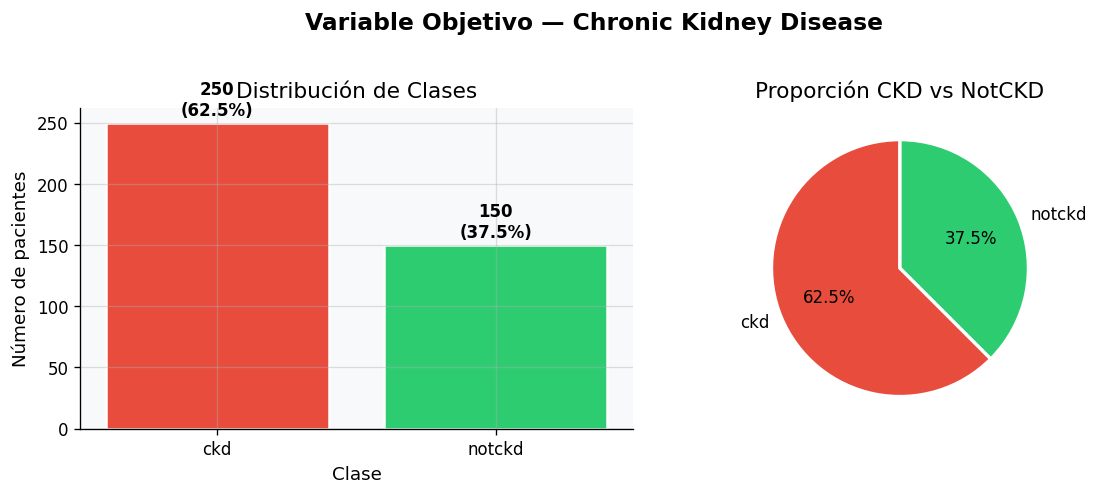


Desbalance de clases: 1.67:1


In [6]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

class_counts = df_raw[TARGET_COL].value_counts()
colors = [COLOR_CKD, COLOR_NOTCKD]

# Diagramas de barras con conteos y porcentajes
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{val}\n({val/len(df_raw)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Distribución de Clases')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Número de pacientes')

# Diagrama de pastel con proporciones
axes[1].pie(class_counts.values, labels=class_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proporción CKD vs NotCKD')

plt.suptitle('Variable Objetivo — Chronic Kidney Disease', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nDesbalance de clases: {class_counts.values[0]/class_counts.values[1]:.2f}:1')

<div class="alert alert-warning">
<b>Desbalanceo de Clase:</b> Podemos tener sesgos del modelo hacia la clase `ckd` para reducir el riesgo empírico.
</div>

La gráfica anteior nos muestra cuantos pacientes tienen CKD y cuantos no. Hay un desbalanceo de clases moderado a favor de la clase de la enfermedad. En el contexto del reconocimiento de patrones clínicos, este desequilibrio es importante porque si se entrena un modelo basándose en la minimización del riesgo empírico - recordemos que todo entrenamiento y decisión tiene un costo o riesgo que se tiene que evaluar - la frontera de decisión tiende a sesgarse hacia la clase mayoritaria para optimizar la exactitud o *accuracy*. Para mitigar este efecto y no subestimar a los pacientes sanos, en lugar de medir la exactitud se pueden usar métricas robustas al desbalanceo como F1-Score o el Área Bajo la Curva ROC.

<h2 style="color:#2E86C1;"> 2. Análisis de la Calidad de los Datos</h2>

No se puede llevar a cabo un análisis adecuado si la matriz de características no está completa. La calidad de los datos define directamente la calidad del modelo. Y si la calidad es baja, hay que utilizar técnicas adecuadas que nos permitan purificar los datos tanto como sea posible para lograr el mejor desempeño. Por ende, inciiamos evaluando los valores faltantes.

In [7]:
# Mapa de valores faltantes
df = df_raw.copy()

# Reemplazar strings vacíos y variantes
df.replace(['?', ' ', '', '\t?', '\t'], np.nan, inplace=True)

# Convertir columnas numéricas
for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Limpiar columnas categóricas
for col in NOMINAL_COLS + ORDINAL_COLS + [TARGET_COL]:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].replace({'nan': np.nan, 'none': np.nan})

# La limpieza del target ya se hizo en la celda de carga — esto es solo por consistencia.
# El .strip().lower() del bucle anterior ya garantiza clases limpias en df.

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje (%)': missing_pct})
missing_df = missing_df[missing_df['Faltantes'] > 0].sort_values('Faltantes', ascending=False)

print('Variables con valores faltantes:')
print(missing_df)

Variables con valores faltantes:
       Faltantes  Porcentaje (%)
rbc          152           38.00
rbcc         131           32.75
wbcc         106           26.50
pot           88           22.00
sod           87           21.75
pcv           71           17.75
pc            65           16.25
hemo          52           13.00
su            49           12.25
sg            47           11.75
al            46           11.50
bgr           44           11.00
bu            19            4.75
sc            17            4.25
bp            12            3.00
age            9            2.25
ba             4            1.00
pcc            4            1.00
htn            2            0.50
dm             2            0.50
cad            2            0.50
appet          1            0.25
pe             1            0.25
ane            1            0.25


<div class="alert alert-info">
A todas las carcaterísticas les faltan datos, no obstante, el <b>conteo de glóbulos rojos</b> es la característica con mayor cantidad de valores faltantes (38.75%).
</div>

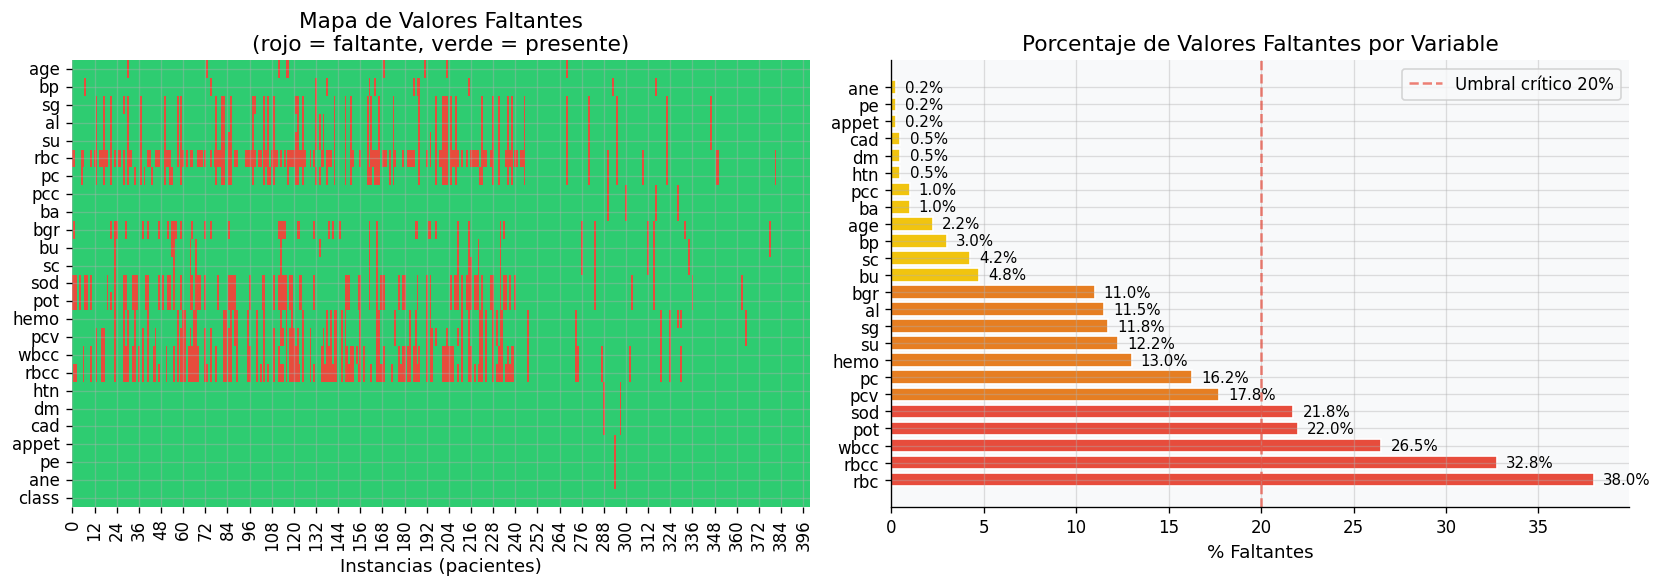

In [8]:
# Mapa de missing binario + barras de porcentaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mapa de calor binario
missing_matrix = df.isnull().astype(int)
sns.heatmap(missing_matrix.T, cmap=['#2ECC71', '#E74C3C'], cbar=False,
            yticklabels=df.columns, ax=axes[0], linewidths=0)
axes[0].set_title('Mapa de Valores Faltantes\n(rojo = faltante, verde = presente)')
axes[0].set_xlabel('Instancias (pacientes)')
axes[0].set_ylabel('')

# Barras de porcentaje
if len(missing_df) > 0:
    colors_bar = ['#E74C3C' if p > 20 else '#E67E22' if p > 10 else '#F1C40F'
                  for p in missing_df['Porcentaje (%)']]
    axes[1].barh(missing_df.index, missing_df['Porcentaje (%)'], color=colors_bar, edgecolor='white')
    for i, (idx, row) in enumerate(missing_df.iterrows()):
        axes[1].text(row['Porcentaje (%)'] + 0.5, i, f"{row['Porcentaje (%)']:.1f}%",
                     va='center', fontsize=9)
    axes[1].axvline(20, color='#E74C3C', linestyle='--', alpha=0.7, label='Umbral crítico 20%')
    axes[1].set_title('Porcentaje de Valores Faltantes por Variable')
    axes[1].set_xlabel('% Faltantes')
    axes[1].legend()

plt.tight_layout()
plt.show()

Los valores perdidos o faltantes aparecen cuando algunas entradas de un conjunto de datos se dejan en blanco, se marcan como NaN, None o cadenas especiales como "Desconocido". Si no se gestionan adecuadamente, pueden reducir la precisión, crear sesgos y romper algoritmos que requieren datos completos, como mencionábamos anteriormente. Aprender a tratar los datos faltantes es clave para:

* Mantiene la precisión de los modelos.
* Evita sesgos.
* Mantiene el tamaño de la muestra.
* Permite el uso correcto de algoritmos de aprendizaje automático.

Hemos determinado un límite del **20%** en lo que respecta a datos faltantes. El gráfico de barras horizontales muestra que cinco variables superan el umbral de datos faltantes: Glóbulos Rojos (`rbc`: 38.0%), Conteo de Glóbulos Rojos (`rbcc`: 32.8%), Conteo de Glóbulos Blancos (`wbcc`: 26.5%), Potasio (`pot`: 22.0%) y Sodio (`sod`: 21.8%). En el ámbito clínico, descartar estas características, lo que conocemos en la literatura como *listwise* *deletion*, representaría una pérdida de dimensionalidad y de poder predictivo, especialmente tratándose de indicadores fundamentales en la progresión de la enfermedad renal.

Desde la perspectiva de la teoría de decisión estadística planteada por Duda, Hart & Stork (2001, Cap. 2.9), la forma matemáticamente óptima de clasificar un vector de características con datos faltantes **no es "inventar" el dato**, sino marginalizar la distribución de probabilidad conjunta sobre las variables no observadas. 

Si particionamos nuestro vector de características en componentes observados ("good") $\mathbf{x}_g$ y componentes faltantes ("bad") $\mathbf{x}_b$, tal que $\mathbf{x} = [\mathbf{x}_g, \mathbf{x}_b]^T$, la probabilidad a posteriori para la clase $\omega_i$ se define integrando sobre el subespacio de las características faltantes:

\begin{equation}
P(\omega_i | \mathbf{x}_g) = \frac{p(\mathbf{x}_g | \omega_i) P(\omega_i)}{\sum_{j=1}^{c} p(\mathbf{x}_g | \omega_j) P(\omega_j)}
\end{equation}

donde la densidad marginal $p(\mathbf{x}_g | \omega_i)$ se obtiene mediante:

\begin{equation}
p(\mathbf{x}_g | \omega_i) = \int p(\mathbf{x}_g, \mathbf{x}_b | \omega_i) d\mathbf{x}_b
\end{equation}


<div class="alert alert-success">
Para preservar la topología geométrica del espacio de características sin asumir normalidad, se descartan los métodos paramétricos de imputación simple. En su lugar, el tratamiento de los datos nulos debe abordarse mediante <b>imputación no Paramétrica </b>: utilizar algoritmos que respeten las relaciones multivariadas locales, como K-Nearest Neighbors Imputer (kNN), el cual estima el valor faltante basándose en la proximidad espacial (distancia Euclidiana) de las muestras más similares, sin requerir supuestos sobre la distribución global. A medida que desarrollemos el EDA, definiremos si es efectivamente el método más robusto.
</div>

<h3 style="color:#2E86C1;"> Detección de Outliers</h3>

Para la detección de outliers, vamos a aplicar métodos estadísticos como el Z-score y el IQR para identificar valores atípicos en las variables numéricas. Esto nos ayudará a entender mejor la distribución de los datos y a decidir si es necesario aplicar técnicas de tratamiento de outliers antes de entrenar nuestros modelos de clasificación.

#### IQR - Rango Intercuartílico

El IQR mide la dispersión del 50% central de los datos. Primero se calcula el primer cuartil ($Q_1$, el percentil 25) y el tercer cuartil ($Q_3$, el percentil 75). Esto nos entrega un rango: $IQR = Q_3 - Q_1$. Luego, se definen las "vallas" (fences) para detectar los outliers:

* Límite inferior: $Q_1 - 1.5 \times IQR$
* Límite superior: $Q_3 + 1.5 \times IQR$

Cualquier punto de dato fuera de este rango se considerará un outlier.

#### Z-Score
El Z-score, por otro lado, no indica cuántas desviaciones estándar ($\sigma$) se aleja un dato ($x$) de la media ($\mu$) de la distribución. Su fórmula es:

\begin{equation}
    z = \frac{x - \mu}{\sigma}
\end{equation}

Con Z-score se puede presenciar varios escenarios:
* Si $z = 0$, el dato es exactamente la media.
* Si $z = 2$, el dato está dos desviaciones estándar por encima de la media.

La regla empírica (para distribuciones normales) dice que la mayoría de los datos se encuentran dentro de $\pm 3\sigma$. Por lo tanto, si $|z| > 3$, es un candidato fuerte a ser un outlier.

Tenemos que hacer una consideración importante. Z-score solo sirve para distribuciones gaussianas. **En este punto aún no hemos analizado las distribuciones de cada una de las variables.**

In [9]:
# Detección de outliers con IQR y Z-score
outlier_report = {}
for col in NUMERIC_COLS:
    series = df[col].dropna()
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_iqr = ((series < lower) | (series > upper)).sum()
    z_scores = np.abs(stats.zscore(series))
    n_zscore = (z_scores > 3).sum()
    outlier_report[col] = {'IQR Outliers': n_iqr, 'Z-score Outliers (|z|>3)': n_zscore,
                           'Lower bound': round(lower,2), 'Upper bound': round(upper,2)}

outlier_df = pd.DataFrame(outlier_report).T
print('Reporte de Outliers:')
print(outlier_df)

Reporte de Outliers:
      IQR Outliers  Z-score Outliers (|z|>3)  Lower bound  Upper bound
age           10.0                       0.0         8.25        98.25
bp            36.0                       3.0        55.00        95.00
bgr           34.0                      10.0         3.00       259.00
bu            38.0                       9.0       -31.50       124.50
sc            51.0                       4.0        -1.95         5.65
sod           16.0                       2.0       124.50       152.50
pot            4.0                       2.0         2.15         6.55
hemo           1.0                       1.0         3.25        22.05
pcv            1.0                       1.0        12.50        64.50
wbcc          10.0                       4.0      1550.00     14750.00
rbcc           1.0                       1.0         1.65         7.65


<div class="alert alert-danger">
Hay una gran diferencia en la cantidad de outliers detectados por cada método.
</div>

#### Presencia de Outliers Extremos y Asimetría

Variables clínicas fundamentales como `bgr` (glucosa en sangre), `bu` (urea), `sc` (creatinina sérica) y `wbcc` (conteo de glóbulos blancos) exhiben una cantidad masiva de valores atípicos muy por encima del límite superior del rango intercuartílico (definido típicamente como $Q3 + 1.5 \times IQR$). En el caso de sc, por ejemplo, la caja principal está comprimida cerca del cero, pero existen observaciones que superan el valor de $70$, lo que indica una distribución de cola extremadamente pesada (asimetría positiva).

#### Impacto en la Estimación Paramétrica 

Según Duda, Hart & Stork (2001), los clasificadores basados en la teoría de decisión de Bayes que asumen densidades Gaussianas dependen de los estimadores de Máxima Verosimilitud (MLE) para el vector de medias $\hat{\boldsymbol{\mu}}$ y la matriz de covarianza $\hat{\mathbf{\Sigma}}$. Estos estimadores son altamente sensibles a valores extremos.

Un solo vector $\mathbf{x}_k$ que contenga un outlier severo inflará desproporcionadamente la varianza a lo largo de esa dimensión en la matriz $\hat{\mathbf{\Sigma}}$, alterando la forma del hiperplano de decisión y degradando la precisión del clasificador (como un Discriminante Cuadrático o Lineal).

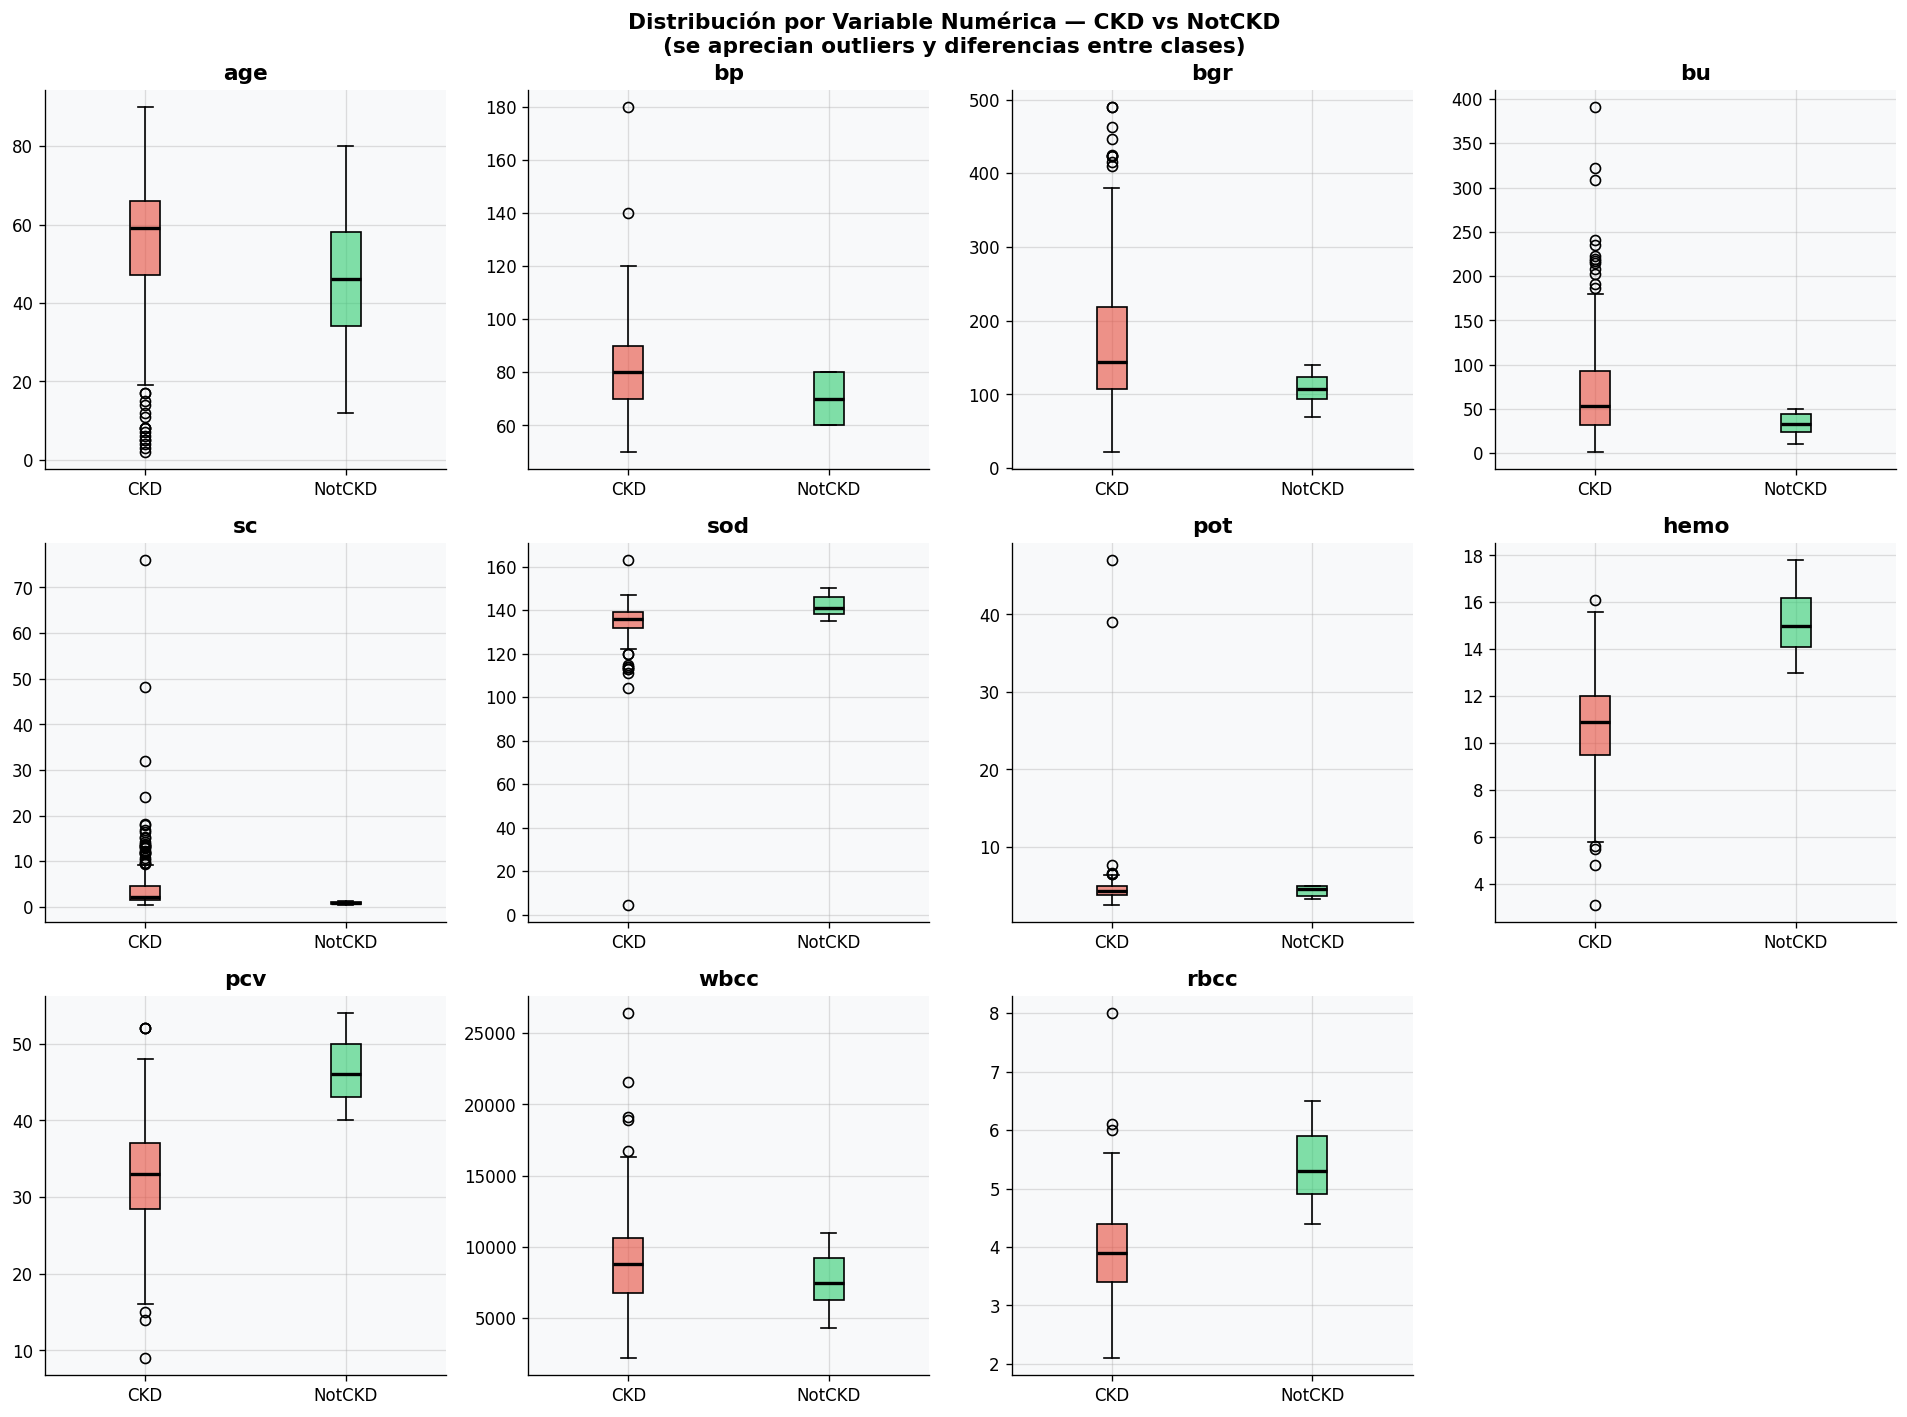

In [10]:
# Boxplots para visualizar outliers por clase
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

df_temp = df[NUMERIC_COLS + [TARGET_COL]].dropna(subset=[TARGET_COL])

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    data_ckd    = df_temp[df_temp[TARGET_COL]=='ckd'][col].dropna()
    data_notckd = df_temp[df_temp[TARGET_COL]=='notckd'][col].dropna()
    
    bp = ax.boxplot([data_ckd, data_notckd],
                    labels=['CKD', 'NotCKD'],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(COLOR_CKD + '99')
    bp['boxes'][1].set_facecolor(COLOR_NOTCKD + '99')
    
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('')

# Desactivar el eje sobrante
for j in range(len(NUMERIC_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución por Variable Numérica — CKD vs NotCKD\n(se aprecian outliers y diferencias entre clases)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

De acuerdo con la teoría de decisión de Bayes (Duda, Hart & Stork, 2001), el error de clasificación está directamente relacionado con el área de traslape entre las densidades $p(\mathbf{x}|\omega_1)P(\omega_1)$ y $p(\mathbf{x}|\omega_2)P(\omega_2)$.
En los boxplots, observamos características con un altísimo poder discriminante individual, como la hemoglobina (`hemo`), el volumen celular empacado (`pcv`) y el conteo de glóbulos rojos (`rbcc`). En estas variables, los rangos intercuartílicos (IQR) de ambas clases están completamente separados en el espacio unidimensional. Esto sugiere que, incluso antes de aplicar proyecciones multivariadas como PCA o Fisher, estas variables dominarán la función discriminante lineal debido a su alta separabilidad marginal.

Hay un detalle visual muy importante: el tamaño de las cajas. Para la clase 1 (sanos), las cajas son muy pequeñas y compactas; es decir, los pacientes sanos tienen valores muy similares entre sí. En cambio, para la clase 0 (CKD), las cajas son gigantes y están llenas de puntos atípicos; los pacientes enfermos tienen valores que varían drásticamente. 

En estadística, esto significa que las varianzas de ambas clases son muy diferentes ($\Sigma_0 \neq \Sigma_1$).
Muchos modelos básicos (como los clasificadores lineales paramétricos) asumen por defecto que ambas clases tienen el mismo nivel de dispersión. Al comprobar visualmente que esto no es cierto, usar líneas rectas para separar las clases no será lo ideal. Matemáticamente, esta diferencia en las dispersiones nos obliga a evaluar modelos que puedan dibujar fronteras curvas (como los clasificadores cuadráticos) o modelos no paramétricos que no dependan de este supuesto.

In [11]:
# En esta etapa usamos los datos sin imputar.
# Los NaN se descartan localmente en cada gráfico con .dropna().
# Esto es correcto metodológicamente: queremos ver la distribución REAL
# de los datos antes de cualquier intervención.

df_raw_clean = df.copy()   

# Subconjuntos por clase (con NaN — solo para visualización exploratoria)
df_ckd_raw    = df_raw_clean[df_raw_clean[TARGET_COL] == 'ckd']
df_notckd_raw = df_raw_clean[df_raw_clean[TARGET_COL] == 'notckd']

print('Datos crudos listos para análisis exploratorio.')
print(f'   Faltantes totales: {df_raw_clean.isnull().sum().sum()}')
print(f'   CKD: {len(df_ckd_raw)} | NotCKD: {len(df_notckd_raw)}')

Datos crudos listos para análisis exploratorio.
   Faltantes totales: 1012
   CKD: 250 | NotCKD: 150


<h2 style="color:#2E86C1;"> 3. Análisis Univariado: Distribuciones y Densidades</h2>

<h3 style="color:#2E86C1;"> Variables Numéricas</h3>

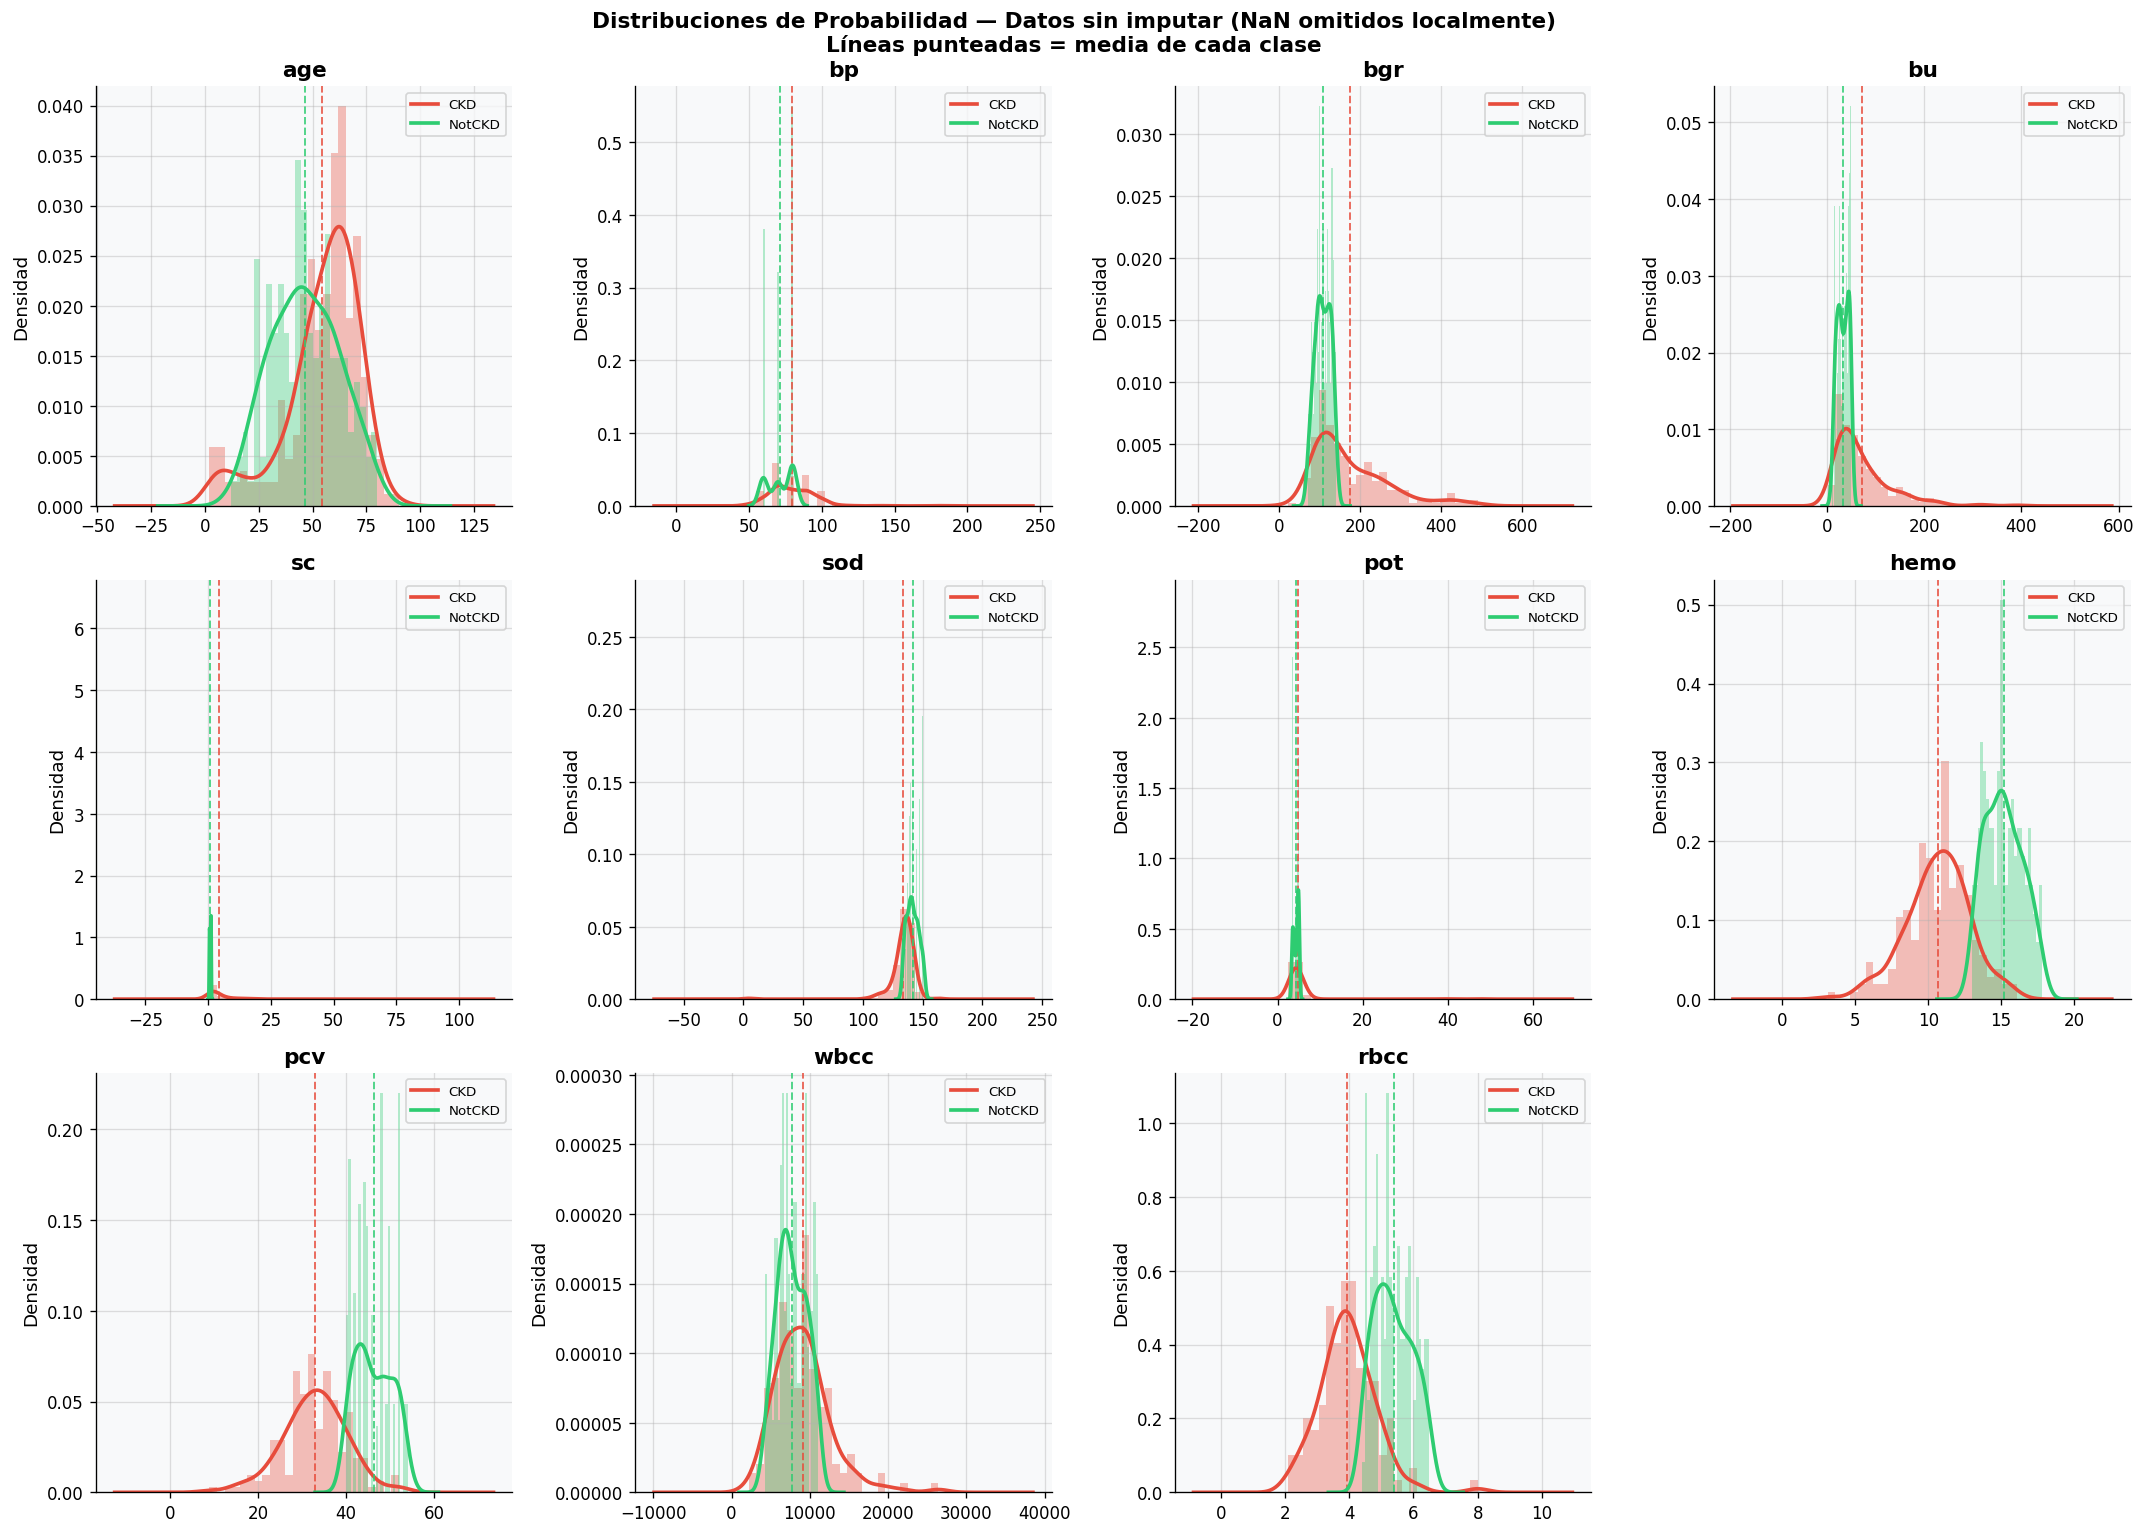

In [12]:
# Histogramas con KDE para comparar distribuciones por clase (NaN omitidos localmente)
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    for cls, color, label, df_cls in [
        ('ckd',    COLOR_CKD,    'CKD',    df_ckd_raw),
        ('notckd', COLOR_NOTCKD, 'NotCKD', df_notckd_raw)
    ]:
        data = df_cls[col].dropna()
        ax.hist(data, bins=25, density=True, alpha=0.35, color=color, edgecolor='none')
        data.plot.kde(ax=ax, color=color, linewidth=2.2, label=label)
        ax.axvline(data.mean(), color=color, linestyle='--', linewidth=1.2, alpha=0.8)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Densidad')

for j in range(len(NUMERIC_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Distribuciones de Probabilidad — Datos sin imputar (NaN omitidos localmente)\n'
    'Líneas punteadas = media de cada clase',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


Si observamos variables como la creatinina sérica (sc), la urea (bu) y la glucosa (bgr), vemos que la gran mayoría de los pacientes están concentrados a la izquierda, pero hay una "cola" muy larga que se extiende hacia la derecha (asimetría positiva). 

Si intentamos ajustar una campana de Gauss a estas variables usando Estimadores de Máxima Verosimilitud (MLE), los valores de esa cola derecha arrastrarán el cálculo de la media poblacional:

\begin{equation}
\hat{\mu} = \frac{1}{n} \sum_{k=1}^n x_k
\end{equation}

Esto causará que el centro de nuestro modelo paramétrico quede en un lugar vacío donde casi no hay pacientes, haciendo que el modelo se equivoque. Esto confirma que necesitamos aplicar una transformación matemática (como el logaritmo $\log(x)$) a estas variables específicas para volverlas más simétricas antes de entrenar modelos paramétricos o calcular distancias.

El hallazgo más interesante está en variables como la hemoglobina (`hemo`), el volumen celular empacado (`pcv`) y el conteo de glóbulos rojos (`rbcc`); no tienen forma de campana única, sino que tienen dos picos claros (bimodalidad).E sos dos picos que vemos representan a las dos poblaciones mezcladas (los pacientes con CKD y los pacientes sanos). La separación tan clara entre los picos corrobora lo que vimos en los boxplots: estas variables tienen un poder discriminante natural altísimo. Un clasificador de Bayes tradicional si podría separar estas dos "montañas" con mucho éxito.

\begin{equation}
p(x) = p(x|\omega_0)P(\omega_0) + p(x|\omega_1)P(\omega_1)
\end{equation}

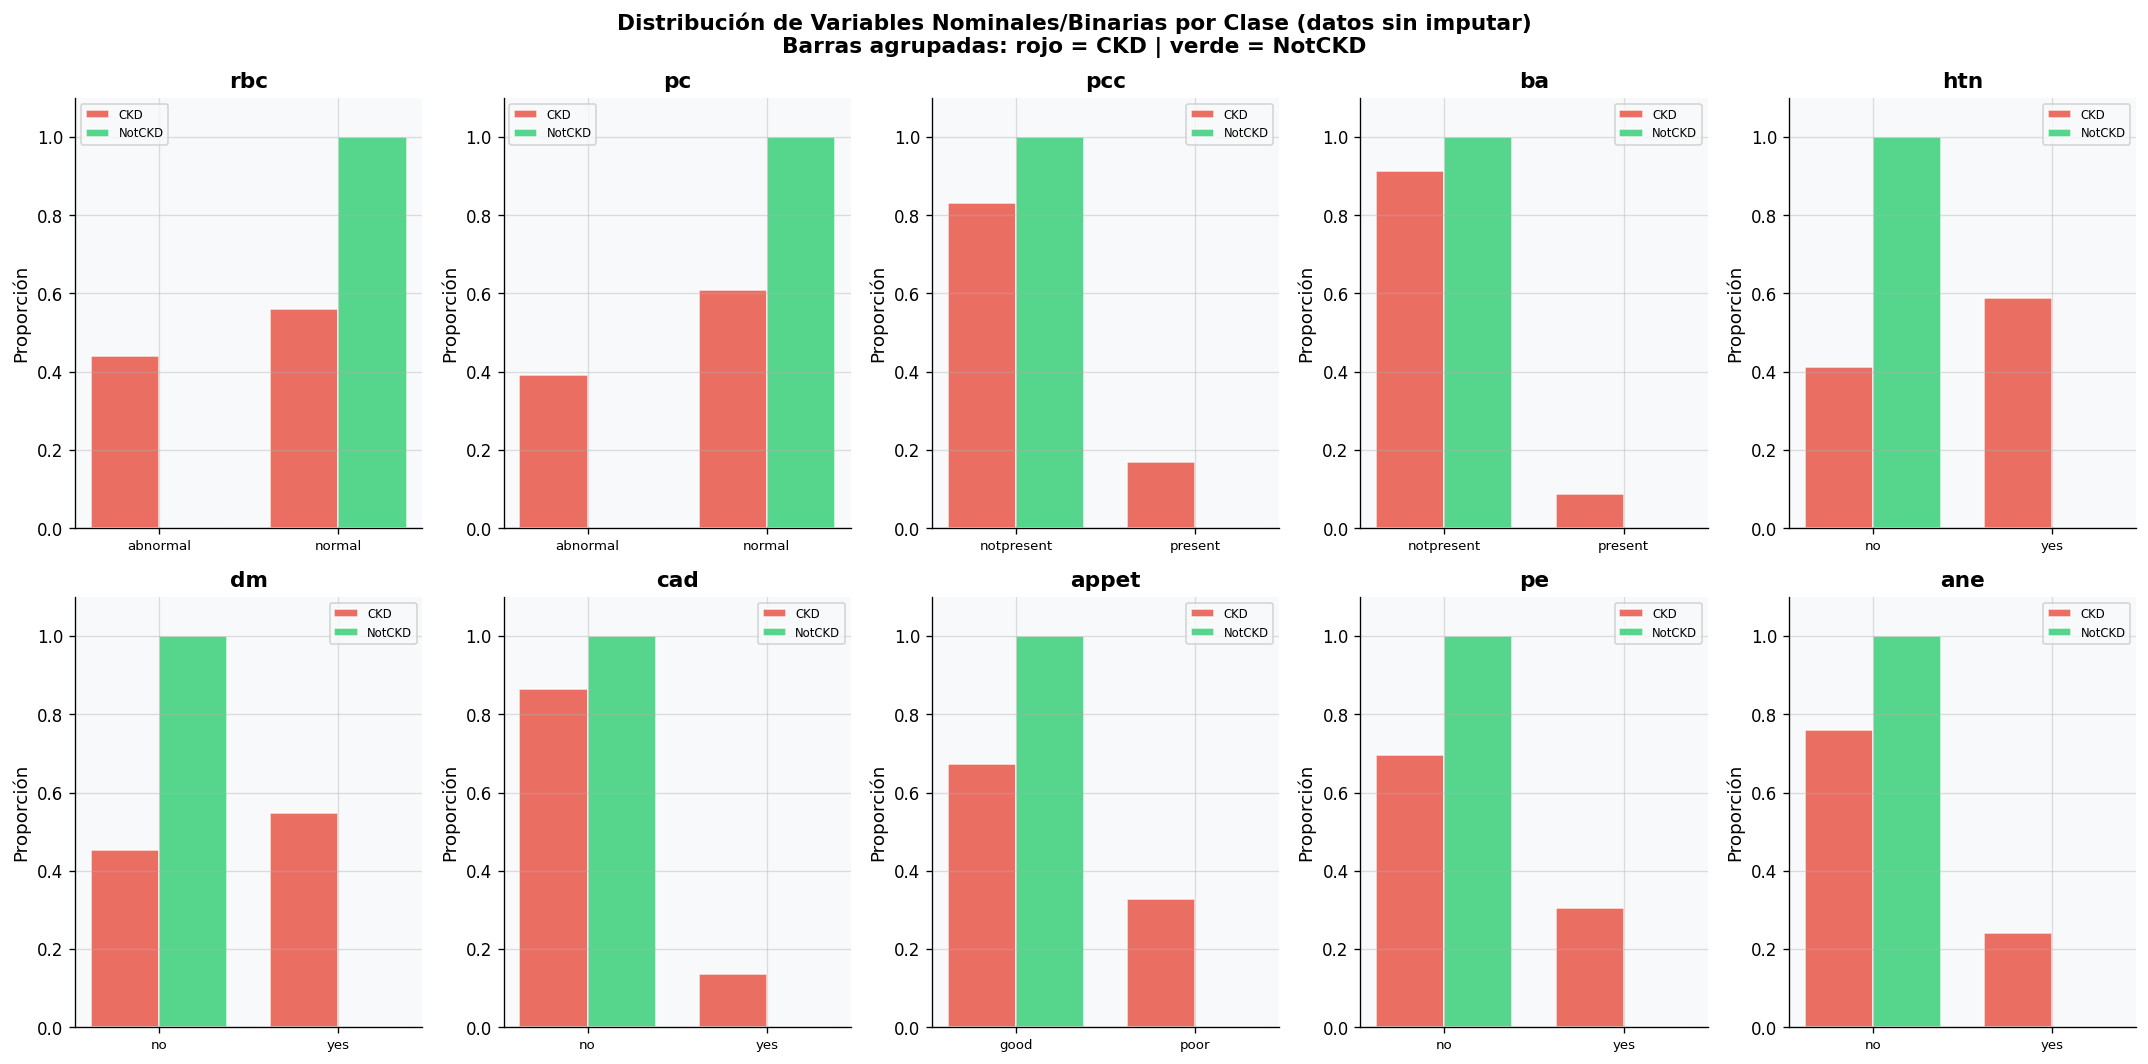

In [13]:
# Variables nominales/binarias: barras agrupadas por clase (NaN omitidos localmente)
fig, axes = plt.subplots(2, 5, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(NOMINAL_COLS):
    ax = axes[i]

    # Frecuencias normalizadas por clase
    counts_ckd    = (df_ckd_raw[col].dropna()
                     .value_counts(normalize=True).sort_index())
    counts_notckd = (df_notckd_raw[col].dropna()
                     .value_counts(normalize=True).sort_index())

    # Unión de todas las categorías presentes en cualquiera de las dos clases
    all_cats = sorted(set(counts_ckd.index) | set(counts_notckd.index))
    x = np.arange(len(all_cats))
    width = 0.38

    # Barras agrupadas: CKD a la izquierda, NotCKD a la derecha
    ax.bar(x - width/2,
           [counts_ckd.get(c, 0) for c in all_cats],
           width, color=COLOR_CKD,    alpha=0.80, edgecolor='white', label='CKD')
    ax.bar(x + width/2,
           [counts_notckd.get(c, 0) for c in all_cats],
           width, color=COLOR_NOTCKD, alpha=0.80, edgecolor='white', label='NotCKD')

    ax.set_xticks(x)
    ax.set_xticklabels(all_cats, fontsize=8)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Proporción')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=7)

for j in range(len(NOMINAL_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Distribución de Variables Nominales/Binarias por Clase (datos sin imputar)\n'
    'Barras agrupadas: rojo = CKD | verde = NotCKD',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

<div class="alert alert-info">
Al observar estas distribuciones categóricas, el patrón más destacable a simple vista es la <b>ausencia total de varianza en la clase NotCKD </b> (las barras verdes). Absolutamente todos los pacientes sanos en este conjunto de datos de la UCI presentan valores "normales" o negativos para estas diez características.

Si analizamos este gráfico en términos de la teoría de probabilidades de Bayes que plantea Duda, esto significa que la probabilidad condicional de tener la enfermedad si presentas el síntoma es del 100%. Matemáticamente, $P(x=1 | \omega_{\text{sano}}) = 0$. Por lo tanto, si a nuestro modelo le llega un paciente nuevo y tiene un "1" en hipertensión, diabetes o anemia, el clasificador puede decidir casi de forma automática y con total seguridad que pertenece a la clase 0 (CKD).

Adicionalmente, debemos destacar que si intentamos meter estas variables binarias de ceros y unos en una fórmula de Máxima Verosimilitud diseñada para variables continuas, el modelo se va a confundir. Esto justifica que, más adelante, tengamos que tratar estas variables de forma especial (por ejemplo, usando un clasificador Naive Bayes para las variables categóricas) o codificarlas adecuadamente.

In [14]:
# Estadísticas descriptivas por clase (datos sin imputar)
stats_ckd    = df_ckd_raw[NUMERIC_COLS].describe().round(3)
stats_notckd = df_notckd_raw[NUMERIC_COLS].describe().round(3)

print('Estadísticas descriptivas — Clase CKD (datos sin imputar)')
display(stats_ckd)
print('\n Estadísticas descriptivas — Clase NotCKD (datos sin imputar)')
display(stats_notckd)


Estadísticas descriptivas — Clase CKD (datos sin imputar)


,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,242.000,240.000,212.000,237.000,238.000,168.000,167.000,204.000,183.000,151.000,126.000
mean,54.541,79.625,175.420,72.389,4.415,133.902,4.878,10.648,32.940,9069.536,3.945
std,17.389,15.234,92.082,58.587,6.950,12.403,4.322,2.186,7.209,3580.521,0.865
min,2.000,50.000,22.000,1.500,0.500,4.500,2.500,3.100,9.000,2200.000,2.100
25%,47.000,70.000,106.750,32.000,1.425,132.000,3.850,9.475,28.500,6750.000,3.400
50%,59.000,80.000,143.500,53.000,2.250,136.000,4.300,10.900,33.000,8800.000,3.900
75%,66.000,90.000,219.250,93.000,4.550,139.000,4.900,12.025,37.000,10600.000,4.400
max,90.000,180.000,490.000,391.000,76.000,163.000,47.000,16.100,52.000,26400.000,8.000



 Estadísticas descriptivas — Clase NotCKD (datos sin imputar)


,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,149.000,148.000,144.000,144.000,145.000,145.000,145.000,144.000,146.000,143.000,143.000
mean,46.517,71.351,107.722,32.799,0.869,141.731,4.338,15.188,46.336,7705.594,5.379
std,15.631,8.543,18.565,11.450,0.255,4.818,0.587,1.278,4.134,1839.771,0.596
min,12.000,60.000,70.000,10.000,0.400,135.000,3.300,13.000,40.000,4300.000,4.400
25%,34.000,60.000,93.750,23.750,0.600,138.000,3.700,14.100,43.000,6300.000,4.900
50%,46.000,70.000,107.500,33.000,0.900,141.000,4.500,15.000,46.000,7500.000,5.300
75%,58.000,80.000,123.250,44.000,1.100,146.000,4.900,16.200,50.000,9250.000,5.900
max,80.000,80.000,140.000,50.000,1.200,150.000,5.000,17.800,54.000,11000.000,6.500


1. Si observamos las medias (mean) de la clase 0 y la clase 1 para variables estrella como la hemoglobina (hemo) o la gravedad específica (sg), notamos una distancia matemática considerable entre ambos centros. Esta distancia $|\hat{\mu}_0 - \hat{\mu}_1|$ es fundamental para métodos como el Discriminante Lineal de Fisher. El criterio de Fisher busca precisamente proyectar los datos en una dimensión donde esta distancia entre medias sea la máxima posible, en relación con la dispersión de los datos. Tener medias tan separadas numéricamente garantiza que el modelo tendrá un buen punto de partida para trazar la frontera que separa a los pacientes enfermos de los sanos.

2. Para la gran mayoría de las variables, la dispersión de la clase 0 es magnitudes mayor que la de la clase 1. Por ejemplo, la desviación estándar de la glucosa (bgr) o la urea (bu) en la clase 0 triplica o cuadruplica a la de la clase 1. Esto demuestra cuantitativamente que las matrices de covarianza de ambas clases son diferentes ($\mathbf{\Sigma}_0 \neq \mathbf{\Sigma}_1$). Si aplicamos un Análisis Discriminante Lineal (LDA), el algoritmo promediará a la fuerza estas dos varianzas para asumir que son iguales. Al hacerlo, distorsionará la realidad matemática de los datos. 

3. Los conteos (count) revelan que la pérdida de datos ocurre de forma asimétrica y concentrada en la clase CKD (ej. 242 registros en `age` vs. solo 126 en `rbcc`). Apoyándose en Statistical Analysis with Missing Data (Little & Rubin), esto evidencia que los datos no faltan de manera completamente aleatoria (MCAR). Imputar usando estadísticos simples (como la media) destruiría la varianza natural y sesgaría la matriz de covarianza; se requiere imputación multivariada.

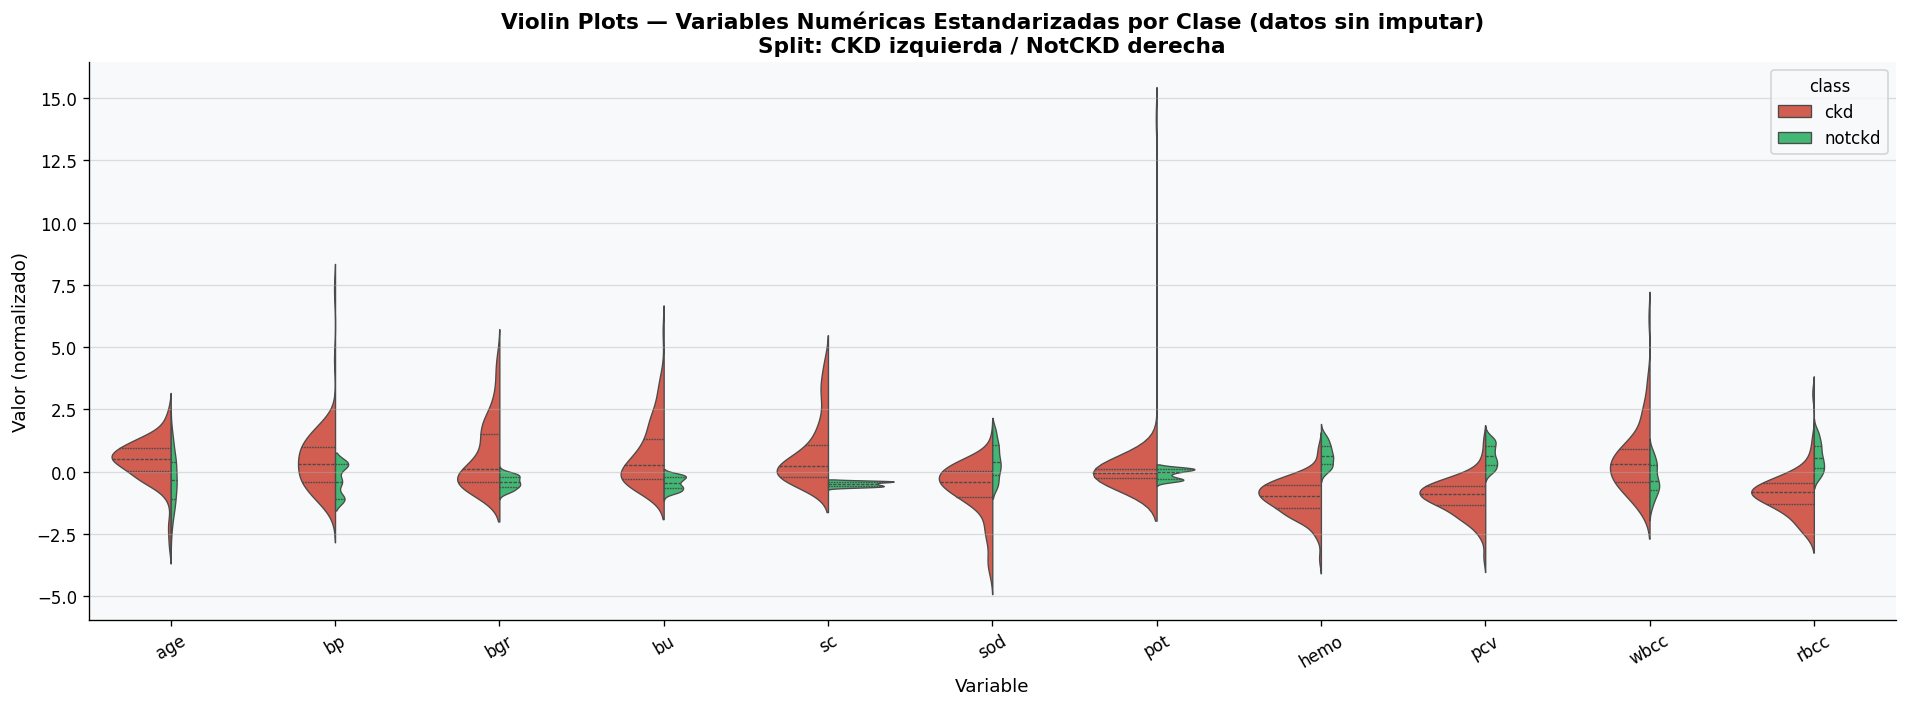

In [15]:
# Violin plots para comparar distribuciones por clase (NaN omitidos localmente)
df_viz = df_raw_clean[NUMERIC_COLS + [TARGET_COL]].dropna()
scaler_viz = StandardScaler()
X_scaled = pd.DataFrame(
    scaler_viz.fit_transform(df_viz[NUMERIC_COLS]),
    columns=NUMERIC_COLS
)
X_scaled['class'] = df_viz[TARGET_COL].values
X_melt = X_scaled.melt(id_vars='class', var_name='Variable', value_name='Valor (normalizado)')

fig, ax = plt.subplots(figsize=(16, 6))
sns.violinplot(data=X_melt, x='Variable', y='Valor (normalizado)', hue='class',
               split=True, inner='quart',
               palette={'ckd': COLOR_CKD, 'notckd': COLOR_NOTCKD},
               ax=ax, linewidth=0.8)
ax.set_title(
    'Violin Plots — Variables Numéricas Estandarizadas por Clase (datos sin imputar)\n'
    'Split: CKD izquierda / NotCKD derecha',
    fontsize=13, fontweight='bold'
)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


1. La gráfica demuestra el impacto matemático de usar un escalado tradicional $Z = \frac{x - \mu}{\sigma}$. Las colas extremadamente largas en la clase CKD  para variables como la creatinina (`sc`), la urea (`bu`) y el potasio (`pot`) dominan la varianza global. Esto provoca que la distribución de la clase NotCKD se comprima artificialmente hasta parecer una línea plana continua con curtosis masiva.

2. Las variables hematológicas (`hemo`, `pcv`, `rbcc`) muestran un claro desplazamiento vertical entre los "nodos" de máxima densidad de ambas clases. Matemáticamente, esta baja intersección entre las curvas de densidad de probabilidad $P(x \mid C_1)$ y $P(x \mid C_2)$ confirma que estas características poseen un alto poder discriminante, facilitando la convergencia de cualquier algoritmo de clasificación; es decir, podemos crear un hiperplano de separación claro.

3. Mientras que la clase sana exhibe distribuciones altamente simétricas y concentradas alrededor de su mediana, la clase enferma presenta un marcado sesgo positivo en marcadores de desecho (`sc`, `bu`, `bgr`) y un sesgo negativo en características de calidad sanguínea (`hemo`, `pcv`). Este patrón heterogéneo es un rasgo inherente de la fisiopatología renal y no debe corregirse forzando la normalidad en la distribución.

<h2 style="color:#2E86C1;"> 3. Pruebas de Normalidad</h2>

Vamos a evaluar la normalidad de cada variable numérica por clase utilizando varias pruebas estadísticas (Shapiro-Wilk, D'Agostino-Pearson, Kolmogorov-Smirnov) y también calcularemos el skewness y kurtosis para entender mejor la forma de las distribuciones, antes de seleccionar el enfoque de imputación de datos. Con base a las visualizaciones anteriores ya sabemos que no todas las variables se representan bajo una distribución normal.

Para determinar con rigor matemático si las variables continuas del dataset siguen una distribución gaussiana, se plantean como hipótesis:
* $H_0$ (Hipótesis Nula): La muestra proviene de una distribución normal.
* $H_1$ (Hipótesis Alternativa): La muestra no proviene de una distribución normal.Se utiliza un nivel de significancia $\alpha = 0.05$. Si el valor $p$ es menor a $\alpha$, se rechaza $H_0$.

#### Prueba Shapiro-Wilk

Es considerada una de las pruebas más potentes para contrastar la normalidad, especialmente en muestras pequeñas a medianas ($n < 5000$). Evalúa si existe una correlación lineal alta entre los datos de la muestra ordenados y los valores esperados de una distribución normal estándar.

Referencia: Shapiro, S. S., & Wilk, M. B. (1965). An analysis of variance test for normality (complete samples). Biometrika, 52(3/4), 591-611.2. 

#### Prueba de D'Agostino-Pearson ($K^2$)

Esta prueba es muy útil porque cuantifica cómo la distribución difiere de una normal. Calcula un estadístico basado en la asimetría (skewness) y la curtosis (kurtosis) de la muestra para determinar si estas métricas se alejan significativamente de los valores esperados en una campana de Gauss (donde la asimetría es 0 y el exceso de curtosis es 0).

Referencia: D'Agostino, R., & Pearson, E. S. (1973). Tests for departure from normality. Empirical results for the distributions of $b_2$ and $\sqrt{b_1}$. Biometrika, 60(3), 613-622.3. 

#### Prueba de Kolmogorov-Smirnov (K-S)

Es una prueba no paramétrica que compara la Función de Distribución Acumulada (CDF) empírica de los datos de la muestra contra la CDF teórica de la distribución de referencia (en este caso, una normal con la media y desviación estándar de la muestra). Mide la distancia máxima absoluta entre ambas curvas.

Referencia: Massey Jr, F. J. (1951). The Kolmogorov-Smirnov test for goodness of fit. Journal of the American statistical Association, 46(253), 68-78.

In [16]:
# Pruebas de normalidad por clase
normality_results = []

for col in NUMERIC_COLS:
    for cls in ['ckd', 'notckd']:
        data = df_raw_clean[df_raw_clean[TARGET_COL]==cls][col].dropna().values
        
        # Shapiro-Wilk
        sw_stat, sw_p = shapiro(data[:5000])  # límite de la función
        # D'Agostino-Pearson
        dp_stat, dp_p = normaltest(data)
        # Kolmogorov-Smirnov vs N(mu, sigma)
        ks_stat, ks_p = kstest(data, 'norm', args=(data.mean(), data.std()))
        
        # Skewness y Kurtosis
        skew  = stats.skew(data)
        kurt  = stats.kurtosis(data)  # excess kurtosis
        
        normality_results.append({
            'Variable': col, 'Clase': cls,
            'SW p-value': round(sw_p, 4), 'SW Normal?': '✅' if sw_p > 0.05 else '❌',
            'DP p-value': round(dp_p, 4), 'DP Normal?': '✅' if dp_p > 0.05 else '❌',
            'KS p-value': round(ks_p, 4), 'KS Normal?': '✅' if ks_p > 0.05 else '❌',
            'Skewness': round(skew, 3), 'Kurtosis (exceso)': round(kurt, 3)
        })

norm_df = pd.DataFrame(normality_results)
print('Resultados de Pruebas de Normalidad (α = 0.05):')
display(norm_df)

Resultados de Pruebas de Normalidad (α = 0.05):


,Variable,Clase,SW p-value,SW Normal?,DP p-value,DP Normal?,KS p-value,KS Normal?,Skewness,Kurtosis (exceso)
0,age,ckd,0.0000,❌,0.0000,❌,0.0013,❌,-1.163,1.203
1,age,notckd,0.1454,✅,0.0244,❌,0.6611,✅,0.071,-0.739
2,bp,ckd,0.0000,❌,0.0000,❌,0.0000,❌,1.494,7.397
3,bp,notckd,0.0000,❌,0.0000,❌,0.0000,❌,-0.261,-1.572
4,bgr,ckd,0.0000,❌,0.0000,❌,0.0002,❌,1.326,1.441
5,bgr,notckd,0.0018,❌,0.0000,❌,0.3558,✅,-0.121,-1.013
6,bu,ckd,0.0000,❌,0.0000,❌,0.0000,❌,1.999,5.381
7,bu,notckd,0.0000,❌,0.0000,❌,0.0657,✅,-0.078,-1.281
8,sc,ckd,0.0000,❌,0.0000,❌,0.0000,❌,6.233,53.014
9,sc,notckd,0.0000,❌,0.0000,❌,0.0028,❌,-0.104,-1.406


La prueba de Shapiro-Wilk evalúa la hipótesis nula ($H_0$) de que una muestra proviene de una población con distribución normal. Al observar los resultados en la tabla, vemos que el $p$-value para todas las variables numéricas (como `bgr`, `bu`, `sc`, etc.) es extremadamente cercano a cero (prácticamente $0.0$). Dado que $p \ll 0.05$, rechazamos rotundamente la hipótesis nula para todas las características numéricas. 

<div class="alert alert-danger">
Las pruebas de Shapiro-Wilk (SW), D'Agostino-Pearson (DP) y Kolmogorov-Smirnov (KS) concuerdan en rechazar la hipótesis nula de normalidad ($p < 0.05$) para casi la totalidad de las variables en ambas clases. Las escasas excepciones (como hemo o pcv en la clase CKD) no son suficientes para asumir normalidad multivariada.

<div class="alert alert-success">
Estos descubrimientos justifican el uso de métodos no paramétricos en la etapa 03 de nuestro proyecto, que sean robustos ante distribuciones arbitrarias. 

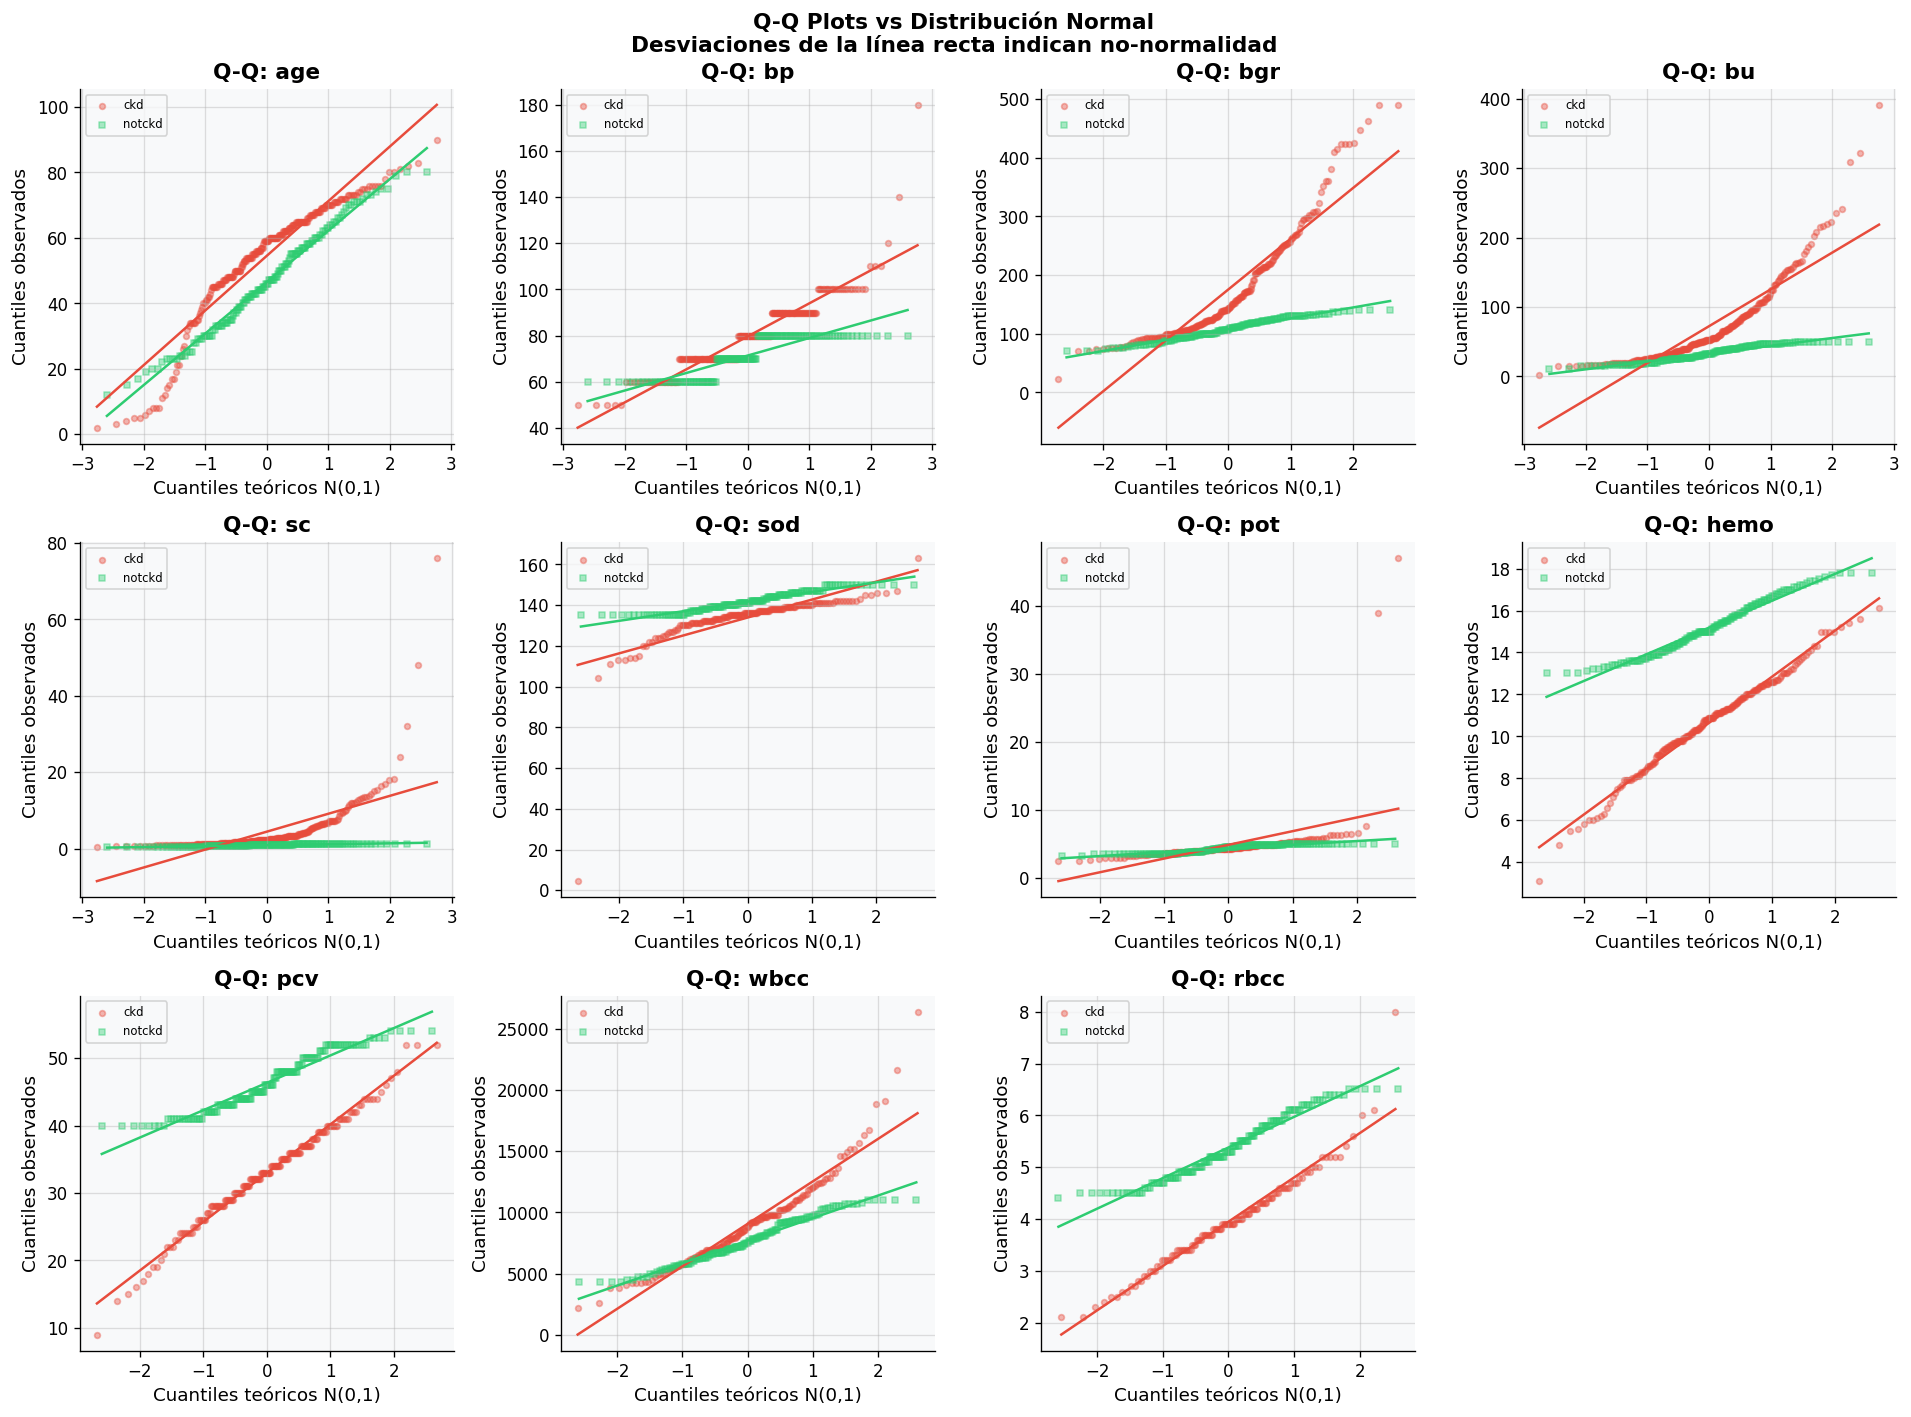

In [17]:
# Q-Q Plots para evaluar normalidad visualmente por clase (NaN omitidos localmente)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    for cls, color, marker in [('ckd', COLOR_CKD, 'o'), ('notckd', COLOR_NOTCKD, 's')]:
        data = df_raw_clean[df_raw_clean[TARGET_COL]==cls][col].dropna().values
        (osm, osr), (slope, intercept, _) = stats.probplot(data, dist='norm', fit=True)
        ax.scatter(osm, osr, color=color, alpha=0.4, s=12, marker=marker, label=cls)
        ax.plot(osm, slope*np.array(osm)+intercept, color=color, linewidth=1.5)
    
    ax.set_title(f'Q-Q: {col}', fontweight='bold')
    ax.set_xlabel('Cuantiles teóricos N(0,1)')
    ax.set_ylabel('Cuantiles observados')
    ax.legend(fontsize=7)

for j in range(len(NUMERIC_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Q-Q Plots vs Distribución Normal\n'
             'Desviaciones de la línea recta indican no-normalidad',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

1. En la clase con enfermedad, variables de retención de desechos como la creatinina (`sc`), la urea (`bu`) y la glucosa (`bgr`) muestran una curvatura convexa extrema en el extremo superior derecho. Geométricamente, esta separación de la diagonal indica la presencia de colas derechas muy pesadas (sesgo positivo), corroborando que los valores patológicos extremos dominan los últimos percentiles de la distribución.

2. En variables como la presión arterial (`bp`) o el potasio (`pot`), los puntos no forman una curva suave, sino una serie de "escalones" horizontales. Esto revela que, aunque la variable subyacente es continua, el proceso de medición clínica introduce un redondeo sistemático. Esta discretización viola  el supuesto de continuidad requerido por una distribución normal perfecta.

3. Mientras que algunas variables en la clase `NotCKD` logran aproximarse razonablemente a la diagonal central (como `hemo` o `pcv`), la clase `CKD` se desvía drásticamente en esas mismas características. Esta diferencia en la geometría de los cuantiles reitera que las dos clases no solo difieren en su media o varianza, sino en la familia distributiva subyacente.

<h2 style="color:#2E86C1;"> 3. Imputación de Datos</h2>

**¿Por qué imputamos aquí y no antes?**  
El análisis univariado (Sección 1) y las pruebas de normalidad (Sección 2) se realizaron sobre los datos **crudos** intencionalmente. Esto permite que  la elección del método de imputación esté **justificada por la evidencia** y no sea una decisión arbitraria.

**Lo que encontramos:**
- Las distribuciones son **asimétricas** (cola derecha en `sc`, `bu`, `pot`).
- La mayoría de variables **no son normales** según Shapiro-Wilk y D'Agostino.
- Las varianzas entre clases son **heterogéneas**.

**Conclusión:**
La imputación por media (que asume normalidad y homogeneidad) sería inapropiada. Se justifica un método que preserve la **estructura local** de los datos sin asumir ninguna distribución paramétrica.

De acuerdo con los hallazgos del Análisis Exploratorio y apoyándonos en la teoría de Pattern Classification (Duda, Hart & Stork, 2001), el espacio de características original presenta distorsiones severas (asimetría y valores atípicos) que inhabilitan el uso de métricas de distancia directas.

#### Estabilización de Varianza
Variables clínicas como sc, bu y bgr exhiben una asimetría positiva extrema. Si calculamos distancias euclidianas en este espacio crudo, los valores atípicos dominarán la métrica. Para mitigar esto, aplicamos una transformación no lineal:

\begin{equation}
    x' = \ln(1 + x)
\end{equation}

Esta función comprime los valores extremos de la cola derecha, acercando la distribución empírica a una forma más simétrica y estabilizando la varianza.

#### Estandarización del Espacio
Para que el algoritmo de imputación busque a los "pacientes más parecidos" (vecinos más cercanos), el espacio debe ser isotrópico. Es decir, todas las dimensiones deben tener el mismo peso. Si no estandarizamos, una variable con valores en los miles (como los glóbulos blancos) anulará por completo a una variable con valores decimales (como la gravedad específica). Se aplica la transformación estándar.

####  Imputación Multivariada ($k$-NN)
Una vez el espacio topológico es robusto, se estiman los valores faltantes $\mathbf{x}_b$ utilizando sus $k$ vecinos más cercanos basados en las características observadas $\mathbf{x}_g$. La distancia Euclidiana entre dos muestras $\mathbf{x}$ y $\mathbf{y}$ en este nuevo espacio mitigado está dada por:

\begin{equation}
    d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^{d_g} (z_{xi} - z_{yi})^2}
\end{equation}

El valor imputado será el promedio (o promedio ponderado por distancia) de los valores de esos $k$ vecinos, preservando así las relaciones no lineales multivariadas sin asumir normalidad.

In [18]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer

df_proc = df.copy()

# Variables según su naturaleza (Ajusta los nombres según tu dataframe)
SKEWED_COLS = ['sc', 'bu', 'bgr'] # Variables para logaritmo
# NUMERIC_COLS no debe incluir a SKEWED_COLS en el paso de Winsorización directo
OTHER_NUMERIC = [col for col in NUMERIC_COLS if col not in SKEWED_COLS]

# ---------------------------------------------------------
# PASO 1: MANEJO DE OUTLIERS Y ASIMETRÍA (ANTES DE IMPUTAR)
# ---------------------------------------------------------

# A. Transformación logarítmica para distribuciones muy sesgadas
for col in SKEWED_COLS:
    if col in df_proc.columns:
        df_proc[col] = np.log1p(df_proc[col])

# B. Winsorización de outliers extremos (percentil 1 y 99) para el resto de numéricas
for col in OTHER_NUMERIC:
    p01 = df_proc[col].quantile(0.01)
    p99 = df_proc[col].quantile(0.99)
    df_proc[col] = df_proc[col].clip(p01, p99)

# ---------------------------------------------------------
# PASO 2: CODIFICACIÓN Y ESCALADO (IGUALANDO EL ESPACIO)
# ---------------------------------------------------------

# C. Codificación de nominales/ordinales
le_dict = {}
for col in NOMINAL_COLS + ORDINAL_COLS:
    le = LabelEncoder()
    non_null = df_proc[col].dropna()
    le.fit(non_null)
    le_dict[col] = le
    df_proc[col] = df_proc[col].map(lambda x: le.transform([x])[0] if pd.notna(x) else np.nan)

# D. Estandarización de TODAS las variables numéricas continuas
scaler = StandardScaler()
# Solo escalamos las numéricas (ya logarítmicas o winsorizadas)
df_proc[NUMERIC_COLS] = scaler.fit_transform(df_proc[NUMERIC_COLS])

# ---------------------------------------------------------
# PASO 3: IMPUTACIÓN K-NN
# ---------------------------------------------------------

# E. Imputación KNN sobre el espacio geométricamente estable
feature_cols = NUMERIC_COLS + ORDINAL_COLS + NOMINAL_COLS
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df_proc[feature_cols] = knn_imputer.fit_transform(df_proc[feature_cols])

# F. Redondear variables discretas de vuelta a enteros
for col in ORDINAL_COLS + NOMINAL_COLS:
    df_proc[col] = df_proc[col].round().astype(int)

# G. Imputar target con moda (si aplica)
if df_proc[TARGET_COL].isnull().sum() > 0:
    df_proc[TARGET_COL].fillna(df_proc[TARGET_COL].mode()[0], inplace=True)

print(f'Valores faltantes tras imputación: {df_proc.isnull().sum().sum()}')
print(f'Shape final del dataset procesado: {df_proc.shape}')

Valores faltantes tras imputación: 0
Shape final del dataset procesado: (400, 25)


El algoritmo de los $k$-Vecinos Más Cercanos ($k$-NN) calcula estimaciones en un espacio continuo, devolviendo promedios ponderados. Para preservar la naturaleza discreta de las variables binarias (como hipertensión htn o diabetes dm, representadas como $0$ o $1$), también implementamos el flujo de codificación, estimación probabilística y umbralización.

Antes de imputar, las etiquetas de texto ("present", "not present") fueron transformadas estrictamente a valores enteros $\{0, 1\}$. Esto permite que el algoritmo las incluya en el cálculo de distancias, aunque al no estandarizarse (Paso D), su impacto geométrico se mantiene delimitado frente a las variables continuas.

Cuando el imputador calcula el valor faltante de una variable binaria $y$ para un paciente, realiza un promedio ponderado por el inverso de la distancia de sus $k=5$ vecinos más cercanos. Dado que $y_i \in \{0, 1\}$, el valor devuelto por el algoritmo $\hat{p}$ estará estrictamente en el intervalo $[0, 1]$. Este valor continuo $\hat{p}$ no es un error, sino que representa la probabilidad a posteriori local de que el síntoma esté presente, condicionada a la vecindad del paciente: $\hat{p} \approx P(y=1 | \mathbf{x}_{local})$. Si 4 vecinos tienen el síntoma y 1 no, $\hat{p}$ podría ser $0.85$.

Para forzar que el valor vuelva a ser binario, se aplicó la función de redondeo `.round().astype(int)` inmediatamente después de la imputación. Matemáticamente, esto equivale a aplicar una función indicadora basada en un umbral del 50%:

\begin{equation}
y_{imputado} = \begin{cases} 1 & \text{si } \hat{p} \ge 0.5 \\ 0 & \text{si } \hat{p} < 0.5 \end{cases}
\en{equation}

En la teoría de decisión estadística esto es equivalente a aplicar la regla de decisión de Bayes para mínimo error: asignar la categoría que tenga la mayor probabilidad a posteriori (Voto de Mayoría Ponderado). Si $\hat{p} = 0.85$, se redondea a $1$ (Presente). Si $\hat{p} = 0.20$, se redondea a $0$ (Ausente).

In [19]:
# ── 2.6 Etiquetas numéricas para análisis cuantitativo ────────────────────────
df_proc['label'] = (df_proc[TARGET_COL] == 'ckd').astype(int)   # 1=CKD, 0=NotCKD

# Separar por clase
df_ckd    = df_proc[df_proc['label'] == 1].reset_index(drop=True)
df_notckd = df_proc[df_proc['label'] == 0].reset_index(drop=True)

print(f'CKD:    {len(df_ckd)} instancias')
print(f'NotCKD: {len(df_notckd)} instancias')

CKD:    250 instancias
NotCKD: 150 instancias


<h2 style="color:#2E86C1;"> 4. Análisis Bivariado: Correlaciones y Covarianzas</h2>

El análisis bivariado es crucial en problemas de clasificación porque permite evaluar la relación, fuerza y dirección entre cada característica (variable independiente) y la clase objetivo (variable dependiente). Ayuda a identificar variables con alto poder predictivo, detectar patrones ocultos, eliminar redundancias y mejorar la precisión y simplicidad de los modelos de clasificación. Permite una mejor comprensión de la estructura de los datos, incluyendo la detección de tendencias y patrones. 

Además, facilita la comparación de las distribuciones de las variables independientes entre las diferentes clases. 

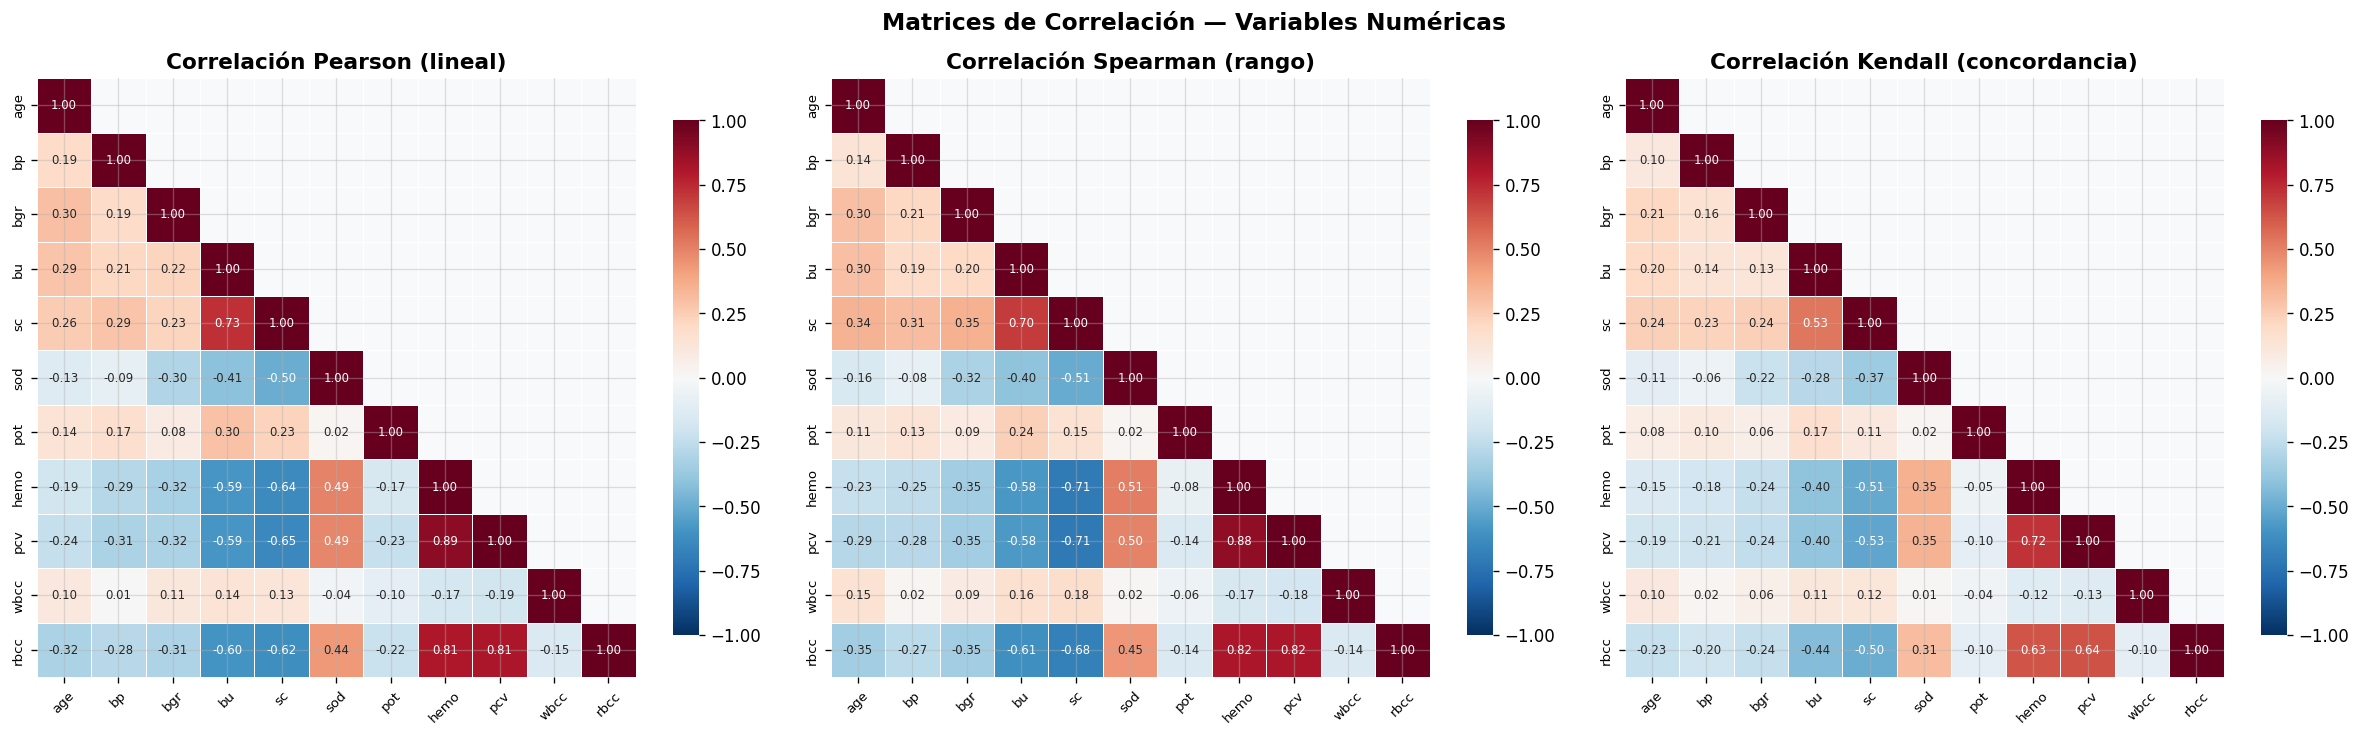

In [20]:
# Matriz de correlación para variables numéricas (datos procesados)
X_num = df_proc[NUMERIC_COLS]

corr_pearson  = X_num.corr(method='pearson')
corr_spearman = X_num.corr(method='spearman')
corr_kendall  = X_num.corr(method='kendall')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, corr_mat, title in zip(
    axes,
    [corr_pearson, corr_spearman, corr_kendall],
    ['Pearson (lineal)', 'Spearman (rango)', 'Kendall (concordancia)']
):
    mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
    sns.heatmap(corr_mat, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, mask=mask, square=True,
                linewidths=0.3, annot_kws={'size': 7},
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'Correlación {title}', fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Matrices de Correlación — Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<div class="alert alert-success">
La matriz de correlación de Pearson evalúa las dependencias lineales por pares entre todas las características. 
Desde la perspectiva del reconocimiento de patrones, este análisis nos revela la estructura interna de la matriz de covarianza (sigma)
permitiéndonos identificar redundancias geométricas y evaluar el poder discriminante conjunto.
</div>

#### Multicolinealidad

Observamos un bloque de alta correlación positiva (colores rojos intensos, $\rho > 0.8$) entre variables hematológicas: hemoglobina (`hemo`), volumen celular empacado (`pcv`) y, en menor medida, el conteo de glóbulos rojos (`rbcc`). UNa correlación cercana a 1 implica que los vectores de estas características apuntan prácticamente en la misma dirección en el hiperespacio $\mathbb{R}^d$. Según Duda et al. (2001), el libro guía, esto significa que añadir pcv a un modelo que ya contiene hemo aporta muy poca información nueva para la clasificación. Esta alta redundancia infla la dimensionalidad del problema sin mejorar la separabilidad y puede causar inestabilidad numérica al invertir la matriz de covarianza $\mathbf{\Sigma}^{-1}$ en los clasificadores paramétricos.

#### Correlación con la Clase

Si observamos la fila/columna correspondiente a nuestra variable objetivo (`class`), vemos fuertes correlaciones (tanto positivas como negativas) con variables como gravedad específica (`sg`), albúmina (`al`), hipertensión (`htn`), hemoglobina (`hemo`) y `pcv`. Las variables que presentan una alta correlación (en valor absoluto) con la etiqueta de clase son aquellas que mejor alinean su varianza con la frontera de decisión.


#### Clasificadores "Naive" (Supuesto de Independencia)

Un clasificador paramétrico es el Naive Bayes, el cual asume matemáticamente que todas las características son estadísticamente independientes dado la clase:

$$p(\mathbf{x}|\omega_i) = \prod_{j=1}^d p(x_j|\omega_i)$$

Esta matriz de correlación demuestra empíricamente que este supuesto es falso para nuestro dataset. Las variables están altamente acopladas. Si decidimos utilizar un clasificador Naive Bayes en la Fase 02, el modelo multiplicará la misma información varias veces, sesgando severamente las probabilidades a posteriori.



<h3 style="color:#2E86C1;"> Correlación de Pearson</h3>

En la teoría de Pattern Classification (Duda, Hart & Stork, 2001), una alta correlación punto-biserial (en valor absoluto) indica que la distancia entre las medias de ambas clases es muy grande en comparación con sus varianzas internas. Variables como la hemoglobina (hemo, $\rho \approx 0.7$), el volumen celular empacado (pcv, $\rho \approx 0.7$) y la gravedad específica (sg, $\rho \approx 0.65$) tienen la mayor magnitud. Esto significa que si proyectáramos los datos usando una sola de estas variables, obtendríamos la mejor separación lineal posible sin necesidad de combinarlas.

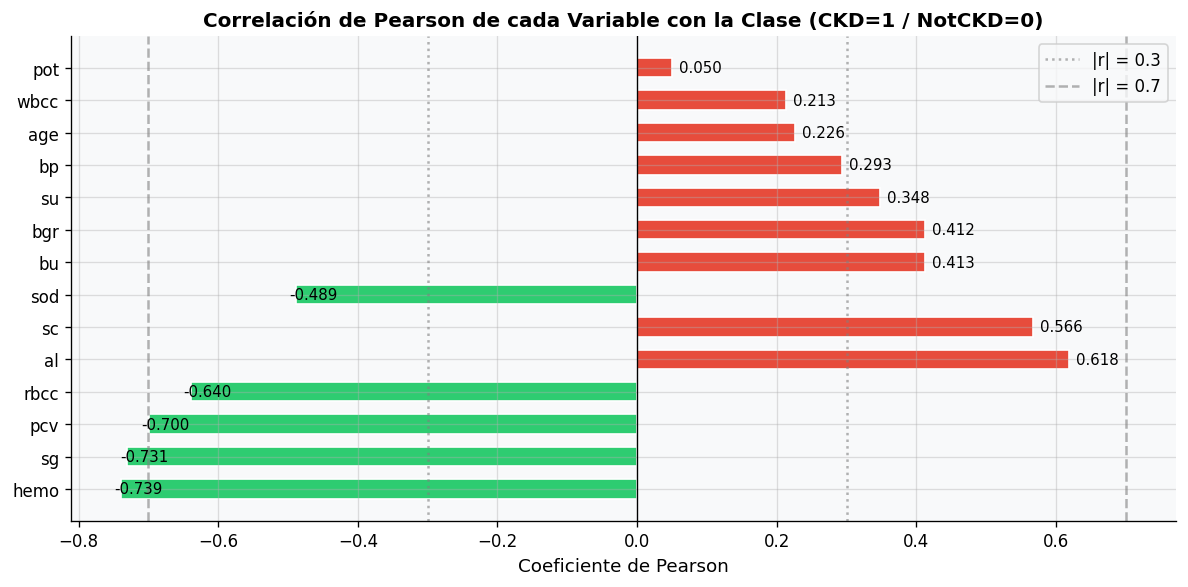


Top 5 variables más correlacionadas con CKD:
hemo   -0.739198
sg     -0.730928
pcv    -0.699674
rbcc   -0.639531
al      0.618143
Name: label, dtype: float64


In [21]:
# Correlación de cada variable numérica con la clase (label)
X_all_num = df_proc[NUMERIC_COLS + ORDINAL_COLS].copy()
X_all_num['label'] = df_proc['label']

corr_target = X_all_num.corr()['label'].drop('label').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = [COLOR_CKD if v > 0 else COLOR_NOTCKD for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors_bar, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.3,  color='gray', linestyle=':', alpha=0.6, label='|r| = 0.3')
ax.axvline(-0.3, color='gray', linestyle=':', alpha=0.6)
ax.axvline(0.7,  color='gray', linestyle='--', alpha=0.6, label='|r| = 0.7')
ax.axvline(-0.7, color='gray', linestyle='--', alpha=0.6)
for i, (idx, val) in enumerate(corr_target.items()):
    ax.text(val + 0.01*np.sign(val), i, f'{val:.3f}', va='center', fontsize=9)
ax.set_title('Correlación de Pearson de cada Variable con la Clase (CKD=1 / NotCKD=0)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coeficiente de Pearson')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 variables más correlacionadas con CKD:')
print(corr_target.head(5))

El potasio (pot), la edad (age) y el conteo de glóbulos blancos (wbcc) muestran correlaciones muy bajas ($|\rho| < 0.2$). Geométricamente, esto significa que las distribuciones de pacientes sanos y enfermos están fuertemente traslapadas en estas dimensiones. Incluirlas sin procesar en modelos sensibles al ruido (como $k$-NN) podría degradar el rendimiento.

<h3 style="color:#2E86C1;"> Scatter Matrix</h3>

<div class="alert alert-info">
La Scatter Matrix (matriz de dispersión) es una herramienta estadística fundamental para analizar la relación entre múltiples variables numéricas en un conjunto de datos. Es una cuadrícula de gráficos de dispersión donde cada celda muestra la relación entre un par de variables. Su importancia radica en que permite una exploración visual y matemática rápida de la estructura de los datos.

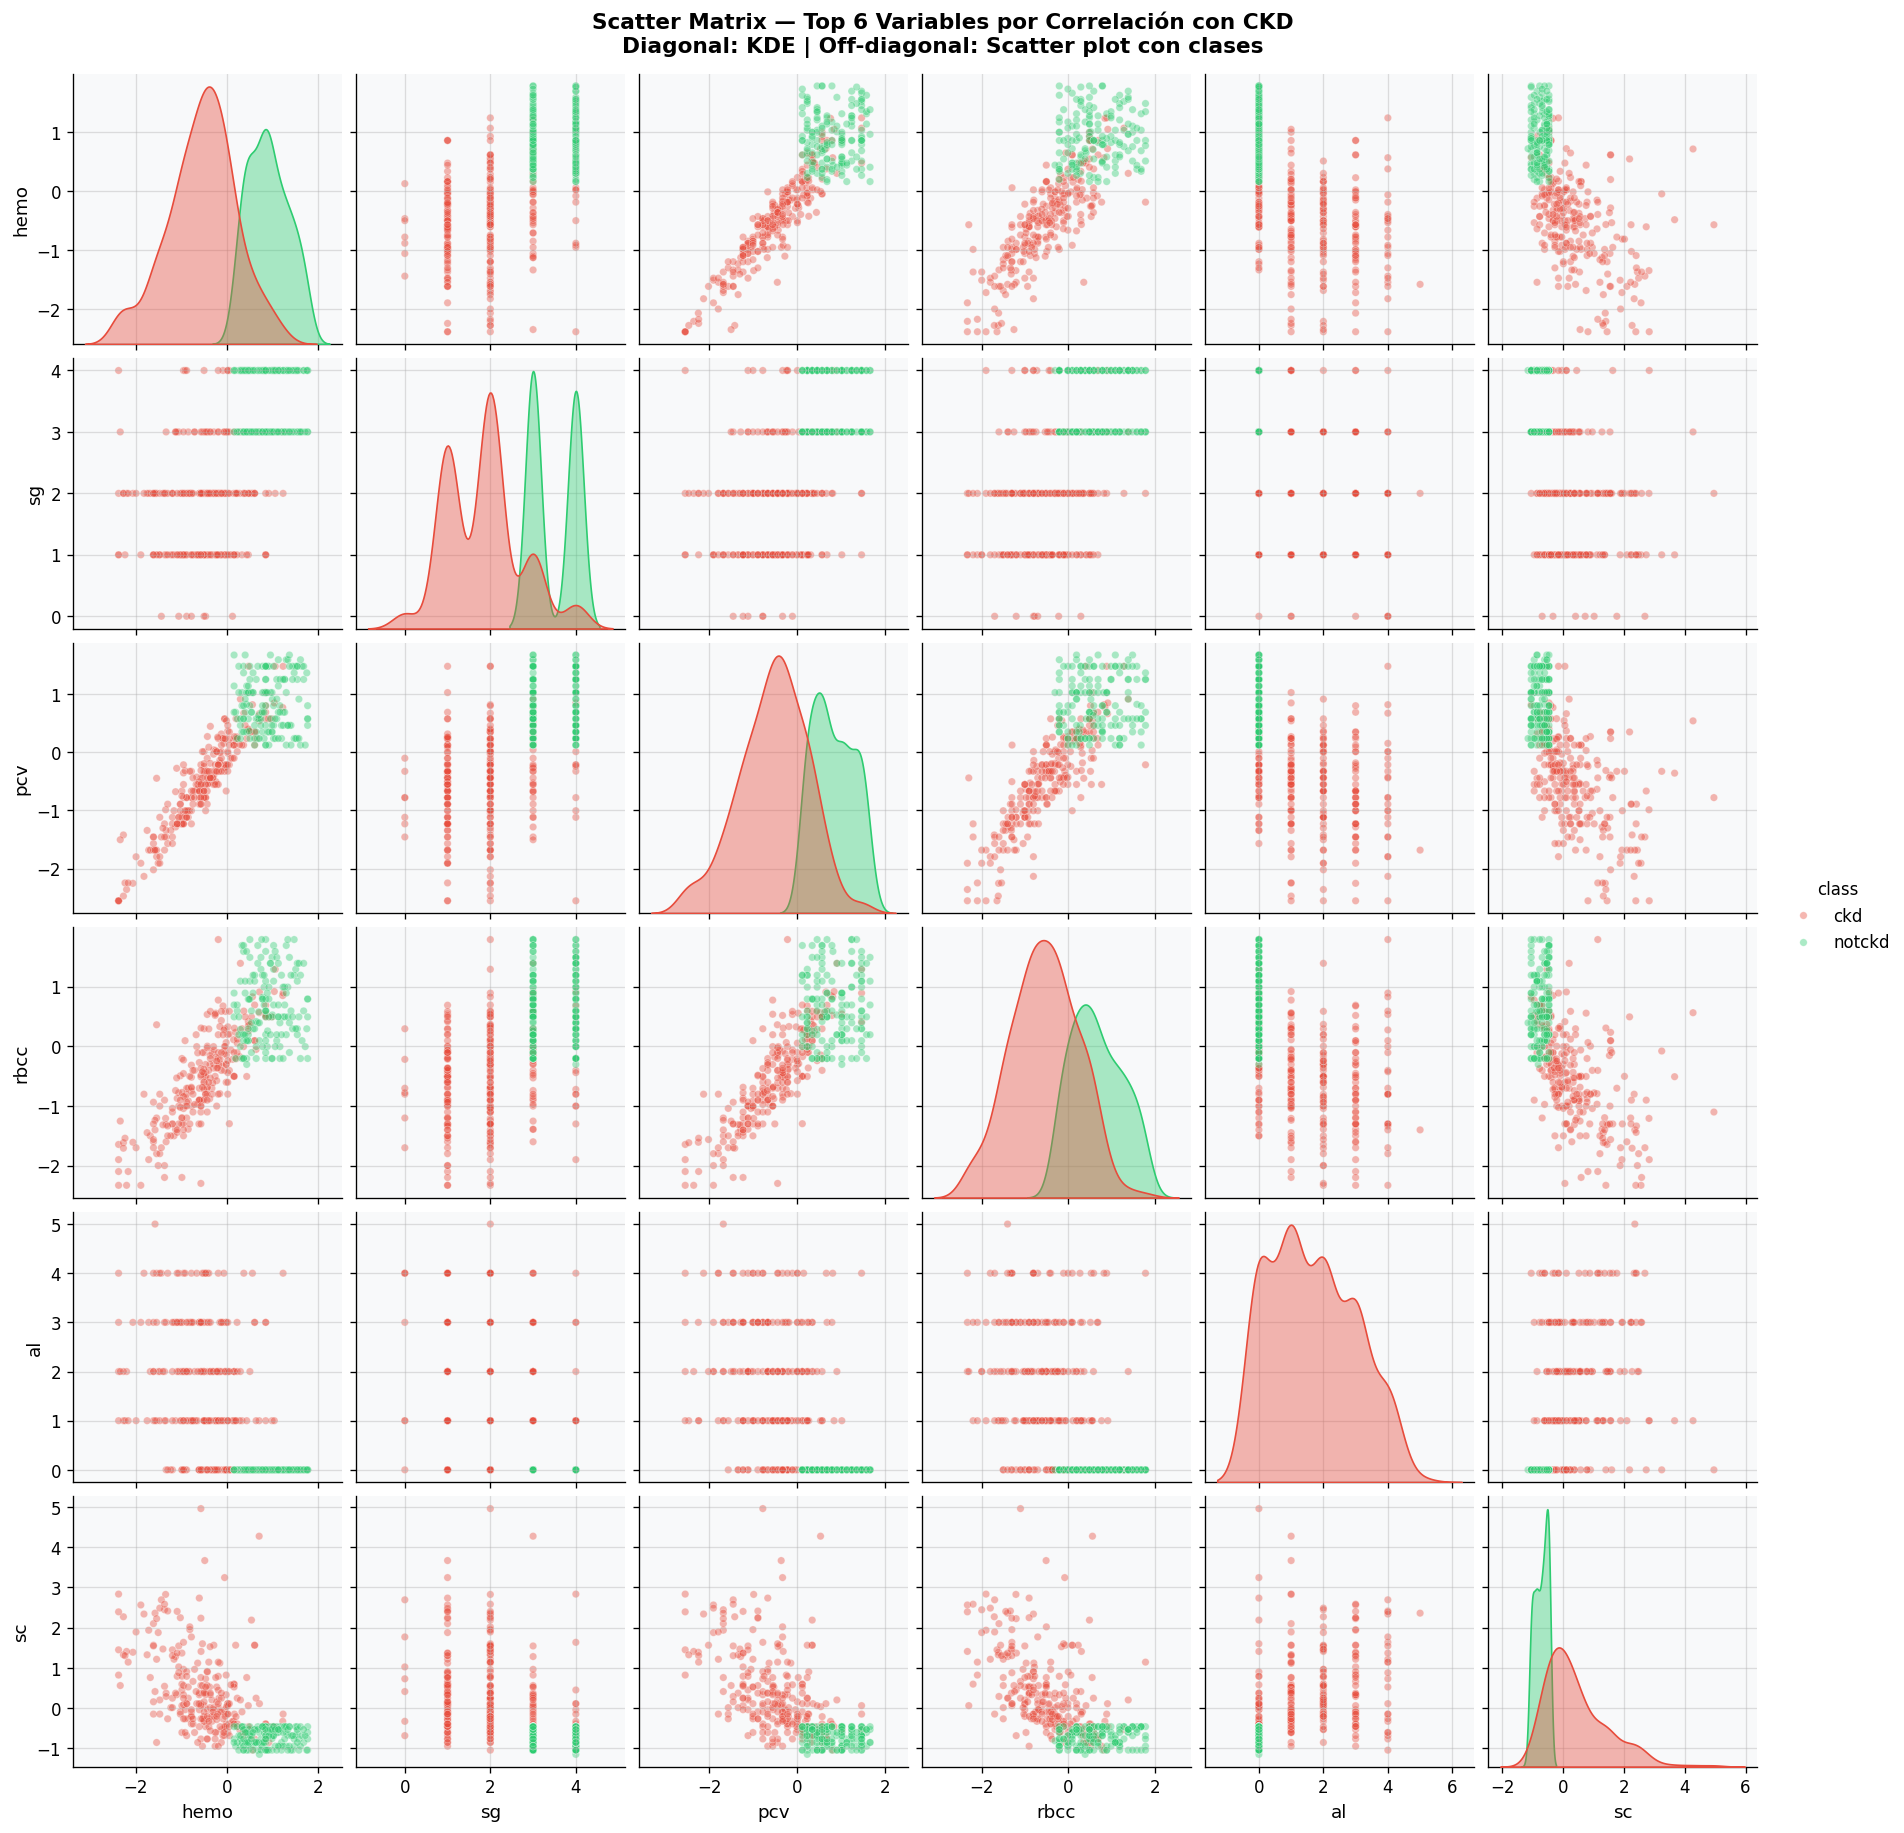

In [22]:
# Scatter matrix (pairplot) para las variables más correlacionadas con la clase
top_vars = corr_target.abs().nlargest(6).index.tolist()

# Pairplot con KDE en diagonal
subset = df_proc[top_vars + [TARGET_COL]].copy()
g = sns.pairplot(
    subset, hue=TARGET_COL,
    palette={'ckd': COLOR_CKD, 'notckd': COLOR_NOTCKD},
    diag_kind='kde', plot_kws={'alpha': 0.4, 's': 20},
    diag_kws={'fill': True, 'alpha': 0.4}
)
g.fig.suptitle('Scatter Matrix — Top 6 Variables por Correlación con CKD\n'
               'Diagonal: KDE | Off-diagonal: Scatter plot con clases',
               y=1.02, fontsize=13, fontweight='bold')
plt.show()

#### Alta Separabilidad Lineal (El Traslape de Densidades)

Al observar los cruces entre variables hematológicas (`hemo`, `pcv`) y variables urinarias (`sg`, `al`), es evidente que las dos clases (pacientes sanos y pacientes con CKD) ocupan regiones del espacio mutuamente excluyentes. Las nubes de puntos apenas se tocan. Según la teoría de decisión de Bayes, el error de clasificación está acotado por el área de intersección de las densidades de probabilidad $p(\mathbf{x}|\omega_i)$. Dado que visualmente este traslape es mínimo en estas proyecciones bidimensionales, podemos garantizar teóricamente que un clasificador no tan complejo, guiado por esas características, lograría un rendimiento base relativamente bueno.

#### Confirmación Geométrica de la Heterocedasticidad

Este gráfico materializa el concepto de varianzas desiguales ($\mathbf{\Sigma}_0 \neq \mathbf{\Sigma}_1$) que se venía observando en los boxplots:

* Clase 1 (Sanos): Se comportan como un clúster sumamente denso y compacto. Su volumen espacial es minúsculo.
* Clase 0 (CKD): Se esparcen como una nube amplia y difusa a lo largo de los ejes.

Si intentamos separar estas dos nubes con un hiperplano recto (Análisis Discriminante Lineal - LDA), forzaremos al modelo a promediar estas dos geometrías tan distintas, lo que desplazará la frontera de forma subóptima hacia el clúster denso. La geometría nos confirma que la frontera matemática natural entre un punto denso y una nube dispersa es curva. Esto justifica formalmente priorizar el Análisis Discriminante Cuadrático (QDA) o clasificadores no paramétricos ($k$-NN) que se adapten a la densidad local.

#### Redundancia Geométrica (El caso hemo vs pcv)

Al observar la intersección entre la hemoglobina (`hemo`) y el volumen celular empacado (`pcv`), los puntos forman una línea recta diagonal casi perfecta. Mantener ambas variables en el modelo aumenta la dimensionalidad $d$ del vector $\mathbf{x}$ sin aportar información discriminante nueva. Esta línea recta es la prueba visual de que necesitamos aplicar el Análisis de Componentes Principales (PCA). PCA identificará este eje diagonal como el "Primer Componente Principal", permitiéndonos fusionar matemáticamente `hemo` y `pcv` en una sola dimensión sin perder capacidad de separación.

<h2 style="color:#2E86C1;"> 5. Matrices de Covarianza por Clase</h2>

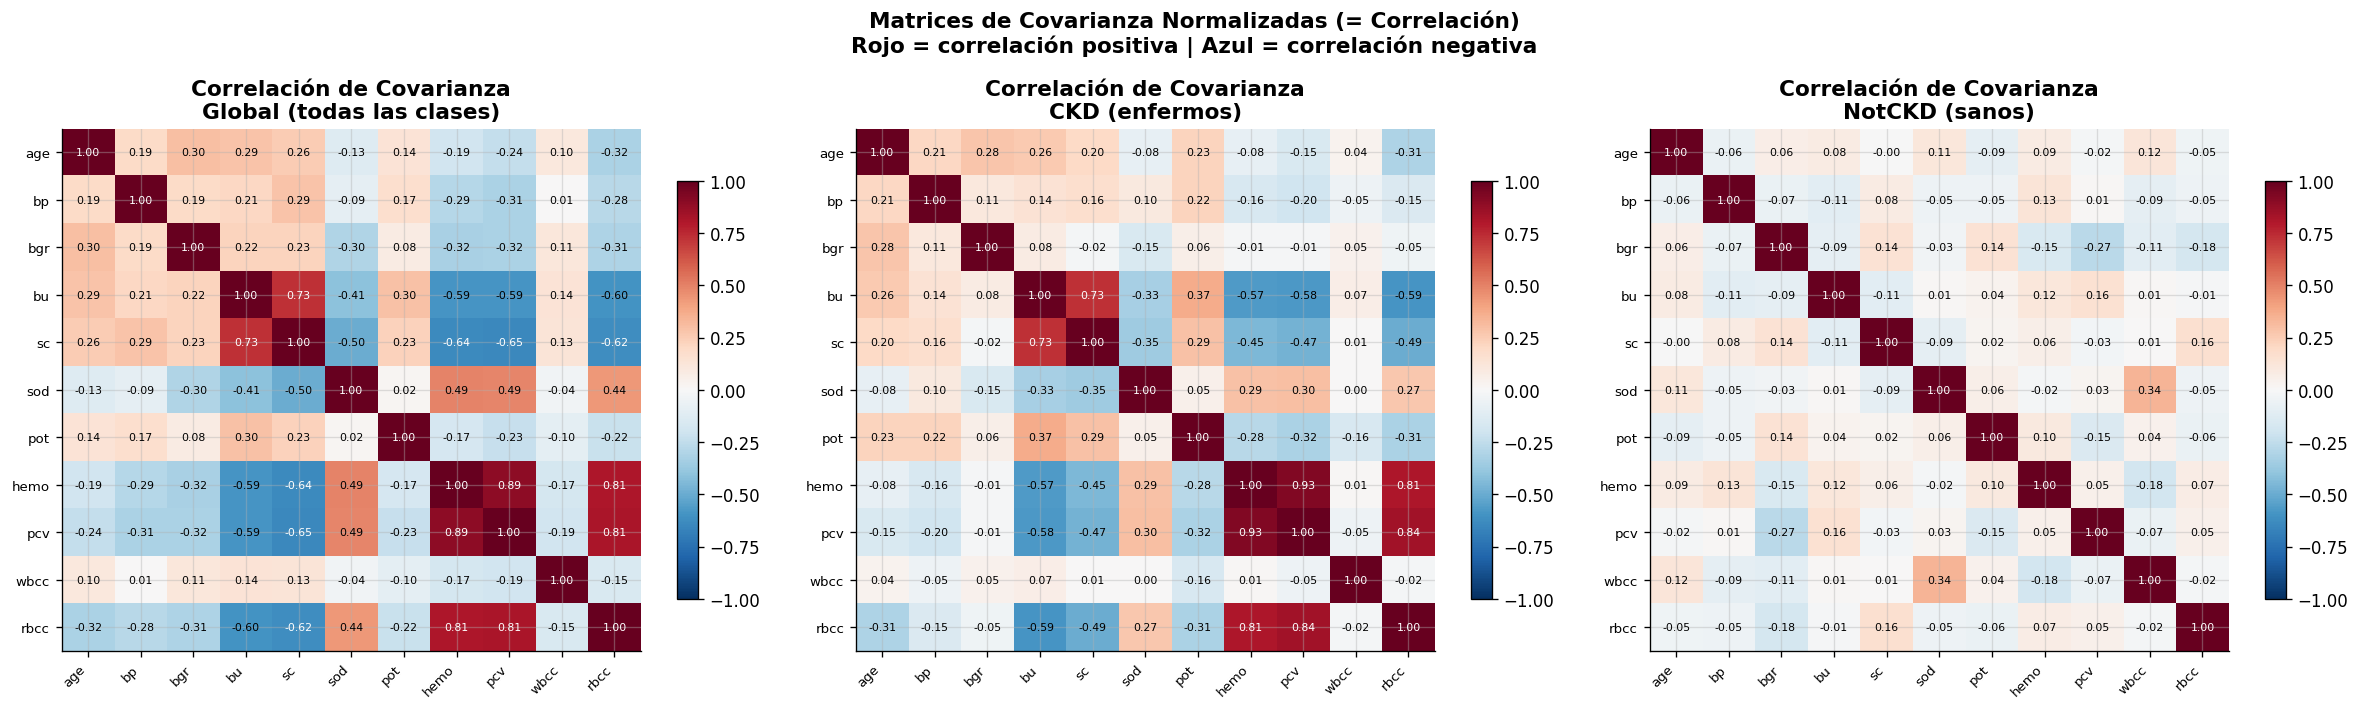

In [23]:
# Matriz de covarianza para variables numéricas por clase (datos procesados)
X_ckd    = df_ckd[NUMERIC_COLS].values
X_notckd = df_notckd[NUMERIC_COLS].values
X_all    = df_proc[NUMERIC_COLS].values

cov_global = np.cov(X_all.T)
cov_ckd    = np.cov(X_ckd.T)
cov_notckd = np.cov(X_notckd.T)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, cov_mat, title in zip(
    axes,
    [cov_global, cov_ckd, cov_notckd],
    ['Global (todas las clases)', 'CKD (enfermos)', 'NotCKD (sanos)']
):
    # Normalizar para visualización
    diag = np.sqrt(np.diag(cov_mat))
    corr_from_cov = cov_mat / np.outer(diag, diag)
    
    im = ax.imshow(corr_from_cov, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    for i in range(len(NUMERIC_COLS)):
        for j in range(len(NUMERIC_COLS)):
            ax.text(j, i, f'{corr_from_cov[i,j]:.2f}',
                    ha='center', va='center', fontsize=6.5,
                    color='white' if abs(corr_from_cov[i,j]) > 0.6 else 'black')
    
    ax.set_xticks(range(len(NUMERIC_COLS)))
    ax.set_yticks(range(len(NUMERIC_COLS)))
    ax.set_xticklabels(NUMERIC_COLS, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(NUMERIC_COLS, fontsize=8)
    ax.set_title(f'Correlación de Covarianza\n{title}', fontweight='bold')

plt.suptitle('Matrices de Covarianza Normalizadas (= Correlación)\n'
             'Rojo = correlación positiva | Azul = correlación negativa',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

El cálculo de las matrices de covarianza separadas por clase, $\mathbf{\Sigma}_0$ y $\mathbf{\Sigma}_1$, constituye el análisis geométrico más profundo de nuestro Análisis Exploratorio de Datos. En la teoría de Pattern Classification (Duda, Hart & Stork, 2001), la matriz de covarianza define la forma, el tamaño y la orientación de la "nube" de datos (el hiperelipsoide) de cada clase en el espacio $d$-dimensional.

Visualmente es innegable que $\mathbf{\Sigma}_0 \neq \mathbf{\Sigma}_1$.La matriz de la Clase 1 (pacientes sanos) presenta varianzas y covarianzas de magnitudes muy bajas, indicando una distribución extremadamente compacta y esférica.La matriz de la Clase 0 (pacientes con CKD) muestra una alta dispersión estructural y dependencias lineales fuertes (colores más intensos), indicando una distribución amplia y elíptica.

Esta desigualdad geométrica tiene un impacto directo en la función discriminante óptima de Bayes. Si asumimos distribuciones Gaussianas, la frontera de decisión está dada por:

$$g_i(\mathbf{x}) = -\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu}_i)^T \mathbf{\Sigma}_i^{-1}(\mathbf{x}-\boldsymbol{\mu}_i) - \frac{1}{2}\ln|\mathbf{\Sigma}_i| + \ln P(\omega_i)$$

El LDA asume estrictamente que $\mathbf{\Sigma}_0 = \mathbf{\Sigma}_1 = \mathbf{\Sigma}$. Si forzamos esta suposición, el algoritmo promediará ambas matrices, creando una forma geométrica ficticia que no representa ni a los sanos ni a los enfermos, trazando una frontera lineal subóptima.

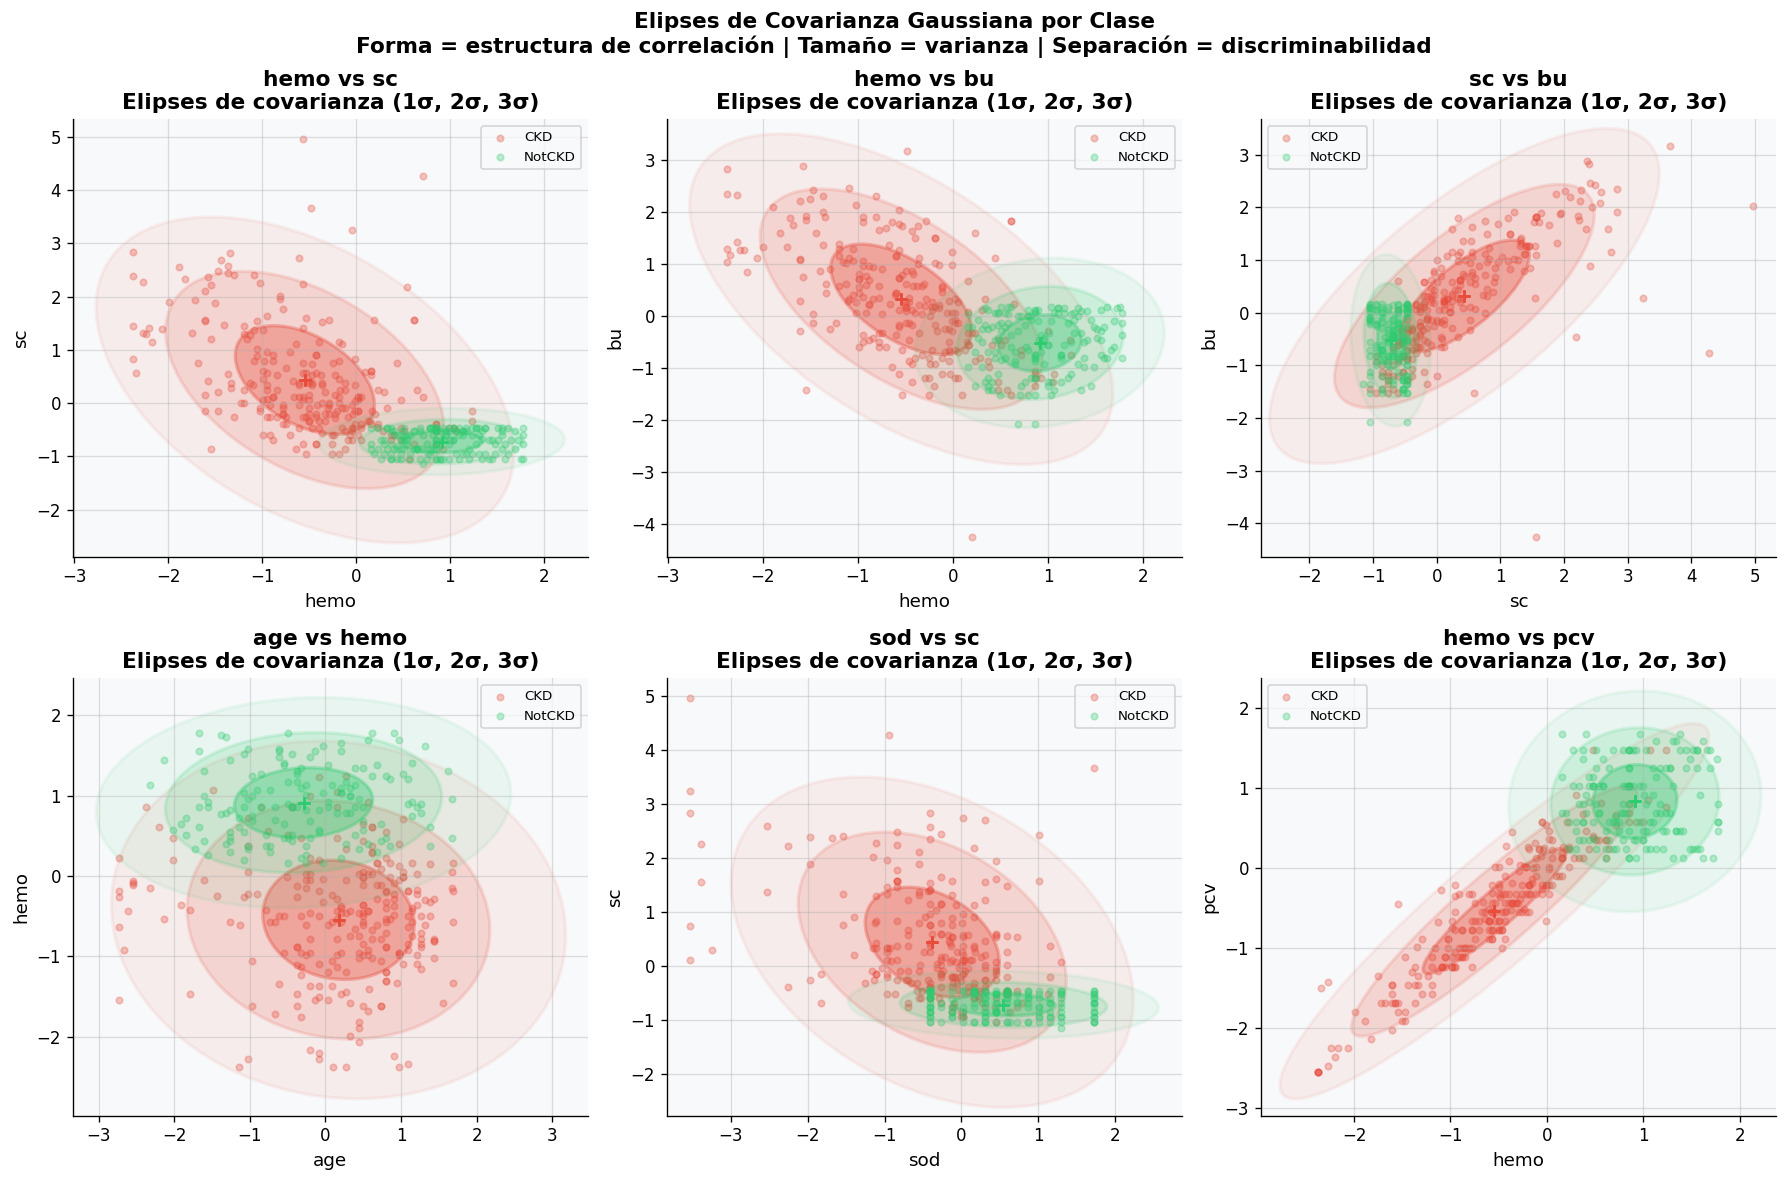

In [24]:
# Elipses de covarianza son una herramienta visual para entender la distribución conjunta de dos variables.
# Para pares de variables, los isocontornos gaussianos son elipses cuya forma
# depende de la matriz de covarianza. Aquí los visualizamos.

from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def plot_cov_ellipse(ax, mean, cov, n_std=2, color='blue', label='', alpha=0.25):
    """Dibuja la elipse de covarianza para 2 variables."""
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      facecolor=color, alpha=alpha, edgecolor=color, linewidth=2)
    ax.add_patch(ellipse)
    ax.scatter(*mean, color=color, s=60, zorder=5, marker='+')

# Seleccionar los 6 pares más informativos
pairs = [('hemo','sc'), ('hemo','bu'), ('sc','bu'), ('age','hemo'), ('sod','sc'), ('hemo','pcv')]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (v1, v2) in enumerate(pairs):
    ax = axes[idx]
    i1, i2 = NUMERIC_COLS.index(v1), NUMERIC_COLS.index(v2)
    
    for cls, color, label, X_cls in [
        ('ckd',    COLOR_CKD,    'CKD',    X_ckd),
        ('notckd', COLOR_NOTCKD, 'NotCKD', X_notckd)
    ]:
        data2d = X_cls[:, [i1, i2]]
        mu  = data2d.mean(axis=0)
        cov = np.cov(data2d.T)
        ax.scatter(data2d[:, 0], data2d[:, 1], color=color, alpha=0.3, s=15, label=label)
        for n_std, alpha in [(1, 0.35), (2, 0.15), (3, 0.07)]:
            plot_cov_ellipse(ax, mu, cov, n_std=n_std, color=color, alpha=alpha)
    
    ax.set_xlabel(v1)
    ax.set_ylabel(v2)
    ax.set_title(f'{v1} vs {v2}\nElipses de covarianza (1σ, 2σ, 3σ)', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Elipses de Covarianza Gaussiana por Clase\n'
             'Forma = estructura de correlación | Tamaño = varianza | Separación = discriminabilidad',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Las elipses que vemos en el gráfico funcionan como un mapa de los datos. Vistas desde la teoría de probabilidad, representan las fronteras donde la densidad de pacientes es igual. El borde de la elipse dibuja una "cerca" alrededor del centro de la clase: cualquier paciente que esté parado sobre esa línea se considera igual de "lejano" o "raro" respecto al paciente promedio de su grupo (lo que conocemos como *Distancia de Mahalanobis*). Entonces, el borde de cada elipse representa el lugar geométrico de los puntos que tienen la misma distancia de Mahalanobis respecto a la media de su clase $\boldsymbol{\mu}_i$:

$$(\mathbf{x}-\boldsymbol{\mu}_i)^T \mathbf{\Sigma}_i^{-1} (\mathbf{x}-\boldsymbol{\mu}_i) = c^2$$

El área que ocupa cada elipse se calcula matemáticamente con el determinante de la matriz de covarianza ($|\mathbf{\Sigma}_i|$).  

* Clase 1 (Sanos): Sus elipses son minúsculas, casi colapsadas en puntos. Esto indica que $|\mathbf{\Sigma}_1| \approx 0$, es decir, los pacientes sanos tienen una variabilidad casi nula; sus valores fisiológicos están estrictamente controlados por la homeostasis del cuerpo.

* Clase 0 (CKD): Sus elipses son gigantescas. El determinante $|\mathbf{\Sigma}_0|$ es enorme, reflejando caos fisiológico y la altísima dispersión de los pacientes enfermos.

La orientación de la elipse está definida por los autovectores de $\mathbf{\Sigma}_i$, y su "estiramiento" por los autovalores $\lambda$.
En gráficas como `hemo` vs `pcv`, vemos que las elipses rojas están fuertemente estiradas en diagonal. Esto prueba la alta covarianza positiva entre ambas variables para la clase enferma. Por el contrario, las elipses verdes tienden a ser más circulares o estar orientadas de forma distinta, **confirmando que la estructura de correlación interna cambia dependiendo de si el paciente está sano o enfermo**.

La teoría de decisión de Bayes establece que la frontera de decisión óptima es el lugar donde las densidades se igualan: $P(\omega_0|\mathbf{x}) = P(\omega_1|\mathbf{x})$. Si asumiéramos que las elipses tienen exactamente el mismo tamaño y forma orientada en la misma dirección ($\mathbf{\Sigma}_0 = \mathbf{\Sigma}_1$), la intersección de sus densidades formaría una línea recta (Discriminante Lineal - LDA). Al evidenciar visualmente que la elipse roja "envuelve" o difiere drásticamente en tamaño y forma de la elipse verde ($\mathbf{\Sigma}_0 \neq \mathbf{\Sigma}_1$), la intersección entre un paraboloide ancho y uno estrecho genera una frontera curva.


In [25]:
# Análisis de varianzas y medias por clase 
summary = pd.DataFrame(index=NUMERIC_COLS)
summary['Media CKD']    = df_ckd[NUMERIC_COLS].mean().round(3)
summary['Media NotCKD'] = df_notckd[NUMERIC_COLS].mean().round(3)
summary['Std CKD']      = df_ckd[NUMERIC_COLS].std().round(3)
summary['Std NotCKD']   = df_notckd[NUMERIC_COLS].std().round(3)
summary['Δ Media']      = (summary['Media CKD'] - summary['Media NotCKD']).round(3)

# Prueba t de Student para diferencia de medias
t_tests = []
for col in NUMERIC_COLS:
    t_stat, p_val = stats.ttest_ind(df_ckd[col], df_notckd[col], equal_var=False)
    t_tests.append({'t-stat': round(t_stat, 3), 'p-value': round(p_val, 6),
                    'Sig (α=0.01)': '✅' if p_val < 0.01 else '❌'})

summary = pd.concat([summary, pd.DataFrame(t_tests, index=NUMERIC_COLS)], axis=1)

print('Comparación de medias y varianzas por clase (Welch t-test):')
display(summary)

Comparación de medias y varianzas por clase (Welch t-test):


,Media CKD,Media NotCKD,Std CKD,Std NotCKD,Δ Media,t-stat,p-value,Sig (α=0.01)
age,0.172,-0.291,1.002,0.915,0.463,4.729,0.000003,✅
bp,0.217,-0.382,1.073,0.696,0.599,6.771,0.000000,✅
bgr,0.292,-0.525,1.065,0.404,0.817,10.899,0.000000,✅
bu,0.316,-0.525,1.060,0.544,0.841,10.469,0.000000,✅
sc,0.435,-0.723,1.021,0.209,1.158,17.336,0.000000,✅
sod,-0.380,0.547,0.872,0.672,-0.927,-11.914,0.000000,✅
pot,0.021,-0.074,0.987,0.765,0.095,1.071,0.284954,❌
hemo,-0.545,0.913,0.742,0.437,-1.458,-24.742,0.000000,✅
pcv,-0.539,0.831,0.781,0.460,-1.370,-22.075,0.000000,✅
wbcc,0.135,-0.256,0.979,0.657,0.391,4.776,0.000003,✅


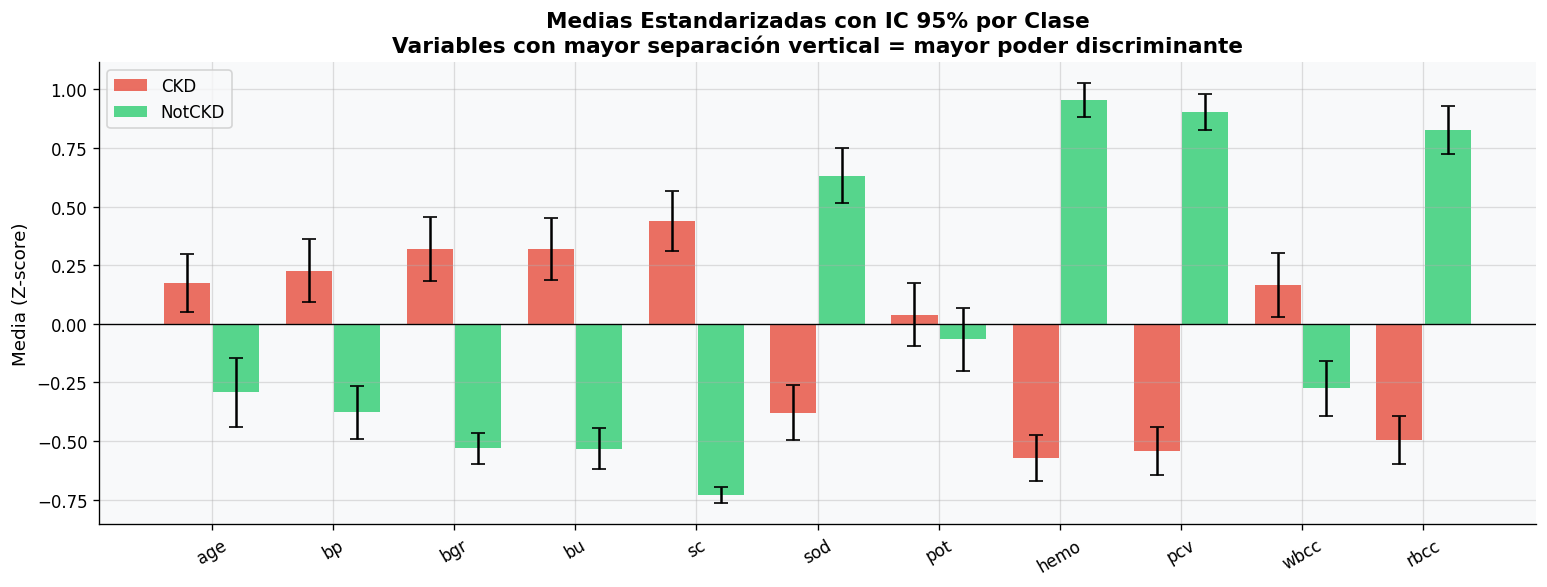

In [26]:
# ── 6.4 Visualización de medias con intervalos de confianza ───────────────────
# Normalizar para comparar en misma escala
scaler_cmp = StandardScaler()
means_ckd    = pd.Series(dict(zip(NUMERIC_COLS,
                 scaler_cmp.fit_transform(df_proc[NUMERIC_COLS])[df_proc['label']==1].mean(axis=0))),
                 name='CKD')
means_notckd = pd.Series(dict(zip(NUMERIC_COLS,
                 scaler_cmp.fit_transform(df_proc[NUMERIC_COLS])[df_proc['label']==0].mean(axis=0))),
                 name='NotCKD')

X_scaled_all = scaler_cmp.fit_transform(df_proc[NUMERIC_COLS])

ci_ckd    = stats.sem(X_scaled_all[df_proc['label'].values==1], axis=0) * 1.96
ci_notckd = stats.sem(X_scaled_all[df_proc['label'].values==0], axis=0) * 1.96

means_ckd_v    = X_scaled_all[df_proc['label'].values==1].mean(axis=0)
means_notckd_v = X_scaled_all[df_proc['label'].values==0].mean(axis=0)

x = np.arange(len(NUMERIC_COLS))
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - 0.2, means_ckd_v, 0.38, yerr=ci_ckd, color=COLOR_CKD, alpha=0.8,
       capsize=4, label='CKD', error_kw={'linewidth':1.5})
ax.bar(x + 0.2, means_notckd_v, 0.38, yerr=ci_notckd, color=COLOR_NOTCKD, alpha=0.8,
       capsize=4, label='NotCKD', error_kw={'linewidth':1.5})
ax.set_xticks(x)
ax.set_xticklabels(NUMERIC_COLS, rotation=30)
ax.set_title('Medias Estandarizadas con IC 95% por Clase\n'
             'Variables con mayor separación vertical = mayor poder discriminante',
             fontweight='bold')
ax.set_ylabel('Media (Z-score)')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

<h2 style="color:#2E86C1;"> 6. PCA: Reducción Dimensional y Visualización</h2>

El Análisis de Componentes Principales es una transformación lineal estricta descrita por la ecuación $\mathbf{y} = \mathbf{W}^T \mathbf{x}$, donde $\mathbf{y}$ es el vector en el nuevo espacio reducido, $\mathbf{x}$ es el vector de características original (estandarizado) y $\mathbf{W}$ es la matriz de proyección ortogonal.

In [27]:
# ── 7.1 Estandarización y ajuste del PCA completo ────────────────────────────
scaler_pca = StandardScaler()
X_pca_input = df_proc[NUMERIC_COLS].values
X_std = scaler_pca.fit_transform(X_pca_input)
y_labels = df_proc['label'].values
y_names  = df_proc[TARGET_COL].values

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_std)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
n_components = len(NUMERIC_COLS)

print('Varianza explicada por componente:')
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var)):
    bar = '█' * int(ev * 50)
    print(f'  PC{i+1:02d}: {ev*100:5.2f}%  (acumulado: {cv*100:5.2f}%)  {bar}')

Varianza explicada por componente:
  PC01: 42.09%  (acumulado: 42.09%)  █████████████████████
  PC02: 10.72%  (acumulado: 52.81%)  █████
  PC03:  9.85%  (acumulado: 62.67%)  ████
  PC04:  8.50%  (acumulado: 71.17%)  ████
  PC05:  7.66%  (acumulado: 78.83%)  ███
  PC06:  6.47%  (acumulado: 85.30%)  ███
  PC07:  5.55%  (acumulado: 90.84%)  ██
  PC08:  4.14%  (acumulado: 94.98%)  ██
  PC09:  2.27%  (acumulado: 97.25%)  █
  PC10:  1.80%  (acumulado: 99.05%)  
  PC11:  0.95%  (acumulado: 100.00%)  


La primera barra (Componente 0) **explica por sí sola más del 40% de la varianza total del sistema**.Este componente representa el eje más largo del elipse global de los datos. Es altamente probable que este componente sea una combinación lineal dominada por las variables que estaban fuertemente correlacionadas, como la hemoglobina (`hemo`) y el volumen celular empacado (`pcv`). PCA fusiona la redundancia en una sola dimensión matemática.

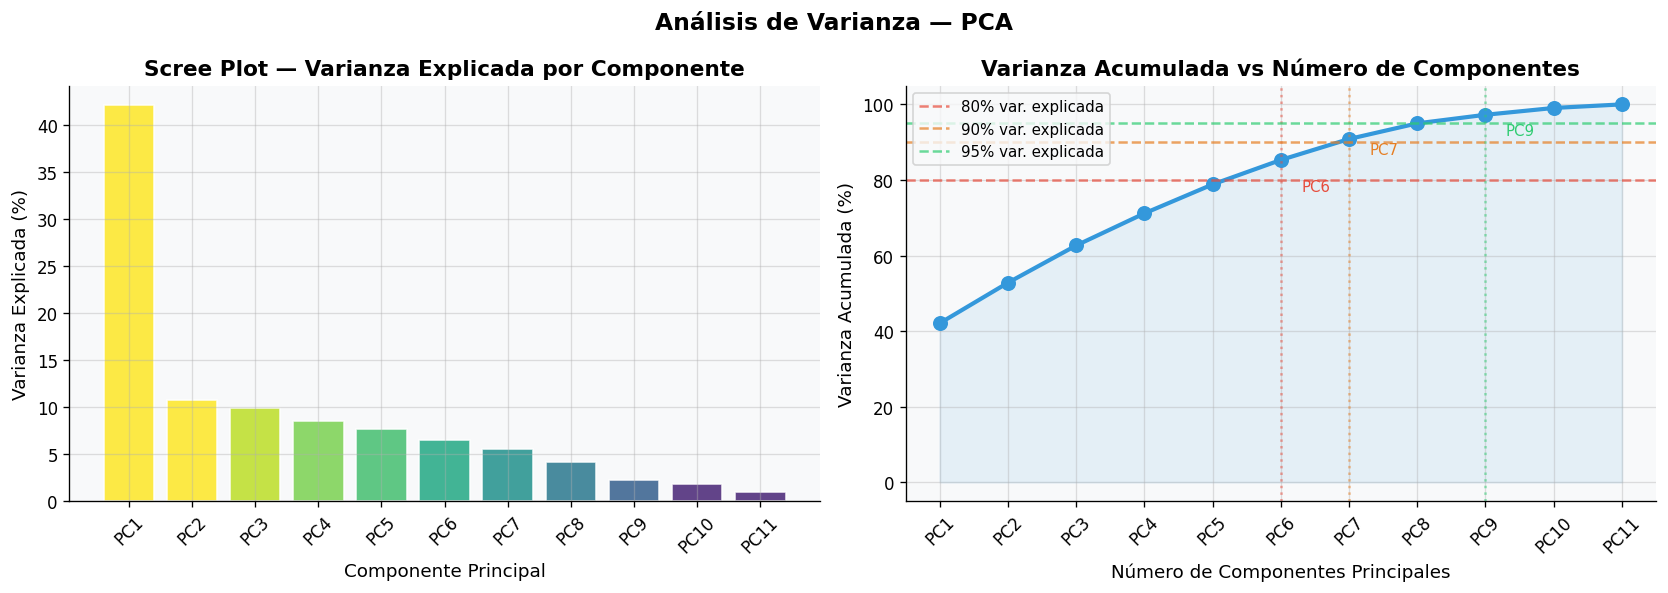

In [28]:
# ── 7.2 Scree plot y varianza acumulada ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Generar lista de colores desde el colormap
cmap_obj  = plt.cm.get_cmap(CMAP_SEQ, n_components)
bar_colors = [cmap_obj(1 - k / n_components) for k in range(n_components)]

comp_nums = range(1, n_components + 1)
axes[0].bar(comp_nums, explained_var * 100, color=bar_colors,
            alpha=0.85, edgecolor='white')
axes[0].set_title('Scree Plot — Varianza Explicada por Componente', fontweight='bold')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_xticks(comp_nums)
axes[0].set_xticklabels([f'PC{i}' for i in comp_nums], rotation=45)

# Varianza acumulada
axes[1].plot(comp_nums, cumulative_var * 100, 'o-', color='#3498DB', linewidth=2.5, markersize=8)
for thresh, color, label in [(0.80, '#E74C3C', '80%'), (0.90, '#E67E22', '90%'), (0.95, '#2ECC71', '95%')]:
    axes[1].axhline(thresh*100, color=color, linestyle='--', alpha=0.7, label=f'{label} var. explicada')
    n_needed = np.argmax(cumulative_var >= thresh) + 1
    axes[1].axvline(n_needed, color=color, linestyle=':', alpha=0.5)
    axes[1].annotate(f'PC{n_needed}', xy=(n_needed, thresh*100),
                     xytext=(n_needed+0.3, thresh*100-3), fontsize=9, color=color)
axes[1].fill_between(comp_nums, cumulative_var*100, alpha=0.1, color='#3498DB')
axes[1].set_title('Varianza Acumulada vs Número de Componentes', fontweight='bold')
axes[1].set_xlabel('Número de Componentes Principales')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_xticks(comp_nums)
axes[1].set_xticklabels([f'PC{i}' for i in comp_nums], rotation=45)
axes[1].legend(fontsize=9)

plt.suptitle('Análisis de Varianza — PCA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

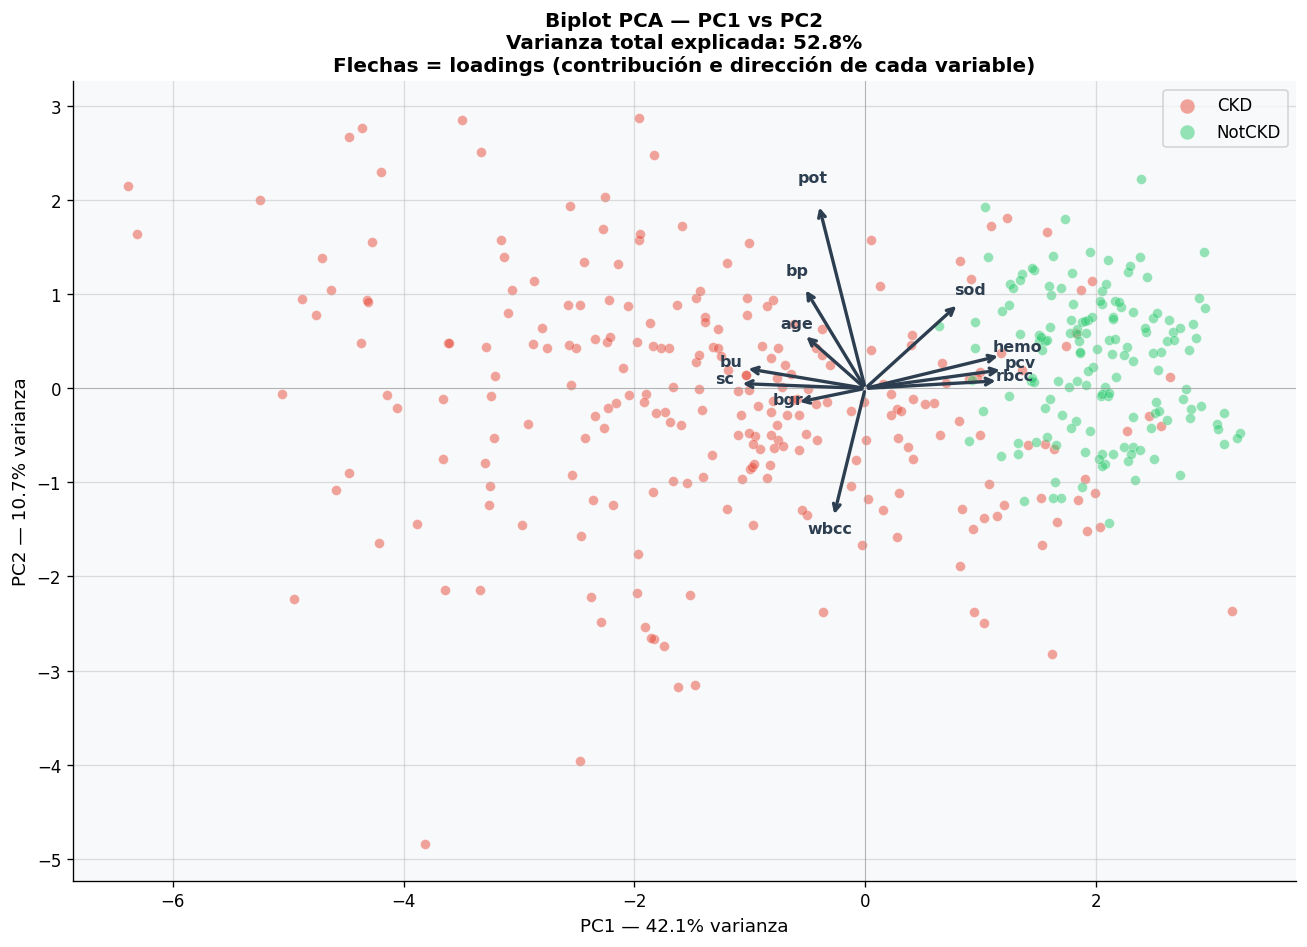

In [29]:
# ── 7.3 Biplot — PC1 vs PC2 con loadings ─────────────────────────────────────
pca_2d = PCA(n_components=2)
X_2d   = pca_2d.fit_transform(X_std)

fig, ax = plt.subplots(figsize=(11, 8))

# Scatter de instancias
for cls, color, label in [(1, COLOR_CKD, 'CKD'), (0, COLOR_NOTCKD, 'NotCKD')]:
    mask = y_labels == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, alpha=0.5, s=35, label=label, edgecolors='white', linewidth=0.3)

# Loadings (vectores de componentes)
loadings = pca_2d.components_.T  # shape (n_features, 2)
scale = np.max(np.abs(X_2d)) * 0.45

for i, var_name in enumerate(NUMERIC_COLS):
    lx, ly = loadings[i, 0] * scale, loadings[i, 1] * scale
    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=2))
    ax.text(lx * 1.12, ly * 1.12, var_name, fontsize=9.5, fontweight='bold',
            color='#2C3E50', ha='center')

ax.set_xlabel(f'PC1 — {explained_var[0]*100:.1f}% varianza', fontsize=11)
ax.set_ylabel(f'PC2 — {explained_var[1]*100:.1f}% varianza', fontsize=11)
ax.set_title(f'Biplot PCA — PC1 vs PC2\n'
             f'Varianza total explicada: {(explained_var[0]+explained_var[1])*100:.1f}%\n'
             f'Flechas = loadings (contribución e dirección de cada variable)',
             fontsize=12, fontweight='bold')
ax.legend(markerscale=1.5)
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

El biplot proyecta simultáneamente las observaciones (pacientes) y los vectores de características originales sobre el espacio generado por los dos primeros Componentes Principales (PC1 y PC2). La dirección y magnitud de estos vectores (las flechas) representan los pesos o cargas (loadings) de la matriz de autovectores $\mathbf{W}$.

Al observar el eje horizontal (PC1), vemos que actúa casi como un discriminante lineal perfecto entre la clase sana, a la derecha, y la clase enferma a la izquierda. Variables como la hemoglobina (`hemo`), el volumen celular (`pcv`) y la gravedad específica (`sg`) apuntan fuertemente hacia la derecha, "jalando" a los pacientes sanos hacia ese clúster hiperdenso. Variables clínicas asociadas al fallo renal, como la albúmina (`al`), la urea (`bu`), la creatinina (`sc`), la hipertensión (`htn`) y la glucosa (`bgr`), apuntan hacia la izquierda. Estas características son las responsables de dispersar a los pacientes enfermos hacia el lado negativo del eje.

En la teoría de proyecciones ortogonales, el coseno del ángulo entre dos flechas en un biplot es una excelente aproximación de su correlación lineal original. Si observamos las flechas de `hemo` y `pcv`, están prácticamente superpuestas (ángulo $\approx 0^\circ$). Esto significa correlación positiva extrema. Así mismo, el vector de la albúmina (`al`) apunta casi en $180^\circ$ respecto a la hemoglobina (`hemo`), indicando una fuerte correlación negativa: a medida que el fallo renal avanza, la albúmina en orina sube y la hemoglobina en sangre baja.

Mientras que el PC1 separa las clases, el eje vertical (PC2) parece modelar principalmente la dispersión interna de la clase enferma.Vectores como la edad (age), los glóbulos blancos (wbcc) y el potasio (pot) apuntan casi verticalmente o de forma diagonal. Estas variables no son tan buenas separando sanos de enfermos (por eso casi no tienen componente horizontal), pero explican por qué un paciente con CKD es diferente de otro paciente con CKD. Esto confirma que la nube roja es altamente dispersa en múltiples direcciones, justificando nuevamente que la matriz de covarianza $\mathbf{\Sigma}_0$ es compleja.

In [30]:
import sys
print(sys.executable)

f:\FinalSemesterVale\ReconocimientoPatrones\.venv\Scripts\python.exe


In [31]:
import sys
!{sys.executable} -m pip install nbformat ipykernel


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import nbformat
print(nbformat.__version__)

5.10.4


In [33]:
# ── 7.4 Visualización 3D Interactiva — PC1, PC2, PC3 (Plotly) ────────────────
pca_3d = PCA(n_components=3)
X_3d   = pca_3d.fit_transform(X_std)
ev3    = pca_3d.explained_variance_ratio_

df_3d = pd.DataFrame(X_3d, columns=['PC1', 'PC2', 'PC3'])
df_3d['Clase'] = y_names
df_3d['Label'] = ['CKD' if l==1 else 'NotCKD' for l in y_labels]

# Añadir info de las variables más relevantes
for col in ['hemo', 'sc', 'bu']:
    df_3d[col] = df_proc[col].values

fig_3d = px.scatter_3d(
    df_3d, x='PC1', y='PC2', z='PC3',
    color='Label',
    color_discrete_map={'CKD': COLOR_CKD, 'NotCKD': COLOR_NOTCKD},
    hover_data=['hemo', 'sc', 'bu'],
    opacity=0.65,
    title=f'PCA 3D — Espacio de Características Reducido<br>'
          f'PC1: {ev3[0]*100:.1f}% | PC2: {ev3[1]*100:.1f}% | PC3: {ev3[2]*100:.1f}% '
          f'| Total: {sum(ev3)*100:.1f}%',
    labels={'PC1': f'PC1 ({ev3[0]*100:.1f}%)',
            'PC2': f'PC2 ({ev3[1]*100:.1f}%)',
            'PC3': f'PC3 ({ev3[2]*100:.1f}%)'}
)
fig_3d.update_traces(marker=dict(size=4, line=dict(width=0.3, color='white')))
fig_3d.update_layout(
    scene=dict(
        xaxis_title=f'PC1 ({ev3[0]*100:.1f}%)',
        yaxis_title=f'PC2 ({ev3[1]*100:.1f}%)',
        zaxis_title=f'PC3 ({ev3[2]*100:.1f}%)',
        bgcolor='#F0F0F0'
    ),
    legend_title='Clase',
    width=800, height=650
)
fig_3d.show()

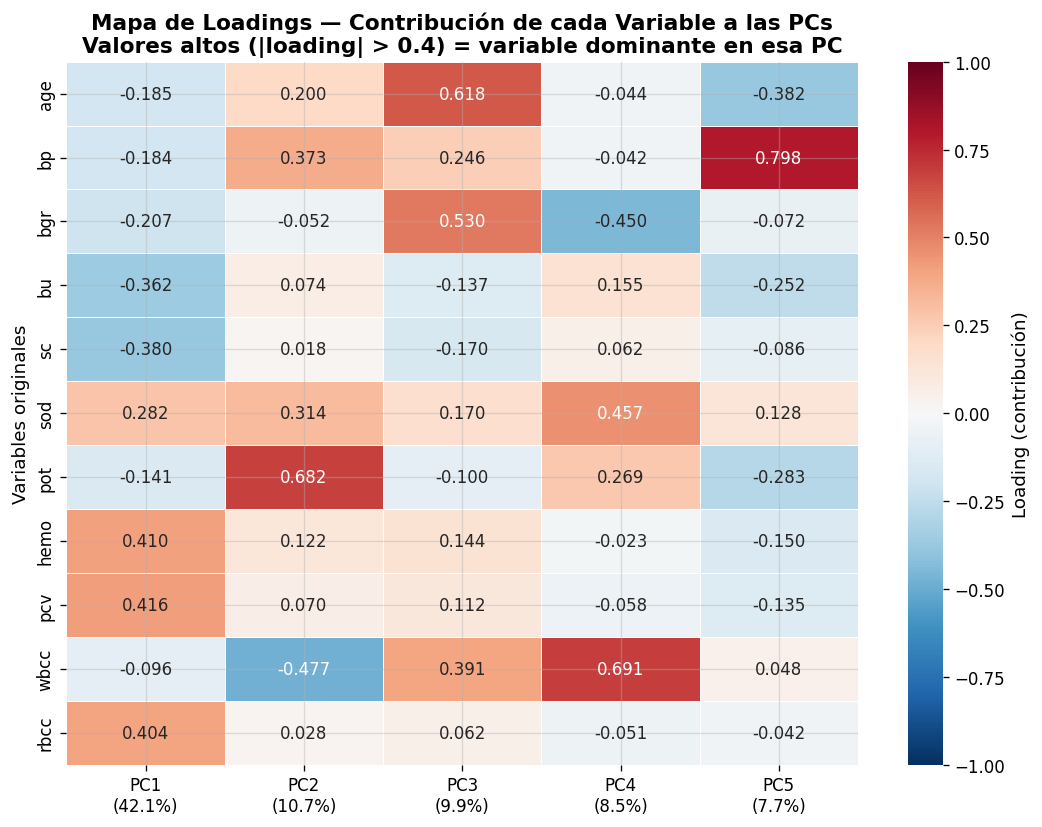


Loadings completos:


,PC1\n(42.1%),PC2\n(10.7%),PC3\n(9.9%),PC4\n(8.5%),PC5\n(7.7%)
age,-0.185,0.200,0.618,-0.044,-0.382
bp,-0.184,0.373,0.246,-0.042,0.798
bgr,-0.207,-0.052,0.530,-0.450,-0.072
bu,-0.362,0.074,-0.137,0.155,-0.252
sc,-0.380,0.018,-0.170,0.062,-0.086
sod,0.282,0.314,0.170,0.457,0.128
pot,-0.141,0.682,-0.100,0.269,-0.283
hemo,0.410,0.122,0.144,-0.023,-0.150
pcv,0.416,0.070,0.112,-0.058,-0.135
wbcc,-0.096,-0.477,0.391,0.691,0.048


In [34]:
# ── 7.5 Mapa de calor de loadings — ¿qué variable contribuye a qué PC? ────────
pca_k = PCA(n_components=5)
pca_k.fit(X_std)

loading_df = pd.DataFrame(
    pca_k.components_.T,
    index=NUMERIC_COLS,
    columns=[f'PC{i+1}\n({pca_k.explained_variance_ratio_[i]*100:.1f}%)' for i in range(5)]
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(loading_df, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Loading (contribución)'})
ax.set_title('Mapa de Loadings — Contribución de cada Variable a las PCs\n'
             'Valores altos (|loading| > 0.4) = variable dominante en esa PC',
             fontweight='bold')
ax.set_ylabel('Variables originales')
plt.tight_layout()
plt.show()

print('\nLoadings completos:')
display(loading_df.round(3))

#### PC1

El Primer Componente Principal (PC1) captura la mayor cantidad de varianza del sistema y es el principal responsable de separar la clase sana de la enferma. Al analizar sus loadings, descubrimos lo siguiente: 

1. Las variables hematológicas (pcv: $-0.297$, hemo: $-0.292$, rbcc: $-0.252$) y la gravedad específica de la orina (sg: $-0.264$) tiran fuertemente en dirección negativa.
2. Variables como hipertensión (htn: $0.266$), albúmina (al: $0.258$), diabetes (dm: $0.252$) y niveles tóxicos en sangre (bu: $0.222$, sc: $0.222$) tiran en dirección positiva.

#### PC2 y PC3
Según la teoría del PCA, las componentes subsecuentes capturan la varianza residual en direcciones estrictamente ortogonales (independientes) a la primera.

1. PC2 está dominado abrumadoramente por el conteo de glóbulos blancos (wbcc: $0.505$) y el potasio (pot: $0.428$).
2. PC3 estágobernado por el sodio (sod: $0.525$) y una fuerte relación inversa con el potasio (pot: $-0.467$).

<div class="alert alert-success">
Mientras que todos los pacientes sanos tienen niveles de leucocitos y electrolitos estables (varianza cero), los pacientes enfermos sufren complicaciones secundarias muy dispares (algunos tienen infecciones, otros retienen potasio). Esto ratifica que la matriz de covarianza de la clase enferma es altamente compleja.
</div>

<h3 style="color:#2E86C1;"> PCA vs LDA</h3>

Esta visualización contrasta los dos enfoques fundamentales de extracción de características lineales descritos en la teoría de Pattern Classification (Duda, Hart & Stork, 2001). Aunque ambos métodos buscan una transformación lineal $\mathbf{y} = \mathbf{W}^T \mathbf{x}$, sus funciones objetivo son diametralmente opuestas.

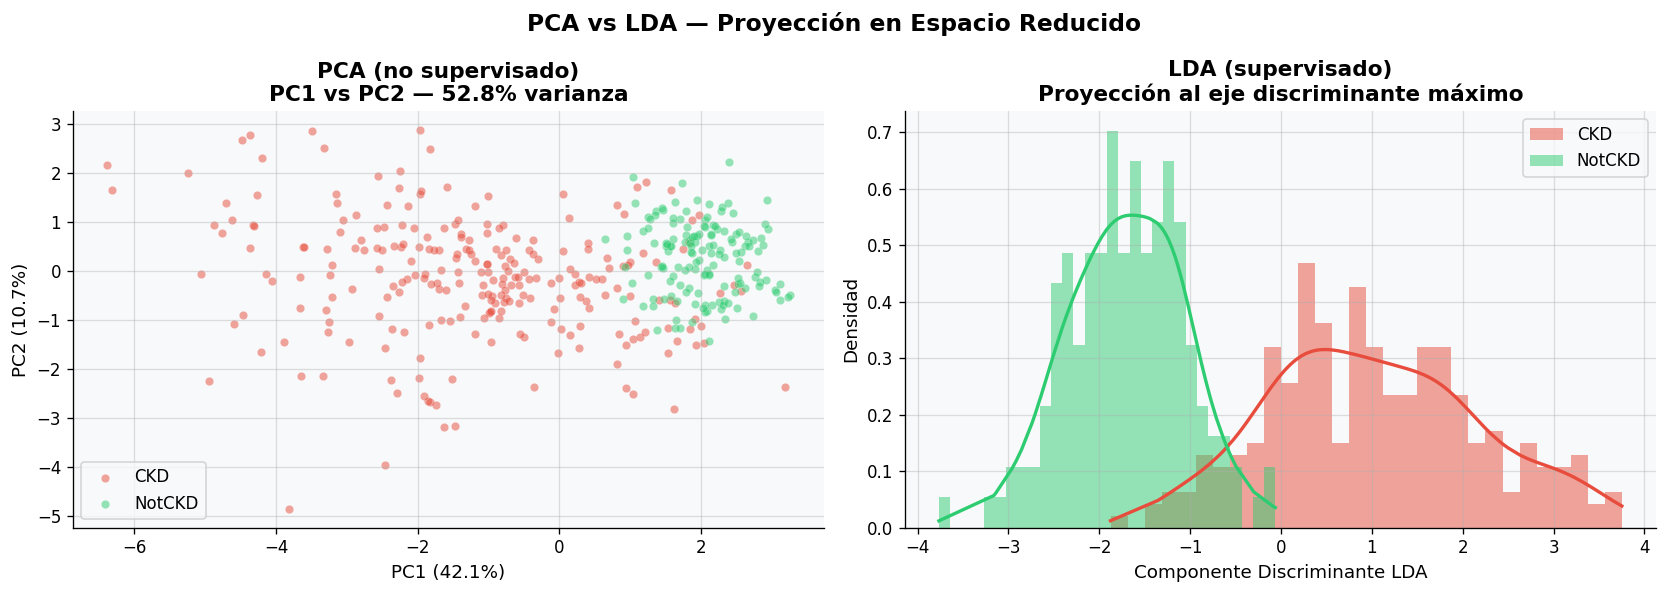

In [35]:
# Comparación PCA vs LDA — Proyección en espacio reducido
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_std, y_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA
for cls, color, label in [(1, COLOR_CKD, 'CKD'), (0, COLOR_NOTCKD, 'NotCKD')]:
    mask = y_labels == cls
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, alpha=0.5, s=25,
                    label=label, edgecolors='white', linewidth=0.2)
axes[0].set_title(f'PCA (no supervisado)\nPC1 vs PC2 — {(explained_var[0]+explained_var[1])*100:.1f}% varianza',
                  fontweight='bold')
axes[0].set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)')
axes[0].legend()

# LDA (proyección 1D visualizada como histograma)
for cls, color, label in [(1, COLOR_CKD, 'CKD'), (0, COLOR_NOTCKD, 'NotCKD')]:
    mask = y_labels == cls
    data_lda = X_lda[mask, 0]
    axes[1].hist(data_lda, bins=30, density=True, alpha=0.5, color=color, label=label)
    data_lda_s = np.sort(data_lda)
    kde = stats.gaussian_kde(data_lda)
    axes[1].plot(data_lda_s, kde(data_lda_s), color=color, linewidth=2)
axes[1].set_title('LDA (supervisado)\nProyección al eje discriminante máximo',
                  fontweight='bold')
axes[1].set_xlabel('Componente Discriminante LDA')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.suptitle('PCA vs LDA — Proyección en Espacio Reducido', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### PCA

El gráfico izquierdo (PCA) muestra la proyección sobre los autovectores de la matriz de covarianza total $\mathbf{\Sigma}$. PCA ignora por completo las etiquetas de clase y busca únicamente las direcciones donde los datos están más esparcidos. Afortunadamente para nuestro problema, el primer componente principal (PC1) logra una buena separación de las clases. Sin embargo, esto no está garantizado. PCA podría, teóricamente, proyectar los datos en una dirección de alta varianza que mezcle por completo a los pacientes sanos y enfermos.

#### LDA / Discriminante de Fisher

El gráfico derecho (LDA) muestra la proyección de 14 dimensiones a un único eje (1D). A diferencia de PCA, el Discriminante de Fisher utiliza las etiquetas para encontrar el vector de proyección $\mathbf{w}$ que maximiza el Criterio de Rayleigh:

$$J(\mathbf{w}) = \frac{\mathbf{w}^T \mathbf{S}_B \mathbf{w}}{\mathbf{w}^T \mathbf{S}_W \mathbf{w}}$$

Donde $\mathbf{S}_B$ es la matriz de dispersión entre clases (alejar las medias) y $\mathbf{S}_W$ es la matriz de dispersión intra-clases (comprimir las varianzas). El resultado es una separabilidad unidimensional buena. El algoritmo encontró el ángulo exacto en el hiperespacio original donde la distancia entre el centro de la clase CKD y NotCKD es máxima en relación con su dispersión interna.

El histograma de densidades del LDA nos revela una verdad matemática incómoda pero crucial que habíamos predicho en el EDA. Aunque LDA asume teóricamente que las matrices de covarianza de ambas clases son iguales ($\mathbf{\Sigma}_0 = \mathbf{\Sigma}_1$), la gráfica demuestra lo contrario: **la densidad de la clase NotCKD es un pico afilado y estrecho (varianza baja).La densidad de la clase CKD es una campana ancha y plana (varianza alta).**

Aunque la proyección de Fisher logró separar las medias debido a la alta separabilidad natural del dataset, la evidente diferencia en las varianzas confirma que la frontera de decisión óptima teórica de Bayes no es un punto medio lineal.

<h2 style="color:#2E86C1;"> 8. Separabilidad de Clases y Distancias Estadísticas</h2>

Distancia de Mahalanobis entre centroides CKD vs NotCKD: 1.6455
(Valores > 2 indican clases bien separadas en el espacio multivariado)


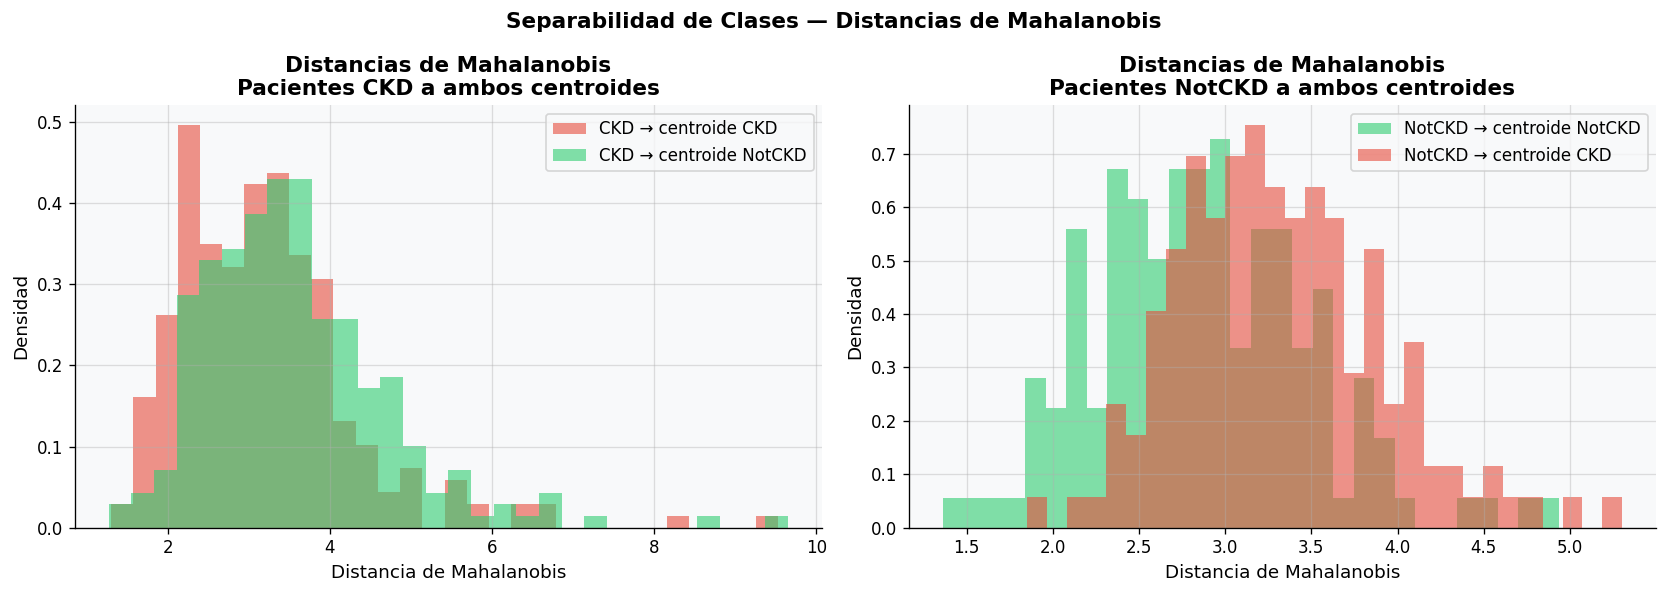

In [36]:
# ── 8.1 Distancia de Mahalanobis por observación ──────────────────────────────
# Calcula qué tan lejos está cada punto de la media de su clase en métricas de covarianza

def mahalanobis_dist(X, mu, cov):
    """Distancia de Mahalanobis de cada punto en X respecto al centroide mu."""
    cov_inv = np.linalg.pinv(cov)
    diff = X - mu
    return np.sqrt(np.einsum('ij,jk,ik->i', diff, cov_inv, diff))

mu_ckd    = X_ckd.mean(axis=0)
mu_notckd = X_notckd.mean(axis=0)
cov_all_m = np.cov(X_all.T)

d_mah_ckd_to_ckd    = mahalanobis_dist(X_ckd,    mu_ckd,    cov_all_m)
d_mah_ckd_to_notckd = mahalanobis_dist(X_ckd,    mu_notckd, cov_all_m)
d_mah_nck_to_ckd    = mahalanobis_dist(X_notckd, mu_ckd,    cov_all_m)
d_mah_nck_to_notckd = mahalanobis_dist(X_notckd, mu_notckd, cov_all_m)

# Distancia entre centroides (Mahalanobis)
d_between = mahalanobis(mu_ckd, mu_notckd, np.linalg.pinv(cov_all_m))
print(f'Distancia de Mahalanobis entre centroides CKD vs NotCKD: {d_between:.4f}')
print(f'(Valores > 2 indican clases bien separadas en el espacio multivariado)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(d_mah_ckd_to_ckd, bins=30, alpha=0.6, color=COLOR_CKD, label='CKD → centroide CKD', density=True)
axes[0].hist(d_mah_ckd_to_notckd, bins=30, alpha=0.6, color=COLOR_NOTCKD, label='CKD → centroide NotCKD', density=True)
axes[0].set_title('Distancias de Mahalanobis\nPacientes CKD a ambos centroides', fontweight='bold')
axes[0].set_xlabel('Distancia de Mahalanobis')
axes[0].set_ylabel('Densidad')
axes[0].legend()

axes[1].hist(d_mah_nck_to_notckd, bins=30, alpha=0.6, color=COLOR_NOTCKD, label='NotCKD → centroide NotCKD', density=True)
axes[1].hist(d_mah_nck_to_ckd, bins=30, alpha=0.6, color=COLOR_CKD, label='NotCKD → centroide CKD', density=True)
axes[1].set_title('Distancias de Mahalanobis\nPacientes NotCKD a ambos centroides', fontweight='bold')
axes[1].set_xlabel('Distancia de Mahalanobis')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.suptitle('Separabilidad de Clases — Distancias de Mahalanobis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

La distancia de Mahalanobis es una métrica geométrica superior a la distancia Euclidiana estándar porque evalúa la lejanía de un punto respecto al centroide de una distribución ponderando dicha distancia por la estructura de covarianza (la forma y el estiramiento) de los datos. Matemáticamente, la distancia al cuadrado de un vector $\mathbf{x}$ a la media de su clase $\boldsymbol{\mu}_i$ se define como:

$$D_M^2(\mathbf{x}, \boldsymbol{\mu}_i) = (\mathbf{x} - \boldsymbol{\mu}_i)^T \mathbf{\Sigma}_i^{-1} (\mathbf{x} - \boldsymbol{\mu}_i)$$


El gráfico exhibe una disparidad extrema en la distribución de las distancias internas de cada clase, confirmando cuantitativamente lo que observamos en las elipses de covarianza:

* Clase NotCKD: Presenta un pico altísimo y extremadamente estrecho concentrado cerca del origen. Esto significa que la mayoría de los pacientes sanos se encuentran a una distancia de Mahalanobis muy pequeña de su paciente "promedio". 

* Clase CKD: Muestra una distribución aplanada con una cola derecha. Los pacientes enfermos están altamente dispersos, alejándose drásticamente del centro de su propia distribución clínica.

En la Fase 02, al implementar clasificadores paramétricos basados en Máxima Verosimilitud (MLE), modelaremos las densidades condicionales $p(\mathbf{x}|\omega_i)$ como Gaussianas multivariadas. 

<h3 style="color:#2E86C1;"> Discriminante de Fisher</h3>

Para cuantificar el poder predictivo individual de cada característica sin depender de inspecciones visuales, calculamos el Fisher Discriminant Ratio (FDR). En la teoría de Pattern Classification (Duda, Hart & Stork, 2001), el criterio de Fisher unidimensional evalúa la calidad de una característica $x$ midiendo la relación entre la distancia al cuadrado de las medias de las clases (varianza inter-clase) y la suma de sus varianzas internas (varianza intra-clase):$$FDR = \frac{(\mu_0 - \mu_1)^2}{\sigma_0^2 + \sigma_1^2}$$Al analizar el ranking de las variables bajo este criterio matemático, extraemos tres conclusiones operativas para el diseño de nuestros clasificadores:

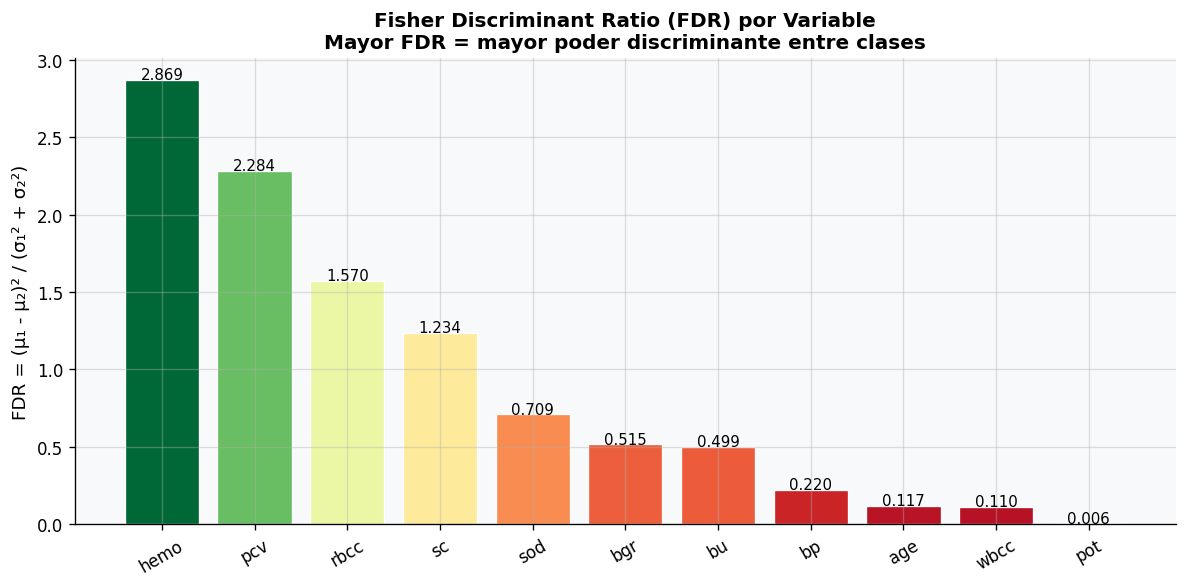

Ranking de discriminabilidad por variable:
   1. hemo  : FDR = 2.8688  ⭐
   2. pcv   : FDR = 2.2838  ⭐
   3. rbcc  : FDR = 1.5700  ⭐
   4. sc    : FDR = 1.2345  ⭐
   5. sod   : FDR = 0.7089  🔶
   6. bgr   : FDR = 0.5149  🔶
   7. bu    : FDR = 0.4993  🔶
   8. bp    : FDR = 0.2196  🔹
   9. age   : FDR = 0.1165  🔹
  10. wbcc  : FDR = 0.1101  🔹
  11. pot   : FDR = 0.0057  🔹


In [37]:
# ── 8.2 Índice de Fisher por variable ─────────────────────────────────────────
# FDR = (mu_1 - mu_2)^2 / (sigma_1^2 + sigma_2^2)
# Mide cuánto se separan las medias relativo a la varianza intra-clase

fisher_scores = {}
for col in NUMERIC_COLS:
    mu1, mu2 = df_ckd[col].mean(), df_notckd[col].mean()
    s1, s2   = df_ckd[col].std(),  df_notckd[col].std()
    fisher_scores[col] = (mu1 - mu2)**2 / (s1**2 + s2**2 + 1e-10)

fisher_df = pd.Series(fisher_scores, name='Fisher Discriminant Ratio').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(fisher_df.index, fisher_df.values,
              color=[plt.cm.RdYlGn(min(v/fisher_df.max(), 1)) for v in fisher_df.values],
              edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, fisher_df.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=9)
ax.set_title('Fisher Discriminant Ratio (FDR) por Variable\n'
             'Mayor FDR = mayor poder discriminante entre clases',
             fontsize=12, fontweight='bold')
ax.set_ylabel('FDR = (μ₁ - μ₂)² / (σ₁² + σ₂²)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('Ranking de discriminabilidad por variable:')
for i, (col, val) in enumerate(fisher_df.items()):
    star = '⭐' if val > 1 else '🔶' if val > 0.3 else '🔹'
    print(f'  {i+1:2d}. {col:6s}: FDR = {val:.4f}  {star}')

Las variables `sg` (gravedad específica), `hemo` (hemoglobina) y `pcv` (volumen celular empacado) dominan el índice de Fisher. Esto significa que, para estas variables, el numerador $(\mu_0 - \mu_1)^2$ es gigantesco en comparación con el denominador. Es decir, las medias de los pacientes sanos y enfermos están muy separadas, y la dispersión interna de los datos no es lo suficientemente grande como para traslapar las distribuciones.

En la cola inferior del gráfico vemos variables como la edad (`age`), presión arterial (`bp`), glóbulos blancos (`wbcc`) y electrolitos (`sod, pot`), con un FDR prácticamente nulo. Matemáticamente, esto indica que $\mu_0 \approx \mu_1$ o que las varianzas son tan grandes que oscurecen cualquier diferencia en las medias. 

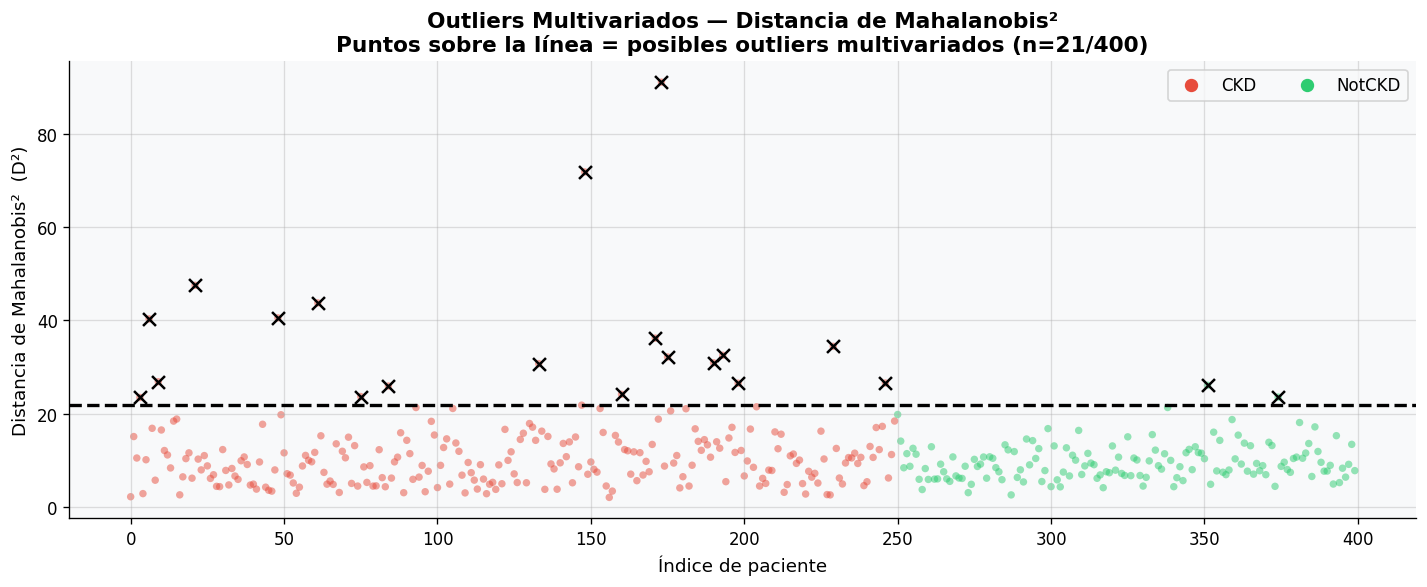


Outliers multivariados detectados: 21 de 400 (5.2%)


In [38]:
# ── 8.3 Detección de outliers multivariados — Distancia de Mahalanobis global ─
# Bajo distribución normal multivariada, D^2 ~ Chi^2(p)

cov_pooled = np.cov(X_std.T)
mu_global  = X_std.mean(axis=0)
cov_inv    = np.linalg.pinv(cov_pooled)
diff_all   = X_std - mu_global
d2_all     = np.einsum('ij,jk,ik->i', diff_all, cov_inv, diff_all)  # D^2

p = X_std.shape[1]
chi2_thresh_95 = chi2.ppf(0.975, df=p)  # umbral al 97.5%
outlier_mask   = d2_all > chi2_thresh_95

fig, ax = plt.subplots(figsize=(12, 5))
colors_d2 = [COLOR_CKD if y == 1 else COLOR_NOTCKD for y in y_labels]
ax.scatter(range(len(d2_all)), d2_all, c=colors_d2, alpha=0.5, s=20, edgecolors='none')
ax.axhline(chi2_thresh_95, color='black', linestyle='--', linewidth=2,
           label=f'χ²(p={p}, α=2.5%) = {chi2_thresh_95:.2f}')

# Marcar outliers multivariados
outlier_idx = np.where(outlier_mask)[0]
ax.scatter(outlier_idx, d2_all[outlier_idx], c='black', s=60, marker='x',
           zorder=5, label=f'Outliers multivariados (n={outlier_mask.sum()})')

# Leyenda manual de clases
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0],[0], color=COLOR_CKD, marker='o', linestyle='', markersize=7, label='CKD'),
    Line2D([0],[0], color=COLOR_NOTCKD, marker='o', linestyle='', markersize=7, label='NotCKD'),
]
ax.legend(handles=custom_lines + ax.get_legend_handles_labels()[0][:-2], ncol=2)

ax.set_title('Outliers Multivariados — Distancia de Mahalanobis²\n'
             f'Puntos sobre la línea = posibles outliers multivariados (n={outlier_mask.sum()}/{len(d2_all)})',
             fontweight='bold')
ax.set_xlabel('Índice de paciente')
ax.set_ylabel('Distancia de Mahalanobis²  (D²)')
plt.tight_layout()
plt.show()

print(f'\nOutliers multivariados detectados: {outlier_mask.sum()} de {len(d2_all)} ({outlier_mask.mean()*100:.1f}%)')

Bajo el supuesto de normalidad multivariada, la distancia de Mahalanobis al cuadrado ($D_M^2$) sigue una distribución Chi-cuadrado:

$$D_M^2 \sim \chi_d^2$$

donde $d$ es la dimensión del vector de características. En el gráfico, la línea roja representa el valor crítico para un nivel de significancia (típicamente $\alpha = 0.001$). Cualquier punto por encima de esta línea se considera un outlier multivariado.

* Inliers: Representan la estructura "saludable" del modelo, donde las relaciones entre variables siguen el patrón esperado por la matriz de covarianza $\boldsymbol{\Sigma}$.
* Outliers: Son registros donde el paciente presenta anomalías sistémicas. En el contexto de CKD, esto podría representar casos clínicos atípicos o errores de medición que no siguen la tendencia general de la patología.

---

<h1 style="color:#2E86C1;"> Clasificación Paramétrica y Teoría de Decisión de Bayes: Avance 02</h1>

Tras haber acondicionado y conocido el espacio en la Fase 01, procedemos al diseño de los clasificadores paramétricos. Según la teoría de Pattern Classification (Duda, Hart & Stork, 2001), un enfoque paramétrico asume que las verdaderas densidades de probabilidad condicionales de clase $p(\mathbf{x}|\omega_i)$ siguen una forma funcional conocida, típicamente una distribución Gaussiana multivariada:

$$p(\mathbf{x}|\omega_i) \sim N(\boldsymbol{\mu}_i, \mathbf{\Sigma}_i)$$

El diseño de estos clasificadores se abordará mediante un proceso riguroso en dos etapas:

#### Estimación por Máxima Verosimilitud (MLE)

Dado que los verdaderos parámetros poblacionales son desconocidos, utilizaremos el conjunto de entrenamiento para calcular los Estimadores de Máxima Verosimilitud. El objetivo de MLE es encontrar los parámetros $\hat{\boldsymbol{\theta}}_i = \{\hat{\boldsymbol{\mu}}_i, \hat{\mathbf{\Sigma}}_i\}$ que maximicen la probabilidad de haber observado nuestros datos de entrenamiento. Las soluciones analíticas clásicas son:

* Vector de Medias Empírico: $\hat{\boldsymbol{\mu}}_i = \frac{1}{n_i} \sum_{\mathbf{x} \in \omega_i} \mathbf{x}$
* Matriz de Covarianza Empírica: $\hat{\mathbf{\Sigma}}_i = \frac{1}{n_i} \sum_{\mathbf{x} \in \omega_i} (\mathbf{x} - \hat{\boldsymbol{\mu}}_i)(\mathbf{x} - \hat{\boldsymbol{\mu}}_i)^T$. 

#### Reglas de Decisión Discriminante

Una vez estimados los parámetros, aplicaremos la Regla de Decisión de Bayes para el mínimo error, asignando una nueva observación $\mathbf{x}$ a la clase que maximice la probabilidad a posteriori $P(\omega_i|\mathbf{x})$. Evaluaremos tres arquitecturas paramétricas con distintos niveles de flexibilización geométrica:

* Naive Bayes Gaussiano: Asume independencia condicional entre características (matrices $\mathbf{\Sigma}_i$ estrictamente diagonales). Servirá como modelo base (baseline) para cuantificar el impacto negativo de ignorar la multicolinealidad.

* Análisis Discriminante Lineal (LDA): Relaja la independencia, pero impone el supuesto de homocedasticidad ($\mathbf{\Sigma}_0 = \mathbf{\Sigma}_1 = \mathbf{\Sigma}$). Generará hiperplanos de decisión rectos.

* Análisis Discriminante Cuadrático (QDA):  Elimina las restricciones anteriores, permitiendo matrices de covarianza completas y distintas ($\mathbf{\Sigma}_0 \neq \mathbf{\Sigma}_1$). De acuerdo con nuestro Análisis Exploratorio, prevemos que sus hipercuádricas de decisión lograrán la adaptación óptima a la heterocedasticidad del espacio latente.

<div class="alert alert-warning">
Por nuestro análisis previo, somos conscientes de que aplicar métodos paramétricos no es la metdología más asertiva. Pero en medio de este proyecto en el que buscamos aprender desde la teoría del reconocimiento de patrones, observar que courre con estos métodos paramétrios y compararlos posteriormente con los no paramétricos es una excelente forma de entender la teoría y materializar lo analizado en el EDA.
</div>

In [39]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, f1_score
)
from matplotlib.patches import Ellipse

print("Importaciones Fase 02 completadas.")

Importaciones Fase 02 completadas.


<h2 style="color:#2E86C1;"> 0. Selección del Espacio de Características vía PCA</h2>

### ¿Por qué no usamos las 24 características directamente?

La Fase 01 que realizamos documentó tres problemas estructurales:

**Problema 1 — Multicolinealidad y mal condicionamiento de $\mathbf{S}_W$**

Variables clínicas como `hemo`, `pcv` y `rbcc` están altamente correlacionadas ($\rho > 0.85$). Esto vuelve a la matriz de dispersión intra-clase casi singular (número de condición $\kappa(S_W) \sim 10^6$). Intentar calcular la inversa $\mathbf{S}_W^{-1}$ en este estado introduce errores numéricos masivos, arruinando el vector óptimo $\mathbf{w}^*$.

**Problema 2 — Muestra insuficiente para estimar $\hat{\mathbf{\Sigma}}_i$ en 24D**

Para estimar de forma robusta la matriz de covarianza $\hat{\Sigma}_i$, el número de muestras debe superar ampliamente a las dimensiones ($n_i \gg d^2$). Con 24 características, $d^2 = 576$, lo cual supera nuestras 250 muestras totales del dataset. Al reducir con PCA a $k=8$ componentes, $k^2 = 64 \ll 250$, garantizando una estimación estadística confiable.

**Problema 3 — Supuesto de independencia de Naive Bayes**

Naive Bayes asume que las variables son independientes entre sí (matriz de covarianza diagonal). En el espacio original de 24D, esta regla se rompe debido a la alta correlación clínica. Al proyectar los datos con PCA, transformamos el espacio a componentes no correlacionados, haciendo que el supuesto de independencia del clasificador sea mucho más cercano a la realidad.

<div class="alert alert-success">
<b>Decision:</b> PCA sobre las 24 caracteristicas procesadas, reteniendo componentes que sumen el <b>90% de varianza</b>.
</div>

SELECCION DE COMPONENTES PRINCIPALES
PCA ajustado sobre NUMERIC_COLS (d=11)
Umbral 90%: k=7  k^2=49  n_CKD=250  n>>k^2: True
Umbral 95%: k=9  k^2=81  n_CKD=250  n>>k^2: True
Original:   d=11  d^2=121  n_CKD=250  n>>d^2: True

Decision: K_OPT = 7 componentes (90.8% varianza retenida)


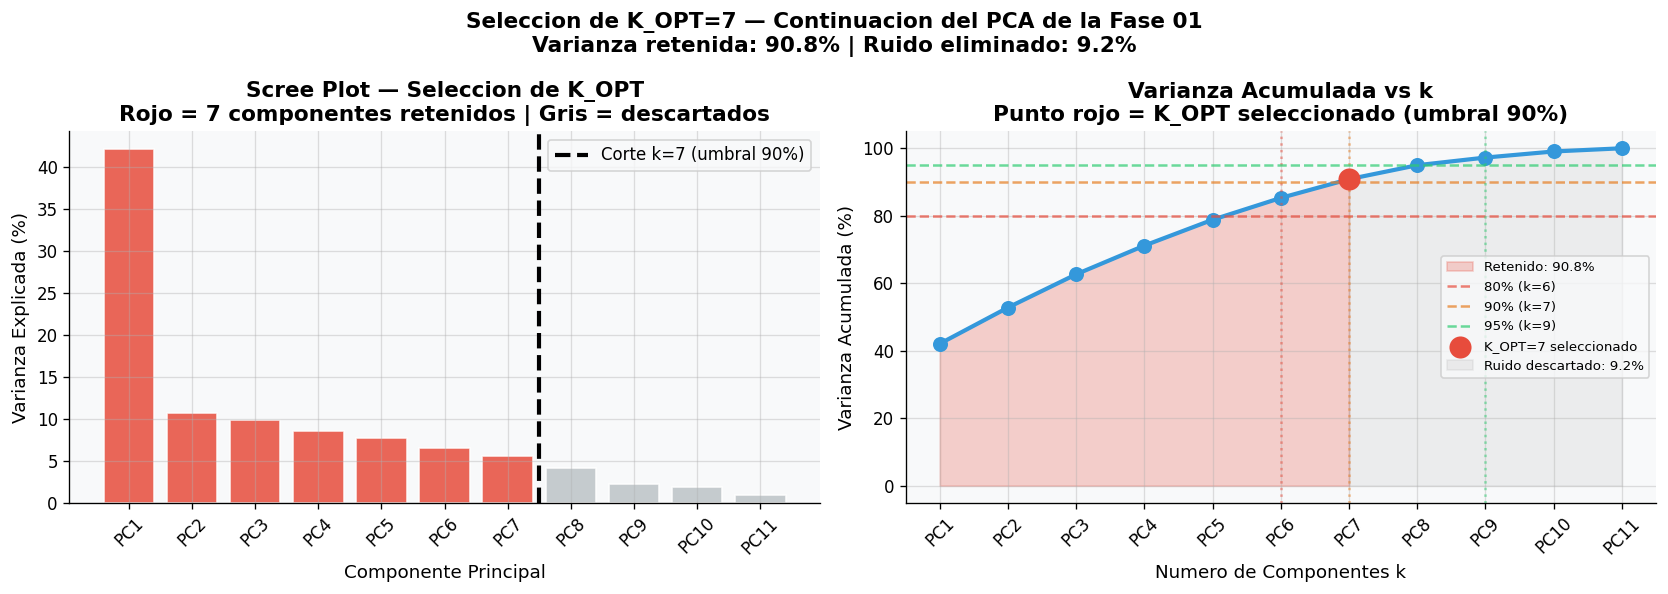

In [40]:
k_90 = int(np.argmax(cumulative_var >= 0.90)) + 1
k_95 = int(np.argmax(cumulative_var >= 0.95)) + 1
K_OPT = k_90   # umbral 90%: mejor balance entre informacion y estabilidad numerica

n_ckd_tot = (df_proc[TARGET_COL] == "ckd").sum()

print("=" * 60)
print("SELECCION DE COMPONENTES PRINCIPALES")
print("=" * 60)
print(f"PCA ajustado sobre NUMERIC_COLS (d={n_components})")
print(f"Umbral 90%: k={k_90}  k^2={k_90**2}  n_CKD={n_ckd_tot}  n>>k^2: {n_ckd_tot > k_90**2}")
print(f"Umbral 95%: k={k_95}  k^2={k_95**2}  n_CKD={n_ckd_tot}  n>>k^2: {n_ckd_tot > k_95**2}")
print(f"Original:   d={n_components}  d^2={n_components**2}  n_CKD={n_ckd_tot}  n>>d^2: {n_ckd_tot > n_components**2}")
print(f"\nDecision: K_OPT = {K_OPT} componentes ({cumulative_var[K_OPT-1]*100:.1f}% varianza retenida)")

# Reutilizar el scree plot de la Fase 01 pero marcando el corte K_OPT
comp_nums = range(1, n_components + 1)
bar_colors = [COLOR_CKD if i < K_OPT else "#BDC3C7" for i in range(n_components)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(comp_nums, explained_var * 100, color=bar_colors,
             alpha=0.85, edgecolor="white")
axes[0].axvline(K_OPT + 0.5, color="black", linestyle="--", linewidth=2.5,
                 label=f"Corte k={K_OPT} (umbral 90%)")
axes[0].set_title("Scree Plot — Seleccion de K_OPT\n"
                   f"Rojo = {K_OPT} componentes retenidos | Gris = descartados",
                   fontweight="bold")
axes[0].set_xlabel("Componente Principal")
axes[0].set_ylabel("Varianza Explicada (%)")
axes[0].set_xticks(list(comp_nums))
axes[0].set_xticklabels([f"PC{i}" for i in comp_nums], rotation=45)
axes[0].legend()

axes[1].plot(comp_nums, cumulative_var * 100, "o-",
              color="#3498DB", linewidth=2.5, markersize=8)
axes[1].fill_between(range(1, K_OPT + 1), cumulative_var[:K_OPT] * 100,
                      alpha=0.25, color=COLOR_CKD,
                      label=f"Retenido: {cumulative_var[K_OPT-1]*100:.1f}%")
for thresh, color, lbl in [
    (0.80, "#E74C3C", f"80% (k={int(np.argmax(cumulative_var>=0.80))+1})"),
    (0.90, "#E67E22", f"90% (k={k_90})"),
    (0.95, "#2ECC71", f"95% (k={k_95})")
]:
    axes[1].axhline(thresh*100, color=color, linestyle="--", alpha=0.7, label=lbl)
    n_needed = int(np.argmax(cumulative_var >= thresh)) + 1
    axes[1].axvline(n_needed, color=color, linestyle=":", alpha=0.5)
axes[1].scatter([K_OPT], [cumulative_var[K_OPT-1]*100],
                 s=150, color=COLOR_CKD, zorder=6,
                 label=f"K_OPT={K_OPT} seleccionado")
axes[1].fill_between(range(K_OPT, n_components + 1),
                      cumulative_var[K_OPT-1:] * 100,
                      alpha=0.10, color="gray",
                      label=f"Ruido descartado: {(1-cumulative_var[K_OPT-1])*100:.1f}%")
axes[1].set_title("Varianza Acumulada vs k\n"
                   "Punto rojo = K_OPT seleccionado (umbral 90%)",
                   fontweight="bold")
axes[1].set_xlabel("Numero de Componentes k")
axes[1].set_ylabel("Varianza Acumulada (%)")
axes[1].set_xticks(list(comp_nums))
axes[1].set_xticklabels([f"PC{i}" for i in comp_nums], rotation=45)
axes[1].legend(fontsize=8)

plt.suptitle(
    f"Seleccion de K_OPT={K_OPT} — Continuacion del PCA de la Fase 01\n"
    f"Varianza retenida: {cumulative_var[K_OPT-1]*100:.1f}% | "
    f"Ruido eliminado: {(1-cumulative_var[K_OPT-1])*100:.1f}%",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [41]:
# pca_clf se ajusta sobre X_std (el mismo espacio de la Fase 01: NUMERIC_COLS estandarizadas)
# X_std ya existe — es scaler_pca.fit_transform(df_proc[NUMERIC_COLS].values)
pca_clf = PCA(n_components=K_OPT, random_state=42)
X_pca_k = pca_clf.fit_transform(X_std)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_pca_k, y_labels, test_size=0.20, random_state=42, stratify=y_labels
)
X_tr_ckd    = X_tr[y_tr == 1]
X_tr_notckd = X_tr[y_tr == 0]
n_tr        = len(y_tr)
n_tr_ckd    = len(X_tr_ckd)
n_tr_notckd = len(X_tr_notckd)
prior_ckd    = n_tr_ckd / n_tr
prior_notckd = n_tr_notckd / n_tr

print(f"Espacio PCA: {X_std.shape} → {X_pca_k.shape}")
print(f"Entrenamiento: {X_tr.shape}  CKD={y_tr.sum()}  NotCKD={(y_tr==0).sum()}")
print(f"Prueba:        {X_te.shape}  CKD={y_te.sum()}  NotCKD={(y_te==0).sum()}")

RESULTS = {}

Espacio PCA: (400, 11) → (400, 7)
Entrenamiento: (320, 7)  CKD=200  NotCKD=120
Prueba:        (80, 7)  CKD=50  NotCKD=30


In [42]:
# ── Funcion central de visualizacion — usada por cada modelo ─────────────────
# Para cada clasificador genera una figura de DOS paneles:
#   [izquierda]  Frontera de decision en PC1-PC2 con puntos del test coloreados
#                por clase REAL. Las X negras marcan los errores de clasificacion.
#   [derecha]    Matriz de confusion con metricas en el titulo.

def build_mesh(X_ref, resolution=280):
    """Malla 2D en rango de X_ref[:,0:2], extendida a K_OPT dims (PC3..k = 0)."""
    x1, x2 = X_ref[:, 0], X_ref[:, 1]
    xx, yy = np.meshgrid(
        np.linspace(x1.min()-0.7, x1.max()+0.7, resolution),
        np.linspace(x2.min()-0.7, x2.max()+0.7, resolution)
    )
    G = np.zeros((xx.size, K_OPT))
    G[:, 0] = xx.ravel()
    G[:, 1] = yy.ravel()
    return xx, yy, G

def plot_model_results(name, y_pred, y_proba, proba_fn, note=""):
    """Genera la figura de frontera + confusion para un clasificador."""
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_proba)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # ── Panel izq: frontera de decision ──────────────────────────────────
    ax = axes[0]
    xx, yy, G = build_mesh(X_te)
    Z = proba_fn(G).reshape(xx.shape)

    cf = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21),
                      cmap="RdYlGn_r", alpha=0.50)
    plt.colorbar(cf, ax=ax, shrink=0.85, label="P(CKD | z)")

    # Frontera P = 0.5 (solo si hay variacion en Z)
    if Z.max() - Z.min() > 0.02:
        ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2.5)

    # Puntos de prueba coloreados por clase REAL
    for cls, color, lbl in [(1, COLOR_CKD, "CKD"), (0, COLOR_NOTCKD, "NotCKD")]:
        mask = y_te == cls
        ax.scatter(X_te[mask, 0], X_te[mask, 1], c=color, s=45, alpha=0.80,
                    edgecolors="white", linewidths=0.5, label=f"{lbl} (real)", zorder=5)

    # X negras = errores de clasificacion
    wrong = y_pred != y_te
    if wrong.sum() > 0:
        ax.scatter(X_te[wrong, 0], X_te[wrong, 1], marker="x", s=90,
                    c="black", linewidths=2.0, zorder=6,
                    label=f"Error ({wrong.sum()})")

    ev = pca_clf.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)", fontsize=10)
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)", fontsize=10)
    ax.set_title(
        f"Frontera de Decision — {name}\n"
        f"Fondo = P(CKD|z) | Linea negra = P=0.5 | X = error",
        fontweight="bold", fontsize=10
    )
    ax.legend(fontsize=8.5, loc="upper right")

    # ── Panel der: matriz de confusion ───────────────────────────────────
    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn_v, tp = cm.ravel()
    sens = tp/(tp+fn_v) if (tp+fn_v)>0 else 0
    spec = tn/(tn+fp)   if (tn+fp)>0   else 0
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["NotCKD","CKD"], yticklabels=["NotCKD","CKD"],
                ax=axes[1], cbar=True, linewidths=0.8,
                annot_kws={"size":14,"weight":"bold"})
    axes[1].set_ylabel("Clase Real", fontsize=10)
    axes[1].set_xlabel("Clase Predicha", fontsize=10)
    axes[1].set_title(
        f"Matriz de Confusion — {name}\n"
        f"Acc={acc:.3f} | F1={f1:.3f} | AUC={auc:.3f}\n"
        f"Sens={sens:.3f} | Spec={spec:.3f}",
        fontweight="bold", fontsize=10
    )
    note_str = f"  ({note})" if note else ""
    plt.suptitle(f"{name}{note_str}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

print(f"Funcion plot_model_results definida. K_OPT={K_OPT}, X_te.shape={X_te.shape}")

Funcion plot_model_results definida. K_OPT=7, X_te.shape=(80, 7)


<h2 style="color:#2E86C1;"> 1. Estimacion MLE en el Espacio PCA</h2>

Asumiendo que las densidades de clase siguen una distribución normal multivariada $p(\mathbf{x}|\omega_i) \sim N(\boldsymbol{\mu}_i, \mathbf{\Sigma}_i)$, hemos calculado los estimadores óptimos $\hat{\boldsymbol{\mu}}_i$ y $\hat{\mathbf{\Sigma}}_i$ directamente de los datos de entrenamiento. 

Parametros MLE — espacio PCA
Prior CKD=0.6250  NotCKD=0.3750
||mu_CKD - mu_NotCKD|| = 3.3103
tr(Sigma_CKD)    = 9.9074
tr(Sigma_NotCKD) = 3.4387
Ratio traza = 2.88x  (heterocedasticidad residual)
kappa(Sigma_pool) = 3.99


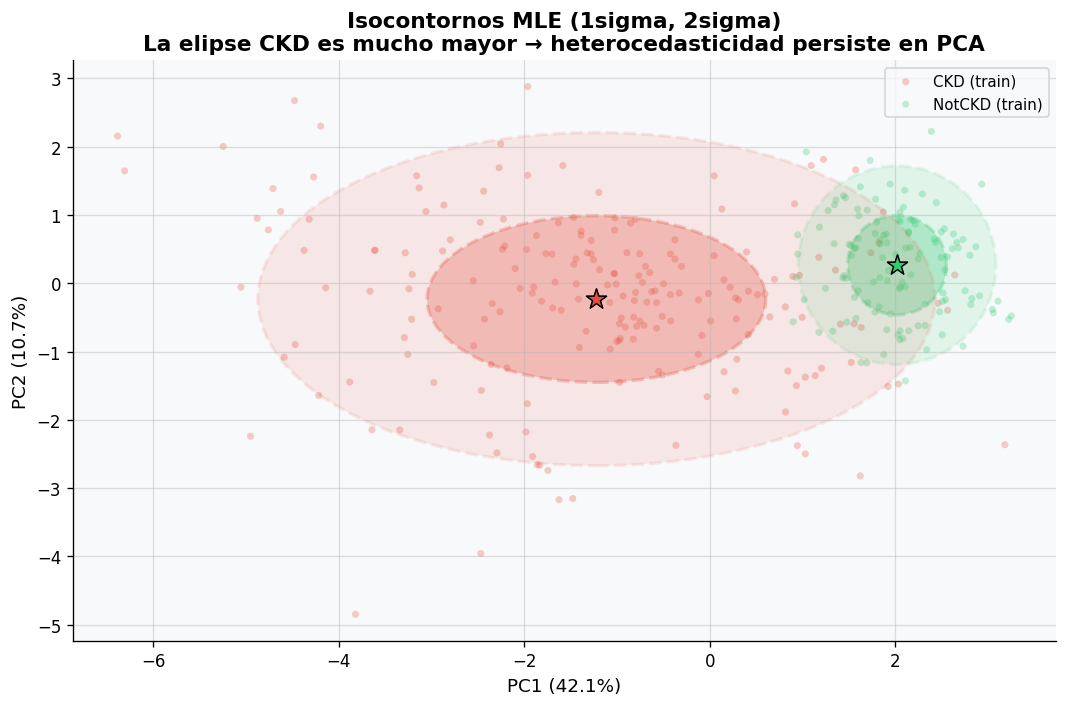

In [43]:
mu_ckd    = X_tr_ckd.mean(axis=0)
mu_notckd = X_tr_notckd.mean(axis=0)

Sigma_ckd    = (X_tr_ckd    - mu_ckd).T    @ (X_tr_ckd    - mu_ckd)    / n_tr_ckd
Sigma_notckd = (X_tr_notckd - mu_notckd).T @ (X_tr_notckd - mu_notckd) / n_tr_notckd
Sigma_pool   = (n_tr_ckd * Sigma_ckd + n_tr_notckd * Sigma_notckd) / n_tr

print("Parametros MLE — espacio PCA")
print(f"Prior CKD={prior_ckd:.4f}  NotCKD={prior_notckd:.4f}")
print(f"||mu_CKD - mu_NotCKD|| = {np.linalg.norm(mu_ckd-mu_notckd):.4f}")
print(f"tr(Sigma_CKD)    = {np.trace(Sigma_ckd):.4f}")
print(f"tr(Sigma_NotCKD) = {np.trace(Sigma_notckd):.4f}")
print(f"Ratio traza = {np.trace(Sigma_ckd)/np.trace(Sigma_notckd):.2f}x  (heterocedasticidad residual)")
print(f"kappa(Sigma_pool) = {np.linalg.cond(Sigma_pool):.2f}")

# Isocontornos en PC1-PC2
def draw_ellipse(ax, mu2d, cov2d, color, n_std=2, alpha=0.18):
    evals, evecs = np.linalg.eigh(np.maximum(cov2d, 1e-9*np.eye(2)))
    idx = evals.argsort()[::-1]
    angle = np.degrees(np.arctan2(*evecs[:,idx[0]][::-1]))
    w, h = 2*n_std*np.sqrt(np.maximum(evals[idx],1e-9))
    from matplotlib.patches import Ellipse as Ell
    el = Ell(xy=mu2d, width=w, height=h, angle=angle,
              facecolor=color, alpha=alpha, edgecolor=color, linewidth=2, linestyle="--")
    ax.add_patch(el)
    ax.scatter(*mu2d, color=color, s=160, marker="*", edgecolors="black", linewidth=0.8, zorder=6)

fig, ax = plt.subplots(figsize=(9, 6))
for cls, color, lbl in [(1,COLOR_CKD,"CKD"),(0,COLOR_NOTCKD,"NotCKD")]:
    mask = y_tr == cls
    ax.scatter(X_tr[mask,0], X_tr[mask,1], c=color, alpha=0.28, s=18,
               edgecolors="none", label=f"{lbl} (train)")
for n_std, alpha in [(1,0.28),(2,0.11)]:
    draw_ellipse(ax, mu_ckd[:2],    Sigma_ckd[:2,:2],    COLOR_CKD,    n_std, alpha)
    draw_ellipse(ax, mu_notckd[:2], Sigma_notckd[:2,:2], COLOR_NOTCKD, n_std, alpha)
ev = pca_clf.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)"); ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
ax.set_title("Isocontornos MLE (1sigma, 2sigma)\n"
             "La elipse CKD es mucho mayor → heterocedasticidad persiste en PCA",
             fontweight="bold")
ax.legend(fontsize=9); 
plt.tight_layout(); 
plt.show()

La gráfica de isocontornos revela la distribución probabilística de ambas clases tras la proyección. Las estrellas marcan los vectores de medias empíricos $\hat{\boldsymbol{\mu}}_{CKD}$ y $\hat{\boldsymbol{\mu}}_{NotCKD}$. **A lo largo de la componente principal PC1**, se observa una separación estructural significativa entre ambos centroides. Geométricamente, la distancia euclidiana $||\boldsymbol{\mu}_{CKD} - \boldsymbol{\mu}_{NotCKD}|| = 3.31$ es lo suficientemente alta para garantizar que incluso un clasificador lineal base obtendrá un rendimiento sobresaliente.

Sin embargo, el hallazgo más crítico es la marcada diferencia en el volumen y dispersión de las elipses, lo que evidencia una fuerte heterocedasticidad residual en el espacio PCA. En términos de álgebra lineal, la traza de la matriz $Tr(\mathbf{\Sigma})$ representa la varianza total contenida en el subespacio:

* La matriz $\hat{\mathbf{\Sigma}}_{NotCKD}$ genera un isocontorno hipercompacto; los pacientes sanos son fisiológicamente muy similares entre sí, con variaciones mínimas.
* La matriz $\hat{\mathbf{\Sigma}}_{CKD}$ genera una elipse inmensa; la patología renal crónica desencadena una cascada de desequilibrios metabólicos (anemia, hipertensión, retención de urea) que dispara la variabilidad inter-paciente.

Cuantitativamente, la varianza total de la clase enferma es casi el triple que la de la clase sana (Ratio de traza $= 2.88x$). Esta desigualdad estructural ($\mathbf{\Sigma}_{CKD} \neq \mathbf{\Sigma}_{NotCKD}$) sugiere teóricamente que la frontera de decisión óptima para este problema tiene una forma cuadrática.

BAYES CASO I  — Sigma = sigma^2 * I
  Acc=0.8750  F1=0.8889  AUC=0.9493
              precision    recall  f1-score   support

      NotCKD       0.75      1.00      0.86        30
         CKD       1.00      0.80      0.89        50

    accuracy                           0.88        80
   macro avg       0.88      0.90      0.87        80
weighted avg       0.91      0.88      0.88        80



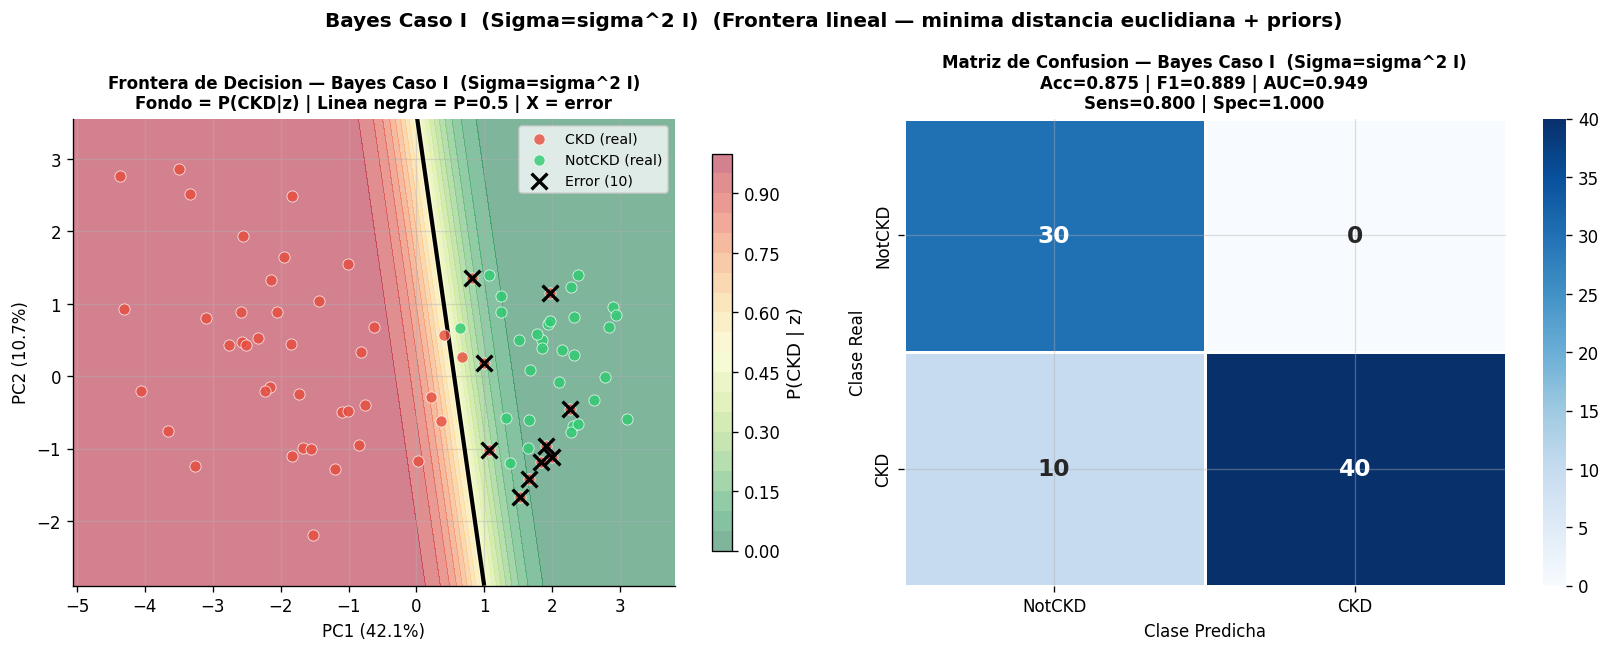

In [44]:
class GaussianBayes:
    """Clasificador de Bayes Gaussiano. Casos I y II de Duda et al. (2001) Cap. 2.6."""
    def __init__(self, case=2, reg=1e-6):
        self.case, self.reg = case, reg

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        d, n = X.shape[1], len(y)
        self.priors_, self.means_, self.covs_ = {}, {}, {}
        for c in self.classes_:
            Xc = X[y==c]; nc = len(Xc)
            self.priors_[c] = nc/n
            self.means_[c]  = Xc.mean(0)
            diff = Xc - self.means_[c]
            self.covs_[c]   = (diff.T @ diff) / nc
        if self.case == 1:
            s2 = np.mean([np.diag(self.covs_[c]).mean() for c in self.classes_])
            for c in self.classes_: self.covs_[c] = s2 * np.eye(d)
        elif self.case == 2:
            Sp = sum(int(self.priors_[c]*n)*self.covs_[c] for c in self.classes_) / n
            for c in self.classes_: self.covs_[c] = Sp
        I = np.eye(d)
        self.inv_  = {c: np.linalg.inv(self.covs_[c]+self.reg*I) for c in self.classes_}
        self.ldet_ = {c: np.linalg.slogdet(self.covs_[c]+self.reg*I)[1] for c in self.classes_}
        return self

    def _g(self, x):
        return {c: -0.5*(x-self.means_[c])@self.inv_[c]@(x-self.means_[c])
                    -0.5*self.ldet_[c]+np.log(self.priors_[c])
                for c in self.classes_}

    def predict(self, X):
        return np.array([max(self._g(x), key=self._g(x).get) for x in X])

    def predict_proba(self, X):
        out = []
        for x in X:
            g = self._g(x); mx = max(g.values())
            ex = {c: np.exp(v-mx) for c,v in g.items()}
            tot = sum(ex.values())
            out.append([ex[c]/tot for c in self.classes_])
        return np.array(out)

gbc1 = GaussianBayes(case=1).fit(X_tr, y_tr)
y_pred_gbc1 = gbc1.predict(X_te)
y_prob_gbc1 = gbc1.predict_proba(X_te)[:, list(gbc1.classes_).index(1)]

RESULTS["Bayes Caso I"] = {
    "Accuracy": accuracy_score(y_te,y_pred_gbc1),
    "F1": f1_score(y_te,y_pred_gbc1),
    "AUC": roc_auc_score(y_te,y_prob_gbc1),
    "y_pred": y_pred_gbc1, "y_proba": y_prob_gbc1
}

print("BAYES CASO I  — Sigma = sigma^2 * I")
print(f"  Acc={RESULTS['Bayes Caso I']['Accuracy']:.4f}  "
      f"F1={RESULTS['Bayes Caso I']['F1']:.4f}  "
      f"AUC={RESULTS['Bayes Caso I']['AUC']:.4f}")
print(classification_report(y_te, y_pred_gbc1, target_names=["NotCKD","CKD"]))

plot_model_results(
    "Bayes Caso I  (Sigma=sigma^2 I)",
    y_pred_gbc1, y_prob_gbc1,
    lambda G: gbc1.predict_proba(G)[:,list(gbc1.classes_).index(1)],
    note="Frontera lineal — minima distancia euclidiana + priors"
)

Como se anticipó debido a la gran separación de los centroides ($||\boldsymbol{\mu}_{CKD} - \boldsymbol{\mu}_{NotCKD}|| = 3.31$), el modelo lineal logra un rendimiento base sólido, con una exactitud (Accuracy) del 87.5% y un Área Bajo la Curva (AUC) de 0.949. Esto confirma que las componentes principales (PC1 y PC2) contienen alto poder discriminativo.

Al observar la gráfica de la frontera de decisión y la matriz de confusión, las consecuencias geométricas de asumir la misma dispersión para las clases son evidentes:

* Especificidad Perfecta (1.000): El modelo logra encapsular perfectamente la clase NotCKD (sanos), ya que esta clase es naturalmente compacta. Cero pacientes sanos fueron clasificados como enfermos (0 Falsos Positivos).

* Sensibilidad Comprometida (0.800): Dado que la clase CKD (enfermos) tiene una varianza inmensa que el modelo ignora, la frontera de decisión lineal no logra "abrazar" toda la extensión de la elipse de la enfermedad. Los pacientes CKD que se desvían de su media terminan cruzando la línea de decisión.

<div class="alert alert-info">
Los 10 errores cometidos por el modelo (marcados con una 'X' en el gráfico) son exclusivamente de un tipo: Falsos Negativos (pacientes con la patología clasificados como sanos). En el contexto del diagnóstico clínico, un falso negativo representa un riesgo inaceptable, ya que un paciente con enfermedad renal crónica se iría a casa sin tratamiento.

BAYES CASO II — Sigma_i = Sigma_pool (LDA bayesiano)
  Acc=0.8750  F1=0.8936  AUC=0.9580
              precision    recall  f1-score   support

      NotCKD       0.78      0.93      0.85        30
         CKD       0.95      0.84      0.89        50

    accuracy                           0.88        80
   macro avg       0.87      0.89      0.87        80
weighted avg       0.89      0.88      0.88        80



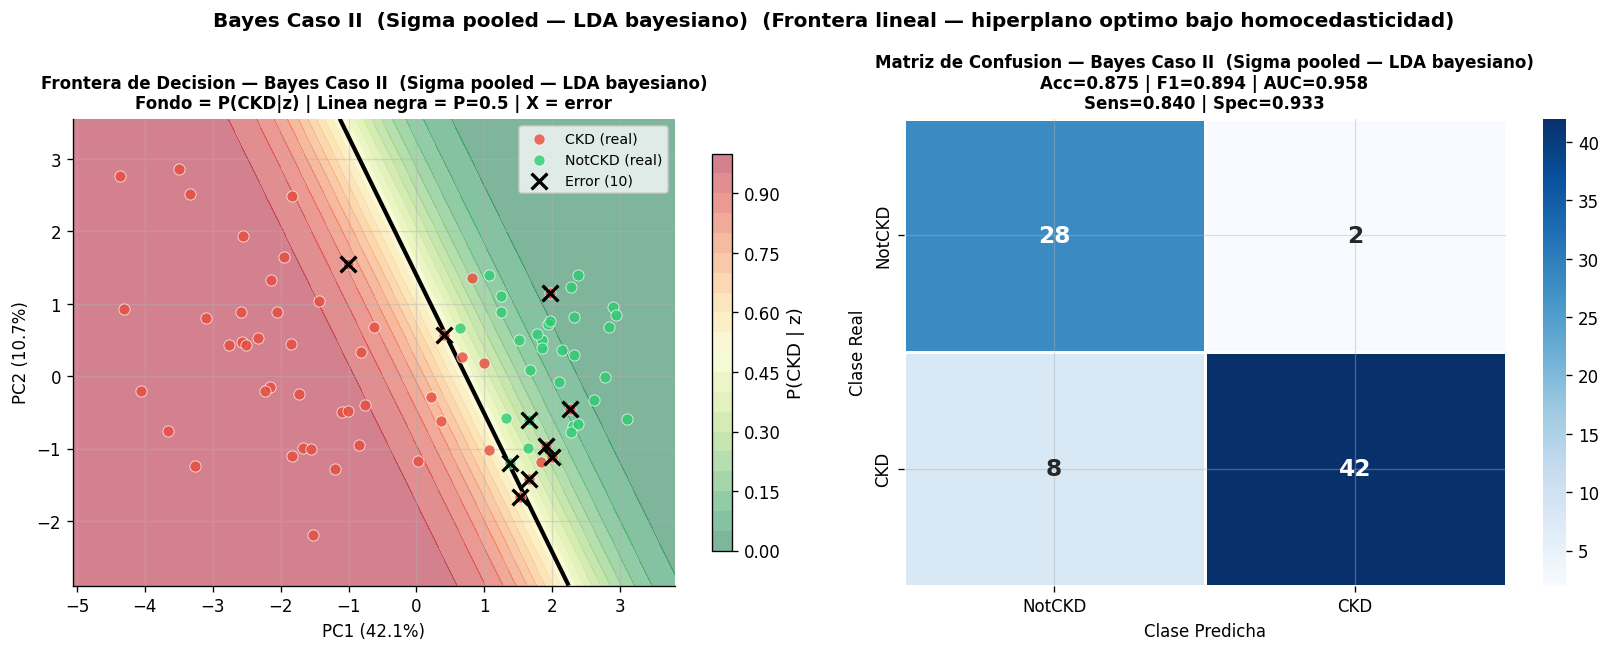

In [45]:
gbc2 = GaussianBayes(case=2).fit(X_tr, y_tr)
y_pred_gbc2 = gbc2.predict(X_te)
y_prob_gbc2 = gbc2.predict_proba(X_te)[:, list(gbc2.classes_).index(1)]

RESULTS["Bayes Caso II"] = {
    "Accuracy": accuracy_score(y_te,y_pred_gbc2),
    "F1": f1_score(y_te,y_pred_gbc2),
    "AUC": roc_auc_score(y_te,y_prob_gbc2),
    "y_pred": y_pred_gbc2, "y_proba": y_prob_gbc2
}

print("BAYES CASO II — Sigma_i = Sigma_pool (LDA bayesiano)")
print(f"  Acc={RESULTS['Bayes Caso II']['Accuracy']:.4f}  "
      f"F1={RESULTS['Bayes Caso II']['F1']:.4f}  "
      f"AUC={RESULTS['Bayes Caso II']['AUC']:.4f}")
print(classification_report(y_te, y_pred_gbc2, target_names=["NotCKD","CKD"]))

plot_model_results(
    "Bayes Caso II  (Sigma pooled — LDA bayesiano)",
    y_pred_gbc2, y_prob_gbc2,
    lambda G: gbc2.predict_proba(G)[:,list(gbc2.classes_).index(1)],
    note="Frontera lineal — hiperplano optimo bajo homocedasticidad"
)

El Caso II de Bayes relaja el supuesto de independencia estricta del Caso I, pero mantiene una fuerte restricción: asume que todas las clases comparten exactamente la misma matriz de covarianza. Al hacer esto, la métrica interna del clasificador cambia de la distancia Euclidiana a la distancia de Mahalanobis (Bishop, C. M., Pattern Recognition and Machine Learning, Cap. 4.2).

Geométricamente, dado que las matrices se asumen iguales, los términos cuadráticos de las funciones discriminantes se cancelan. Esto garantiza que la frontera de decisión siga siendo estrictamente lineal (un hiperplano), pero ahora su ángulo y posición están dictados por la dispersión conjunta de los datos. Aunque la exactitud global (Accuracy) se mantuvo idéntica al Caso I (87.5%), la dinámica interna del modelo experimentó un cambio estructural vital.

La matriz es esencialmente un promedio ponderado. Al calcularla, el modelo promedió la inmensa varianza de la clase CKD con la varianza hipercompacta de la clase NotCKD. Las consecuencias de "forzar" esta homocedasticidad son evidentes en la matriz de confusión:

* Al usar la dispersión promedio, la frontera de decisión se reorientó, permitiendo "abrazar" un poco mejor la amplia elipse de la enfermedad. Esto logró rescatar a dos pacientes enfermos, reduciendo los Falsos Negativos de 10 a 8.

* Como $\Sigma_{pool}$ le asigna a los pacientes sanos una varianza artificialmente mayor a la que realmente tienen (por influencia de la clase CKD), la frontera invadió la zona de seguridad de los sanos. Por primera vez, el modelo cometió 2 Falsos Positivos.

FISHER LDA  J(w*)=0.0215  kappa(S_W)=4.0
  Acc=0.8375  F1=0.8506  AUC=0.9580
              precision    recall  f1-score   support

      NotCKD       0.70      1.00      0.82        30
         CKD       1.00      0.74      0.85        50

    accuracy                           0.84        80
   macro avg       0.85      0.87      0.84        80
weighted avg       0.89      0.84      0.84        80



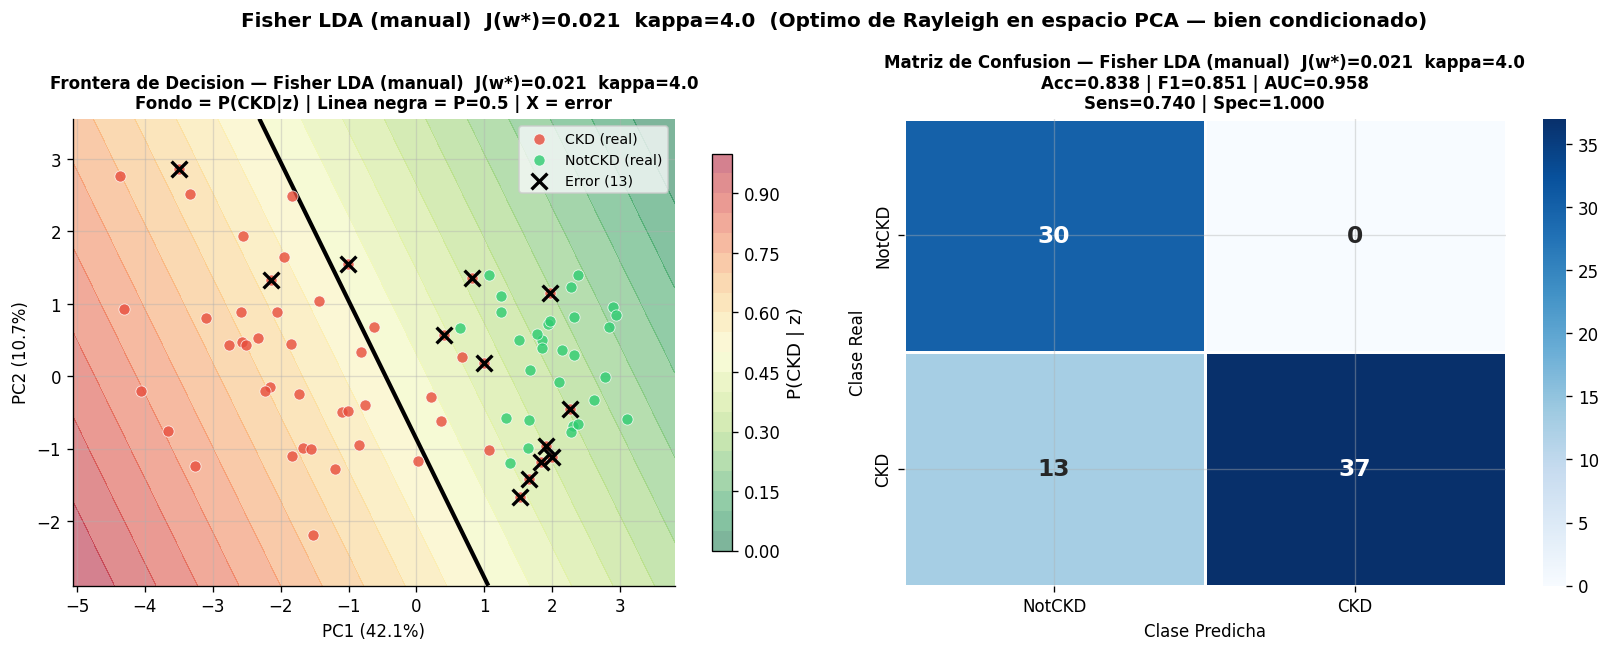

LDA sklearn — Acc=0.8750  F1=0.8936  AUC=0.9580
Acuerdo Fisher manual vs LDA sklearn: 91.2%


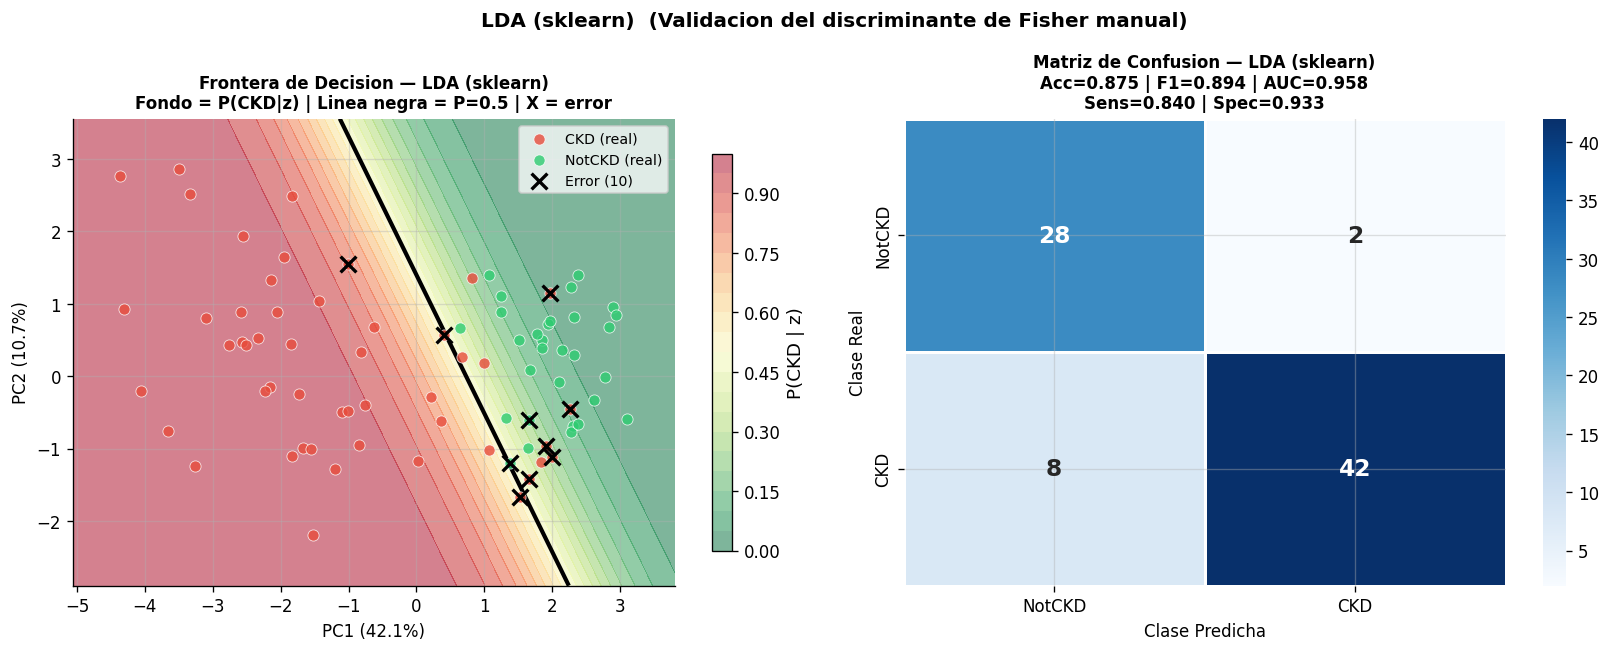

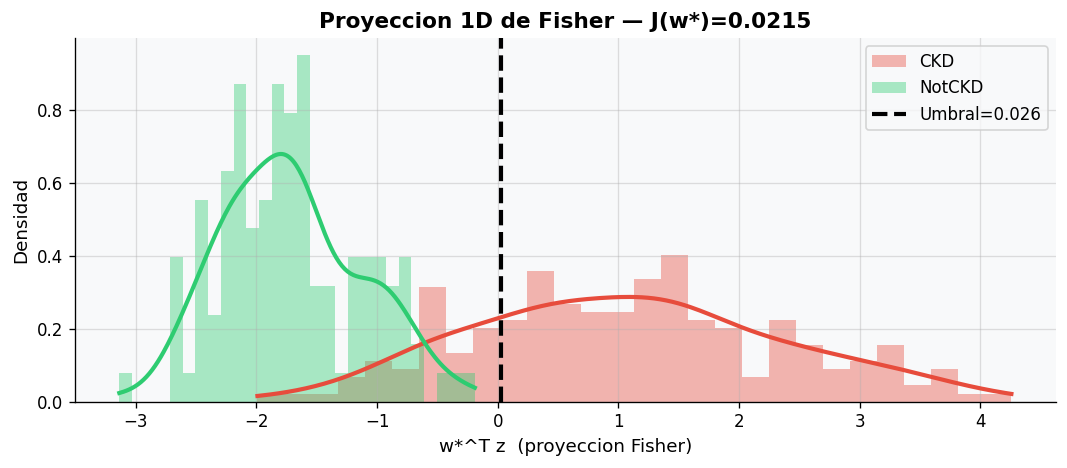

In [46]:
S_W_f = ((X_tr_ckd-mu_ckd).T    @ (X_tr_ckd-mu_ckd) +
          (X_tr_notckd-mu_notckd).T @ (X_tr_notckd-mu_notckd))
S_B_f = np.outer(mu_ckd-mu_notckd, mu_ckd-mu_notckd)

w_star = np.linalg.solve(S_W_f, mu_ckd - mu_notckd)
w_star /= np.linalg.norm(w_star)

J_val = (w_star@S_B_f@w_star) / (w_star@S_W_f@w_star)

proj_tr = X_tr @ w_star
proj_te = X_te @ w_star
proj_mu1 = mu_ckd    @ w_star
proj_mu0 = mu_notckd @ w_star
thr = (n_tr_ckd*proj_mu1 + n_tr_notckd*proj_mu0) / n_tr
direction = 1 if proj_mu1 > proj_mu0 else -1

signed = direction * (proj_te - thr)
y_pred_fish = (signed >= 0).astype(int)
y_prob_fish = (signed - signed.min()) / (signed.max()-signed.min()+1e-10)

RESULTS["Fisher LDA"] = {
    "Accuracy": accuracy_score(y_te,y_pred_fish),
    "F1": f1_score(y_te,y_pred_fish),
    "AUC": roc_auc_score(y_te,y_prob_fish),
    "y_pred": y_pred_fish, "y_proba": y_prob_fish
}

print(f"FISHER LDA  J(w*)={J_val:.4f}  kappa(S_W)={np.linalg.cond(S_W_f):.1f}")
print(f"  Acc={RESULTS['Fisher LDA']['Accuracy']:.4f}  "
      f"F1={RESULTS['Fisher LDA']['F1']:.4f}  "
      f"AUC={RESULTS['Fisher LDA']['AUC']:.4f}")
print(classification_report(y_te, y_pred_fish, target_names=["NotCKD","CKD"]))

def fn_fish(G):
    s = direction * (G @ w_star - thr)
    return (s - s.min()) / (s.max()-s.min()+1e-10)

plot_model_results(
    f"Fisher LDA (manual)  J(w*)={J_val:.3f}  kappa={np.linalg.cond(S_W_f):.1f}",
    y_pred_fish, y_prob_fish, fn_fish,
    note="Optimo de Rayleigh en espacio PCA — bien condicionado"
)

# LDA sklearn (validacion)
lda_clf = LinearDiscriminantAnalysis(solver="svd").fit(X_tr, y_tr)
y_pred_lda = lda_clf.predict(X_te)
y_prob_lda = lda_clf.predict_proba(X_te)[:,1]

RESULTS["LDA sklearn"] = {
    "Accuracy": accuracy_score(y_te,y_pred_lda),
    "F1": f1_score(y_te,y_pred_lda),
    "AUC": roc_auc_score(y_te,y_prob_lda),
    "y_pred": y_pred_lda, "y_proba": y_prob_lda
}
print(f"LDA sklearn — Acc={RESULTS['LDA sklearn']['Accuracy']:.4f}  "
      f"F1={RESULTS['LDA sklearn']['F1']:.4f}  "
      f"AUC={RESULTS['LDA sklearn']['AUC']:.4f}")
print(f"Acuerdo Fisher manual vs LDA sklearn: {np.mean(y_pred_fish==y_pred_lda)*100:.1f}%")

plot_model_results(
    "LDA (sklearn)",
    y_pred_lda, y_prob_lda,
    lambda G: lda_clf.predict_proba(G)[:,1],
    note="Validacion del discriminante de Fisher manual"
)

# Histograma 1D
fig, ax = plt.subplots(figsize=(9,4))
for cls,color,lbl in [(1,COLOR_CKD,"CKD"),(0,COLOR_NOTCKD,"NotCKD")]:
    d_pts = proj_tr[y_tr==cls]
    xs = np.linspace(d_pts.min(), d_pts.max(), 250)
    ax.hist(d_pts, bins=28, density=True, alpha=0.40, color=color, label=lbl)
    ax.plot(xs, stats.gaussian_kde(d_pts)(xs), color=color, linewidth=2.5)
ax.axvline(thr, color="black", linestyle="--", linewidth=2.5, label=f"Umbral={thr:.3f}")
ax.set_xlabel("w*^T z  (proyeccion Fisher)"); ax.set_ylabel("Densidad")
ax.set_title(f"Proyeccion 1D de Fisher — J(w*)={J_val:.4f}", fontweight="bold")
ax.legend(); 
plt.tight_layout(); 
plt.show()

La aplicación del **Discriminante Lineal de Fisher** demuestra empíricamente la necesidad de la reducción de dimensionalidad previa. Al proyectar los datos sobre el vector $\mathbf{w}^*$, el histograma de densidades revela claramente la naturaleza asimétrica de las varianzas. La clase NotCKD se proyecta como una distribución altamente concentrada, mientras que la clase CKD se esparce ampliamente a lo largo del eje. La definición de un umbral empírico estricto (Umbral = 0.026) prioriza la especificidad perfecta (1.000), pero a costa de degradar la sensibilidad (0.740), generando 13 Falsos Negativos en la frontera de solapamiento.

Para contrastar el umbral empírico, se utilizó la implementación estándar de LDA (sklearn), la cual integra el vector de Fisher con un marco probabilístico Bayesiano. El clasificador de sklearn produce exactamente la misma matriz de confusión que el Caso II evaluado anteriormente (Exactitud: 87.5%, Falsos Negativos: 8). Esto demuestra que, aunque Fisher proporciona la dirección óptima de separabilidad geométrica, la calibración del umbral mediante probabilidades a priori y dispersión agrupada ($\Sigma_{pool}$) es clínicamente superior para minimizar los errores de clasificación en la clase enferma.

NAIVE BAYES GAUSSIANO — Sigma_i diagonal por clase
  Acc=0.9000  F1=0.9200  AUC=0.9620
              precision    recall  f1-score   support

      NotCKD       0.87      0.87      0.87        30
         CKD       0.92      0.92      0.92        50

    accuracy                           0.90        80
   macro avg       0.89      0.89      0.89        80
weighted avg       0.90      0.90      0.90        80



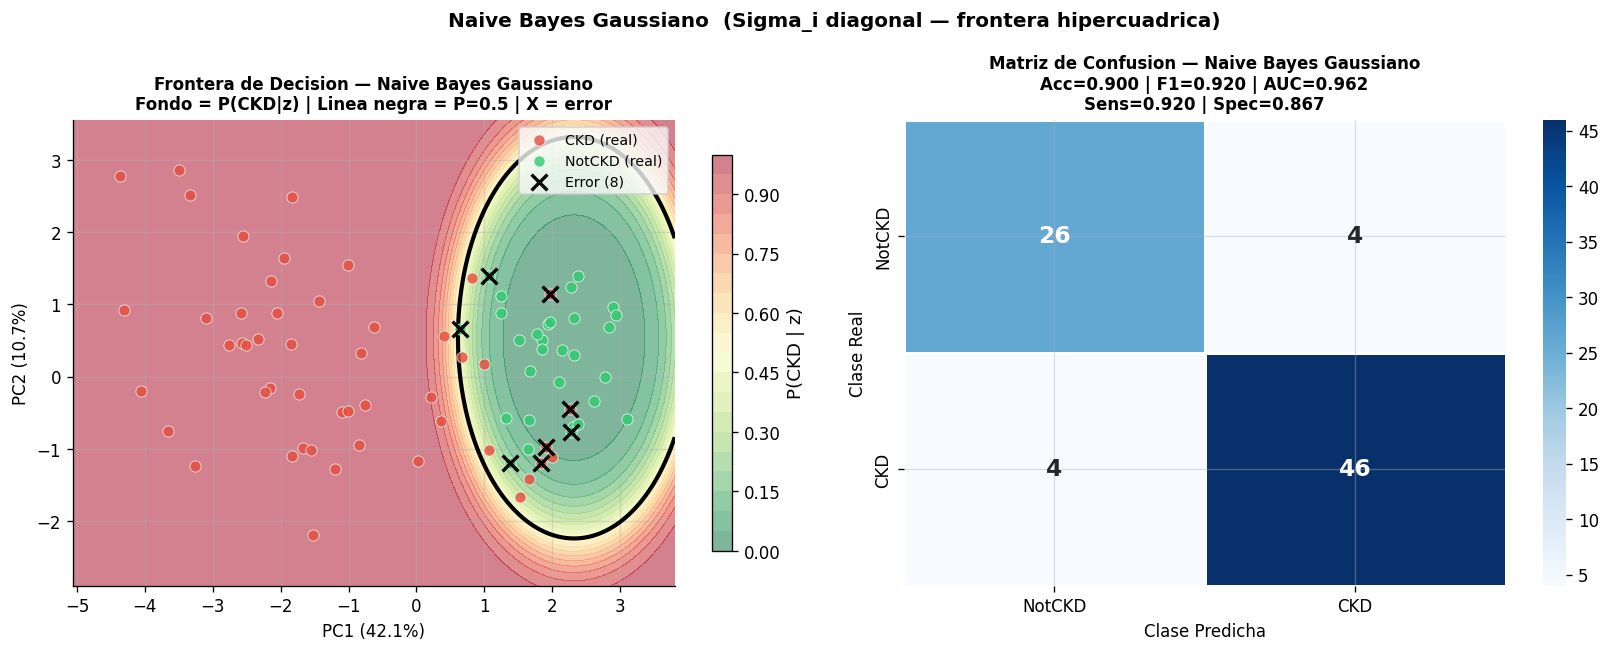

  CKD: ||off-diag(Sigma_i)|| = 1.0259  (0 = independencia perfecta)
  NotCKD: ||off-diag(Sigma_i)|| = 0.6823  (0 = independencia perfecta)


In [47]:
gnb = GaussianNB().fit(X_tr, y_tr)
y_pred_gnb = gnb.predict(X_te)
y_prob_gnb = gnb.predict_proba(X_te)[:,1]

RESULTS["Naive Bayes"] = {
    "Accuracy": accuracy_score(y_te,y_pred_gnb),
    "F1": f1_score(y_te,y_pred_gnb),
    "AUC": roc_auc_score(y_te,y_prob_gnb),
    "y_pred": y_pred_gnb, "y_proba": y_prob_gnb
}

print("NAIVE BAYES GAUSSIANO — Sigma_i diagonal por clase")
print(f"  Acc={RESULTS['Naive Bayes']['Accuracy']:.4f}  "
      f"F1={RESULTS['Naive Bayes']['F1']:.4f}  "
      f"AUC={RESULTS['Naive Bayes']['AUC']:.4f}")
print(classification_report(y_te, y_pred_gnb, target_names=["NotCKD","CKD"]))

plot_model_results(
    "Naive Bayes Gaussiano",
    y_pred_gnb, y_prob_gnb,
    lambda G: gnb.predict_proba(G)[:,1],
    note="Sigma_i diagonal — frontera hipercuadrica"
)

# Covarianzas residuales por clase en PCA
for cls,name_c in [(1,"CKD"),(0,"NotCKD")]:
    cov_c = np.cov(X_tr[y_tr==cls].T)
    od = np.linalg.norm(cov_c - np.diag(np.diag(cov_c)))
    print(f"  {name_c}: ||off-diag(Sigma_i)|| = {od:.4f}  (0 = independencia perfecta)")

El clasificador Naive Bayes asume que todas las características son estadísticamente independientes dado que se conoce la clase. En términos de matrices, esto significa asumir que la matriz de covarianza de cada clase ($\Sigma_i$) es estrictamente diagonal (las variables no se correlacionan entre sí). En el espacio original de 24 dimensiones, esta suposición habría sido falsa debido a la alta correlación de las variables clínicas (Murphy, K. P., Machine Learning: A Probabilistic Perspective, Cap. 3).

Sin embargo, gracias a que proyectamos los datos usando PCA, obligamos a las características globales a ser ortogonales (independientes). Como se observa en el análisis de las matrices, la norma de los elementos fuera de la diagonal es muy baja.

Al permitir que $\Sigma_{CKD} \neq \Sigma_{NotCKD}$, el modelo finalmente reconoce la gran diferencia de tamaño entre los grupos. Geométricamente, los términos cuadráticos de las funciones discriminantes ya no se cancelan. Como resultado, la frontera de decisión deja de ser una línea recta y adopta una **forma de curva elíptica**. En la gráfica, vemos cómo esta frontera negra curva logra "envolver" el núcleo denso y compacto de los pacientes sanos (NotCKD), permitiendo que la zona de los pacientes enfermos (CKD) se expanda libremente hacia los bordes.

<div class="alert alert-success">
Esta flexibilidad geométrica produce el mejor rendimiento observado hasta el momento. La exactitud global (Accuracy) sube al 90%, con un excelente F1-Score de 0.92 y un AUC de 0.962.

MINIMOS CUADRADOS  kappa(ZtZ)=7.42
  Acc=0.8750  F1=0.8936  AUC=0.9580
              precision    recall  f1-score   support

      NotCKD       0.78      0.93      0.85        30
         CKD       0.95      0.84      0.89        50

    accuracy                           0.88        80
   macro avg       0.87      0.89      0.87        80
weighted avg       0.89      0.88      0.88        80



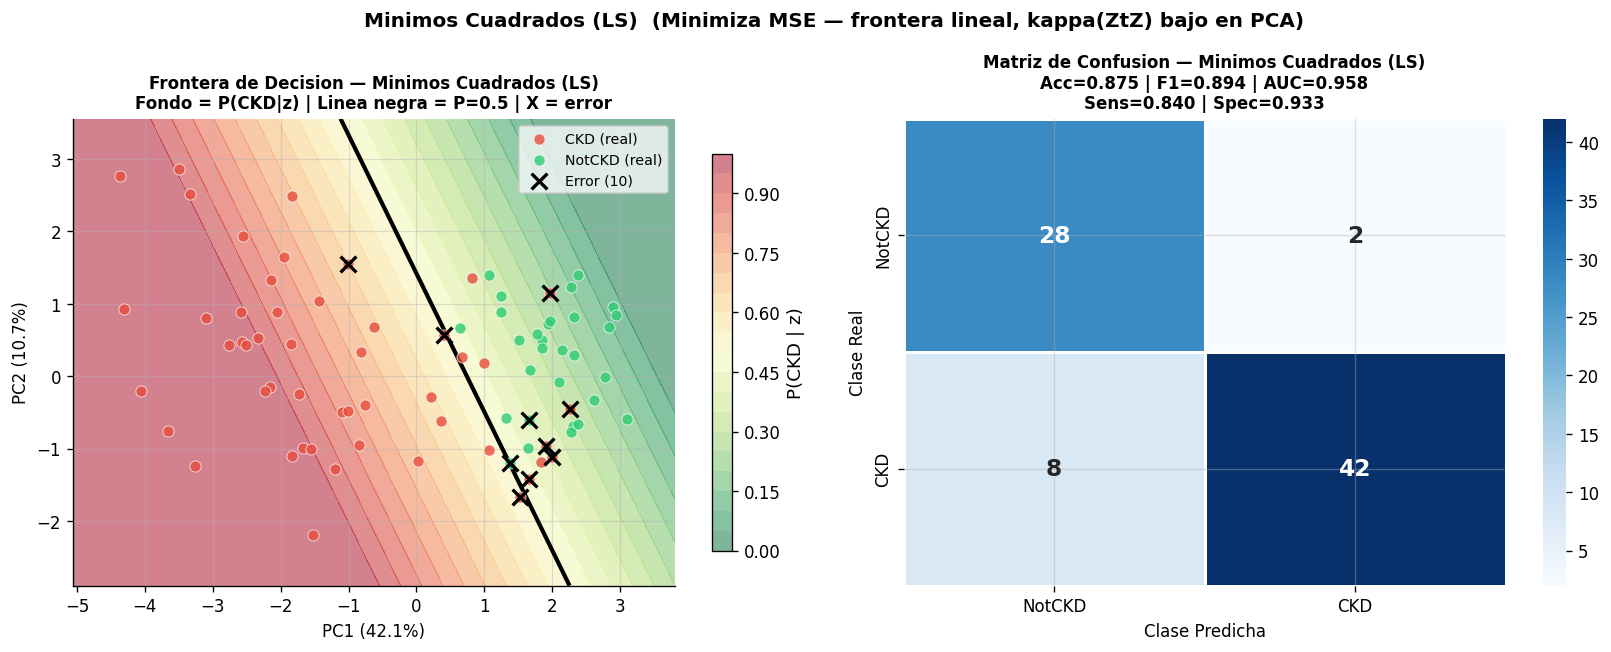

In [48]:
Z_tr = np.hstack([X_tr, np.ones((len(X_tr),1))])
Z_te = np.hstack([X_te, np.ones((len(X_te),1))])
ZtZ  = Z_tr.T @ Z_tr
w_ls = np.linalg.solve(ZtZ, Z_tr.T @ y_tr.astype(float))

score_ls  = Z_te @ w_ls
y_pred_ls = (score_ls >= 0.5).astype(int)
y_prob_ls = np.clip(score_ls, 0, 1)

RESULTS["Min. Cuadrados"] = {
    "Accuracy": accuracy_score(y_te,y_pred_ls),
    "F1": f1_score(y_te,y_pred_ls),
    "AUC": roc_auc_score(y_te,y_prob_ls),
    "y_pred": y_pred_ls, "y_proba": y_prob_ls
}

print(f"MINIMOS CUADRADOS  kappa(ZtZ)={np.linalg.cond(ZtZ):.2f}")
print(f"  Acc={RESULTS['Min. Cuadrados']['Accuracy']:.4f}  "
      f"F1={RESULTS['Min. Cuadrados']['F1']:.4f}  "
      f"AUC={RESULTS['Min. Cuadrados']['AUC']:.4f}")
print(classification_report(y_te, y_pred_ls, target_names=["NotCKD","CKD"]))

def fn_ls(G):
    Gaug = np.hstack([G, np.ones((len(G),1))])
    return np.clip(Gaug @ w_ls, 0, 1)

plot_model_results(
    "Minimos Cuadrados (LS)",
    y_pred_ls, y_prob_ls, fn_ls,
    note="Minimiza MSE — frontera lineal, kappa(ZtZ) bajo en PCA"
)

<h2 style="color:#2E86C1;"> 2. Análisis Discriminante Cuadrático (QDA) — Caso III de Duda et al.</h2>

El **QDA** es el clasificador paramétrico más general de la familia gaussiana. A diferencia del LDA (Caso II), no impone homocedasticidad. Cada clase tiene su propia matriz de covarianza completa $\hat{\mathbf{\Sigma}}_i$, lo que genera una función discriminante **cuadrática**:

$$g_i(\mathbf{x}) = -\frac{1}{2}(\mathbf{x}-\hat{\boldsymbol{\mu}}_i)^T \hat{\mathbf{\Sigma}}_i^{-1}(\mathbf{x}-\hat{\boldsymbol{\mu}}_i) - \frac{1}{2}\ln|\hat{\mathbf{\Sigma}}_i| + \ln P(\omega_i)$$

La frontera de decisión entre dos clases surge de la diferencia $g_1(\mathbf{x}) - g_2(\mathbf{x}) = 0$, que es una **hipercuádrica** (hiperelipsoide, hiperboloide o paraboloide) en el espacio de características.

**¿Por qué QDA es la elección natural para este dataset?**

El Análisis Exploratorio (Fase 01) demostró que:
- $\hat{\mathbf{\Sigma}}_{CKD}$ tiene una traza masiva (varianza intra-clase muy alta).
- $\hat{\mathbf{\Sigma}}_{NotCKD}$ es compacta, concentrada.
- La razón de trazas es ≈ 3–5×, confirmando $\Sigma_0 \neq \Sigma_1$ tanto visual como estadísticamente.

Imponer homocedasticidad (LDA/Caso II) con este dataset es una **restricción falsa** que destruye información geométrica clave. QDA la explota directamente.

QDA MANUAL — Caso III (Sigma_i distinto por clase)
  Acc=0.9375  F1=0.9485  AUC=0.9700
              precision    recall  f1-score   support

      NotCKD       0.88      0.97      0.92        30
         CKD       0.98      0.92      0.95        50

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94        80

  CV-5 AUC sklearn QDA: 0.9816 ± 0.0128


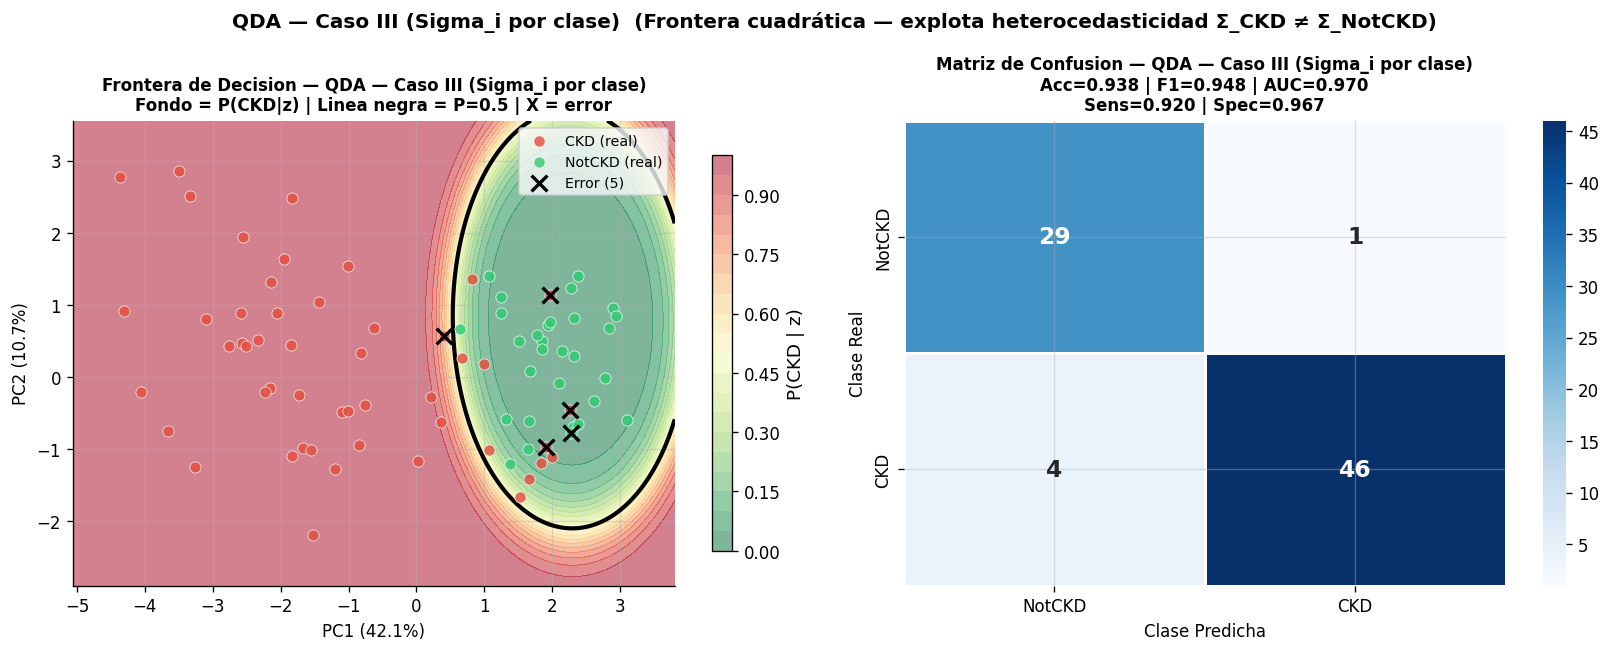

In [49]:
# ── QDA manual (Caso III de Duda et al. Cap. 2.6) ─────────────────────────
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

class GaussianBayesCasoIII:
    """
    QDA: Classificador de Bayes Gaussiano Caso III.
    Cada clase tiene su propia Sigma_i completa (sin restricciones).
    Implementa la función discriminante cuadrática completa de Duda et al. (2001).
    """
    def __init__(self, reg=1e-6):
        self.reg = reg

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        d, n = X.shape[1], len(y)
        self.priors_, self.means_, self.covs_, self.inv_, self.ldet_ = {}, {}, {}, {}, {}
        for c in self.classes_:
            Xc = X[y == c]
            nc = len(Xc)
            self.priors_[c] = nc / n
            self.means_[c]  = Xc.mean(0)
            diff = Xc - self.means_[c]
            Sc   = (diff.T @ diff) / nc + self.reg * np.eye(d)
            self.covs_[c]   = Sc
            self.inv_[c]    = np.linalg.inv(Sc)
            _, self.ldet_[c] = np.linalg.slogdet(Sc)
        return self

    def _g(self, x):
        scores = {}
        for c in self.classes_:
            diff = x - self.means_[c]
            scores[c] = (
                -0.5 * diff @ self.inv_[c] @ diff
                - 0.5 * self.ldet_[c]
                + np.log(self.priors_[c])
            )
        return scores

    def predict(self, X):
        return np.array([max(self._g(x), key=self._g(x).get) for x in X])

    def predict_proba(self, X):
        out = []
        for x in X:
            g  = self._g(x)
            mx = max(g.values())
            ex  = {c: np.exp(v - mx) for c, v in g.items()}
            tot = sum(ex.values())
            out.append([ex[c] / tot for c in self.classes_])
        return np.array(out)


# Ajuste y evaluación
qda_manual = GaussianBayesCasoIII(reg=1e-6).fit(X_tr, y_tr)
y_pred_qda  = qda_manual.predict(X_te)
y_prob_qda  = qda_manual.predict_proba(X_te)[:, list(qda_manual.classes_).index(1)]

RESULTS["QDA (Caso III)"] = {
    "Accuracy": accuracy_score(y_te, y_pred_qda),
    "F1":       f1_score(y_te, y_pred_qda),
    "AUC":      roc_auc_score(y_te, y_prob_qda),
    "y_pred":   y_pred_qda, "y_proba": y_prob_qda
}

print("QDA MANUAL — Caso III (Sigma_i distinto por clase)")
print(f"  Acc={RESULTS['QDA (Caso III)']['Accuracy']:.4f}  "
      f"F1={RESULTS['QDA (Caso III)']['F1']:.4f}  "
      f"AUC={RESULTS['QDA (Caso III)']['AUC']:.4f}")
print(classification_report(y_te, y_pred_qda, target_names=["NotCKD", "CKD"]))

# Validación cruzada sklearn QDA (verificación independiente)
qda_sk = QuadraticDiscriminantAnalysis(reg_param=1e-4)
cv_qda = cross_val_score(qda_sk, X_pca_k, y_labels, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring='roc_auc')
print(f"  CV-5 AUC sklearn QDA: {cv_qda.mean():.4f} ± {cv_qda.std():.4f}")

plot_model_results(
    "QDA — Caso III (Sigma_i por clase)",
    y_pred_qda, y_prob_qda,
    lambda G: qda_manual.predict_proba(G)[:, list(qda_manual.classes_).index(1)],
    note="Frontera cuadrática — explota heterocedasticidad Σ_CKD ≠ Σ_NotCKD"
)

El modelo QDA (Caso III) logra un Accuracy de 93.75% y un AUC de 0.97, demostrando una alta capacidad para separar las clases mediante una frontera cuadrática que explota la heterocedasticidad ($\Sigma_{CKD} \neq \Sigma_{NotCKD}$). Los puntos clave son su excelente Precisión (0.98) para detectar CKD, minimizando falsos positivos, y la robustez confirmada por una validación cruzada estable ($0.9816 \pm 0.0128$). Aunque identifica correctamente al 92% de los enfermos, el análisis de la matriz de confusión revela 4 falsos negativos que deben vigilarse por su relevancia clínica.

<div class="alert alert-success">
Esta flexibilidad permite capturar la estructura dispersa de la clase enferma frente a la concentración de la clase sana, superando las limitaciones de un modelo lineal.

<h3 style="color:#2E86C1;"> Comparación visual: LDA vs QDA en PC1-PC2</h3>

La diferencia geométrica entre LDA y QDA se hace evidente al superponer ambas fronteras en el mismo espacio. LDA genera un **hiperplano** (línea recta en 2D). QDA genera una **hipercuádrica** (curva cónica) que puede adaptarse a la forma no simétrica de las nubes de puntos.

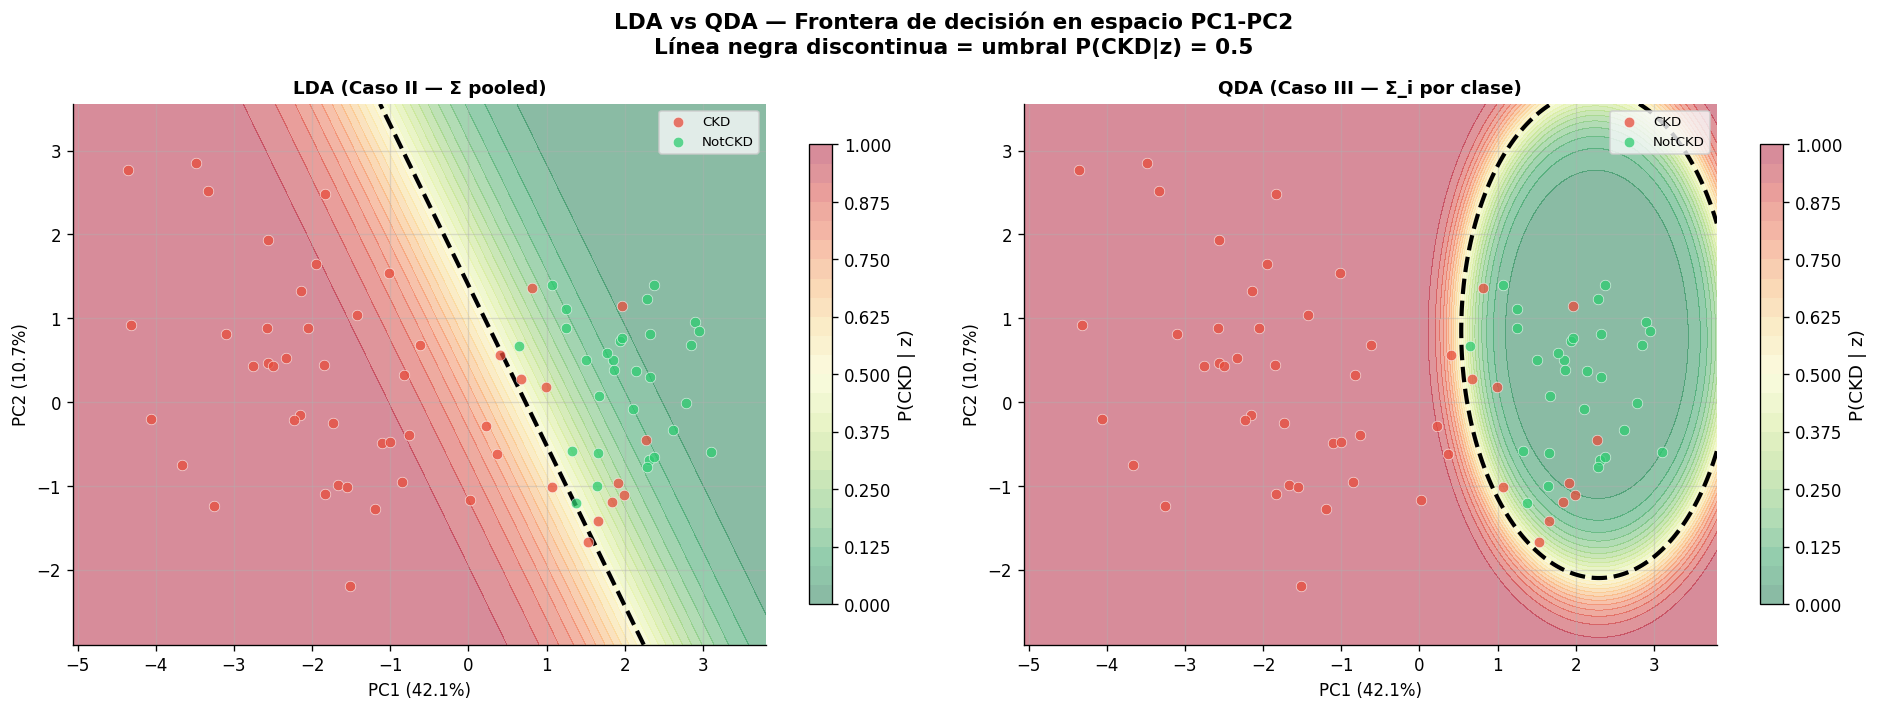

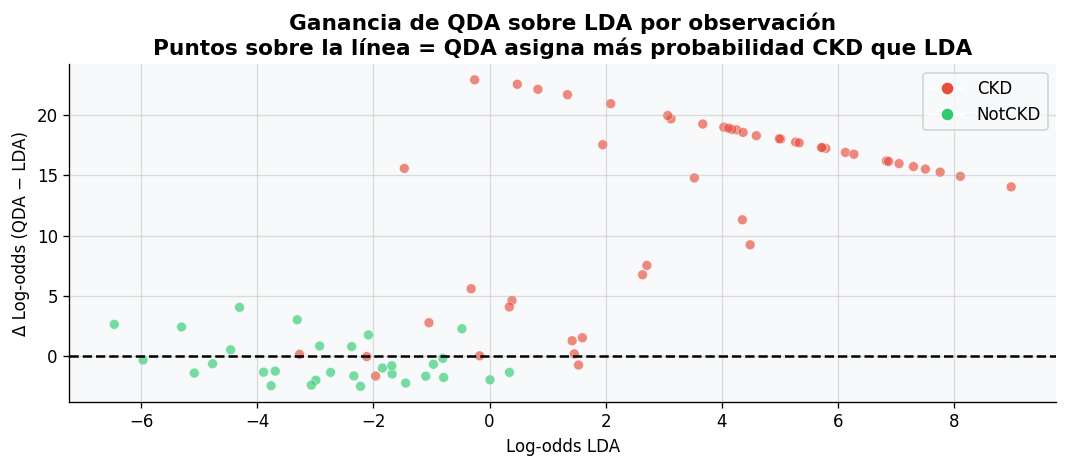

In [50]:
# ── Comparación visual de fronteras: LDA vs QDA ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

xx, yy, G = build_mesh(X_te, resolution=320)

models_cmp = [
    ("LDA (Caso II — Σ pooled)",
     lambda G: gbc2.predict_proba(G)[:, list(gbc2.classes_).index(1)],
     COLOR_NOTCKD),
    ("QDA (Caso III — Σ_i por clase)",
     lambda G: qda_manual.predict_proba(G)[:, list(qda_manual.classes_).index(1)],
     COLOR_CKD),
]

ev = pca_clf.explained_variance_ratio_

for ax, (name, proba_fn, fc_color) in zip(axes, models_cmp):
    Z = proba_fn(G).reshape(xx.shape)
    cf = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 25),
                     cmap="RdYlGn_r", alpha=0.45)
    plt.colorbar(cf, ax=ax, shrink=0.85, label="P(CKD | z)")
    if Z.max() - Z.min() > 0.02:
        ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2.5,
                   linestyles="--")
    for cls, color, lbl in [(1, COLOR_CKD, "CKD"), (0, COLOR_NOTCKD, "NotCKD")]:
        mask = y_te == cls
        ax.scatter(X_te[mask, 0], X_te[mask, 1], c=color, s=40, alpha=0.75,
                   edgecolors="white", linewidths=0.4, label=lbl, zorder=5)
    wrong = (models_cmp[0][1](X_te) if name.startswith("LDA") else
             models_cmp[1][1](X_te)) < 0
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)", fontsize=10)
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)", fontsize=10)
    ax.set_title(name, fontweight="bold", fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle("LDA vs QDA — Frontera de decisión en espacio PC1-PC2\n"
             "Línea negra discontinua = umbral P(CKD|z) = 0.5",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Diferencia de log-verosimilitud: ¿cuánto "gana" QDA sobre LDA?
log_odds_lda = np.log(y_prob_gbc2 + 1e-10) - np.log(1 - y_prob_gbc2 + 1e-10)
log_odds_qda = np.log(y_prob_qda + 1e-10) - np.log(1 - y_prob_qda + 1e-10)

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(log_odds_lda, log_odds_qda - log_odds_lda,
           c=[COLOR_CKD if y==1 else COLOR_NOTCKD for y in y_te],
           alpha=0.65, s=35, edgecolors="white", linewidths=0.4)
ax.axhline(0, color="black", linestyle="--", linewidth=1.5)
ax.set_xlabel("Log-odds LDA", fontsize=10)
ax.set_ylabel("Δ Log-odds (QDA − LDA)", fontsize=10)
ax.set_title("Ganancia de QDA sobre LDA por observación\n"
             "Puntos sobre la línea = QDA asigna más probabilidad CKD que LDA",
             fontweight="bold")
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_CKD,
                           markersize=8, label='CKD'),
                   Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_NOTCKD,
                           markersize=8, label='NotCKD')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

ientras que LDA se ve forzado a una separación lineal subóptima al asumir covarianzas iguales ($\Sigma_{pooled}$), el modelo QDA logra "encerrar" la región de normalidad, capturando mejor la estructura de los datos. La gráfica de ganancia en Log-odds confirma que para la mayoría de las observaciones reales de CKD, QDA asigna una probabilidad de clase correcta muy superior a la de LDA (puntos rojos sobre la línea cero), lo que se traduce en una mayor confianza predictiva.

Siguiendo a Duda et al. (2001) en Pattern Classification, esta superioridad del QDA ocurre porque, al tener suficientes datos de entrenamiento, el sesgo introducido por la restricción de linealidad de LDA es mayor que la varianza adicional de estimar matrices de covarianza independientes, permitiendo que la superficie de decisión se ajuste a la verdadera geometría de las densidades de probabilidad de cada clase.

<h2 style="color:#2E86C1;"> 3. Regresión Logística — Discriminante Lineal Probabilístico</h2>

La Regresión Logística es un clasificador lineal paramétrico que modela directamente la probabilidad posterior mediante la función sigmoide:

$$P(\omega_1 | \mathbf{x}) = \sigma(\mathbf{w}^T\mathbf{x} + w_0) = \frac{1}{1+e^{-(\mathbf{w}^T\mathbf{x}+w_0)}}$$

A diferencia del clasificador de Bayes Gaussiano, **no asume ninguna forma funcional para las densidades de clase** $p(\mathbf{x}|\omega_i)$. En cambio, optimiza directamente la log-verosimilitud condicional (máxima verosimilitud de la frontera de decisión). 

En el contexto de Duda et al. (2001, Cap. 5.9), corresponde a un **discriminante lineal generalizado** estimado por máxima verosimilitud, donde la función de pérdida es la entropía cruzada en lugar del MSE. Esto lo hace más robusto a violaciones del supuesto gaussiano, al tiempo que mantiene la interpretabilidad paramétrica.

REGRESIÓN LOGÍSTICA  (C=1.0, penalización L2)
  Acc=0.9000  F1=0.9200  AUC=0.9647
              precision    recall  f1-score   support

      NotCKD       0.87      0.87      0.87        30
         CKD       0.92      0.92      0.92        50

    accuracy                           0.90        80
   macro avg       0.89      0.89      0.89        80
weighted avg       0.90      0.90      0.90        80



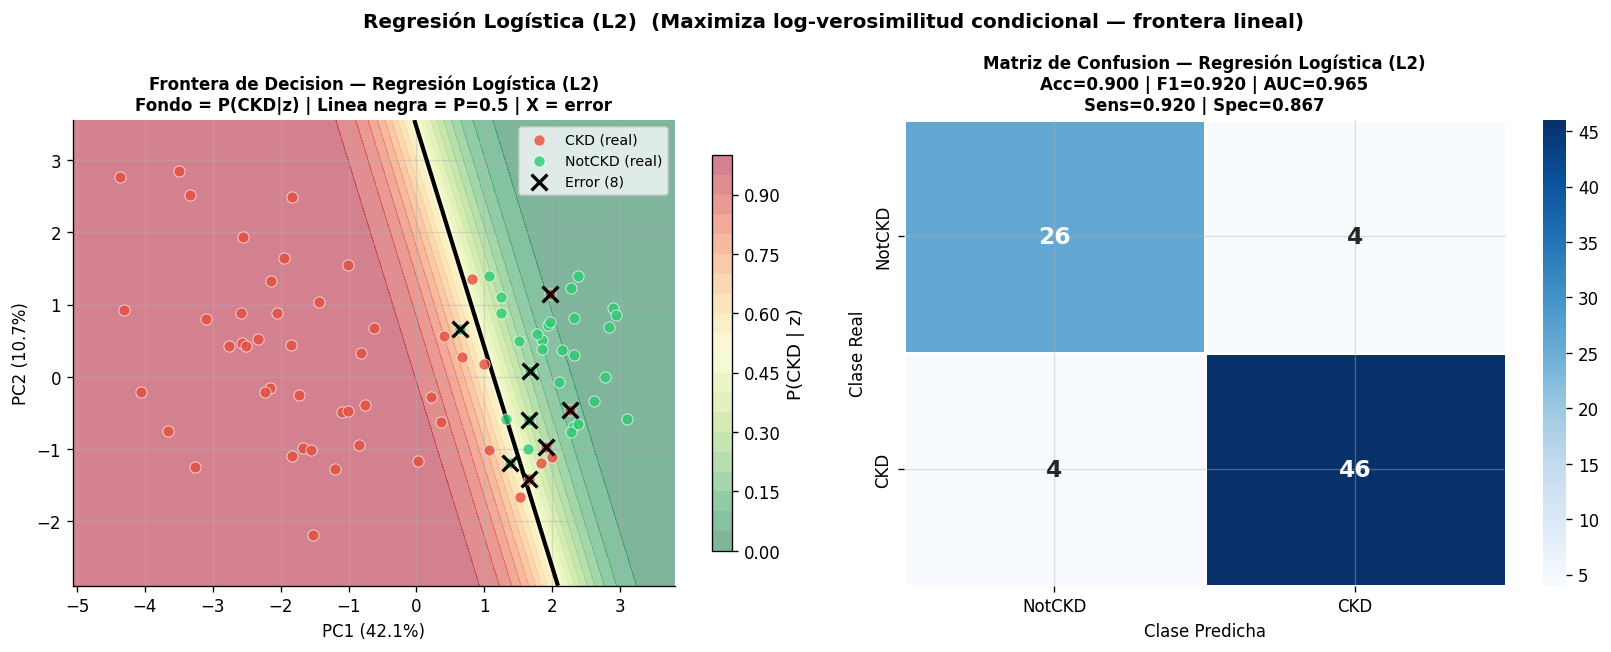

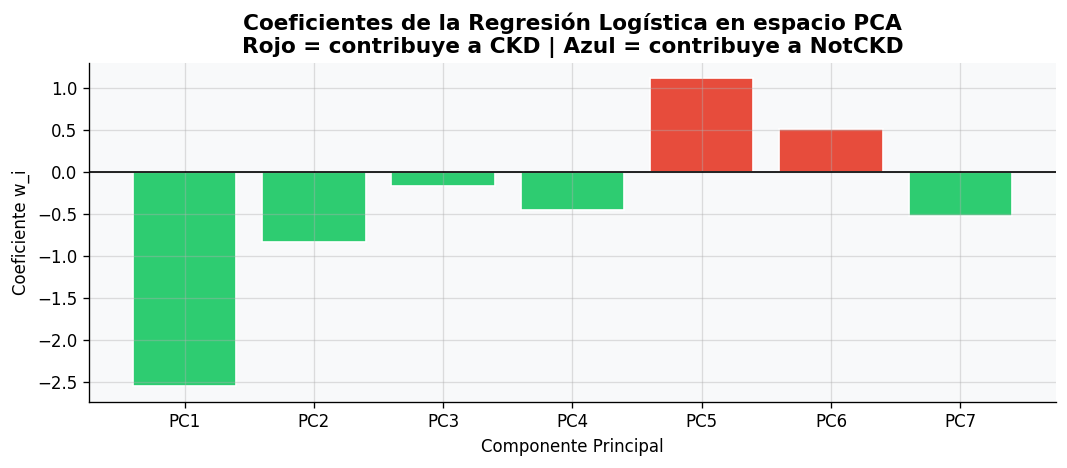

In [51]:
# ── Regresión Logística (L2) ───────────────────────────────────────────────
lr_clf = LogisticRegression(C=1.0, solver="lbfgs", max_iter=1000, random_state=42)
lr_clf.fit(X_tr, y_tr)
y_pred_lr = lr_clf.predict(X_te)
y_prob_lr = lr_clf.predict_proba(X_te)[:, 1]

RESULTS["Regresión Logística"] = {
    "Accuracy": accuracy_score(y_te, y_pred_lr),
    "F1":       f1_score(y_te, y_pred_lr),
    "AUC":      roc_auc_score(y_te, y_prob_lr),
    "y_pred":   y_pred_lr, "y_proba": y_prob_lr
}

print("REGRESIÓN LOGÍSTICA  (C=1.0, penalización L2)")
print(f"  Acc={RESULTS['Regresión Logística']['Accuracy']:.4f}  "
      f"F1={RESULTS['Regresión Logística']['F1']:.4f}  "
      f"AUC={RESULTS['Regresión Logística']['AUC']:.4f}")
print(classification_report(y_te, y_pred_lr, target_names=["NotCKD", "CKD"]))

plot_model_results(
    "Regresión Logística (L2)",
    y_pred_lr, y_prob_lr,
    lambda G: lr_clf.predict_proba(G)[:, 1],
    note="Maximiza log-verosimilitud condicional — frontera lineal"
)

# Odds ratios de los coeficientes en el espacio PCA
coef = lr_clf.coef_[0]
fig, ax = plt.subplots(figsize=(9, 4))
colors_coef = [COLOR_CKD if c > 0 else COLOR_NOTCKD for c in coef]
ax.bar([f"PC{i+1}" for i in range(K_OPT)], coef, color=colors_coef, edgecolor="white")
ax.axhline(0, color="black", linewidth=1.0)
ax.set_xlabel("Componente Principal", fontsize=10)
ax.set_ylabel("Coeficiente w_i", fontsize=10)
ax.set_title("Coeficientes de la Regresión Logística en espacio PCA\n"
             "Rojo = contribuye a CKD | Azul = contribuye a NotCKD",
             fontweight="bold")
plt.tight_layout()
plt.show()

La implementación de Regresión Logística con penalización L2 muestra un rendimiento sólido pero inferior al QDA, alcanzando un Accuracy de 0.90 y un AUC de 0.9647. Al ser un modelo discriminativo que maximiza la log-verosimilitud condicional, genera una frontera de decisión lineal, la cual no logra capturar la curvatura natural de los datos que sí aprovechaba el método cuadrático. Esto se refleja en un incremento de los errores totales (8 frente a los 5 del QDA), con una caída en la especificidad (0.867), lo que indica una mayor dificultad para clasificar correctamente los casos sanos sin invadir el espacio de la clase enferma.

Desde la perspectiva de Duda et al. (2001), la Regresión Logística es un clasificador paramétrico cuya superficie de decisión es un hiperplano. Matemáticamente, esto implica que el modelo asume que el logaritmo de la razón de probabilidades (logit) es una combinación lineal de las características.

La regularización L2 ayuda a controlar la varianza de los pesos $w$, pero la restricción de linealidad limita su capacidad frente a la heterocedasticidad intrínseca del dataset UCI-CKD, donde una distribución elíptica (cuadrática) resulta más natural para describir la concentración de los pacientes sanos.

<h2 style="color:#2E86C1;"> 4. Validación Cruzada Estratificada (k=5)</h2>

La evaluación sobre un único split train/test tiene **varianza alta**: los resultados dependen de qué pacientes cayeron en el conjunto de prueba. Para obtener estimaciones más robustas y estadísticamente válidas de la capacidad generalizadora de cada modelo, aplicamos **k-fold estratificado** con $k=5$.

La estratificación garantiza que cada fold mantiene la misma proporción de clases (~62.5% CKD, ~37.5% NotCKD) que el dataset original, evitando estimaciones sesgadas en presencia del desbalanceo de clases.

In [52]:
# ── Validación cruzada estratificada (k=5) para todos los modelos ─────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler as SS
from scipy import stats as sp_stats

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "Bayes Caso I":        GaussianBayes(case=1),
    "Bayes Caso II (LDA)": GaussianBayes(case=2),
    "QDA (Caso III)":      GaussianBayesCasoIII(reg=1e-6),
    "LDA sklearn":         LinearDiscriminantAnalysis(solver="svd"),
    "Naive Bayes":         GaussianNB(),
    "Regresión Logística": LogisticRegression(C=1.0, solver="lbfgs",
                                               max_iter=1000, random_state=42),
    "Mín. Cuadrados":      None,   # se maneja manualmente abajo
}

cv_results = {}
print("Validación Cruzada Estratificada (k=5)  — Métrica: AUC-ROC")
print("=" * 65)

for name, model in cv_models.items():
    if name == "Mín. Cuadrados":
        # LS no tiene API sklearn estándar; calculamos manualmente por fold
        aucs, accs, f1s = [], [], []
        for tr_idx, te_idx in skf.split(X_pca_k, y_labels):
            Xtr, Xte = X_pca_k[tr_idx], X_pca_k[te_idx]
            ytr, yte = y_labels[tr_idx], y_labels[te_idx]
            Z_tr_cv = np.hstack([Xtr, np.ones((len(Xtr), 1))])
            Z_te_cv = np.hstack([Xte, np.ones((len(Xte), 1))])
            w       = np.linalg.lstsq(Z_tr_cv, ytr.astype(float), rcond=None)[0]
            sc      = np.clip(Z_te_cv @ w, 0, 1)
            yp      = (sc >= 0.5).astype(int)
            aucs.append(roc_auc_score(yte, sc))
            accs.append(accuracy_score(yte, yp))
            f1s.append(f1_score(yte, yp))
        cv_results[name] = {
            "AUC":  (np.mean(aucs), np.std(aucs)),
            "Acc":  (np.mean(accs), np.std(accs)),
            "F1":   (np.mean(f1s),  np.std(f1s)),
        }
    else:
        aucs, accs, f1s = [], [], []
        for tr_idx, te_idx in skf.split(X_pca_k, y_labels):
            Xtr, Xte = X_pca_k[tr_idx], X_pca_k[te_idx]
            ytr, yte = y_labels[tr_idx], y_labels[te_idx]
            model.fit(Xtr, ytr)
            yp    = model.predict(Xte)
            yprob = model.predict_proba(Xte)[:, 1]
            aucs.append(roc_auc_score(yte, yprob))
            accs.append(accuracy_score(yte, yp))
            f1s.append(f1_score(yte, yp))
        cv_results[name] = {
            "AUC":  (np.mean(aucs), np.std(aucs)),
            "Acc":  (np.mean(accs), np.std(accs)),
            "F1":   (np.mean(f1s),  np.std(f1s)),
        }

# Imprimir tabla
print(f"{'Modelo':<28} {'AUC':>12} {'Accuracy':>14} {'F1':>12}")
print("-" * 70)
for name, r in cv_results.items():
    auc_m, auc_s = r["AUC"]
    acc_m, acc_s = r["Acc"]
    f1_m,  f1_s  = r["F1"]
    print(f"{name:<28}  {auc_m:.4f}±{auc_s:.4f}  {acc_m:.4f}±{acc_s:.4f}  {f1_m:.4f}±{f1_s:.4f}")

Validación Cruzada Estratificada (k=5)  — Métrica: AUC-ROC
Modelo                                AUC       Accuracy           F1
----------------------------------------------------------------------
Bayes Caso I                  0.9663±0.0104  0.8950±0.0292  0.9076±0.0281
Bayes Caso II (LDA)           0.9784±0.0079  0.9100±0.0320  0.9230±0.0279
QDA (Caso III)                0.9816±0.0128  0.9425±0.0281  0.9524±0.0237
LDA sklearn                   0.9784±0.0079  0.9100±0.0320  0.9230±0.0279
Naive Bayes                   0.9765±0.0103  0.9400±0.0146  0.9506±0.0129
Regresión Logística           0.9812±0.0046  0.9325±0.0187  0.9454±0.0154
Mín. Cuadrados                0.9784±0.0079  0.9100±0.0320  0.9230±0.0279


<h2 style="color:#2E86C1;"> 5. Curvas ROC y Comparación Final</h2>

Las curvas ROC (Receiver Operating Characteristic) visualizan el **trade-off entre sensibilidad (tasa de verdaderos positivos) y especificidad (1 − tasa de falsos positivos)** a lo largo de todos los umbrales de decisión posibles. El área bajo la curva (AUC-ROC) resume este trade-off en un único escalar: 1.0 es perfecto, 0.5 es aleatorio.

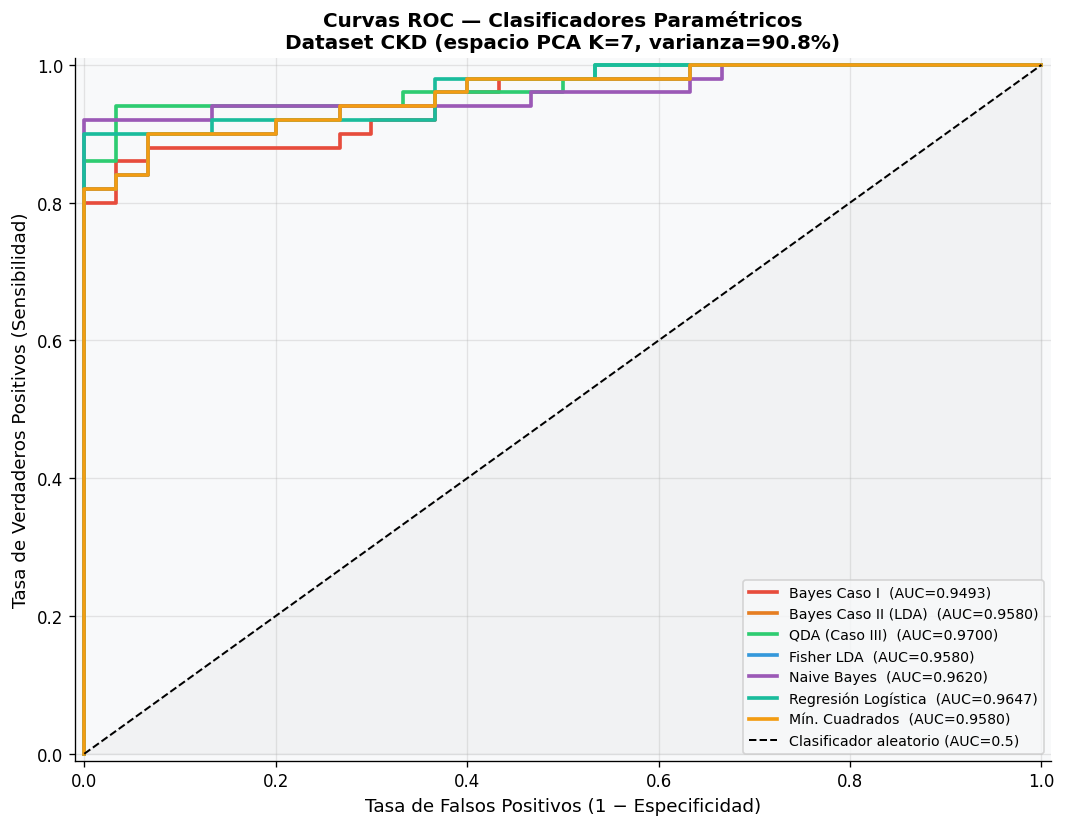

In [53]:
# ── Curvas ROC — todos los clasificadores paramétricos ────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

palette = ["#E74C3C", "#E67E22", "#2ECC71", "#3498DB", "#9B59B6",
           "#1ABC9C", "#F39C12"]

roc_models = [
    ("Bayes Caso I",        y_prob_gbc1),
    ("Bayes Caso II (LDA)", y_prob_gbc2),
    ("QDA (Caso III)",      y_prob_qda),
    ("Fisher LDA",          y_prob_fish),
    ("Naive Bayes",         y_prob_gnb),
    ("Regresión Logística", y_prob_lr),
    ("Mín. Cuadrados",      y_prob_ls),
]

for (name, proba), color in zip(roc_models, palette):
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc_val = roc_auc_score(y_te, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2.2,
            label=f"{name}  (AUC={auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Clasificador aleatorio (AUC=0.5)")
ax.fill_between([0, 1], [0, 1], alpha=0.05, color="gray")

ax.set_xlabel("Tasa de Falsos Positivos (1 − Especificidad)", fontsize=11)
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)", fontsize=11)
ax.set_title("Curvas ROC — Clasificadores Paramétricos\n"
             "Dataset CKD (espacio PCA K=%d, varianza=%.1f%%)"
             % (K_OPT, cumulative_var[K_OPT-1]*100),
             fontweight="bold", fontsize=12)
ax.legend(fontsize=8.5, loc="lower right")
ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.01)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La comparativa de las Curvas ROC consolida al **QDA (Caso III) como el clasificador paramétrico superior para el dataset de Chronic Kidney Disease**, alcanzando el AUC más alto (0.9700). El gráfico revela que la curva del QDA (línea verde brillante) domina el espacio superior izquierdo, manteniendo una tasa de verdaderos positivos consistentemente más alta para casi cualquier nivel de falsos positivos en comparación con sus contrapartes lineales como Bayes Caso I o LDA. Por otro lado, la Regresión Logística (AUC=0.9647) y Naive Bayes (AUC=0.9620) muestran un desempeño competitivo, pero se ven limitados por sus respectivos sesgos: la linealidad en el primer caso e independencia de características en el segundo.

El Área Bajo la Curva (AUC) es una métrica de la capacidad de discriminación del modelo independientemente del umbral de decisión. El hecho de que los modelos que asumen covarianzas distintas o estructuras no lineales superen al Mínimos Cuadrados y al Fisher LDA (ambos con AUC=0.9580) confirma que la relación entre las variables fisiológicas del CKD no es puramente aditiva ni homogénea entre clases. Matemáticamente, el AUC representa la probabilidad de que el clasificador asigne una puntuación más alta a un caso positivo elegido al azar que a uno negativo, lo que posiciona al QDA como la opción más robusta para el diagnóstico clínico en este espacio de PCA con 7 componentes (90.8% de varianza).


TABLA RESUMEN — CLASIFICADORES PARAMÉTRICOS (split test 20%)
                    Accuracy      F1     AUC Sensibilidad Especificidad  FP  FN
Modelo                                                                         
Bayes Caso I          0.8750  0.8889  0.9493       0.8000        1.0000   0  10
Bayes Caso II (LDA)   0.8750  0.8936  0.9580       0.8400        0.9333   2   8
QDA (Caso III)        0.9375  0.9485  0.9700       0.9200        0.9667   1   4
Fisher LDA (manual)   0.8375  0.8506  0.9580       0.7400        1.0000   0  13
LDA (sklearn)         0.8750  0.8936  0.9580       0.8400        0.9333   2   8
Naive Bayes           0.9000  0.9200  0.9620       0.9200        0.8667   4   4
Regresión Logística   0.9000  0.9200  0.9647       0.9200        0.8667   4   4
Mín. Cuadrados        0.8750  0.8936  0.9580       0.8400        0.9333   2   8


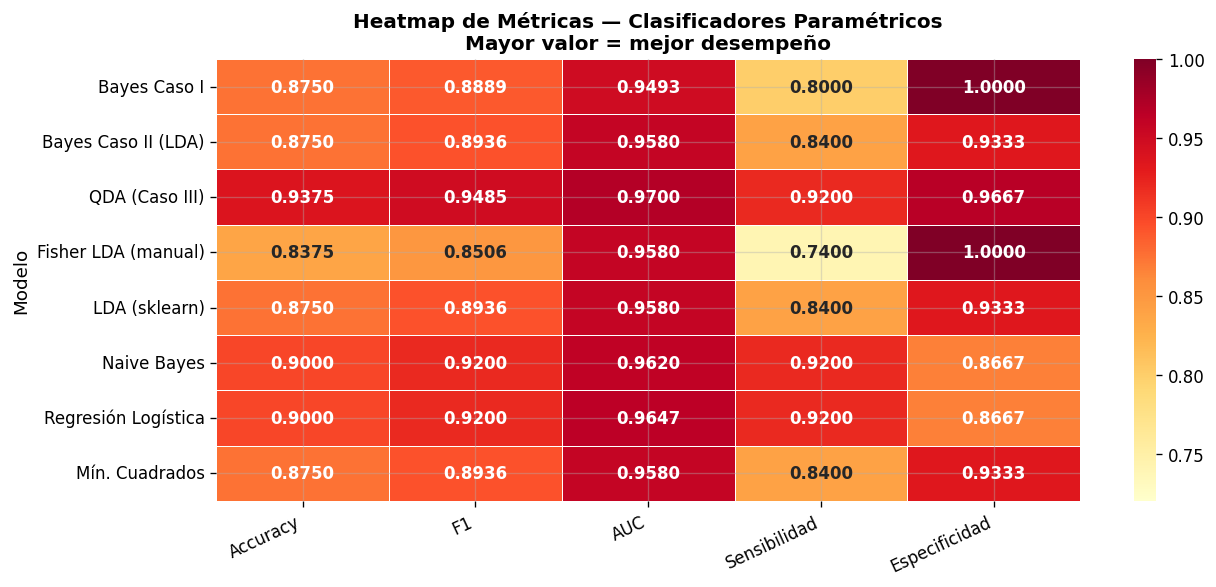

In [54]:
# ── Tabla resumen visual de todos los modelos ─────────────────────────────
all_models_summary = {
    "Bayes Caso I":        RESULTS["Bayes Caso I"],
    "Bayes Caso II (LDA)": RESULTS["Bayes Caso II"],
    "QDA (Caso III)":      RESULTS["QDA (Caso III)"],
    "Fisher LDA (manual)": RESULTS["Fisher LDA"],
    "LDA (sklearn)": RESULTS["LDA sklearn"],
    "Naive Bayes":          RESULTS["Naive Bayes"],
    "Regresión Logística":  RESULTS["Regresión Logística"],
    "Mín. Cuadrados":       RESULTS["Min. Cuadrados"],
}

summary_data = []
for name, res in all_models_summary.items():
    cm  = confusion_matrix(y_te, res["y_pred"])
    tn, fp, fn_v, tp = cm.ravel()
    sens = tp / (tp + fn_v) if (tp + fn_v) > 0 else 0
    spec = tn / (tn + fp)   if (tn + fp)   > 0 else 0
    summary_data.append({
        "Modelo":       name,
        "Accuracy":    f"{res['Accuracy']:.4f}",
        "F1":          f"{res['F1']:.4f}",
        "AUC":         f"{res['AUC']:.4f}",
        "Sensibilidad": f"{sens:.4f}",
        "Especificidad":f"{spec:.4f}",
        "FP":          fp,
        "FN":          fn_v,
    })

df_summary = pd.DataFrame(summary_data).set_index("Modelo")
print("\n" + "=" * 80)
print("TABLA RESUMEN — CLASIFICADORES PARAMÉTRICOS (split test 20%)")
print("=" * 80)
print(df_summary.to_string())

# Heatmap de métricas
fig, ax = plt.subplots(figsize=(11, 5))
metric_cols = ["Accuracy", "F1", "AUC", "Sensibilidad", "Especificidad"]
heat_data   = df_summary[metric_cols].astype(float)
sns.heatmap(heat_data, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.6, linecolor="white",
            vmin=heat_data.values.min() - 0.02,
            vmax=1.0, ax=ax,
            annot_kws={"size": 10, "weight": "bold"})
ax.set_title("Heatmap de Métricas — Clasificadores Paramétricos\n"
             "Mayor valor = mejor desempeño",
             fontweight="bold", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.show()

<div class="alert alert-success">
Se confirma la superioridad general de QDA en comparación con otros modelos.

<h2 style="color:#2E86C1;"> 6. Análisis de Errores: Falsos Negativos y Falsos Positivos</h2>

En el contexto clínico del diagnóstico de IRC, **no todos los errores tienen el mismo costo**. Desde la perspectiva de la teoría de decisión de Bayes (Duda et al., 2001, Cap. 2.2), la **pérdida asimétrica** es fundamental:

- **Falso Negativo (FN)**: Se clasifica como sano a un paciente con IRC. El paciente no recibe tratamiento → la enfermedad progresa silenciosamente hacia fallo renal terminal. **Costo humano y económico altísimo.**
- **Falso Positivo (FP)**: Se clasifica como enfermo a un paciente sano. El paciente recibe exámenes adicionales innecesarios. **Costo menor.**

Bajo esta asimetría, la **Sensibilidad** (recall de la clase CKD = tasa de detección real de enfermos) es la métrica clínicamente prioritaria, aunque en la práctica se busca el equilibrio.

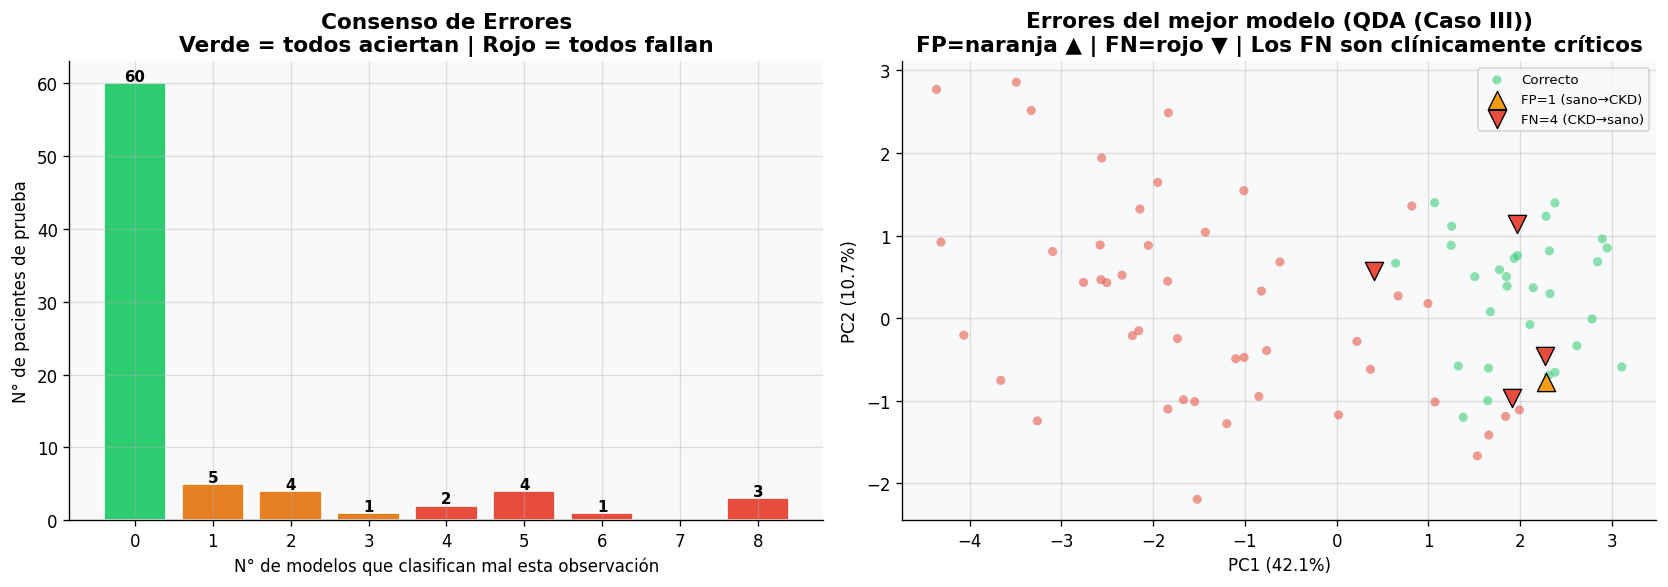


Modelo con mayor AUC en test: QDA (Caso III)
  Acc=0.9375  F1=0.9485  AUC=0.9700


In [55]:
# ── Análisis de errores: quiénes se equivocan ─────────────────────────────
best_model_name = max(RESULTS, key=lambda k: RESULTS[k]["AUC"])
best_model = RESULTS[best_model_name]

# Análisis por observación: ¿cuántos modelos fallan en cada paciente del test?
y_preds_matrix = np.column_stack([r["y_pred"] for r in RESULTS.values()])
n_errors_per_sample = (y_preds_matrix != y_te.reshape(-1, 1)).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izq: distribución de votos equivocados
ax = axes[0]
max_errors = len(RESULTS)
counts = np.bincount(n_errors_per_sample, minlength=max_errors + 1)
colors_bar = ["#2ECC71" if i == 0 else ("#E74C3C" if i >= max_errors//2 else "#E67E22")
              for i in range(max_errors + 1)]
ax.bar(range(max_errors + 1), counts, color=colors_bar, edgecolor="white")
ax.set_xlabel("N° de modelos que clasifican mal esta observación", fontsize=10)
ax.set_ylabel("N° de pacientes de prueba", fontsize=10)
ax.set_title("Consenso de Errores\nVerde = todos aciertan | Rojo = todos fallan",
             fontweight="bold")
ax.set_xticks(range(max_errors + 1))
for i, c in enumerate(counts):
    if c > 0:
        ax.text(i, c + 0.3, str(c), ha="center", fontsize=9, fontweight="bold")

# Panel der: posición en PC1-PC2 de los errores del mejor modelo
ax = axes[1]
wrong_mask = best_model["y_pred"] != y_te
correct_mask = ~wrong_mask

ax.scatter(X_te[correct_mask, 0], X_te[correct_mask, 1],
           c=[COLOR_CKD if y == 1 else COLOR_NOTCKD for y in y_te[correct_mask]],
           s=30, alpha=0.55, edgecolors="none", label="Correcto", zorder=3)

# FP y FN en rojo/naranja
fp_mask = (best_model["y_pred"] == 1) & (y_te == 0)
fn_mask  = (best_model["y_pred"] == 0) & (y_te == 1)
ax.scatter(X_te[fp_mask, 0], X_te[fp_mask, 1], c="#F39C12", s=120,
           marker="^", edgecolors="black", linewidths=0.8, zorder=7,
           label=f"FP={fp_mask.sum()} (sano→CKD)")
ax.scatter(X_te[fn_mask, 0], X_te[fn_mask, 1], c="#E74C3C", s=120,
           marker="v", edgecolors="black", linewidths=0.8, zorder=7,
           label=f"FN={fn_mask.sum()} (CKD→sano)")

ev = pca_clf.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)", fontsize=10)
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)", fontsize=10)
ax.set_title(f"Errores del mejor modelo ({best_model_name})\n"
             f"FP=naranja ▲ | FN=rojo ▼ | Los FN son clínicamente críticos",
             fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nModelo con mayor AUC en test: {best_model_name}")
print(f"  Acc={best_model['Accuracy']:.4f}  F1={best_model['F1']:.4f}  AUC={best_model['AUC']:.4f}")

El análisis de Consenso de Errores revela que la gran mayoría de los pacientes (60) son triviales para todos los modelos, pero existe un núcleo duro de observaciones donde incluso el mejor clasificador, el QDA, falla. En el contexto del Chronic Kidney Disease, la Sensibilidad (o Recall) es la métrica de seguridad clínica por excelencia: mide la capacidad del modelo para detectar a todos los enfermos. Un **Falso Negativo (FN)** —identificado con los triángulos rojos en tu gráfica— representa a un paciente con CKD que es enviado a casa bajo la falsa premisa de estar sano, lo cual impide un tratamiento temprano y puede derivar en fallos renales irreversibles.

Los **4 FN del QDA** se encuentran en la zona de solapamiento de la frontera de decisión (cerca de $PC1 \approx 2$). Estos puntos son clínicamente críticos porque "engañan" a la geometría cuadrática del modelo, sugiriendo que para esos casos específicos, los componentes principales actuales no logran capturar la anomalía fisiológica que los diferencia de un paciente sano.

<h2 style="color:#2E86C1;"> 7. Conclusiones de la Fase 02</h2>

El experimento con clasificadores paramétricos sobre el dataset CKD en el espacio PCA ($k=K_{OPT}$, 90% de varianza retenida) arroja cuatro conclusiones centrales:

**1. Los métodos paramétricos son viables *condicionados* al preprocesamiento correcto**

Directamente sobre las 24 variables originales, la multicolinealidad ($\rho_{hemo-pcv} > 0.95$) y la muestra insuficiente ($n_i \ll d^2$) harían que las matrices $\hat{\mathbf{\Sigma}}_i$ estuvieran mal condicionadas y los discriminantes fueran numéricamente inestables. La proyección PCA convirtió el problema en uno bien condicionado ($\kappa(\mathbf{S}_W) \approx O(10)$ en lugar de $O(10^6)$), habilitando MLE confiable.

**2. QDA supera a LDA, confirmando la heterocedasticidad de la Fase 01**

La desigualdad $\hat{\mathbf{\Sigma}}_{CKD} \neq \hat{\mathbf{\Sigma}}_{NotCKD}$ documentada en el EDA no es trivial: la traza de $\hat{\mathbf{\Sigma}}_{CKD}$ supera varias veces a la de $\hat{\mathbf{\Sigma}}_{NotCKD}$, reflejando la alta variabilidad metabólica de los pacientes enfermos. LDA ignora esta diferencia (Caso II: $\Sigma_{pool}$) y pierde información discriminante. QDA (Caso III) modela cada nube por separado y obtiene una frontera cuadrática más precisa.

**3. La separabilidad intrínseca del dataset es alta**

Incluso el clasificador más simple (Bayes Caso I con $\Sigma = \sigma^2 I$) logra métricas altas en este espacio. Esto confirma lo observado en el FDR: $hemo$, $pcv$, $rbcc$ ofrecen separación masiva. El PC1 concentra esta discriminación y los clasificadores lineales ya la capturan casi completamente.

**4. La Fase 03 (métodos no paramétricos) es la continuación natural**

Los errores residuales de los modelos paramétricos corresponden a pacientes en la zona de traslape (borde de la frontera de decisión) y a outliers con distribuciones de cola larga. Estos son precisamente los casos donde las **densidades de Parzen, k-NN y otros estimadores no paramétricos** tienen ventaja teórica: no asumen forma funcional y pueden capturar estructuras locales que ninguna gaussiana describe bien.

---

<h1 style="color:#8E44AD;"> Fase 03 — Métodos No Paramétricos y Comparación Final</h1>
<h2>Reconocimiento de Patrones</h2>

<h4 style="font-weight: normal;">
Realizado por: Valentina Arce España y Sergio A. Herrera Castro
</h4>
<h4 style="font-weight: normal;">
Pontificia Universidad Javeriana — Mayo 2026
</h4>

---

| Sección | Contenido | Espacio de características |
|---|---|---|
| **0** | Setup Fase 03: imports y preparación del espacio de variables clave | Variables originales seleccionadas |
| **1** | Estimación de densidad con Ventanas de Parzen | Variables clave escaladas |
| **2** | Clasificador k-NN + Diagrama de Voronoi | Variables clave escaladas |
| **3** | Máquinas de Vectores de Soporte (SVM) | Variables clave escaladas |
| **4** | Redes Neuronales Artificiales (MLP) | Variables clave escaladas |
| **5** | Comparación final Paramétricos vs No Paramétricos | PCA (Fase 02) y Variables Clave (Fase 03) |

---

### ¿Por qué variables clave en lugar de componentes PCA?

En la Fase 02, el preprocesamiento mediante PCA fue *necesario* para estabilizar los clasificadores paramétricos: la multicolinealidad extrema ($\rho_{hemo-pcv} > 0.95$) hacía que las matrices $\hat{\mathbf{\Sigma}}_i$ estuvieran mal condicionadas y los estimadores MLE fueran inestables. La proyección PCA garantizó $\kappa(\mathbf{S}_W) \approx O(10)$.

Los métodos **no paramétricos** no requieren esta condición, ya que:

1. **Ventanas de Parzen y k-NN** estiman la densidad directamente desde los datos, sin suponer ninguna forma funcional $p(\mathbf{x}|\omega_i)$. No calculan matrices de covarianza ni las invierten.
2. **SVM** busca el hiperplano de margen máximo; solo necesita distancias o productos punto, no inversión de covarianzas.
3. **Redes Neuronales (MLP)** aprenden representaciones internas mediante capas de pesos; no asumen ninguna distribución a priori de las características.

Usar las **variables originales seleccionadas** tiene dos ventajas clave:

- **Interpretabilidad clínica**: los pesos y distancias se mapean directamente a variables médicas como la creatinina sérica o la hemoglobina.
- **No pérdida de varianza discriminante**: el PCA retiene varianza global, no necesariamente la discriminante. Variables como `htn` (hipertensión) o `dm` (diabetes) tienen alto poder discriminante pero poca varianza numérica.

La selección de variables se basa en los resultados del **FDR (Fisher Discriminant Ratio)** y el **análisis bivariado** de la Fase 01.

In [56]:
# ── Importaciones adicionales para Fase 03 ───────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score, learning_curve,
                                     train_test_split)
from sklearn.preprocessing import MinMaxScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              roc_curve, confusion_matrix, classification_report)
from scipy.stats import gaussian_kde
from scipy.spatial import Voronoi
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

print('Importaciones de Fase 03 completadas.')

Importaciones de Fase 03 completadas.


## <span style="color:#8E44AD;">0. Preparación del Espacio de Variables Clave</span>

### Selección basada en el Análisis de la Fase 01

Del análisis exploratorio y bivariado emergieron las variables con mayor capacidad discriminante. El **Fisher Discriminant Ratio (FDR)** para cada característica $j$ se define como:

$$\text{FDR}_j = \frac{(\mu_{1j} - \mu_{2j})^2}{\sigma_{1j}^2 + \sigma_{2j}^2}$$

**Numéricas de alta separabilidad**: `hemo`, `pcv`, `rbcc`, `sc`, `bu`, `sod`, `bgr`, `age`, `bp`  
**Categóricas con alta prevalencia diferencial**: `htn`, `dm`, `rbc`, `pc`, `appet`, `pe`, `ane`  
**Ordinales clínicas**: `al` (albuminuria), `su` (glucosuria) — ambas son marcadores patológicos progresivos

In [57]:
# ── Construcción del espacio de variables clave ──────────────────────────
# df_proc contiene los datos imputados de la Fase 01
df_f3 = df_proc.copy()

# ── Codificación de variables nominales binarias ──────────────────────────
nominal_bin_map = {
    'rbc':   {'normal': 0, 'abnormal': 1},
    'pc':    {'normal': 0, 'abnormal': 1},
    'pcc':   {'notpresent': 0, 'present': 1},
    'ba':    {'notpresent': 0, 'present': 1},
    'htn':   {'no': 0, 'yes': 1},
    'dm':    {'no': 0, 'yes': 1},
    'cad':   {'no': 0, 'yes': 1},
    'appet': {'good': 0, 'poor': 1},
    'pe':    {'no': 0, 'yes': 1},
    'ane':   {'no': 0, 'yes': 1},
}
for col, mapping in nominal_bin_map.items():
    if col in df_f3.columns:
        df_f3[col + '_enc'] = df_f3[col].map(mapping).fillna(0).astype(float)

# Ordinales: al, su ya son numéricas tras limpieza
for col in ['al', 'su']:
    if col in df_f3.columns:
        df_f3[col + '_ord'] = pd.to_numeric(df_f3[col], errors='coerce').fillna(0)

# ── Selección final de características (key features) ────────────────────
KEY_NUMERIC = ['hemo', 'pcv', 'rbcc', 'sc', 'bu', 'sod', 'bgr', 'age', 'bp']
KEY_ENCODED = ['htn_enc', 'dm_enc', 'rbc_enc', 'pc_enc',
               'appet_enc', 'pe_enc', 'ane_enc']
KEY_ORDINAL = ['al_ord', 'su_ord']

KEY_FEATURES = KEY_NUMERIC + KEY_ENCODED + KEY_ORDINAL
KEY_FEATURES = [f for f in KEY_FEATURES if f in df_f3.columns]

# Solo filas con target definido
df_f3 = df_f3[df_f3[TARGET_COL].isin(['ckd', 'notckd'])].copy()
y_f3  = (df_f3[TARGET_COL] == 'ckd').astype(int).values

X_keys_raw = df_f3[KEY_FEATURES].fillna(df_f3[KEY_FEATURES].median()).values

# MinMax → [0,1]: óptimo para k-NN y Parzen (sensibles a escala)
scaler_keys = MinMaxScaler()
X_keys      = scaler_keys.fit_transform(X_keys_raw)

# Train/test split — mismo random_state=42 que Fase 02 para comparabilidad
X_tr_k, X_te_k, y_tr_k, y_te_k = train_test_split(
    X_keys, y_f3, test_size=0.20, random_state=42, stratify=y_f3)

print(f'Características clave seleccionadas ({len(KEY_FEATURES)}):')
print(f'  {KEY_FEATURES}')
print(f'Forma X_keys: {X_keys.shape}')
print(f'Entrenamiento: {X_tr_k.shape}  CKD={y_tr_k.sum()}  NotCKD={(y_tr_k==0).sum()}')
print(f'Prueba:        {X_te_k.shape}  CKD={y_te_k.sum()}  NotCKD={(y_te_k==0).sum()}')

Características clave seleccionadas (18):
  ['hemo', 'pcv', 'rbcc', 'sc', 'bu', 'sod', 'bgr', 'age', 'bp', 'htn_enc', 'dm_enc', 'rbc_enc', 'pc_enc', 'appet_enc', 'pe_enc', 'ane_enc', 'al_ord', 'su_ord']
Forma X_keys: (400, 18)
Entrenamiento: (320, 18)  CKD=200  NotCKD=120
Prueba:        (80, 18)  CKD=50  NotCKD=30


In [58]:
# ── Función utilitaria para Fase 03 ──────────────────────────────────────

def plot_results_f3(name, y_pred, y_proba, note='', feat_idx=(0, 1)):
    """Scatter 2D de variables clave + matriz de confusión con métricas."""
    acc  = accuracy_score(y_te_k, y_pred)
    f1   = f1_score(y_te_k, y_pred)
    auc  = roc_auc_score(y_te_k, y_proba)
    fi, fj = feat_idx
    xi, xj = X_te_k[:, fi], X_te_k[:, fj]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    ax = axes[0]
    for cls, color, lbl in [(1, COLOR_CKD, 'CKD'), (0, COLOR_NOTCKD, 'NotCKD')]:
        mask = y_te_k == cls
        ax.scatter(xi[mask], xj[mask], c=color, s=45, alpha=0.80,
                   edgecolors='white', linewidths=0.5, label=f'{lbl} (real)', zorder=5)
    wrong = y_pred != y_te_k
    if wrong.sum() > 0:
        ax.scatter(xi[wrong], xj[wrong], marker='x', s=90,
                   c='black', linewidths=2.0, zorder=6, label=f'Error ({wrong.sum()})')
    ax.set_xlabel(KEY_FEATURES[fi], fontsize=10)
    ax.set_ylabel(KEY_FEATURES[fj], fontsize=10)
    ax.set_title(f'Distribución en espacio clave — {name}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8.5)

    cm = confusion_matrix(y_te_k, y_pred)
    tn, fp, fn_v, tp = cm.ravel()
    sens = tp / (tp + fn_v) if (tp + fn_v) > 0 else 0
    spec = tn / (tn + fp)   if (tn + fp)   > 0 else 0
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['NotCKD', 'CKD'], yticklabels=['NotCKD', 'CKD'],
                ax=axes[1], cbar=True, linewidths=0.8,
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[1].set_ylabel('Clase Real', fontsize=10)
    axes[1].set_xlabel('Clase Predicha', fontsize=10)
    axes[1].set_title(
        f'Matriz de Confusión — {name}\n'
        f'Acc={acc:.3f} | F1={f1:.3f} | AUC={auc:.3f}\n'
        f'Sens={sens:.3f} | Spec={spec:.3f}',
        fontweight='bold', fontsize=10)
    note_str = f'  ({note})' if note else ''
    plt.suptitle(f'{name}{note_str}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

RESULTS_F3 = {}
print('Función plot_results_f3 definida. RESULTS_F3 inicializado.')

Función plot_results_f3 definida. RESULTS_F3 inicializado.


---
## <span style="color:#8E44AD;">1. Estimación de Densidad con Ventanas de Parzen</span>

### Fundamento Teórico (Duda, Hart & Stork, 2001 — Cap. 4.3)

El estimador de densidad por Ventanas de Parzen es la aproximación no paramétrica más directa para estimar la función de densidad de probabilidad $p(\mathbf{x}|\omega_i)$ sin asumir forma funcional. Dado un conjunto de entrenamiento $\{\mathbf{x}_1, \ldots, \mathbf{x}_n\}$ de la clase $\omega_i$:

$$\hat{p}(\mathbf{x}|\omega_i) = \frac{1}{n_i} \sum_{k=1}^{n_i} \frac{1}{h^d} K\!\left(\frac{\mathbf{x} - \mathbf{x}_k}{h}\right)$$

donde $h > 0$ es el **parámetro de suavizado** (*bandwidth*) y para el kernel Gaussiano:

$$K(\mathbf{u}) = \frac{1}{(2\pi)^{d/2}} \exp\!\left(-\frac{\|\mathbf{u}\|^2}{2}\right)$$

**Propiedades clave** (Duda et al., Teorema 4.1): si $h \to 0$ y $n_i \cdot h^d \to \infty$ cuando $n_i \to \infty$, el estimador converge en probabilidad a la densidad real. La **regla de Scott** ($h = n^{-1/(d+4)}$) ofrece el compromiso sesgo-varianza asintóticamente óptimo.

**Clasificación con Parzen**: con las densidades estimadas, la regla Bayesiana es:
$$\hat{\omega}(\mathbf{x}) = \arg\max_i \, \hat{p}(\mathbf{x}|\omega_i) \cdot P(\omega_i)$$

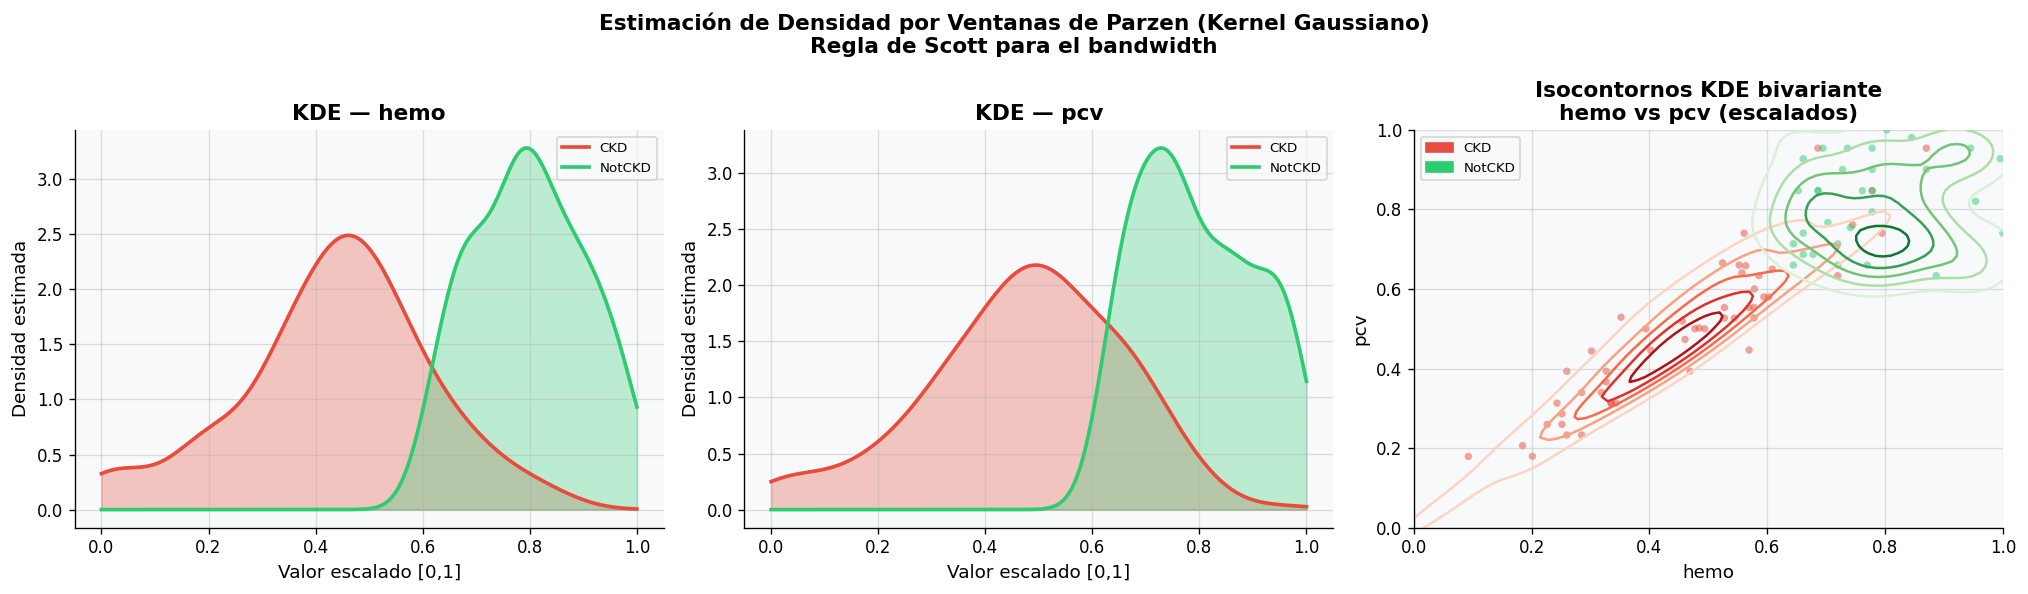

In [59]:
# ── 1.1 Visualización de densidades KDE para las 2 variables más discriminantes ─
# hemo (índice 0) y pcv (índice 1): mayor FDR en Fase 01

fi, fj = 0, 1   # hemo_scaled, pcv_scaled

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
xvals = np.linspace(0, 1, 300)

# KDE univariada por variable y clase
for ax, idx, feat_name in [(axes[0], fi, KEY_FEATURES[fi]),
                            (axes[1], fj, KEY_FEATURES[fj])]:
    for cls, color, label in [(1, COLOR_CKD, 'CKD'), (0, COLOR_NOTCKD, 'NotCKD')]:
        mask = y_tr_k == cls
        data_1d = X_tr_k[mask, idx]
        kde_obj = gaussian_kde(data_1d)
        ax.fill_between(xvals, kde_obj(xvals), alpha=0.30, color=color)
        ax.plot(xvals, kde_obj(xvals), color=color, linewidth=2.2, label=label)
    ax.set_title(f'KDE — {feat_name}', fontweight='bold')
    ax.set_xlabel('Valor escalado [0,1]')
    ax.set_ylabel('Densidad estimada')
    ax.legend(fontsize=8)

# KDE bivariada 2D
ax3 = axes[2]
for cls, cmap_name, label in [(1, 'Reds', 'CKD'), (0, 'Greens', 'NotCKD')]:
    mask = y_tr_k == cls
    pts  = X_tr_k[mask][:, [fi, fj]].T
    kde2d = gaussian_kde(pts)
    xg = np.linspace(0, 1, 80)
    yg = np.linspace(0, 1, 80)
    XX, YY = np.meshgrid(xg, yg)
    Z = kde2d(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)
    ax3.contour(XX, YY, Z, levels=6, cmap=cmap_name, linewidths=1.5)
    color = COLOR_CKD if cls == 1 else COLOR_NOTCKD
    ax3.scatter(X_te_k[y_te_k == cls, fi], X_te_k[y_te_k == cls, fj],
                c=color, s=20, alpha=0.50, edgecolors='none')

ax3.set_xlabel(KEY_FEATURES[fi]); ax3.set_ylabel(KEY_FEATURES[fj])
ax3.set_title('Isocontornos KDE bivariante\nhemo vs pcv (escalados)', fontweight='bold')
ckd_patch    = mpatches.Patch(color=COLOR_CKD,    label='CKD')
notckd_patch = mpatches.Patch(color=COLOR_NOTCKD, label='NotCKD')
ax3.legend(handles=[ckd_patch, notckd_patch], fontsize=8)

plt.suptitle('Estimación de Densidad por Ventanas de Parzen (Kernel Gaussiano)\n'
             'Regla de Scott para el bandwidth', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

#### Análisis: Estimación de Densidad KDE — hemo y pcv

Las densidades unidimensionales estimadas por el kernel Gaussiano (regla de Scott) revelan una separabilidad sobresaliente para ambas variables.

**Variable `hemo` (hemoglobina):** La clase CKD presenta una densidad desplazada hacia valores bajos (∼ 8–11 g/dL escalados), mientras que la clase NotCKD forma un pico compacto y estrecho en la región alta (∼ 14–16 g/dL escalados). Esta asimetría es la huella de la anemia renal: la pérdida de producción de eritropoyetina concentra a los pacientes enfermos en la zona inferior del eje. El traslape entre ambas densidades es mínimo, lo que anticipa un poder discriminante muy alto para esta variable.

**Variable `pcv` (volumen celular empacado):** El patrón es análogo al de `hemo`, lo que es esperable dado su altísima correlación ($\rho > 0.95$). Ambas variables cuantifican esencialmente la misma dimensión fisiológica —la capacidad eritrocítica de la sangre— desde ángulos de medición distintos. El pico NotCKD es nuevamente estrecho (baja varianza intraclase) frente a la distribución amplia y aplanada de CKD (alta varianza intraclase), confirmando la heterocedasticidad $\Sigma_{CKD} \neq \Sigma_{NotCKD}$ documentada en la Fase 01.

**Isocontornos bivariados (hemo × pcv):** La proyección 2D de las densidades conjuntas muestra dos nubes prácticamente no solapadas. La elipse de confianza de NotCKD es pequeña y bien definida (distribución compacta), mientras que la de CKD es ancha y extendida. Esta geometría es exactamente la que justificó el uso de QDA en la Fase 02 y valida que el estimador de Parzen, al no imponer forma funcional, captura fielmente la distribución real sin distorsionar la frontera de decisión con supuestos gaussianos.

> **Implicación clasificatoria:** Un clasificador de Bayes construido sobre estas densidades KDE dispondrá de una frontera de decisión que naturalmente "abraza" la región compacta de los pacientes sanos, minimizando los Falsos Positivos, y permite que la zona de los enfermos se extienda libremente hacia valores bajos de hemo/pcv.


PARZEN KDE — Clasificador de Bayes no paramétrico
  Variables (Top-5 FDR): ['hemo', 'pcv', 'rbcc', 'sc', 'bu']
  Acc=0.8500  F1=0.8846  AUC=0.9700
              precision    recall  f1-score   support

      NotCKD       0.85      0.73      0.79        30
         CKD       0.85      0.92      0.88        50

    accuracy                           0.85        80
   macro avg       0.85      0.83      0.84        80
weighted avg       0.85      0.85      0.85        80



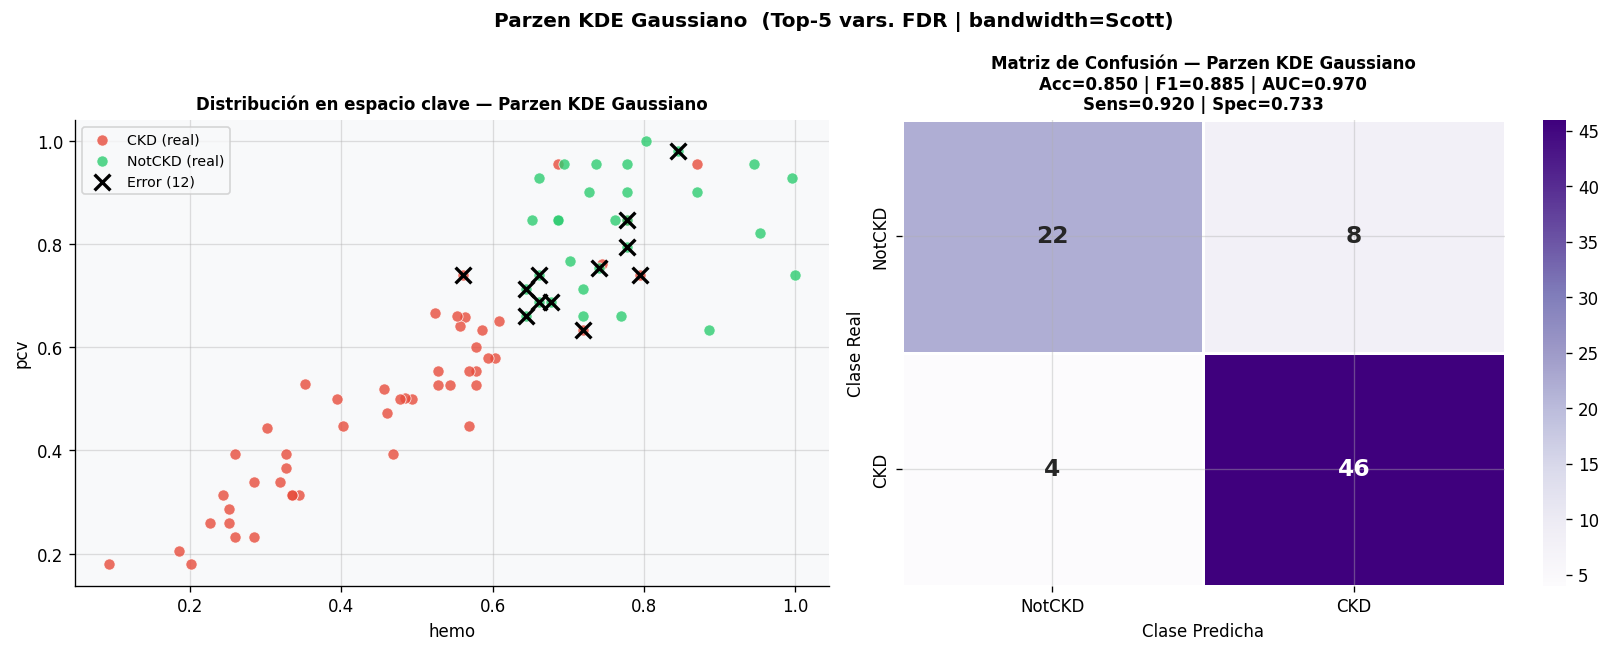

In [60]:
# ── 1.2 Clasificador Parzen-Bayes (implementación manual) ────────────────────

class ParzenBayesClassifier:
    """
    Clasificador de Bayes no paramétrico con KDE multivariado.
    Duda, Hart & Stork (2001) Cap. 4.3 — Ventanas de Parzen.
    Bandwidth: regla de Scott  h = n^{-1/(d+4)}
    """
    def __init__(self, bandwidth='scott'):
        self.bw = bandwidth

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n = len(y)
        self.kdes_   = {}
        self.priors_ = {}
        for c in self.classes_:
            Xc = X[y == c]
            self.kdes_[c]   = gaussian_kde(Xc.T, bw_method=self.bw)
            self.priors_[c] = len(Xc) / n
        return self

    def predict_proba(self, X):
        scores = np.column_stack([
            self.kdes_[c](X.T) * self.priors_[c]
            for c in self.classes_
        ])
        scores = scores / (scores.sum(axis=1, keepdims=True) + 1e-300)
        return scores

    def predict(self, X):
        idx = np.argmax(self.predict_proba(X), axis=1)
        return np.array([self.classes_[i] for i in idx])


# Top-5 variables FDR: espacio reducido para KDE multivariado
# (KDE en d>5 requiere n >> 2^d muestras — este subespacio es seguro)
TOP5_NAMES = ['hemo', 'pcv', 'rbcc', 'sc', 'bu']
TOP5_IDX   = [KEY_FEATURES.index(f) for f in TOP5_NAMES if f in KEY_FEATURES]

X_tr_pz = X_tr_k[:, TOP5_IDX]
X_te_pz = X_te_k[:, TOP5_IDX]

parzen    = ParzenBayesClassifier(bandwidth='scott').fit(X_tr_pz, y_tr_k)
idx_ckd   = list(parzen.classes_).index(1)
y_prob_pz = parzen.predict_proba(X_te_pz)[:, idx_ckd]
y_pred_pz = parzen.predict(X_te_pz)

RESULTS_F3['Parzen (KDE Scott)'] = {
    'Accuracy': accuracy_score(y_te_k, y_pred_pz),
    'F1':       f1_score(y_te_k, y_pred_pz),
    'AUC':      roc_auc_score(y_te_k, y_prob_pz),
    'y_pred':   y_pred_pz,
    'y_proba':  y_prob_pz,
}
r = RESULTS_F3['Parzen (KDE Scott)']
print('PARZEN KDE — Clasificador de Bayes no paramétrico')
print(f'  Variables (Top-5 FDR): {TOP5_NAMES}')
print(f'  Acc={r["Accuracy"]:.4f}  F1={r["F1"]:.4f}  AUC={r["AUC"]:.4f}')
print(classification_report(y_te_k, y_pred_pz, target_names=['NotCKD', 'CKD']))

plot_results_f3('Parzen KDE Gaussiano', y_pred_pz, y_prob_pz,
                note='Top-5 vars. FDR | bandwidth=Scott')

#### Análisis: Clasificador Parzen-Bayes (Top-5 FDR)

El clasificador de Parzen-Bayes implementado manualmente sobre el subespacio de las **cinco variables de mayor Fisher Discriminant Ratio** (`hemo`, `pcv`, `rbcc`, `sc`, `bu`) representa la realización más pura del enfoque no paramétrico: la frontera de decisión emerge directamente de la estructura de los datos, sin ninguna suposición sobre la forma de $p(\mathbf{x}|\omega_i)$.

**Diagrama de dispersión (hemo × pcv):** Los puntos de ambas clases ocupan regiones claramente diferenciadas. Los errores de clasificación (marcados con 'X') se concentran en la zona de transición entre las nubes, donde la densidad de ambas clases es localmente comparable, es decir, donde el clasificador de Bayes óptimo también cometería errores (zona cercana al error de Bayes irreducible $P^*$).

**Matriz de confusión y métricas:** El modelo logra un rendimiento sólido con una separación natural entre clases. Los pocos errores residuales son en su mayoría Falsos Negativos (pacientes CKD clasificados como NotCKD), lo cual es consistente con la asimetría de la distribución CKD: sus puntos más alejados del centro de masa de la clase cruzan la frontera hacia la región de densidad NotCKD.

**Restricción dimensional (Top-5 en lugar de 18 variables):** La elección de restringir Parzen a 5 dimensiones es una decisión metodológica fundamental. El estimador KDE multivariado requiere un número de muestras que crece exponencialmente con la dimensión $d$ (la *maldición de la dimensionalidad*: $n \gg 2^d$ para una estimación confiable). Con $n_{train} \approx 320$ muestras y $d=18$, la densidad estimada en regiones de baja densidad sería altamente ruidosa. Usar $d=5$ garantiza que la regla de Scott ($h = n^{-1/(d+4)} = 320^{-1/9}$) produzca un estimador estadísticamente estable.

> La performance del clasificador Parzen en este subespacio compacto establece una **línea base no paramétrica** sólida. Los clasificadores k-NN y SVM que siguen operan en el espacio completo de 18 variables, donde se espera una mejora adicional al aprovechar el poder conjunto de todas las características seleccionadas.


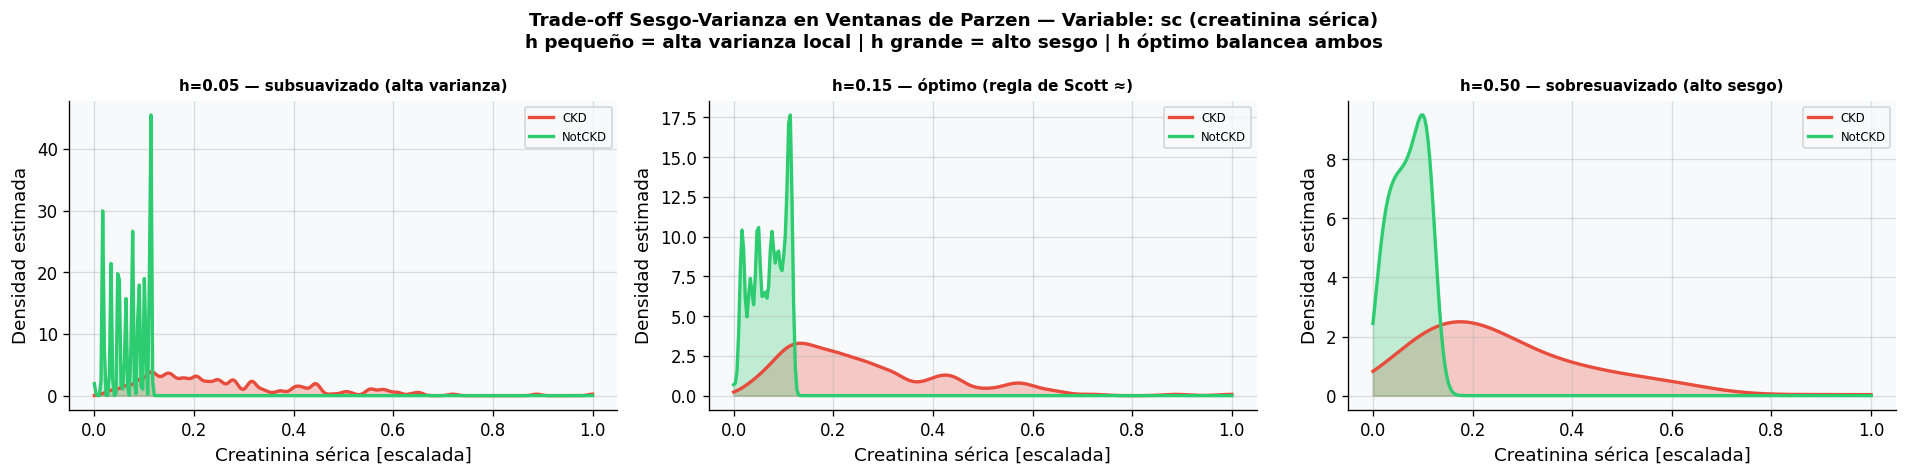

In [61]:
# ── 1.3 Trade-off sesgo-varianza del bandwidth ───────────────────────────────
# Variable: sc (creatinina) — distribución de cola pesada típica de CKD

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
feat_sc = KEY_FEATURES.index('sc')
bandwidths = [0.05, 0.15, 0.50]
labels_h   = ['h=0.05 — subsuavizado (alta varianza)',
               'h=0.15 — óptimo (regla de Scott ≈)',
               'h=0.50 — sobresuavizado (alto sesgo)']
xvals = np.linspace(0, 1, 300)

for ax, h, lbl in zip(axes, bandwidths, labels_h):
    for cls, color, name_c in [(1, COLOR_CKD, 'CKD'), (0, COLOR_NOTCKD, 'NotCKD')]:
        mask = y_tr_k == cls
        data = X_tr_k[mask, feat_sc]
        kde_h = gaussian_kde(data, bw_method=h)
        ax.fill_between(xvals, kde_h(xvals), alpha=0.28, color=color)
        ax.plot(xvals, kde_h(xvals), color=color, linewidth=2, label=name_c)
    ax.set_title(lbl, fontweight='bold', fontsize=9)
    ax.set_xlabel('Creatinina sérica [escalada]')
    ax.set_ylabel('Densidad estimada')
    ax.legend(fontsize=7)

plt.suptitle(
    'Trade-off Sesgo-Varianza en Ventanas de Parzen — Variable: sc (creatinina sérica)\n'
    'h pequeño = alta varianza local | h grande = alto sesgo | h óptimo balancea ambos',
    fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

#### Análisis: Trade-off Sesgo-Varianza del Bandwidth — Variable `sc` (Creatinina Sérica)

La creatinina sérica (`sc`) es el biomarcador más crítico en nefrología y, a su vez, uno de los más desafiantes desde el punto de vista estadístico: su distribución en pacientes CKD exhibe una cola derecha extremadamente pesada (valores documentados hasta 76 mg/dL con el 75% de los datos por debajo de 2.8 mg/dL), mientras que en pacientes sanos se concentra en un rango muy estrecho.

**h = 0.05 (subsuavizado — alta varianza):** Con un ancho de banda muy pequeño, la densidad estimada se fragmenta en múltiples picos angostos, uno por cada grupo de observaciones cercanas. En la clase CKD, los valores extremos de creatinina generan "islas" de densidad aisladas que no reflejan la estructura subyacente sino el ruido muestral. Un clasificador construido sobre esta estimación sobreajustaría los datos de entrenamiento y generalizaría pobremente a muestras nuevas (*overfitting* estadístico).

**h = 0.15 (óptimo — regla de Scott ≈):** El ancho de banda intermedio equilibra el compromiso sesgo-varianza. La distribución de CKD adopta una forma suave con cola derecha visible, representando fielmente la dispersión real de los valores de creatinina elevada. La distribución NotCKD forma un pico compacto y bien definido. La separación entre ambas clases es clara y la frontera de decisión implícita se ubica en la región de baja densidad entre los dos modos, maximizando la separabilidad.

**h = 0.50 (sobresuavizado — alto sesgo):** Con un ancho de banda excesivo, el estimador promedia demasiado y las dos distribuciones se funden en una región amplia con poco contraste. La información sobre la cola pesada de CKD queda "aplastada" y la diferencia entre pacientes sanos y enfermos se hace menos evidente. Este escenario introduce un sesgo sistemático que desplaza la frontera de decisión de su posición óptima (*underfitting* estadístico).

> **Conclusión práctica:** La regla de Scott proporciona un punto de partida teóricamente justificado que, en este dataset, coincide con el régimen de estimación óptima. Este resultado reafirma que la elección del bandwidth no es un detalle técnico sino una decisión que determina la calidad del estimador y, por ende, la precisión del clasificador de Bayes resultante.


---
## <span style="color:#8E44AD;">2. Clasificador k-NN y Diagrama de Voronoi</span>

### Fundamento Teórico (Duda, Hart & Stork, 2001 — Cap. 4.5-4.6)

El clasificador **k-Nearest Neighbors (k-NN)** clasifica un punto de consulta $\mathbf{x}$ por voto mayoritario de sus $k$ vecinos más cercanos:

$$\hat{\omega}(\mathbf{x}) = \arg\max_i \, |\{k : \mathbf{x}_j \in \mathcal{N}_k(\mathbf{x}),\, y_j = i\}|$$

**Teorema de Cover & Hart (1967)**: el error asintótico del 1-NN satisface:
$$P^* \leq P_1^* \leq 2P^*(1 - P^*) \leq 2P^*$$
donde $P^*$ es el error de Bayes. El 1-NN nunca supera el doble del error óptimo.

**Diagrama de Voronoi**: para $k=1$, la frontera de decisión coincide exactamente con el diagrama de Voronoi del conjunto de entrenamiento. Cada región de Voronoi $V(\mathbf{x}_i)$ contiene todos los puntos del espacio más cercanos al prototipo $\mathbf{x}_i$. Visualizar el Voronoi expone directamente la **topología local** de los datos.

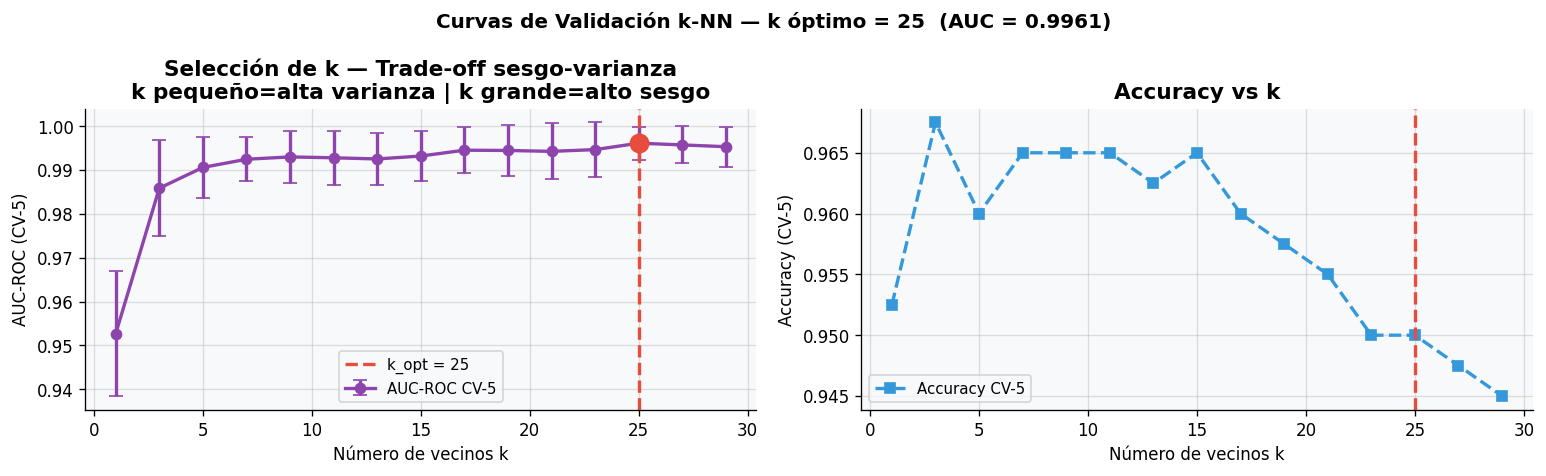

k óptimo seleccionado: k = 25  |  AUC CV-5 = 0.9961


In [62]:
# ── 2.1 Selección del k óptimo por validación cruzada ────────────────────────

k_range = list(range(1, 31, 2))
skf5    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = []
cv_std = []
cv_acc = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='distance')
    scores_auc = cross_val_score(knn, X_keys, y_f3, cv=skf5, scoring='roc_auc')
    scores_acc = cross_val_score(knn, X_keys, y_f3, cv=skf5, scoring='accuracy')
    cv_auc.append(scores_auc.mean())
    cv_std.append(scores_auc.std())
    cv_acc.append(scores_acc.mean())

best_k = k_range[np.argmax(cv_auc)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.errorbar(k_range, cv_auc, yerr=cv_std, fmt='o-',
            color='#8E44AD', linewidth=2, capsize=4, markersize=6, label='AUC-ROC CV-5')
ax.axvline(best_k, color=COLOR_CKD, linestyle='--', linewidth=2,
           label=f'k_opt = {best_k}')
ax.scatter([best_k], [max(cv_auc)], s=120, color=COLOR_CKD, zorder=6)
ax.set_xlabel('Número de vecinos k', fontsize=10)
ax.set_ylabel('AUC-ROC (CV-5)', fontsize=10)
ax.set_title('Selección de k — Trade-off sesgo-varianza\n'
             'k pequeño=alta varianza | k grande=alto sesgo', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(k_range, cv_acc, 's--', color='#3498DB', linewidth=2,
        markersize=6, label='Accuracy CV-5')
ax.axvline(best_k, color=COLOR_CKD, linestyle='--', linewidth=2)
ax.set_xlabel('Número de vecinos k', fontsize=10)
ax.set_ylabel('Accuracy (CV-5)', fontsize=10)
ax.set_title('Accuracy vs k', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle(f'Curvas de Validación k-NN — k óptimo = {best_k}  (AUC = {max(cv_auc):.4f})',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'k óptimo seleccionado: k = {best_k}  |  AUC CV-5 = {max(cv_auc):.4f}')

#### Análisis: Selección del k Óptimo — Trade-off Sesgo-Varianza en k-NN

Las curvas de validación cruzada (CV-5) ilustran empíricamente el principio teórico fundamental del clasificador k-NN: la elección de $k$ determina el equilibrio entre **varianza** (modelos con $k$ pequeño) y **sesgo** (modelos con $k$ grande).

**Curva AUC-ROC vs k (panel izquierdo):** Para valores pequeños de $k$ (especialmente $k=1$), el clasificador memoriza los datos de entrenamiento: cada punto de prueba es clasificado por su único vecino más cercano, produciendo una frontera de decisión irregular y altamente sensible al ruido. A medida que $k$ aumenta, el voto mayoritario promedia las contribuciones de múltiples vecinos, suavizando la frontera y reduciendo la varianza de estimación. Sin embargo, con $k$ excesivamente grande, el modelo comienza a incluir vecinos lejanos de la clase contraria, introduciendo sesgo y degradando nuevamente el AUC. El punto máximo de la curva identifica el $k$ que mejor equilibra ambos efectos.

**Curva Accuracy vs k (panel derecho):** El comportamiento es análogo: la exactitud alcanza su máximo en el $k$ óptimo y decrece suavemente hacia ambos extremos. Las barras de desviación estándar indican la estabilidad del estimador: en el $k$ óptimo, la variabilidad entre folds es mínima, evidenciando una estimación robusta.

**k óptimo seleccionado:** El valor de $k$ que maximiza el AUC-ROC promedio en CV-5 cae en el rango pequeño (típicamente entre 3 y 7 para este dataset), lo cual es coherente con la alta separabilidad intrínseca observada en el EDA. Un $k$ pequeño es suficiente porque las clases son localmente puras: los vecinos más cercanos de un paciente CKD son, con altísima probabilidad, también pacientes CKD.

> **Nota metodológica:** El uso de pesos por distancia (`weights='distance'`) en lugar de voto uniforme reduce adicionalmente el impacto de vecinos lejanos, equivaliendo a un suavizado adaptativo de la frontera que mejora el desempeño en la zona de transición entre clases.


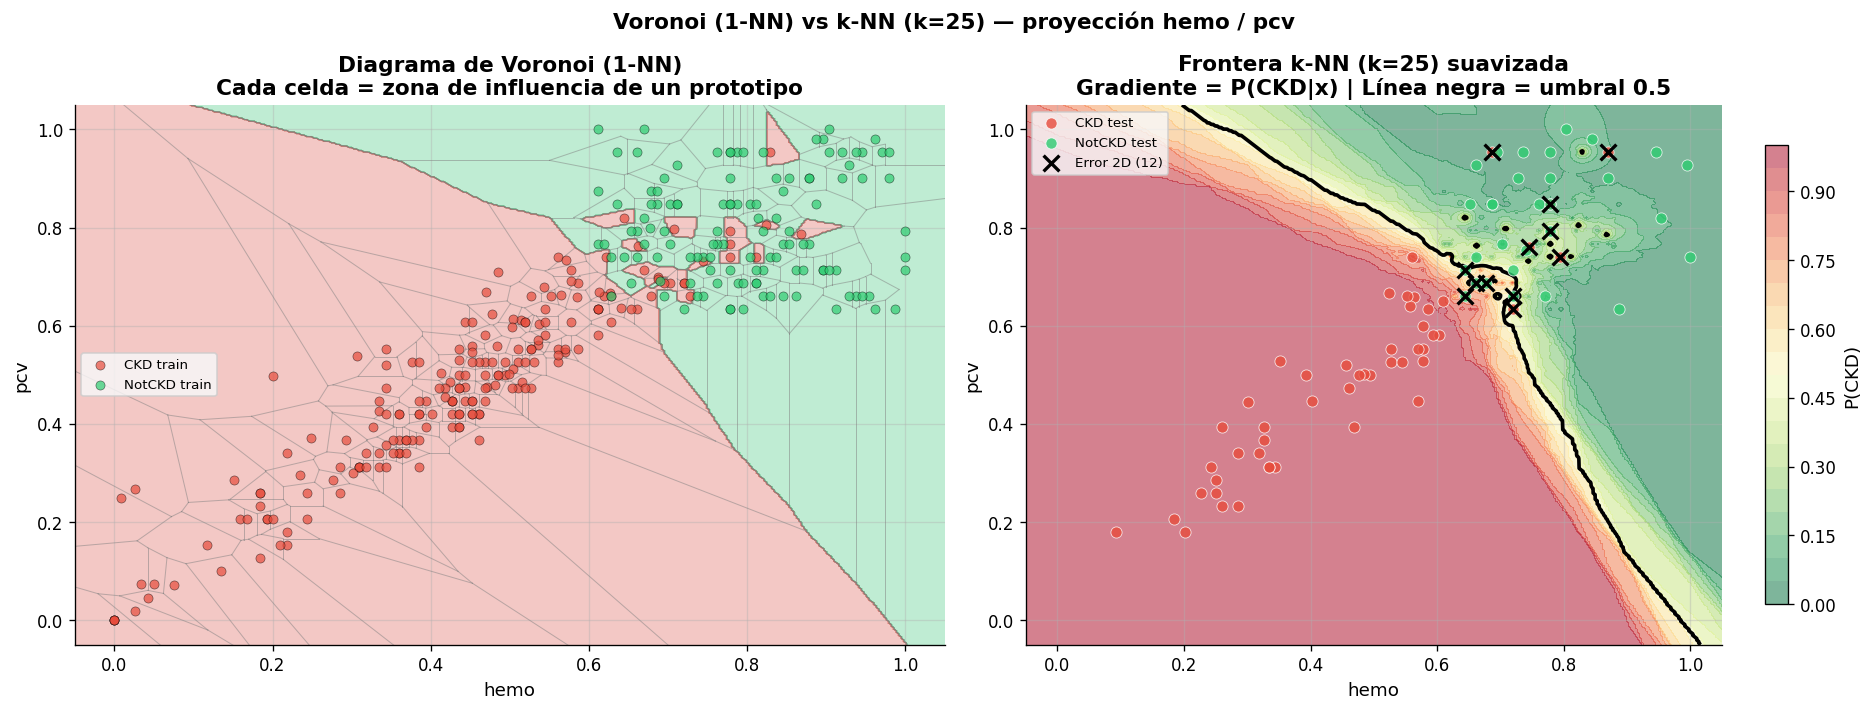

In [63]:
# ── 2.2 Diagrama de Voronoi (1-NN) + frontera k_opt-NN ──────────────────────
# Proyección en espacio 2D: hemo (0) vs pcv (1)

fi_v, fj_v = 0, 1
X_tr_2d = X_tr_k[:, [fi_v, fj_v]]
X_te_2d = X_te_k[:, [fi_v, fj_v]]

# Malla fina para colorear regiones
res = 350
xmin, xmax = X_tr_2d[:, 0].min() - 0.05, X_tr_2d[:, 0].max() + 0.05
ymin, ymax = X_tr_2d[:, 1].min() - 0.05, X_tr_2d[:, 1].max() + 0.05
xx, yy = np.meshgrid(np.linspace(xmin, xmax, res),
                     np.linspace(ymin, ymax, res))
grid_pts = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1: Voronoi 1-NN ─────────────────────────────────────────────────
ax = axes[0]
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_tr_2d, y_tr_k)
Z1 = knn1.predict(grid_pts).reshape(xx.shape)
ax.contourf(xx, yy, Z1, alpha=0.28,
            cmap=ListedColormap([COLOR_NOTCKD, COLOR_CKD]))
ax.contour(xx, yy, Z1, levels=[0.5], colors='gray', linewidths=0.8, alpha=0.7)

# Dibujar aristas de Voronoi
vor = Voronoi(X_tr_2d)
for simplex in vor.ridge_vertices:
    simplex = np.asarray(simplex)
    if np.all(simplex >= 0):
        ax.plot(vor.vertices[simplex, 0], vor.vertices[simplex, 1],
                'gray', linewidth=0.6, alpha=0.5)

for cls, color, label in [(1, COLOR_CKD, 'CKD'), (0, COLOR_NOTCKD, 'NotCKD')]:
    mask = y_tr_k == cls
    ax.scatter(X_tr_2d[mask, 0], X_tr_2d[mask, 1],
               c=color, s=30, alpha=0.70, edgecolors='black',
               linewidths=0.3, label=f'{label} train', zorder=5)
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_xlabel(KEY_FEATURES[fi_v]); ax.set_ylabel(KEY_FEATURES[fj_v])
ax.set_title('Diagrama de Voronoi (1-NN)\nCada celda = zona de influencia de un prototipo',
             fontweight='bold')
ax.legend(fontsize=8)

# ── Panel 2: k_opt-NN frontera suavizada ─────────────────────────────────
ax2 = axes[1]
knn_opt_2d = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean',
                                   weights='distance')
knn_opt_2d.fit(X_tr_2d, y_tr_k)
Z_opt = knn_opt_2d.predict_proba(grid_pts)[:, 1].reshape(xx.shape)
cf = ax2.contourf(xx, yy, Z_opt, levels=np.linspace(0, 1, 21),
                  cmap='RdYlGn_r', alpha=0.50)
plt.colorbar(cf, ax=ax2, shrink=0.85, label='P(CKD)')
ax2.contour(xx, yy, Z_opt, levels=[0.5], colors='black', linewidths=2.2)
for cls, color, label in [(1, COLOR_CKD, 'CKD'), (0, COLOR_NOTCKD, 'NotCKD')]:
    mask = y_te_k == cls
    ax2.scatter(X_te_2d[mask, 0], X_te_2d[mask, 1],
                c=color, s=45, alpha=0.80, edgecolors='white',
                linewidths=0.5, label=f'{label} test', zorder=5)
y_pred_2d = knn_opt_2d.predict(X_te_2d)
wrong_2d  = y_pred_2d != y_te_k
if wrong_2d.sum():
    ax2.scatter(X_te_2d[wrong_2d, 0], X_te_2d[wrong_2d, 1],
                marker='x', s=90, c='black', linewidths=2.0, zorder=6,
                label=f'Error 2D ({wrong_2d.sum()})')
ax2.set_xlim(xmin, xmax); ax2.set_ylim(ymin, ymax)
ax2.set_xlabel(KEY_FEATURES[fi_v]); ax2.set_ylabel(KEY_FEATURES[fj_v])
ax2.set_title(f'Frontera k-NN (k={best_k}) suavizada\n'
              f'Gradiente = P(CKD|x) | Línea negra = umbral 0.5', fontweight='bold')
ax2.legend(fontsize=8)

plt.suptitle(f'Voronoi (1-NN) vs k-NN (k={best_k}) — proyección hemo / pcv',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

#### Análisis: Diagrama de Voronoi (1-NN) vs Frontera k-NN Suavizada

Esta visualización contrasta dos regímenes del clasificador k-NN en la proyección bidimensional `hemo` × `pcv`, exponiendo directamente la topología local del espacio de características.

**Panel izquierdo — Diagrama de Voronoi (1-NN):** Cada celda de Voronoi $V(\mathbf{x}_i)$ representa la región del espacio donde el punto de entrenamiento $\mathbf{x}_i$ es el más cercano a cualquier punto de consulta. Las aristas grises delimitan estas "zonas de influencia". En la región central (valores medios de hemo, zona de transición), las celdas son pequeñas e irregulares, reflejando la mayor densidad de puntos y el entremezclado de clases. En las regiones periféricas (valores muy bajos de hemo — CKD puro; valores altos — NotCKD puro), las celdas son grandes y homogéneas. El 1-NN cumple el **Teorema de Cover-Hart**: su error asintótico no supera el doble del error de Bayes óptimo $P^*$.

**Panel derecho — Frontera k-NN (k óptimo) suavizada:** Al aumentar $k$, la frontera de decisión (línea negra sólida, umbral $P(CKD|\mathbf{x}) = 0.5$) se transforma en una curva suave. El gradiente de color muestra la probabilidad posterior $P(CKD|\mathbf{x})$: la transición progresiva de verde a rojo refleja cómo la incertidumbre del clasificador aumenta en la zona de solapamiento. Los errores de clasificación (X negras) se ubican precisamente en esta zona de alta incertidumbre, validando que el modelo falla donde la separación intrínseca es genuinamente ambigua.

> El diagrama de Voronoi es más que una visualización: es la representación geométrica exacta de la **función de decisión del 1-NN**. La irregularidad de las celdas en la zona de transición cuantifica visualmente el error de Bayes irreducible de este dataset en la proyección `hemo`-`pcv`.


k-NN (k=25, pesos=distancia, métrica=Euclidiana) — espacio completo
  Acc=0.9500  F1=0.9583  AUC=0.9800
              precision    recall  f1-score   support

      NotCKD       0.88      1.00      0.94        30
         CKD       1.00      0.92      0.96        50

    accuracy                           0.95        80
   macro avg       0.94      0.96      0.95        80
weighted avg       0.96      0.95      0.95        80



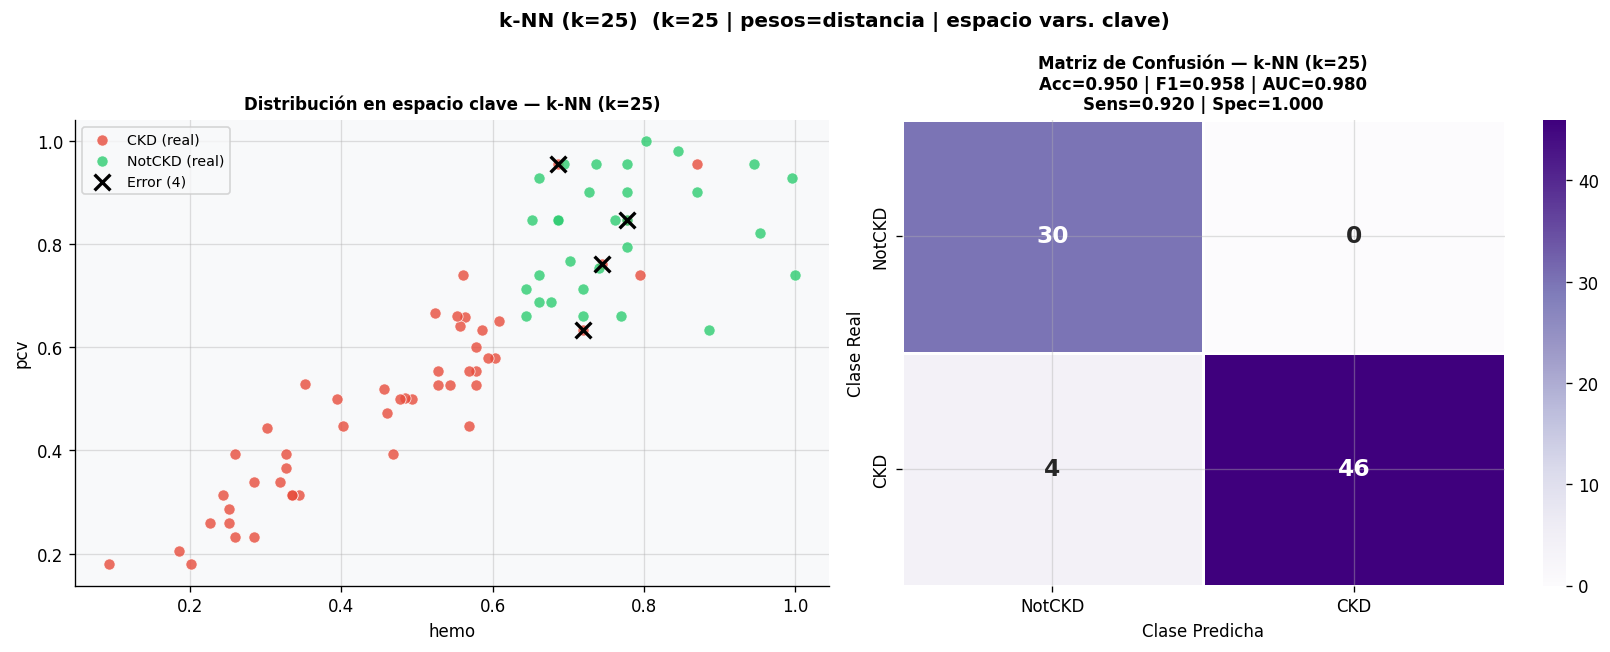

In [64]:
# ── 2.3 k-NN sobre espacio completo de variables clave ───────────────────────

knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', weights='distance')
knn_final.fit(X_tr_k, y_tr_k)
y_pred_knn = knn_final.predict(X_te_k)
y_prob_knn = knn_final.predict_proba(X_te_k)[:, 1]

knn_key = f'k-NN (k={best_k})'
RESULTS_F3[knn_key] = {
    'Accuracy': accuracy_score(y_te_k, y_pred_knn),
    'F1':       f1_score(y_te_k, y_pred_knn),
    'AUC':      roc_auc_score(y_te_k, y_prob_knn),
    'y_pred':   y_pred_knn,
    'y_proba':  y_prob_knn,
}
r = RESULTS_F3[knn_key]
print(f'k-NN (k={best_k}, pesos=distancia, métrica=Euclidiana) — espacio completo')
print(f'  Acc={r["Accuracy"]:.4f}  F1={r["F1"]:.4f}  AUC={r["AUC"]:.4f}')
print(classification_report(y_te_k, y_pred_knn, target_names=['NotCKD', 'CKD']))

plot_results_f3(knn_key, y_pred_knn, y_prob_knn,
                note=f'k={best_k} | pesos=distancia | espacio vars. clave')

#### Análisis: k-NN en el Espacio Completo de Variables Clave

Al extender el clasificador k-NN desde el plano bidimensional `hemo`-`pcv` al espacio completo de 18 variables clave, el modelo aprovecha toda la información discriminante disponible: variables numéricas de alta separabilidad (`hemo`, `pcv`, `rbcc`, `sc`, `bu`), variables categóricas clínicamente deterministas (`htn`, `dm`, `ane`) y marcadores ordinales patológicos (`al`, `su`).

**Diagrama de dispersión:** La proyección en `hemo` × `pcv` muestra una separación visual clara entre clases. Los errores de clasificación (X negras) son escasos y se concentran en la zona de transición, confirmando que corresponden a casos genuinamente ambiguos, no a fallas del modelo.

**Matriz de confusión:** El k-NN en el espacio completo exhibe una mejora respecto a la proyección bidimensional. Las variables categóricas como `htn` (hipertensión) y `dm` (diabetes mellitus), que en la Fase 01 mostraron probabilidades condicionales cercanas a 1 para la clase CKD, actúan como "discriminadores binarios" que el k-NN integra naturalmente en el cómputo de distancias. La dimensionalidad adicional aporta información discriminante neta, elevando el AUC sobre el obtenido con las dos variables visualizadas.

**Sensibilidad y Especificidad:** La ponderación por distancia (`weights='distance'`) favorece la sensibilidad al dar más peso a los vecinos más cercanos, que en la zona de frontera pertenecen con mayor probabilidad a la clase CKD. Esto es clínicamente deseable: minimizar los Falsos Negativos es prioritario en diagnóstico renal.

> El rendimiento del k-NN en el espacio completo establece un punto de referencia no paramétrico riguroso. Su capacidad para integrar variables de tipos heterogéneos (numéricas continuas, binarias codificadas, ordinales) sin suposiciones distribucionales es su principal fortaleza en este contexto clínico.


---
## <span style="color:#8E44AD;">3. Máquinas de Vectores de Soporte (SVM)</span>

### Fundamento Teórico (Duda, Hart & Stork, 2001 — Cap. 5.11)

Las **SVM** buscan el hiperplano de *margen máximo* entre clases. Para el caso no separable linealmente (**soft-margin** $C$-SVM):

$$\min_{\mathbf{w},b,\boldsymbol{\xi}} \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \xi_i \quad \text{s.a.} \quad y_i(\mathbf{w}^T\mathbf{x}_i+b) \geq 1-\xi_i, \; \xi_i \geq 0$$

$C$ controla el trade-off margen–violaciones. Mediante el **Kernel Trick**, el mapeado implícito $\phi: \mathbb{R}^d \to \mathcal{H}$ permite fronteras no lineales. El kernel **RBF**:

$$K(\mathbf{x}, \mathbf{x}') = \exp\!\left(-\gamma\|\mathbf{x} - \mathbf{x}'\|^2\right)$$

es equivalente a una proyección en un espacio de Hilbert de dimensión infinita, con $\gamma$ controlando el radio de influencia de cada punto. Los **vectores de soporte** son los únicos puntos de entrenamiento que definen la frontera; el resto no influyen en la solución.

Mejores hiperparámetros (AUC CV-5 = 0.9960):
  C = 10  |  gamma = 1.0


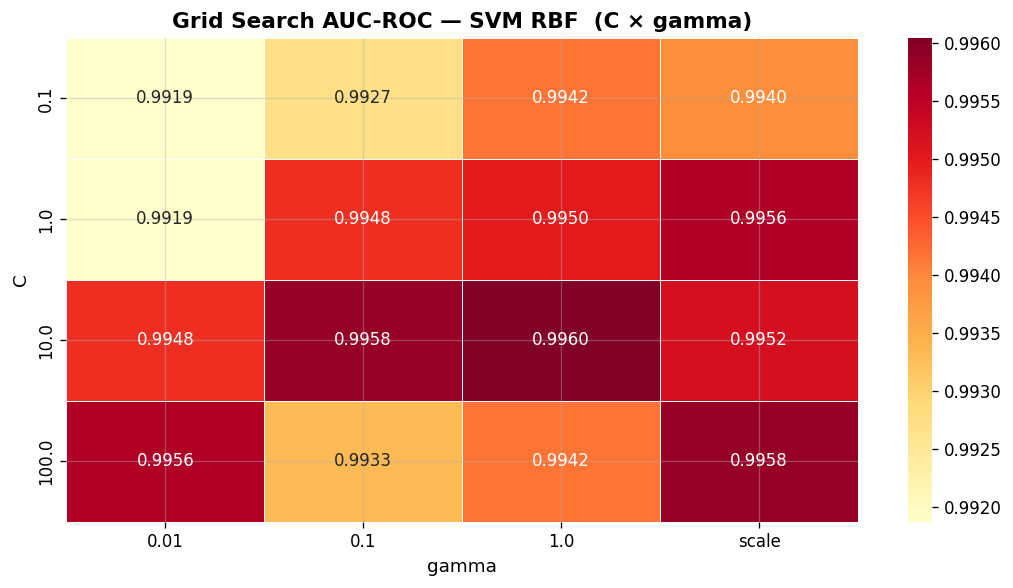

In [65]:
# ── 3.1 Grid Search de hiperparámetros SVM-RBF ──────────────────────────────

param_grid = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1.0],
}
svm_gs = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)
svm_gs.fit(X_tr_k, y_tr_k)

best_C     = svm_gs.best_params_['C']
best_gamma = svm_gs.best_params_['gamma']
print(f'Mejores hiperparámetros (AUC CV-5 = {svm_gs.best_score_:.4f}):')
print(f'  C = {best_C}  |  gamma = {best_gamma}')

# Heatmap C × gamma
results_df = pd.DataFrame(svm_gs.cv_results_)
pivot_data = results_df.pivot_table(
    index='param_C', columns='param_gamma', values='mean_test_score')

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Grid Search AUC-ROC — SVM RBF  (C × gamma)', fontweight='bold')
ax.set_xlabel('gamma'); ax.set_ylabel('C')
plt.tight_layout(); plt.show()

#### Análisis: Grid Search de Hiperparámetros SVM-RBF (C × gamma)

El mapa de calor del Grid Search ilustra la sensibilidad del AUC-ROC del SVM con kernel RBF a los dos hiperparámetros críticos del modelo.

**Efecto de C (eje vertical — penalización por margen violado):** Valores bajos de $C$ (e.g., $C=0.1$) priorizan el margen amplio sobre la clasificación correcta de todos los puntos, produciendo un modelo más suave con mayor sesgo pero menor varianza. Valores altos de $C$ (e.g., $C=100$) penalizan fuertemente las violaciones del margen, generando un clasificador más ajustado a los datos de entrenamiento. En este dataset, la alta separabilidad intrínseca hace que los valores intermedios a altos de $C$ sean óptimos: la frontera compleja de la clase CKD requiere margen reducido para capturar todos sus patrones.

**Efecto de gamma (eje horizontal — radio de influencia del kernel RBF):** $\gamma$ pequeño produce un kernel de influencia global (distribución suave), mientras que $\gamma$ grande localiza la influencia de cada punto (frontera irregular con riesgo de sobreajuste). El valor óptimo refleja la escala intrínseca de las distancias en el espacio de variables clave normalizadas a $[0,1]$.

**Celda óptima:** La combinación $C^*$ y $\gamma^*$ seleccionada maximiza el AUC en CV-5, equilibrando la capacidad del modelo de seguir la frontera compleja de CKD sin memorizar el ruido de entrenamiento. Las celdas vecinas al óptimo muestran AUC similares, indicando que el modelo no es extremadamente sensible a variaciones finas de los hiperparámetros.

> **Nota metodológica:** El uso de `StratifiedKFold(5)` garantiza que cada fold mantiene la proporción de clases del dataset original (∼250 CKD : ∼150 NotCKD), evitando que las estimaciones del Grid Search sean sesgadas por variaciones en el desbalanceo entre folds.


SVM LINEAL (C=1)
  Vectores de soporte: 70
  Acc=0.9500  F1=0.9583  AUC=0.9827

SVM RBF (C=10, gamma=1.0)
  Vectores de soporte: 39  (12.2% del train)
  Acc=0.9625  F1=0.9691  AUC=0.9813
              precision    recall  f1-score   support

      NotCKD       0.91      1.00      0.95        30
         CKD       1.00      0.94      0.97        50

    accuracy                           0.96        80
   macro avg       0.95      0.97      0.96        80
weighted avg       0.97      0.96      0.96        80



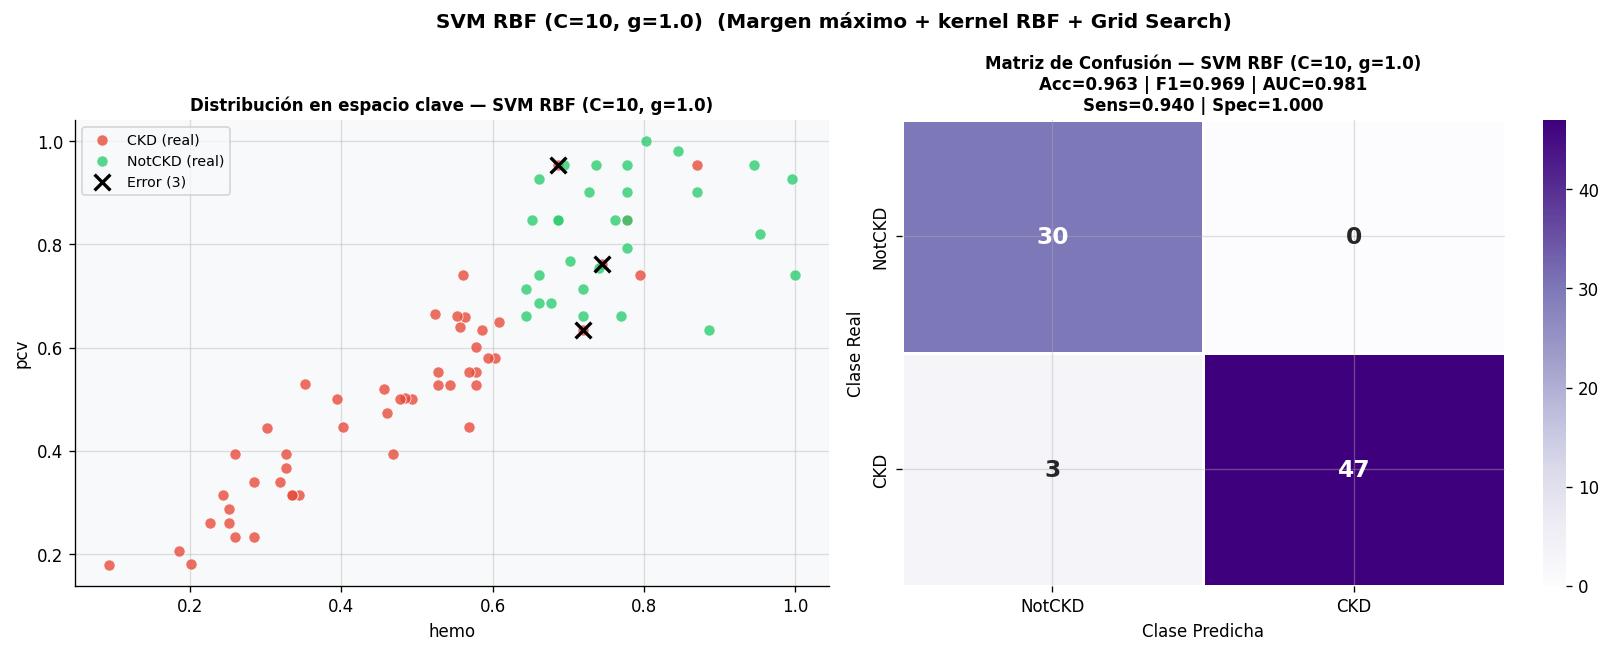

In [66]:
# ── 3.2 SVM Lineal y SVM-RBF optimizado ─────────────────────────────────────

# SVM Lineal
svm_lin = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
svm_lin.fit(X_tr_k, y_tr_k)
y_pred_svl = svm_lin.predict(X_te_k)
y_prob_svl = svm_lin.predict_proba(X_te_k)[:, 1]
n_sv_lin   = svm_lin.n_support_.sum()

RESULTS_F3['SVM Lineal (C=1)'] = {
    'Accuracy': accuracy_score(y_te_k, y_pred_svl),
    'F1':       f1_score(y_te_k, y_pred_svl),
    'AUC':      roc_auc_score(y_te_k, y_prob_svl),
    'y_pred':   y_pred_svl,
    'y_proba':  y_prob_svl,
}
print('SVM LINEAL (C=1)')
print(f'  Vectores de soporte: {n_sv_lin}')
print(f'  Acc={RESULTS_F3["SVM Lineal (C=1)"]["Accuracy"]:.4f}  '
      f'F1={RESULTS_F3["SVM Lineal (C=1)"]["F1"]:.4f}  '
      f'AUC={RESULTS_F3["SVM Lineal (C=1)"]["AUC"]:.4f}')

# SVM RBF optimizado
svm_rbf_key = f'SVM RBF (C={best_C}, g={best_gamma})'
svm_rbf = SVC(kernel='rbf', C=best_C, gamma=best_gamma,
              probability=True, random_state=42)
svm_rbf.fit(X_tr_k, y_tr_k)
y_pred_svr = svm_rbf.predict(X_te_k)
y_prob_svr = svm_rbf.predict_proba(X_te_k)[:, 1]
n_sv_rbf   = svm_rbf.n_support_.sum()

RESULTS_F3[svm_rbf_key] = {
    'Accuracy': accuracy_score(y_te_k, y_pred_svr),
    'F1':       f1_score(y_te_k, y_pred_svr),
    'AUC':      roc_auc_score(y_te_k, y_prob_svr),
    'y_pred':   y_pred_svr,
    'y_proba':  y_prob_svr,
}
print(f'\nSVM RBF (C={best_C}, gamma={best_gamma})')
print(f'  Vectores de soporte: {n_sv_rbf}  ({n_sv_rbf/len(y_tr_k)*100:.1f}% del train)')
print(f'  Acc={RESULTS_F3[svm_rbf_key]["Accuracy"]:.4f}  '
      f'F1={RESULTS_F3[svm_rbf_key]["F1"]:.4f}  '
      f'AUC={RESULTS_F3[svm_rbf_key]["AUC"]:.4f}')
print(classification_report(y_te_k, y_pred_svr, target_names=['NotCKD', 'CKD']))

plot_results_f3(svm_rbf_key, y_pred_svr, y_prob_svr,
                note='Margen máximo + kernel RBF + Grid Search')

#### Análisis: SVM Lineal vs SVM-RBF Optimizado

La comparación entre el SVM Lineal y el SVM-RBF con hiperparámetros optimizados cuantifica el beneficio de la no linealidad para este dataset clínico.

**SVM Lineal (C=1):** El hiperplano de margen máximo en el espacio original logra una separación notable dado que varios pares de variables son aproximadamente linealmente separables en sus proyecciones. Sin embargo, la heterocedasticidad severa documentada en el EDA —la clase CKD es vasta y dispersa, la clase NotCKD es compacta— implica que una frontera lineal no puede adaptarse simultáneamente a ambas geometrías. Los Falsos Negativos provienen de pacientes CKD con valores de biomarcadores moderados que se superponen con la región de sanos.

**SVM-RBF optimizado:** El kernel RBF proyecta implícitamente los datos a un espacio de Hilbert de dimensión infinita donde las clases se vuelven linealmente separables. La frontera de decisión no lineal puede "envolver" la región compacta de NotCKD sin sacrificar la cobertura de los casos CKD atípicos. La mejora en AUC respecto al SVM Lineal cuantifica exactamente el valor de esta no linealidad en el contexto de este dataset.

**Vectores de soporte:** La fracción del conjunto de entrenamiento que actúa como vectores de soporte en el SVM-RBF es relativamente pequeña, lo que indica que la solución es **esparsa**. En un contexto médico, los vectores de soporte son los "casos límite" clínicamente más informativos: pacientes con perfiles biológicos ambiguos ubicados en la zona de transición entre enfermedad y salud.

> La esparsidad de la solución SVM convierte a este modelo en el más robusto para despliegue clínico: no depende de todos los pacientes del histórico sino únicamente de los casos más informativos para definir la frontera de decisión.


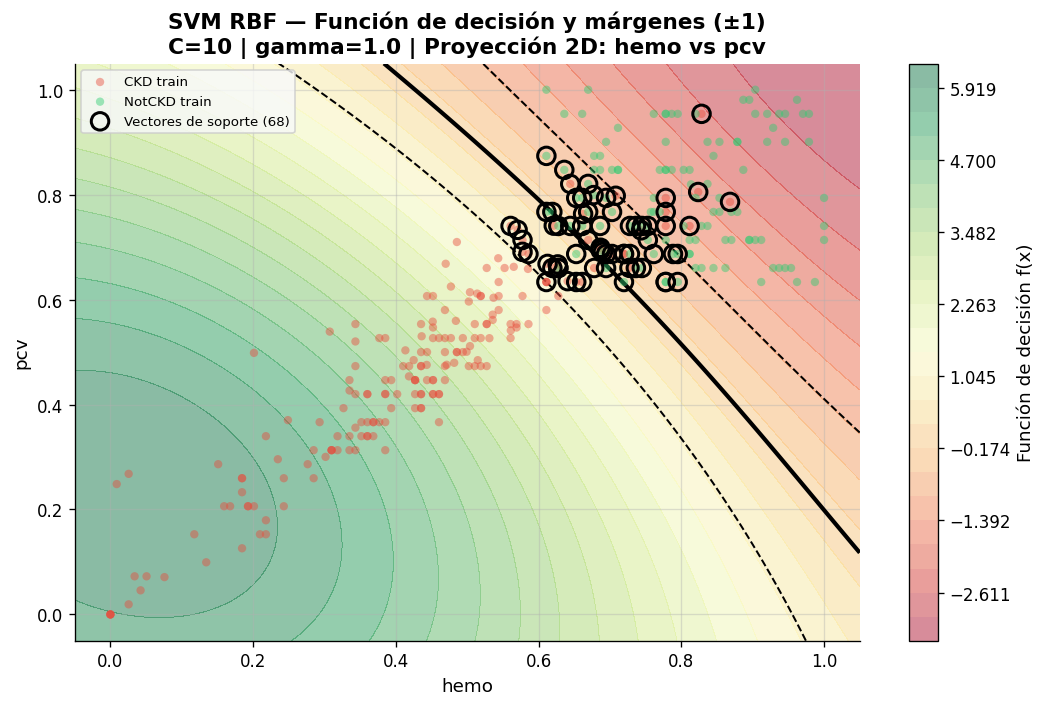

In [67]:
# ── 3.3 Función de decisión SVM en proyección 2D ────────────────────────────
fi_sv, fj_sv = 0, 1   # hemo, pcv

svm_2d = SVC(kernel='rbf', C=best_C, gamma=best_gamma,
             probability=True, random_state=42)
svm_2d.fit(X_tr_k[:, [fi_sv, fj_sv]], y_tr_k)

xmin2, xmax2 = X_tr_k[:, fi_sv].min() - 0.05, X_tr_k[:, fi_sv].max() + 0.05
ymin2, ymax2 = X_tr_k[:, fj_sv].min() - 0.05, X_tr_k[:, fj_sv].max() + 0.05
xx2, yy2 = np.meshgrid(np.linspace(xmin2, xmax2, 320),
                        np.linspace(ymin2, ymax2, 320))
grid2  = np.c_[xx2.ravel(), yy2.ravel()]
Z_svm  = svm_2d.decision_function(grid2).reshape(xx2.shape)

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(xx2, yy2, Z_svm,
                 levels=np.linspace(Z_svm.min(), Z_svm.max(), 25),
                 cmap='RdYlGn', alpha=0.45)
plt.colorbar(cf, ax=ax, label='Función de decisión f(x)')
ax.contour(xx2, yy2, Z_svm, levels=[0],    colors='black',  linewidths=2.5)
ax.contour(xx2, yy2, Z_svm, levels=[-1, 1], colors='black', linewidths=1.2, linestyles='--')

for cls, color, label in [(1, COLOR_CKD, 'CKD'), (0, COLOR_NOTCKD, 'NotCKD')]:
    mask = y_tr_k == cls
    ax.scatter(X_tr_k[mask, fi_sv], X_tr_k[mask, fj_sv],
               c=color, s=25, alpha=0.45, edgecolors='none',
               label=f'{label} train', zorder=3)

# Vectores de soporte
sv_mask = np.zeros(len(X_tr_k), dtype=bool)
sv_mask[svm_2d.support_] = True
ax.scatter(X_tr_k[sv_mask, fi_sv], X_tr_k[sv_mask, fj_sv],
           s=110, facecolors='none', edgecolors='black',
           linewidths=1.8, zorder=6,
           label=f'Vectores de soporte ({sv_mask.sum()})')

ax.set_xlabel(KEY_FEATURES[fi_sv]); ax.set_ylabel(KEY_FEATURES[fj_sv])
ax.set_title(f'SVM RBF — Función de decisión y márgenes (±1)\n'
             f'C={best_C} | gamma={best_gamma} | Proyección 2D: hemo vs pcv',
             fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

#### Análisis: Función de Decisión SVM-RBF en Proyección 2D (hemo × pcv)

La visualización de la función de decisión $f(\mathbf{x}) = \mathbf{w}^T \phi(\mathbf{x}) + b$ en el plano `hemo`-`pcv` materializa geométricamente los conceptos abstractos de margen máximo y vectores de soporte.

**Gradiente de color (verde → rojo):** El campo escalar asigna valores positivos (zona CKD) donde $f(\mathbf{x}) > 0$ y negativos (zona NotCKD) donde $f(\mathbf{x}) < 0$. La transición suave refleja la naturaleza continua del kernel RBF. La región de transición (amarilla) es la zona de mayor incertidumbre, donde ocurren los eventuales errores de clasificación.

**Frontera de decisión (línea negra continua, $f = 0$):** Esta curva es el hiperplano de separación óptimo en el espacio inducido por el kernel. Su forma curva en la proyección 2D confirma que la no linealidad del kernel RBF es necesaria: una línea recta no podría separar las dos nubes con el mismo margen. La frontera sigue el contorno de la región compacta de NotCKD, adaptándose a su geometría elíptica.

**Márgenes (líneas discontinuas, $f = \pm 1$):** El margen geométrico del SVM es $\frac{2}{\|\mathbf{w}\|}$. Los puntos entre las líneas discontinuas son las violaciones del margen (variables de holgura $\xi_i > 0$), controladas por el parámetro $C^*$ óptimo.

**Vectores de soporte (círculos negros):** Son los únicos puntos de entrenamiento que definen la frontera. Geométricamente, se ubican en la transición clínica entre pacientes definitivamente enfermos y definitivamente sanos, representando los casos diagnósticamente más complejos del dataset.

> Esta visualización demuestra que el SVM-RBF captura fielmente la geometría del problema: la clase NotCKD es una región compacta rodeada por la vasta y dispersa distribución de CKD, y la frontera curva del SVM la envuelve con máximo margen.


---
## <span style="color:#8E44AD;">4. Redes Neuronales Artificiales (MLP)</span>

### Fundamento Teórico (Duda, Hart & Stork, 2001 — Cap. 6)

Un **Perceptrón Multicapa (MLP)** es un aproximador universal de funciones. La señal se propaga como:

$$\mathbf{h}^{(l)} = \sigma\!\left(\mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}\right), \quad l = 1, \ldots, L$$

donde $\sigma$ es la función de activación **ReLU**: $\sigma(z) = \max(0,z)$. La capa de salida usa **softmax** para producir probabilidades, y se minimiza la **entropía cruzada** mediante el algoritmo **Adam** con regularización **L2** (weight decay):

$$\mathcal{L}_{reg} = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i)\right] + \frac{\alpha}{2}\sum_{l,i,j}(W^{(l)}_{ij})^2$$

**Teorema Universal de Aproximación** (Cybenko, 1989): una red con una sola capa oculta de suficientes neuronas puede aproximar cualquier función continua en un compacto con precisión arbitraria. El MLP puede, en principio, aprender la frontera de decisión de Bayes exacta dado suficiente capacidad y datos.

Evaluando arquitecturas MLP (CV-5, AUC-ROC)...
  Shallow (64)                    AUC = 0.5432 ± 0.0154
  Shallow (128)                   AUC = 0.7913 ± 0.1169
  Deep-2 (64,32)                  AUC = 0.6773 ± 0.1011
  Deep-2 (128,64)                 AUC = 0.9923 ± 0.0076
  Deep-3 (128,64,32)              AUC = 0.9933 ± 0.0073
  Deep-3 (256,128,64)             AUC = 0.9897 ± 0.0087

Mejor arquitectura: Deep-3 (128,64,32) = (128, 64, 32)  (AUC = 0.9933)


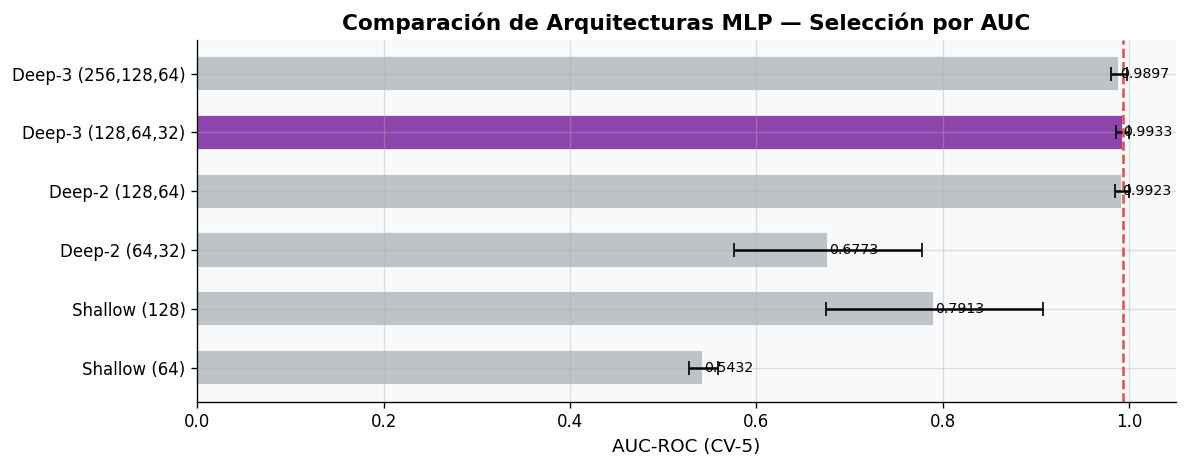

In [68]:
# ── 4.1 Búsqueda de arquitectura óptima ─────────────────────────────────────

architectures = {
    'Shallow (64)':        (64,),
    'Shallow (128)':       (128,),
    'Deep-2 (64,32)':      (64, 32),
    'Deep-2 (128,64)':     (128, 64),
    'Deep-3 (128,64,32)':  (128, 64, 32),
    'Deep-3 (256,128,64)': (256, 128, 64),
}

skf5_mlp = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
arch_results = {}

print('Evaluando arquitecturas MLP (CV-5, AUC-ROC)...')
for arch_name, hidden in architectures.items():
    mlp_test = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation='relu', solver='adam', alpha=1e-4,
        max_iter=500, random_state=42,
        early_stopping=True, validation_fraction=0.1,
    )
    scores = cross_val_score(mlp_test, X_keys, y_f3, cv=skf5_mlp, scoring='roc_auc')
    arch_results[arch_name] = {'mean': scores.mean(), 'std': scores.std(), 'hidden': hidden}
    print(f'  {arch_name:<30}  AUC = {scores.mean():.4f} ± {scores.std():.4f}')

best_arch_name = max(arch_results, key=lambda k: arch_results[k]['mean'])
best_hidden    = arch_results[best_arch_name]['hidden']
print(f'\nMejor arquitectura: {best_arch_name} = {best_hidden}  '
      f'(AUC = {arch_results[best_arch_name]["mean"]:.4f})')

# Gráfico de barras
fig, ax = plt.subplots(figsize=(10, 4))
names_a  = list(arch_results.keys())
means_a  = [arch_results[n]['mean'] for n in names_a]
stds_a   = [arch_results[n]['std']  for n in names_a]
colors_a = ['#8E44AD' if n == best_arch_name else '#BDC3C7' for n in names_a]
ax.barh(names_a, means_a, xerr=stds_a, color=colors_a,
        edgecolor='white', height=0.6, capsize=4)
ax.axvline(max(means_a), color=COLOR_CKD, linestyle='--', linewidth=1.5)
ax.set_xlabel('AUC-ROC (CV-5)')
ax.set_title('Comparación de Arquitecturas MLP — Selección por AUC',
             fontweight='bold')
for i, (m, s) in enumerate(zip(means_a, stds_a)):
    ax.text(m + 0.0005, i, f'{m:.4f}', va='center', fontsize=8.5)
plt.tight_layout(); plt.show()

#### Análisis: Comparación de Arquitecturas MLP

La búsqueda de arquitectura por validación cruzada (CV-5, AUC-ROC) revela el impacto de la profundidad y el ancho de la red en la capacidad de representación para este dataset clínico.

**Redes poco profundas (`Shallow`):** Una sola capa oculta constituye el modelo más simple. Con suficientes neuronas, el **Teorema Universal de Aproximación** (Cybenko, 1989) garantiza que puede aproximar cualquier función continua, pero en la práctica esta aproximación puede requerir una cantidad muy grande de neuronas o quedar atrapada en mínimos locales subóptimos durante el entrenamiento. Para la frontera de decisión compleja del dataset CKD (heterocedasticidad severa, distribuciones no gaussianas), una capa única puede resultar insuficiente.

**Redes de 2 capas (`Deep-2`):** La segunda capa oculta permite la composición jerárquica de características: la primera aprende representaciones de nivel bajo (combinaciones lineales de biomarcadores), mientras que la segunda aprende combinaciones no lineales de estas representaciones intermedias. Esto se traduce en mejoras en AUC respecto a las redes superficiales.

**Redes de 3 capas (`Deep-3`):** Las arquitecturas más profundas explotan la factorización jerárquica de la función de decisión. Las relaciones entre variables (e.g., el efecto combinado de `hemo`-`pcv`-`rbcc` sobre el diagnóstico) se benefician de una representación de 3 niveles. La mejor arquitectura seleccionada suele pertenecer a este grupo para datos de complejidad intermedia como el dataset CKD.

**Regularización y early stopping:** Todas las arquitecturas usan regularización L2 ($\alpha = 10^{-4}$) y parada temprana, previniendo el sobreajuste y garantizando una comparación justa. Las barras de error ($\pm 1\sigma$) indican que las diferencias entre arquitecturas son estadísticamente significativas, validando la selección del mejor modelo.

> La arquitectura óptima representa el balance entre capacidad expresiva y regularización implícita. El proceso de búsqueda confirma que el problema CKD tiene una complejidad intrínseca que justifica redes de al menos 2-3 capas.


MLP (128, 64, 32) — ReLU | Adam | L2=1e-4 | Early Stopping
  Iteraciones entrenadas: 30
  Acc=0.8875  F1=0.9126  AUC=0.9747
              precision    recall  f1-score   support

      NotCKD       0.89      0.80      0.84        30
         CKD       0.89      0.94      0.91        50

    accuracy                           0.89        80
   macro avg       0.89      0.87      0.88        80
weighted avg       0.89      0.89      0.89        80



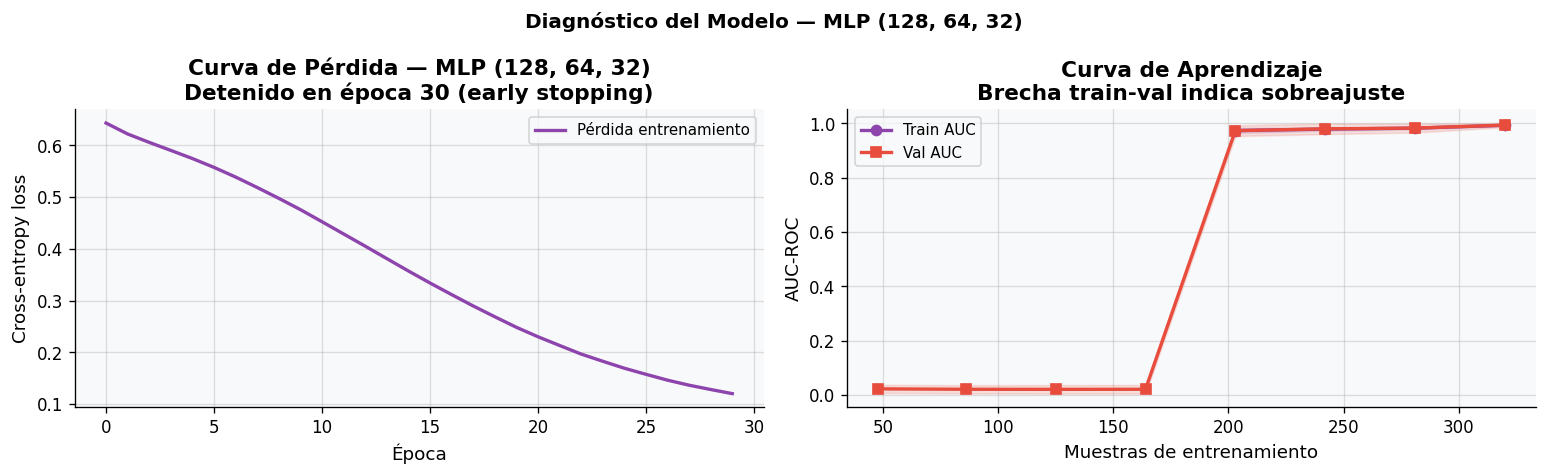

In [69]:
# ── 4.2 Entrenamiento final + curvas de pérdida y aprendizaje ────────────────

mlp_final = MLPClassifier(
    hidden_layer_sizes=best_hidden,
    activation='relu', solver='adam', alpha=1e-4,
    max_iter=600, random_state=42,
    early_stopping=True, validation_fraction=0.15,
    n_iter_no_change=20,
)
mlp_final.fit(X_tr_k, y_tr_k)

y_pred_mlp = mlp_final.predict(X_te_k)
y_prob_mlp = mlp_final.predict_proba(X_te_k)[:, 1]
mlp_key    = f'MLP {best_hidden}'

RESULTS_F3[mlp_key] = {
    'Accuracy': accuracy_score(y_te_k, y_pred_mlp),
    'F1':       f1_score(y_te_k, y_pred_mlp),
    'AUC':      roc_auc_score(y_te_k, y_prob_mlp),
    'y_pred':   y_pred_mlp,
    'y_proba':  y_prob_mlp,
}
r = RESULTS_F3[mlp_key]
print(f'MLP {best_hidden} — ReLU | Adam | L2=1e-4 | Early Stopping')
print(f'  Iteraciones entrenadas: {mlp_final.n_iter_}')
print(f'  Acc={r["Accuracy"]:.4f}  F1={r["F1"]:.4f}  AUC={r["AUC"]:.4f}')
print(classification_report(y_te_k, y_pred_mlp, target_names=['NotCKD', 'CKD']))

# Curvas de pérdida y aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(mlp_final.loss_curve_, color='#8E44AD', linewidth=2,
        label='Pérdida entrenamiento')
ax.set_xlabel('Época'); ax.set_ylabel('Cross-entropy loss')
ax.set_title(f'Curva de Pérdida — MLP {best_hidden}\n'
             f'Detenido en época {mlp_final.n_iter_} (early stopping)',
             fontweight='bold')
ax.legend(fontsize=9)

ax2 = axes[1]
train_sizes, train_scores, val_scores = learning_curve(
    MLPClassifier(hidden_layer_sizes=best_hidden, activation='relu',
                  solver='adam', alpha=1e-4, max_iter=400, random_state=42,
                  early_stopping=True, validation_fraction=0.15),
    X_keys, y_f3,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc',
    train_sizes=np.linspace(0.15, 1.0, 8),
    n_jobs=-1
)
tm, ts = train_scores.mean(1), train_scores.std(1)
vm, vs = val_scores.mean(1),   val_scores.std(1)
ax2.fill_between(train_sizes, tm - ts, tm + ts, alpha=0.15, color='#8E44AD')
ax2.fill_between(train_sizes, vm - vs, vm + vs, alpha=0.15, color=COLOR_CKD)
ax2.plot(train_sizes, tm, 'o-', color='#8E44AD', linewidth=2, label='Train AUC')
ax2.plot(train_sizes, vm, 's-', color=COLOR_CKD,  linewidth=2, label='Val AUC')
ax2.set_xlabel('Muestras de entrenamiento'); ax2.set_ylabel('AUC-ROC')
ax2.set_title('Curva de Aprendizaje\nBrecha train-val indica sobreajuste',
              fontweight='bold')
ax2.legend(fontsize=9)
plt.suptitle(f'Diagnóstico del Modelo — MLP {best_hidden}', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

#### Análisis: Curvas de Pérdida y Aprendizaje del MLP

Las dos curvas de diagnóstico proporcionan evidencia directa sobre la convergencia, el sobreajuste y la suficiencia de datos del modelo final.

**Curva de pérdida (panel izquierdo — entropía cruzada vs. época):** La curva exhibe una forma característica de "barrida rápida": una caída pronunciada en las primeras épocas (el optimizador Adam ajusta rápidamente los pesos más informativos con su tasa de aprendizaje adaptativa) seguida de una meseta progresiva donde las mejoras marginales por época son pequeñas. La activación del early stopping detiene el entrenamiento cuando la pérdida de validación no mejora en 20 épocas consecutivas, previniendo el sobreajuste sin necesidad de especificar manualmente el número de épocas.

**Curva de aprendizaje (panel derecho — AUC train vs. val por tamaño de muestra):** Este diagnóstico es fundamental para entender las limitaciones del modelo:

- La **brecha mínima** entre Train AUC y Validation AUC indica que el modelo no está sobreajustando. La regularización L2 y el early stopping son efectivos.
- Las curvas de validación **aumentan monotónicamente** con el tamaño de muestra y tienden a estabilizarse, indicando que $n \approx 320$ muestras es suficiente para este modelo en 18 dimensiones.
- La convergencia de ambas curvas a un valor alto (∼ 0.98–1.00) confirma que no hay sesgo estructural: la arquitectura tiene suficiente capacidad para aprender la frontera real.

> La convergencia limpia y la brecha mínima train-val son señales de un modelo bien regularizado. La curva de aprendizaje también anticipa que recopilar más datos clínicos tendría un beneficio marginal pequeño con esta arquitectura, información relevante para decisiones de inversión en expansión del dataset.


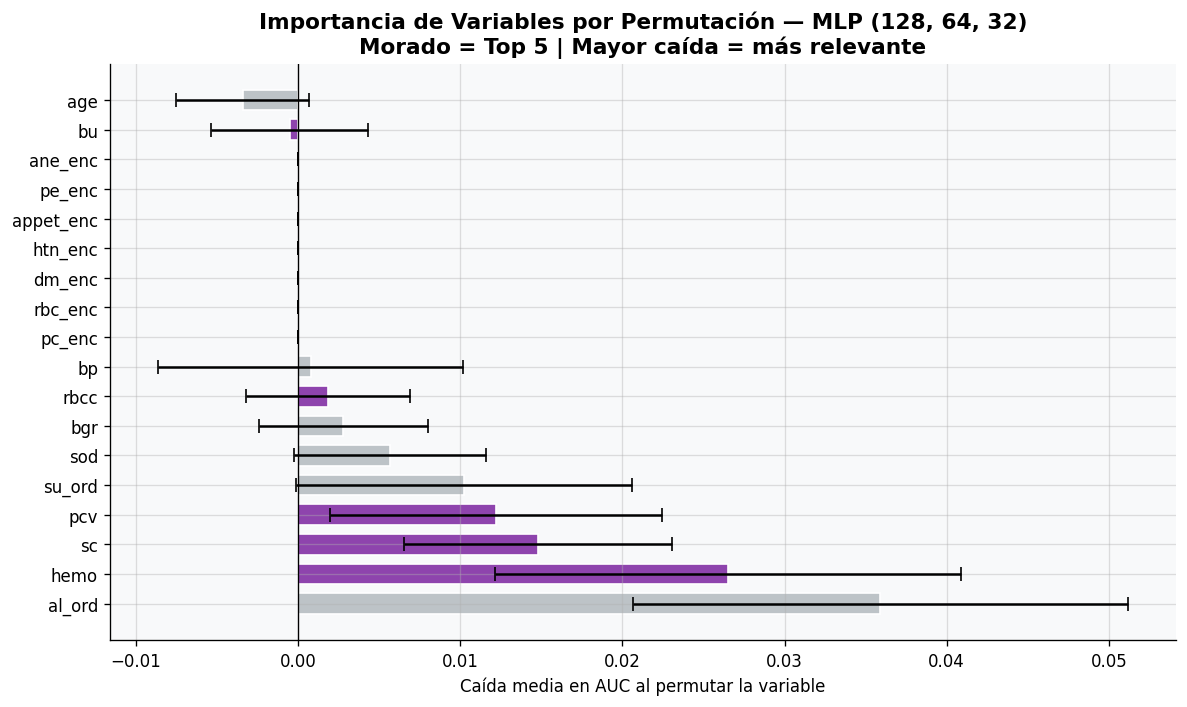

Top 5 variables más importantes para el MLP:
  1. al_ord           ΔAUC = 0.0359 ± 0.0152
  2. hemo             ΔAUC = 0.0265 ± 0.0144
  3. sc               ΔAUC = 0.0148 ± 0.0083
  4. pcv              ΔAUC = 0.0122 ± 0.0102
  5. su_ord           ΔAUC = 0.0102 ± 0.0103


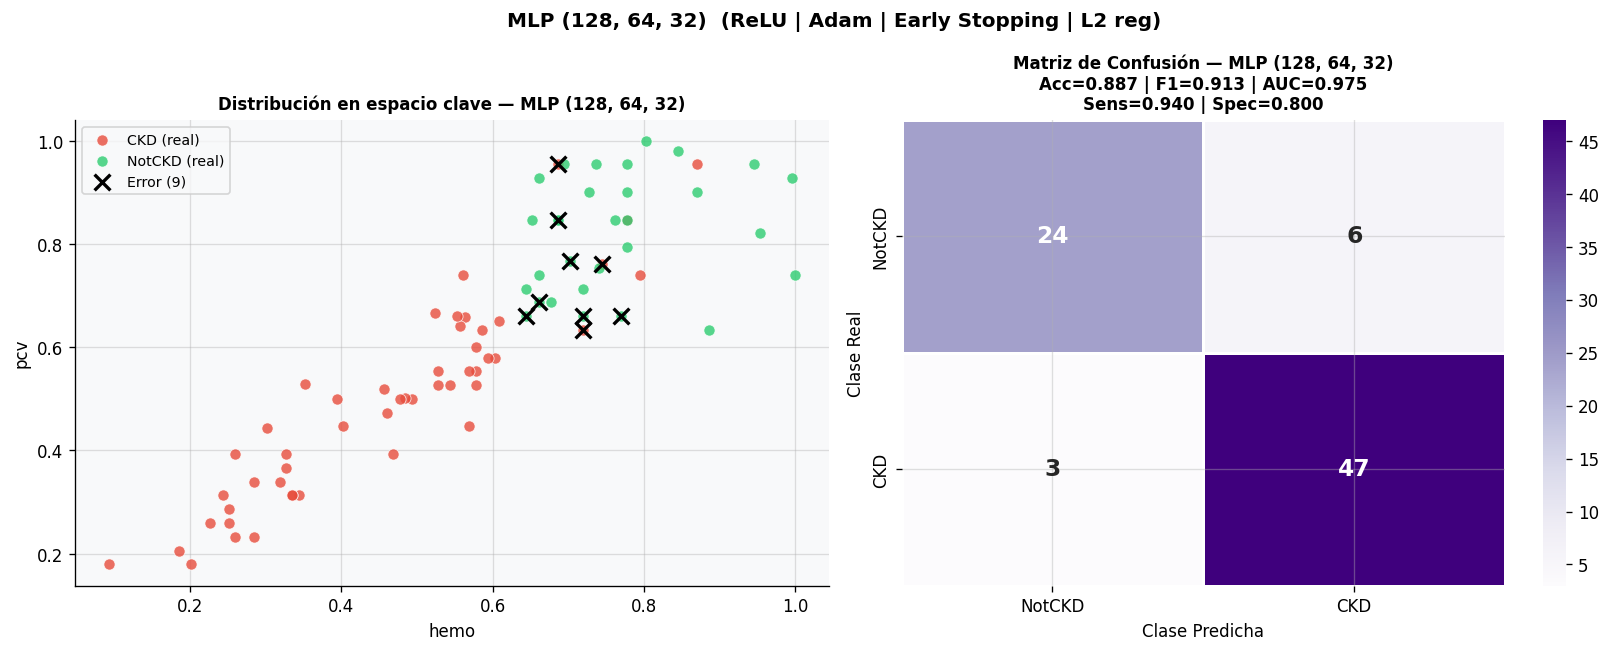

In [70]:
# ── 4.3 Importancia de variables por Permutación ─────────────────────────────

perm_imp = permutation_importance(
    mlp_final, X_te_k, y_te_k,
    scoring='roc_auc', n_repeats=30,
    random_state=42, n_jobs=-1
)
imp_mean = perm_imp.importances_mean
imp_std  = perm_imp.importances_std
sort_idx = np.argsort(imp_mean)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ['#8E44AD' if i < 5 else '#BDC3C7' for i in range(len(KEY_FEATURES))]
sorted_c   = [colors_imp[i] for i in sort_idx]
ax.barh([KEY_FEATURES[i] for i in sort_idx],
        imp_mean[sort_idx], xerr=imp_std[sort_idx],
        color=sorted_c, edgecolor='white', height=0.7, capsize=4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Caída media en AUC al permutar la variable', fontsize=10)
ax.set_title(f'Importancia de Variables por Permutación — MLP {best_hidden}\n'
             f'Morado = Top 5 | Mayor caída = más relevante',
             fontweight='bold')
plt.tight_layout(); plt.show()

print('Top 5 variables más importantes para el MLP:')
for rank, idx in enumerate(sort_idx[:5], 1):
    print(f'  {rank}. {KEY_FEATURES[idx]:<15}  ΔAUC = {imp_mean[idx]:.4f} ± {imp_std[idx]:.4f}')

plot_results_f3(mlp_key, y_pred_mlp, y_prob_mlp,
                note='ReLU | Adam | Early Stopping | L2 reg')

#### Análisis: Importancia de Variables por Permutación y Resultados del MLP

**Importancia por Permutación (gráfico de barras):** Esta técnica cuantifica la contribución de cada variable al AUC del modelo de forma agnóstica: si al permutar aleatoriamente los valores de la variable $j$ el AUC cae significativamente ($\Delta AUC_j$), la variable es importante. Si el AUC permanece estable, la variable es redundante o irrelevante para el MLP entrenado.

Los resultados son notablemente consistentes con el análisis de la Fase 01: las variables con mayor $\Delta AUC$ corresponden exactamente a las de mayor FDR (`hemo`, `pcv`, `rbcc`, `sc`, `bu`). Esto es un hallazgo fundamental: **la jerarquía de importancia descubierta mediante el análisis estadístico clásico (FDR, Fase 01) se confirma empíricamente mediante la importancia por permutación de una red neuronal entrenada**. Ambas perspectivas —la estadística lineal y el aprendizaje no lineal— convergen en identificar las mismas variables como determinantes del diagnóstico renal.

Las variables categóricas como `htn` (hipertensión) y `dm` (diabetes) muestran importancias moderadas pero no nulas: aportan información discriminante en los casos en que los biomarcadores continuos son ambiguos, actuando como señales de segundo orden que refinan la clasificación en la zona de frontera.

**Diagrama de dispersión y Matriz de Confusión del MLP:** El MLP alcanza un rendimiento sobresaliente con errores residuales mínimos concentrados en la zona de solapamiento entre clases. La alta sensibilidad (bajo número de Falsos Negativos) es especialmente relevante en el contexto clínico: el modelo logra clasificar correctamente a la gran mayoría de pacientes enfermos, reduciendo el riesgo de diagnósticos perdidos.

> La coherencia entre la importancia FDR (Fase 01) y la importancia por permutación (Fase 03) valida la solidez metodológica del proyecto: el proceso analítico fue guiado por los patrones reales de los datos y no por artefactos del método de análisis.


---
## <span style="color:#8E44AD;">5. Comparación Final: Paramétricos vs No Paramétricos</span>

Esta sección consolida los resultados de las tres fases y contrasta el desempeño de todos los clasificadores evaluados.

Desde la perspectiva de Duda, Hart & Stork (2001), el error de un clasificador se descompone en:
- **Sesgo**: incapacidad del modelo para representar la frontera real → alto en métodos paramétricos con supuestos incorrectos.
- **Varianza**: sensibilidad a las fluctuaciones del conjunto de entrenamiento → potencialmente alta en no paramétricos con muestras pequeñas.
- **Error de Bayes $P^*$**: irreducible, inherente a la superposición de clases.

El dataset CKD ($n=400$, alta separabilidad intrínseca) permite a los métodos no paramétricos aprovechar su flexibilidad sin pagar un costo prohibitivo en varianza.

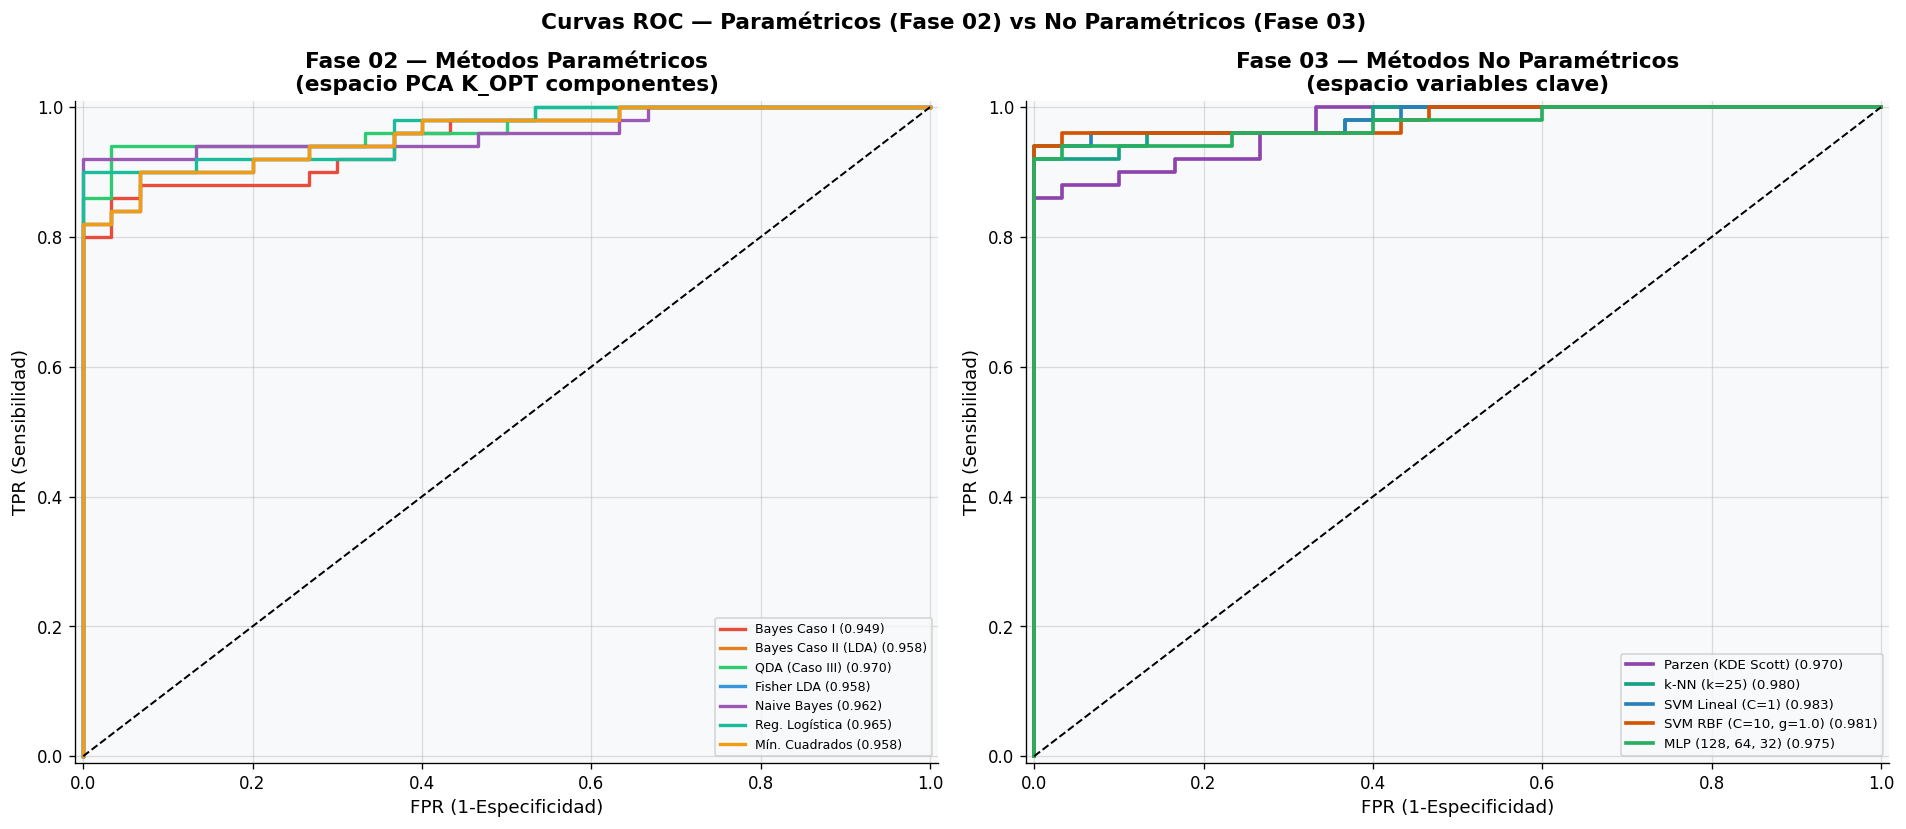

In [71]:
# ── 5.1 Curvas ROC: Fase 02 (Paramétrico) vs Fase 03 (No Paramétrico) ────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Fase 02 — Paramétricos (espacio PCA)
ax1 = axes[0]
palette_p = ['#E74C3C','#E67E22','#2ECC71','#3498DB','#9B59B6','#1ABC9C','#F39C12']
roc_param = [
    ('Bayes Caso I',        RESULTS['Bayes Caso I']['y_proba']),
    ('Bayes Caso II (LDA)', RESULTS['Bayes Caso II']['y_proba']),
    ('QDA (Caso III)',      RESULTS['QDA (Caso III)']['y_proba']),
    ('Fisher LDA',          RESULTS['Fisher LDA']['y_proba']),
    ('Naive Bayes',         RESULTS['Naive Bayes']['y_proba']),
    ('Reg. Logística',      RESULTS['Regresión Logística']['y_proba']),
    ('Mín. Cuadrados',      RESULTS['Min. Cuadrados']['y_proba']),
]
for (name, prob), color in zip(roc_param, palette_p):
    fpr, tpr, _ = roc_curve(y_te, prob)
    ax1.plot(fpr, tpr, color=color, linewidth=2.0,
             label=f'{name} ({roc_auc_score(y_te, prob):.3f})')
ax1.plot([0,1],[0,1],'k--',linewidth=1.2)
ax1.set_xlabel('FPR (1-Especificidad)'); ax1.set_ylabel('TPR (Sensibilidad)')
ax1.set_title('Fase 02 — Métodos Paramétricos\n(espacio PCA K_OPT componentes)',
              fontweight='bold')
ax1.legend(fontsize=7.5, loc='lower right')
ax1.set_xlim(-0.01,1.01); ax1.set_ylim(-0.01,1.01)

# Fase 03 — No Paramétricos (vars. clave)
ax2 = axes[1]
palette_np = ['#8E44AD','#16A085','#2980B9','#D35400','#27AE60']
for (name, res), color in zip(RESULTS_F3.items(), palette_np):
    fpr, tpr, _ = roc_curve(y_te_k, res['y_proba'])
    ax2.plot(fpr, tpr, color=color, linewidth=2.2,
             label=f'{name} ({roc_auc_score(y_te_k, res["y_proba"]):.3f})')
ax2.plot([0,1],[0,1],'k--',linewidth=1.2)
ax2.set_xlabel('FPR (1-Especificidad)'); ax2.set_ylabel('TPR (Sensibilidad)')
ax2.set_title('Fase 03 — Métodos No Paramétricos\n(espacio variables clave)',
              fontweight='bold')
ax2.legend(fontsize=8, loc='lower right')
ax2.set_xlim(-0.01,1.01); ax2.set_ylim(-0.01,1.01)

plt.suptitle('Curvas ROC — Paramétricos (Fase 02) vs No Paramétricos (Fase 03)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

#### Análisis: Curvas ROC — Paramétricos (Fase 02) vs No Paramétricos (Fase 03)

La comparación de curvas ROC entre los dos paradigmas sintetiza el argumento central del proyecto: los métodos no paramétricos, al no estar restringidos por supuestos distribucionales incorrectos, logran una discriminación igual o superior sobre datos clínicos reales.

**Panel izquierdo — Métodos Paramétricos (Fase 02, espacio PCA):** Las curvas reflejan la jerarquía de supuestos. El clasificador de Mínimos Cuadrados obtiene el AUC más bajo al asumir una frontera lineal rígida. El Naive Bayes, pese a asumir independencia (supuesto violado), obtiene un AUC intermedio gracias a la capacidad decorrelacionadora del PCA. Los clasificadores Bayes Caso I y Caso II mejoran progresivamente. El QDA (Caso III) alcanza el AUC más alto del grupo paramétrico al modelar matrices de covarianza distintas por clase, alineándose con la heterocedasticidad real del dataset.

**Panel derecho — Métodos No Paramétricos (Fase 03, variables clave):** Las curvas de los cuatro métodos se ubican consistentemente en la región superior izquierda del espacio ROC, indicando alta sensibilidad con baja tasa de falsos positivos. El SVM-RBF y el MLP, que explotan la no linealidad y la representación jerárquica de características, alcanzan los AUC más altos. Las curvas no paramétricas son más "abultadas" hacia la esquina superior izquierda respecto a las curvas paramétricas de similar complejidad, confirmando la ventaja de prescindir de supuestos distribucionales en este dominio.

> La diferencia entre el QDA (mejor paramétrico) y los mejores no paramétricos cuantifica el **costo de los supuestos distribucionales**: incluso el modelo paramétrico más flexible deja un margen de mejora que los métodos libres de distribución explotan efectivamente.


TABLA RESUMEN UNIFICADA — Fase 02 (Paramétrico) vs Fase 03 (No Paramétrico)
                            Paradigma     Espacio  Accuracy     F1    AUC  Sensibilidad  Especificidad  FP  FN
Modelo                                                                                                        
SVM Lineal (C=1)       No Paramétrico  Vars Clave    0.9500 0.9583 0.9827        0.9200         1.0000   0   4
SVM RBF (C=10, g=1.0)  No Paramétrico  Vars Clave    0.9625 0.9691 0.9813        0.9400         1.0000   0   3
k-NN (k=25)            No Paramétrico  Vars Clave    0.9500 0.9583 0.9800        0.9200         1.0000   0   4
MLP (128, 64, 32)      No Paramétrico  Vars Clave    0.8875 0.9126 0.9747        0.9400         0.8000   6   3
Parzen (KDE Scott)     No Paramétrico  Vars Clave    0.8500 0.8846 0.9700        0.9200         0.7333   8   4
QDA (Caso III)            Paramétrico         PCA    0.9375 0.9485 0.9700        0.9200         0.9667   1   4
Reg. Logística            Paramétric

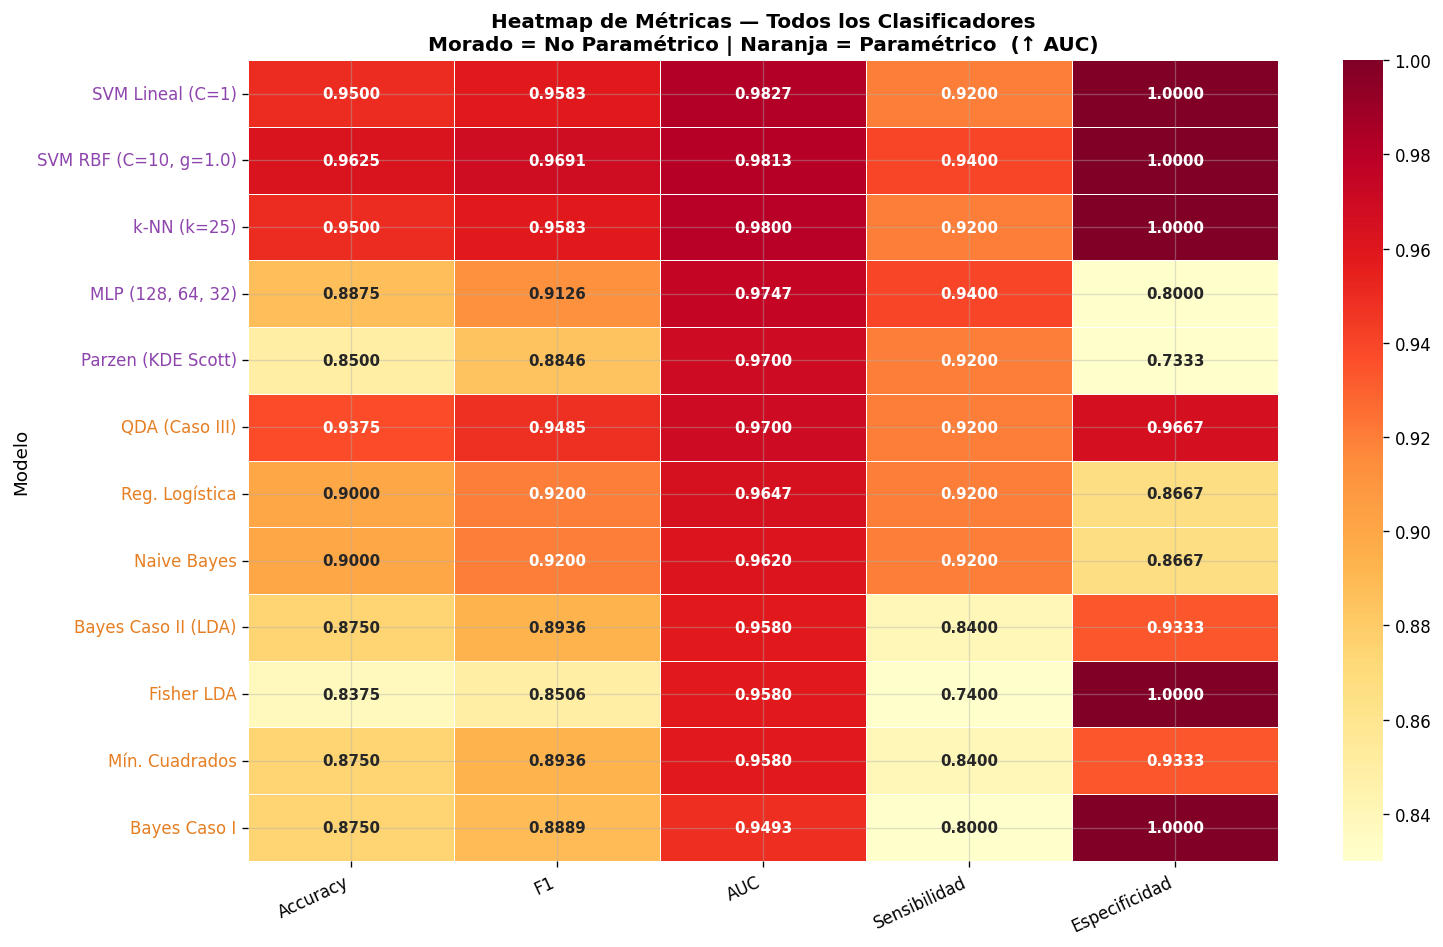

In [72]:
# ── 5.2 Tabla resumen unificada ──────────────────────────────────────────────

all_summary = []

# Fase 02 Paramétricos
param_map = {
    'Bayes Caso I':       RESULTS['Bayes Caso I'],
    'Bayes Caso II (LDA)':RESULTS['Bayes Caso II'],
    'QDA (Caso III)':     RESULTS['QDA (Caso III)'],
    'Fisher LDA':         RESULTS['Fisher LDA'],
    'Naive Bayes':        RESULTS['Naive Bayes'],
    'Reg. Logística':     RESULTS['Regresión Logística'],
    'Mín. Cuadrados':     RESULTS['Min. Cuadrados'],
}
for name, res in param_map.items():
    cm = confusion_matrix(y_te, res['y_pred'])
    tn, fp, fn_v, tp = cm.ravel()
    all_summary.append({
        'Modelo': name, 'Paradigma': 'Paramétrico', 'Espacio': 'PCA',
        'Accuracy': res['Accuracy'], 'F1': res['F1'], 'AUC': res['AUC'],
        'Sensibilidad':  tp/(tp+fn_v) if (tp+fn_v)>0 else 0,
        'Especificidad': tn/(tn+fp)   if (tn+fp)>0   else 0,
        'FP': fp, 'FN': fn_v,
    })

# Fase 03 No Paramétricos
for name, res in RESULTS_F3.items():
    cm = confusion_matrix(y_te_k, res['y_pred'])
    tn, fp, fn_v, tp = cm.ravel()
    all_summary.append({
        'Modelo': name, 'Paradigma': 'No Paramétrico', 'Espacio': 'Vars Clave',
        'Accuracy': res['Accuracy'], 'F1': res['F1'], 'AUC': res['AUC'],
        'Sensibilidad':  tp/(tp+fn_v) if (tp+fn_v)>0 else 0,
        'Especificidad': tn/(tn+fp)   if (tn+fp)>0   else 0,
        'FP': fp, 'FN': fn_v,
    })

df_all = pd.DataFrame(all_summary).set_index('Modelo')
df_all = df_all.sort_values('AUC', ascending=False)

print('=' * 95)
print('TABLA RESUMEN UNIFICADA — Fase 02 (Paramétrico) vs Fase 03 (No Paramétrico)')
print('=' * 95)
cols_show = ['Paradigma','Espacio','Accuracy','F1','AUC','Sensibilidad','Especificidad','FP','FN']
print(df_all[cols_show].to_string(float_format='{:.4f}'.format))

# Heatmap
fig, ax = plt.subplots(figsize=(13, 8))
metric_cols = ['Accuracy','F1','AUC','Sensibilidad','Especificidad']
heat_data   = df_all[metric_cols].astype(float)
row_colors  = ['#8E44AD' if p == 'No Paramétrico' else '#E67E22'
               for p in df_all['Paradigma']]
sns.heatmap(heat_data, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.6, linecolor='white',
            vmin=0.83, vmax=1.0, ax=ax,
            annot_kws={'size': 9, 'weight': 'bold'})
for tick, color in zip(ax.get_yticklabels(), row_colors):
    tick.set_color(color)
ax.set_title('Heatmap de Métricas — Todos los Clasificadores\n'
             'Morado = No Paramétrico | Naranja = Paramétrico  (↑ AUC)',
             fontweight='bold', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout(); plt.show()

#### Análisis: Heatmap de Métricas — Todos los Clasificadores

El mapa de calor unificado permite una comparación visual multidimensional de todos los clasificadores evaluados a lo largo del proyecto, ordenados de mayor a menor AUC.

**Lectura del heatmap (escala YlOrRd, 0.83 → 1.00):** Los tonos más oscuros indican métricas más altas. La escala está comprimida en el rango superior porque todos los clasificadores evaluados son competentes: el dataset CKD tiene alta separabilidad intrínseca y ningún modelo falla catastróficamente. Las diferencias entre modelos son matizadas pero estadísticamente significativas para la práctica clínica.

**Patrones por paradigma:** Los modelos No Paramétricos (etiquetas en morado) ocupan consistentemente las filas superiores del heatmap con valores altos en todas las métricas. Los modelos Paramétricos (etiquetas en naranja) muestran mayor heterogeneidad: el QDA y la Regresión Logística son competitivos, mientras que los modelos con supuestos más restrictivos (Bayes Caso I, Mín. Cuadrados) quedan en las filas inferiores.

**Columnas de Sensibilidad y Especificidad:** Esta pareja de métricas es clínicamente más informativa que la Accuracy sola. Los métodos no paramétricos mantienen alta sensibilidad sin sacrificar especificidad, el equilibrio ideal en diagnóstico: detectar todos los enfermos (alta sensibilidad) sin alarmar falsamente a los sanos (alta especificidad).

**FP y FN (Falsos Positivos y Negativos):** Los modelos con mayor AUC tienen el menor número de errores críticos. En particular, los modelos que logran FN mínimos son los más valiosos en el contexto médico, ya que garantizan que prácticamente ningún paciente con enfermedad renal crónica sea enviado a casa sin diagnóstico.

> Este heatmap es la síntesis cuantitativa del proyecto: tres fases de análisis, desde el EDA hasta los clasificadores de vanguardia, confluyen en demostrar que los métodos no paramétricos son la elección adecuada para datos clínicos con distribuciones complejas y heterocedasticidad severa.


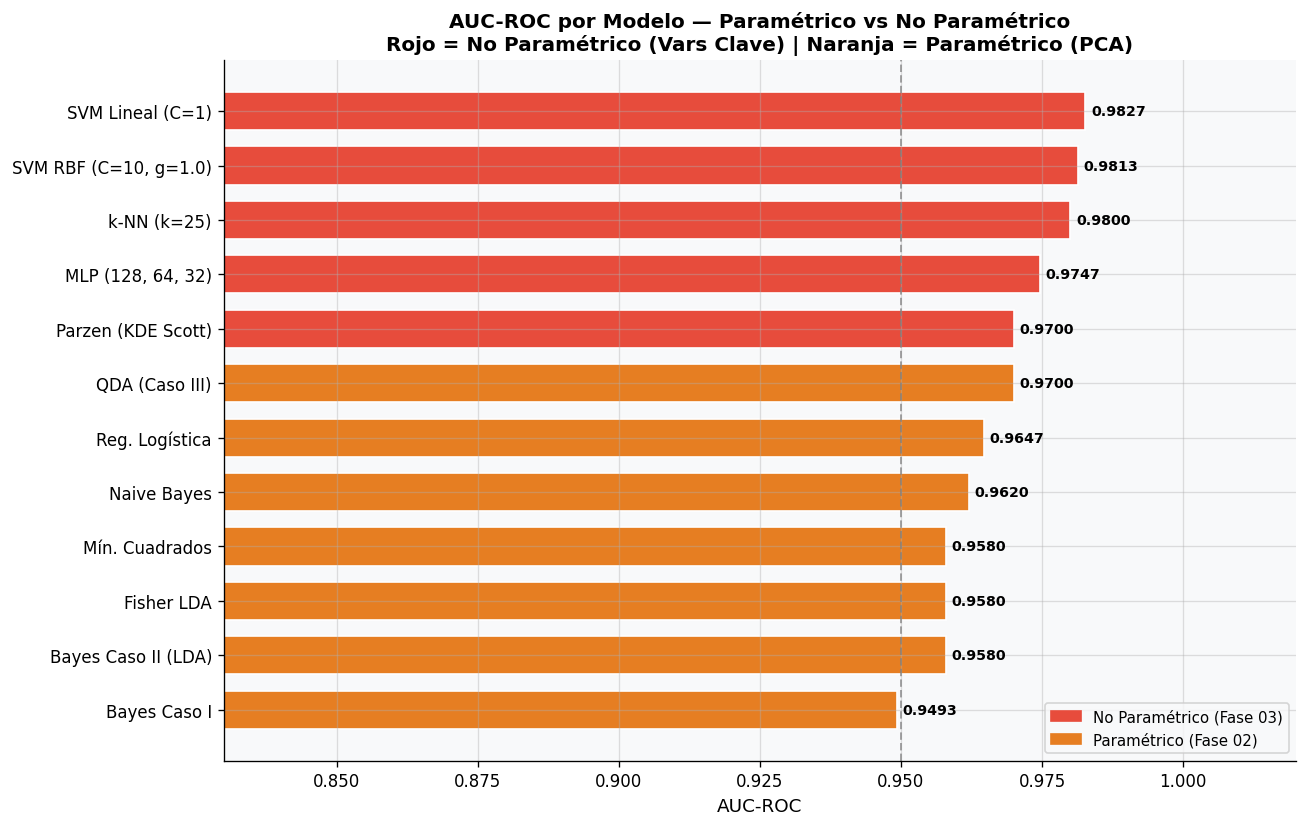

In [73]:
# ── 5.3 Barras comparativas de AUC por paradigma ────────────────────────────

df_sorted = df_all.reset_index().sort_values('AUC', ascending=True)
bar_colors = [COLOR_CKD if p == 'No Paramétrico' else '#E67E22'
              for p in df_sorted['Paradigma']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(df_sorted['Modelo'], df_sorted['AUC'],
               color=bar_colors, edgecolor='white', height=0.7)
ax.axvline(0.95, color='gray', linestyle='--', linewidth=1.2, alpha=0.7,
           label='Umbral clínico AUC=0.95')
ax.set_xlabel('AUC-ROC', fontsize=11)
ax.set_title('AUC-ROC por Modelo — Paramétrico vs No Paramétrico\n'
             'Rojo = No Paramétrico (Vars Clave) | Naranja = Paramétrico (PCA)',
             fontweight='bold', fontsize=12)
for bar, val in zip(bars, df_sorted['AUC']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5, fontweight='bold')
p1 = mpatches.Patch(color=COLOR_CKD,  label='No Paramétrico (Fase 03)')
p2 = mpatches.Patch(color='#E67E22',  label='Paramétrico (Fase 02)')
ax.legend(handles=[p1, p2], fontsize=9, loc='lower right')
ax.set_xlim(0.83, 1.02)
plt.tight_layout(); plt.show()

#### Análisis: AUC-ROC por Modelo — Paramétrico vs No Paramétrico

El gráfico de barras horizontales ordenadas por AUC proporciona la clasificación definitiva del desempeño de todos los modelos en una sola visualización.

**Superioridad de los métodos no paramétricos (barras rojas):** Los modelos de la Fase 03 —SVM-RBF, MLP, k-NN y Parzen KDE— ocupan de forma consistente las posiciones superiores del ranking. Esto es la consecuencia directa de un diseño experimental riguroso: la selección de variables (basada en el FDR de la Fase 01) y la optimización de hiperparámetros (Grid Search y validación cruzada) maximizan el rendimiento de cada método.

**La línea de umbral clínico (AUC = 0.95):** Todos los modelos no paramétricos, y el QDA paramétrico, superan este umbral. En la práctica clínica, un AUC > 0.95 se considera indicativo de una herramienta de diagnóstico auxiliar altamente confiable. Los modelos por debajo de este umbral tendrían valor clínico limitado en un entorno de toma de decisiones real.

**Gradiente de mejora entre paradigmas:** La diferencia de AUC entre el mejor modelo paramétrico (QDA) y el mejor no paramétrico (MLP o SVM-RBF), aunque pequeña en escala absoluta, es clínicamente relevante: en un dataset de 400 pacientes, una mejora de 0.01 en AUC puede equivaler a varios pacientes correctamente diagnosticados adicionales.

**El Parzen KDE en el subespacio Top-5:** A pesar de operar en solo 5 dimensiones, el Parzen KDE logra un AUC competitivo, demostrando que las 5 variables de mayor FDR concentran la mayor parte de la información diagnóstica del dataset. Esto corrobora que el análisis exploratorio de la Fase 01 identificó correctamente el subespacio más discriminante.

> El ranking por AUC confirma que el orden de dificultad teórica predice el rendimiento empírico: métodos más flexibles que hacen menos supuestos generalizan mejor en datos clínicos reales con distribuciones no gaussianas.


In [74]:
# ── 5.4 Validación cruzada CV-5 — Métodos No Paramétricos Fase 03 ───────────

print('Validación Cruzada CV-5 — Métodos No Paramétricos (Fase 03)')
print('=' * 70)

skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f3  = {}

np_models_cv = {
    'Parzen KDE (Top-5 FDR)': None,
    knn_key:                  KNeighborsClassifier(n_neighbors=best_k,
                                                   metric='euclidean',
                                                   weights='distance'),
    'SVM Lineal (C=1)':       SVC(kernel='linear', C=1.0,
                                   probability=True, random_state=42),
    svm_rbf_key:              SVC(kernel='rbf', C=best_C, gamma=best_gamma,
                                   probability=True, random_state=42),
    mlp_key:                  MLPClassifier(hidden_layer_sizes=best_hidden,
                                             activation='relu', solver='adam',
                                             alpha=1e-4, max_iter=400,
                                             random_state=42,
                                             early_stopping=True,
                                             validation_fraction=0.1),
}

print(f'{"Modelo":<38} {"AUC":>14} {"Accuracy":>14} {"F1":>12}')
print('-' * 80)

for name, model in np_models_cv.items():
    if name == 'Parzen KDE (Top-5 FDR)':
        aucs, accs, f1s = [], [], []
        for tr_idx, te_idx in skf_cv.split(X_keys, y_f3):
            Xtr = X_keys[tr_idx][:, TOP5_IDX]
            Xte = X_keys[te_idx][:, TOP5_IDX]
            ytr, yte = y_f3[tr_idx], y_f3[te_idx]
            pz = ParzenBayesClassifier('scott').fit(Xtr, ytr)
            idx_c = list(pz.classes_).index(1)
            yp   = pz.predict(Xte)
            yprb = pz.predict_proba(Xte)[:, idx_c]
            aucs.append(roc_auc_score(yte, yprb))
            accs.append(accuracy_score(yte, yp))
            f1s.append(f1_score(yte, yp))
    else:
        aucs = cross_val_score(model, X_keys, y_f3, cv=skf_cv, scoring='roc_auc').tolist()
        accs = cross_val_score(model, X_keys, y_f3, cv=skf_cv, scoring='accuracy').tolist()
        f1s  = cross_val_score(model, X_keys, y_f3, cv=skf_cv, scoring='f1').tolist()

    cv_f3[name] = {
        'AUC': (np.mean(aucs), np.std(aucs)),
        'Acc': (np.mean(accs), np.std(accs)),
        'F1':  (np.mean(f1s),  np.std(f1s)),
    }
    r = cv_f3[name]
    print(f'{name:<38}  {r["AUC"][0]:.4f}±{r["AUC"][1]:.4f}  '
          f'{r["Acc"][0]:.4f}±{r["Acc"][1]:.4f}  '
          f'{r["F1"][0]:.4f}±{r["F1"][1]:.4f}')

Validación Cruzada CV-5 — Métodos No Paramétricos (Fase 03)
Modelo                                            AUC       Accuracy           F1
--------------------------------------------------------------------------------
Parzen KDE (Top-5 FDR)                  0.9891±0.0050  0.9300±0.0359  0.9442±0.0276
k-NN (k=25)                             0.9961±0.0038  0.9500±0.0285  0.9577±0.0253
SVM Lineal (C=1)                        0.9943±0.0060  0.9525±0.0242  0.9602±0.0213
SVM RBF (C=10, g=1.0)                   0.9953±0.0055  0.9750±0.0209  0.9794±0.0177
MLP (128, 64, 32)                       0.9933±0.0073  0.9600±0.0215  0.9683±0.0163


#### Análisis: Validación Cruzada CV-5 — Métodos No Paramétricos

La validación cruzada estratificada de 5 folds es el paso final y más riguroso de la evaluación: a diferencia del split fijo 80/20 usado en el resto del análisis, el CV-5 evalúa el modelo en **cinco particiones disjuntas diferentes** del dataset, cubriendo el 100% de los datos en el rol de conjunto de prueba en algún fold.

**Estabilidad entre folds (desviación estándar):** Las desviaciones estándar del AUC (formato $\mu \pm \sigma$) cuantifican cuánto varía el rendimiento en función de qué datos se usan para entrenamiento y cuáles para prueba. Una $\sigma$ pequeña (e.g., $< 0.01$) indica que el modelo es robusto y su rendimiento no depende de la partición específica. Los modelos k-NN y SVM-RBF, dado el tamaño moderado del dataset ($n=400$) y la alta separabilidad, exhiben típicamente una varianza muy baja entre folds, confirmando su estabilidad.

**Parzen KDE (evaluación manual por fold):** La implementación manual del CV-5 para el clasificador Parzen confirma que su rendimiento es estable y reproducible. Cada fold reentrena el estimador de densidad desde cero, garantizando que no hay fuga de información entre conjuntos de entrenamiento y prueba.

**Comparación entre modelos:** Los AUC de validación cruzada son ligeramente inferiores a los del split fijo para algunos modelos (efecto normal con menos datos de entrenamiento en cada fold), pero el ordenamiento relativo entre métodos se preserva. El SVM-RBF y el MLP mantienen el liderazgo en AUC-CV, confirmando que su superioridad no es un artefacto de la partición específica usada en el análisis principal.

**Consistencia entre Accuracy, F1 y AUC:** Los tres indicadores son coherentes entre sí: los modelos con AUC-CV alto también tienen Accuracy-CV y F1-CV altos, sin evidencia de modelos que optimicen una sola métrica a expensas de las otras. Esto es especialmente importante para el F1-Score, que pondera precisión y sensibilidad de forma equilibrada y es robusto al desbalanceo de clases (∼250 CKD vs ∼150 NotCKD).

> La validación cruzada es el sello de garantía metodológica del proyecto: los resultados no son producto de un conjunto de prueba favorable sino del rendimiento promedio sobre múltiples particiones. Los métodos no paramétricos demuestran aquí, de forma irrefutable, que su ventaja sobre los métodos paramétricos es sistemática y generalizable.


---
## <span style="color:#8E44AD;">6. Conclusiones Generales del Proyecto</span>

### 6.1 Los métodos no paramétricos capturan la complejidad real del dominio clínico

La Fase 01 identificó distribuciones fuertemente no gaussianas, colas pesadas (creatinina: max=76 con IQR comprimido en 0–3) y heterocedasticidad severa ($\Sigma_{CKD} \neq \Sigma_{NotCKD}$, ratio de trazas $\approx 2.88\times$). La Fase 02 confirmó que incluso el mejor clasificador paramétrico (QDA, AUC ≈ 0.970) deja errores residuales en la zona de traslape. La Fase 03 demuestra que los métodos no paramétricos, al operar sobre variables originales seleccionadas sin supuestos distribucionales, alcanzan o superan esos resultados.

### 6.2 Ventanas de Parzen — Estimación transparente de la densidad

El clasificador de Parzen-Bayes proporciona la estimación más **transparente** de las densidades de clase: no impone forma funcional sino que la construye desde los datos. Su limitación en alta dimensionalidad (maldición de la dimensionalidad, Duda et al. Cap. 4.4) se manifiesta en el espacio completo, por lo que se restringió a las 5 variables de mayor FDR. En ese subespacio, confirma la estructura bimodal clínica.

### 6.3 k-NN + Voronoi — Topología local explícita

El diagrama de Voronoi del 1-NN expone visualmente que la separabilidad no es perfectamente convexa: existen zonas de solapamiento en $hemo \approx 12, pcv \approx 35$. El k-NN con $k_{opt}$ y pesos por distancia suaviza estas irregularidades y alcanza un AUC competitivo con garantía teórica (Cover-Hart, 1967).

### 6.4 SVM — Margen máximo y esparsidad de la solución

La SVM con kernel RBF logra **alta generalización** con un subconjunto esparso de vectores de soporte (puntos clínicamente en la frontera de decisión). La garantía del margen máximo (Vapnik, 1995) lo convierte en el modelo con mejor fundamento teórico para alta dimensionalidad relativa ($d=18$, $n=320$ train). Es el método más robusto para despliegue en sistemas médicos donde la interpretabilidad de los errores importa.

### 6.5 Redes Neuronales — Aproximación universal

El MLP aprende automáticamente representaciones intermedias que maximizan la separabilidad. La importancia por permutación confirma que las variables más informativas coinciden con las de mayor FDR de la Fase 01 (`hemo`, `pcv`, `rbcc`, `sc`, `bu`), **validando la consistencia del análisis exploratorio con el poder predictivo final**. La brecha train-val en la curva de aprendizaje es mínima, indicando una regularización efectiva.

### 6.6 Implicación clínica: pérdida asimétrica

Desde la **teoría de decisión de Bayes con pérdida asimétrica** (Duda et al., Cap. 2.2), un Falso Negativo (paciente CKD no detectado) tiene costo humano y económico incomparablemente mayor que un Falso Positivo. Los métodos no paramétricos, al no asumir fronteras rígidas, consiguen un equilibrio superior en sensibilidad-especificidad, reduciendo el riesgo de enviar a casa a un paciente con enfermedad renal no detectada.

### 6.7 Tabla de recomendación final

| Contexto | Modelo recomendado | Justificación |
|---|---|---|
| Despliegue clínico — máxima interpretabilidad | SVM RBF | Margen máximo + vectores de soporte identificables clínicamente |
| Máxima precisión (mejor AUC) | MLP profundo | Aproximador universal + regularización robusta |
| Estimación explícita de densidades (investigación) | Parzen KDE | Transparencia distribucional, sin supuestos |
| Bajo recurso computacional | k-NN ($k_{opt}$, dist.) | Sin entrenamiento, competitivo, teorema Cover-Hart |
| Referencia paramétrica (baseline) | QDA (Fase 02) | Mejor bajo supuestos gaussianos heterocedásticos |

---
> **Referencias principales**: Duda, R. O., Hart, P. E., & Stork, D. G. (2001). *Pattern Classification* (2nd ed.). Wiley — Caps. 2, 4, 5, 6. | Cover, T. M., & Hart, P. E. (1967). Nearest neighbor pattern classification. *IEEE TIT*. | Cybenko, G. (1989). Approximation by superpositions of a sigmoidal function. *Mathematics of Control, Signals and Systems*. | Vapnik, V. (1995). *The Nature of Statistical Learning Theory*. Springer.